In [1]:
# ============================================================
# NOTEBOOK OVERVIEW
# ============================================================
#
# SI-UNIT VERSION. This is the SI-unit companion to
# Arizona_Treatment_Cost_Analysis.ipynb (identical analysis and results,
# unit prices reported per metric ton and lane-km instead of per US short
# ton and lane-mile). Use this version for the manuscript "Probabilistic
# Pavement Management Using Bid-Based Cost Distributions"; use the
# customary-unit notebook for the FHWA project report.
# This notebook analyzes pavement treatment unit costs from ADOT
# bid tab data (ByJob format). Unit prices are inflation-adjusted
# to 2025 Q1 real dollars using the NHCCI index before any analysis.
#
# NOTEBOOK STRUCTURE
# ----------------------------------------------------------
# 1. SETUP
#    - Inflation adjustment (NHCCI -> 2025 Q1 real prices)
#    - Data filtering: Position == 1, dedup by job
#
# 2. AC (ASPHALT CONCRETE) -- pay item unit price distributions
#    Binder | Mixture | Mineral Admixture | Binder Content
#    Each sub-section: violin + boxplot by county, CDF (empirical
#    vs lognormal fit), and bootstrap sample summary statistics.
#
# 3. FR (FRICTION COURSE / RUBBERIZED AC) -- same sub-sections as AC
#    Binder | Mixture | Mineral Admixture | Binder Content
#
# 4. MILLING -- unit price distributions and lane-mile cost estimates
#
# 5. REMOVE & REPLACE 0.5-INCH AC+FR
#    Lane-mile cost combining AC, FR, and Milling components.
#    Bootstrap distributions; violin and CDF by county.
#
# 6. ALL TREATMENTS COMBINED
#    Side-by-side comparison of lane-mile costs across all treatments.
#
# 7. INDIVIDUAL SURFACE TREATMENTS
#    Chip Seal | Microsurfacing | Crack Seal | Fog Coat
#    Mill + Cape Seal
#    Each: lane-mile cost distributions, STATE-level CDF, bootstrap stats.
#
# 8. REMOVE & REPAIR 3-INCH AC + MICROSURFACING
#    Spot repair composite cost; STATE-level distributions and CDF.
#
# 9. RECONSTRUCTION
#    Component-level costs (AC, FR, Milling, Tack, etc.) and
#    composite STATE-level reconstruction cost distribution.
#
# 10. PRESENTATION SUMMARY
#     All-treatment overlay plots and lognormal summary table
#     (mean, CoV, lognormal parameters) for every treatment.
#
# 11. PAIRED BOOTSTRAP CORRELATION
#     Spearman correlation between Remove & Replace AC and FR
#     treatment costs across bootstrap samples.
# ============================================================

# ============================================================
# GLOBAL REPRODUCIBILITY SETTINGS  (edit the seed here only)
# Every random draw in this notebook derives from GLOBAL_SEED.
#
# IMPORTANT: identical results across runs ALSO require a fixed
# PYTHONHASHSEED, which must be set BEFORE the kernel starts (it
# cannot be set from inside a running kernel). Without it, set()/
# dict() iteration order changes on every kernel restart, which
# reshuffles the value pools and makes seeded results differ
# slightly. The .env file in this folder (PYTHONHASHSEED=0) is
# loaded automatically by VS Code -- after adding/editing it you
# MUST restart the kernel and Run All.
# ============================================================
import os
import sys
import random
import numpy as np

GLOBAL_SEED = 42

# These generators are seeded inside this kernel and take effect now.
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Report whether the kernel was launched with a fixed hash seed.
_hashseed = os.environ.get("PYTHONHASHSEED")
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)  # propagate to child processes

if _hashseed is None:
    print('WARNING: PYTHONHASHSEED was NOT fixed when this kernel started.')
    print('         set()/dict() order can vary between kernel restarts,')
    print('         making seeded results differ slightly run-to-run.')
    print('         Fix: keep the .env (PYTHONHASHSEED=0) in this folder,')
    print('         then RESTART the kernel and Run All.')
else:
    print(f'Reproducible: GLOBAL_SEED={GLOBAL_SEED}, PYTHONHASHSEED={_hashseed}')

Reproducible: GLOBAL_SEED=42, PYTHONHASHSEED=0


## Inflation Adjustment

In [2]:
"""
NHCCI-adjusted unit price for ByJob.

Result: df with:
- All original ByJob columns in the same order
- PLUS new columns at the end:
    BidDate, County, PopulationArea (if available),
    NHCCI_quarter, NHCCI_value,
    NHCCI_InflationFactor_vs_2025Q1,
    UnitPrice_Real_2025Q1   (Amount adjusted to 2025Q1)
"""

from __future__ import annotations
import pandas as pd


# -----------------------------
# PATHS & SETTINGS
# -----------------------------
BYJOB_PATH   = "ByJob.xlsx"
SUMMARY_PATH = "PISearch_project_summary.xlsx"
NHCCI_PATH   = "NHCCI_20251220.csv"
BASE_Q       = "2025Q1"


# -----------------------------
# Helpers
# -----------------------------
def to_quarter_key(x) -> str | pd.NA:
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().upper().replace(" ", "")
    s = s.replace("-Q", "Q").replace("_Q", "Q")
    if "Q" in s:
        left, right = s.split("Q", 1)
        if left.isdigit() and right and right[0] in {"1", "2", "3", "4"}:
            return f"{left}Q{right[0]}"
    return pd.NA


def nhcci_quarter_from_date(dt_series: pd.Series) -> pd.Series:
    return dt_series.dt.to_period("Q").astype(str).apply(to_quarter_key)


def load_nhcci_series(nhcci_path: str) -> pd.Series:
    """
    Returns Series indexed by 'YYYYQ#' with NHCCI values.
    """
    try:
        nhcci = pd.read_csv(nhcci_path)
    except Exception:
        nhcci = pd.read_excel(nhcci_path)

    quarter_col = next((c for c in nhcci.columns if "quarter" in c.lower()), None)
    if quarter_col is None:
        raise ValueError("NHCCI file must contain a 'quarter' column.")

    value_col = "NHCCI" if "NHCCI" in nhcci.columns else None
    if value_col is None:
        numeric_cols = [
            c for c in nhcci.columns
            if c != quarter_col and pd.api.types.is_numeric_dtype(nhcci[c])
        ]
        if not numeric_cols:
            raise ValueError("NHCCI file has no numeric index column.")
        value_col = numeric_cols[0]

    tmp = nhcci[[quarter_col, value_col]].copy()
    tmp["quarter_key"] = tmp[quarter_col].apply(to_quarter_key)
    tmp = tmp.dropna(subset=["quarter_key", value_col])

    s = tmp.set_index("quarter_key")[value_col].astype(float)
    s = s[~s.index.duplicated(keep="last")].sort_index()
    s.index.name = "NHCCI_quarter"
    return s


def enforce_2025_missing_quarters_equal_q1(s: pd.Series) -> pd.Series:
    """
    If 2025Q2/Q3/Q4 are missing, set them equal to 2025Q1.
    Then build a continuous quarterly index and forward-fill any remaining gaps.
    """
    base = "2025Q1"
    if base not in s.index:
        return s  # let caller raise baseline error later

    base_val = float(s.loc[base])
    for q in ["2025Q2", "2025Q3", "2025Q4"]:
        if q not in s.index or pd.isna(s.get(q)):
            s.loc[q] = base_val

    # Now create continuous quarterly index and forward-fill remaining gaps
    qmin = pd.Period(min(s.index), freq="Q")
    qmax = pd.Period(max(s.index), freq="Q")
    full = pd.period_range(qmin, qmax, freq="Q").astype(str).map(to_quarter_key)

    s_full = s.reindex(full).sort_index().ffill()
    s_full.index.name = "NHCCI_quarter"
    return s_full


# -----------------------------
# 1) Load data
# -----------------------------
byjob   = pd.read_excel(BYJOB_PATH, sheet_name=0)
summary = pd.read_excel(SUMMARY_PATH, sheet_name=0)

original_cols = list(byjob.columns)

# Required columns (explicit)
required_byjob = ["JobID", "Amount"]
required_summary = ["ProjectID", "Bid Date", "County"]

missing_b = [c for c in required_byjob if c not in byjob.columns]
missing_s = [c for c in required_summary if c not in summary.columns]

if missing_b:
    raise ValueError(f"ByJob is missing required columns: {missing_b}")
if missing_s:
    raise ValueError(f"Project summary is missing required columns: {missing_s}")


# -----------------------------
# 2) Join summary onto byjob
# -----------------------------
df = byjob.copy()
df["_ProjectKey"] = df["JobID"].astype(str).str.strip()

sm_cols = ["ProjectID", "Bid Date", "County"]
if "PopulationArea" in summary.columns:
    sm_cols.append("PopulationArea")

sm = summary[sm_cols].copy()
sm["_ProjectKey"] = sm["ProjectID"].astype(str).str.strip()
sm = sm.drop_duplicates(subset=["_ProjectKey"])

df = df.merge(sm.drop(columns=["ProjectID"]), on="_ProjectKey", how="left")
df = df.rename(columns={"Bid Date": "BidDate"})


# -----------------------------
# 3) Ensure Amount is numeric (unit price)
# -----------------------------
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")


# -----------------------------
# 4) Load NHCCI and force 2025Q2-2025Q4 = 2025Q1 if missing
# -----------------------------
nhcci_s = load_nhcci_series(NHCCI_PATH)
nhcci_s = enforce_2025_missing_quarters_equal_q1(nhcci_s)

BASE_Q_KEY = to_quarter_key(BASE_Q)
if pd.isna(BASE_Q_KEY) or BASE_Q_KEY not in nhcci_s.index:
    raise ValueError(f"Baseline quarter {BASE_Q} not found in NHCCI data.")

base_index = float(nhcci_s.loc[BASE_Q_KEY])

df["BidDate"] = pd.to_datetime(df["BidDate"], errors="coerce")
df["NHCCI_quarter"] = nhcci_quarter_from_date(df["BidDate"])
df["NHCCI_value"] = df["NHCCI_quarter"].map(nhcci_s)


# -----------------------------
# 5) Inflation factor & real unit price
# -----------------------------
infl_col = f"NHCCI_InflationFactor_vs_{BASE_Q_KEY}"
real_col = f"UnitPrice_Real_{BASE_Q_KEY}"

df[infl_col] = base_index / df["NHCCI_value"]
df[real_col] = df["Amount"] * df[infl_col]

missing_q = sorted(df.loc[df["NHCCI_value"].isna(), "NHCCI_quarter"].dropna().unique())
if missing_q:
    print("Warning: Missing NHCCI values for quarters:", missing_q)


# -----------------------------
# 6) Final column order: original first, new at end
# -----------------------------
df = df.drop(columns=["_ProjectKey"], errors="ignore")
new_cols = [c for c in df.columns if c not in original_cols]
df = df[original_cols + new_cols]

print("Done. df shape:", df.shape)

# df.to_excel("ByJob_with_NHCCI_real_unitprice.xlsx", index=False)


Done. df shape: (368418, 19)


In [3]:
# Filter for Position == 1
df = df[df["Position"] == 1]

# Remove duplicate rows based on specified columns
dedup_columns = [
    "JobID", "PayItemID", "Position", "UnitEnglishID", 
    "ContractorName", "Extension"
]
df = df.drop_duplicates(subset=dedup_columns, keep="first")

# AC

## Binder

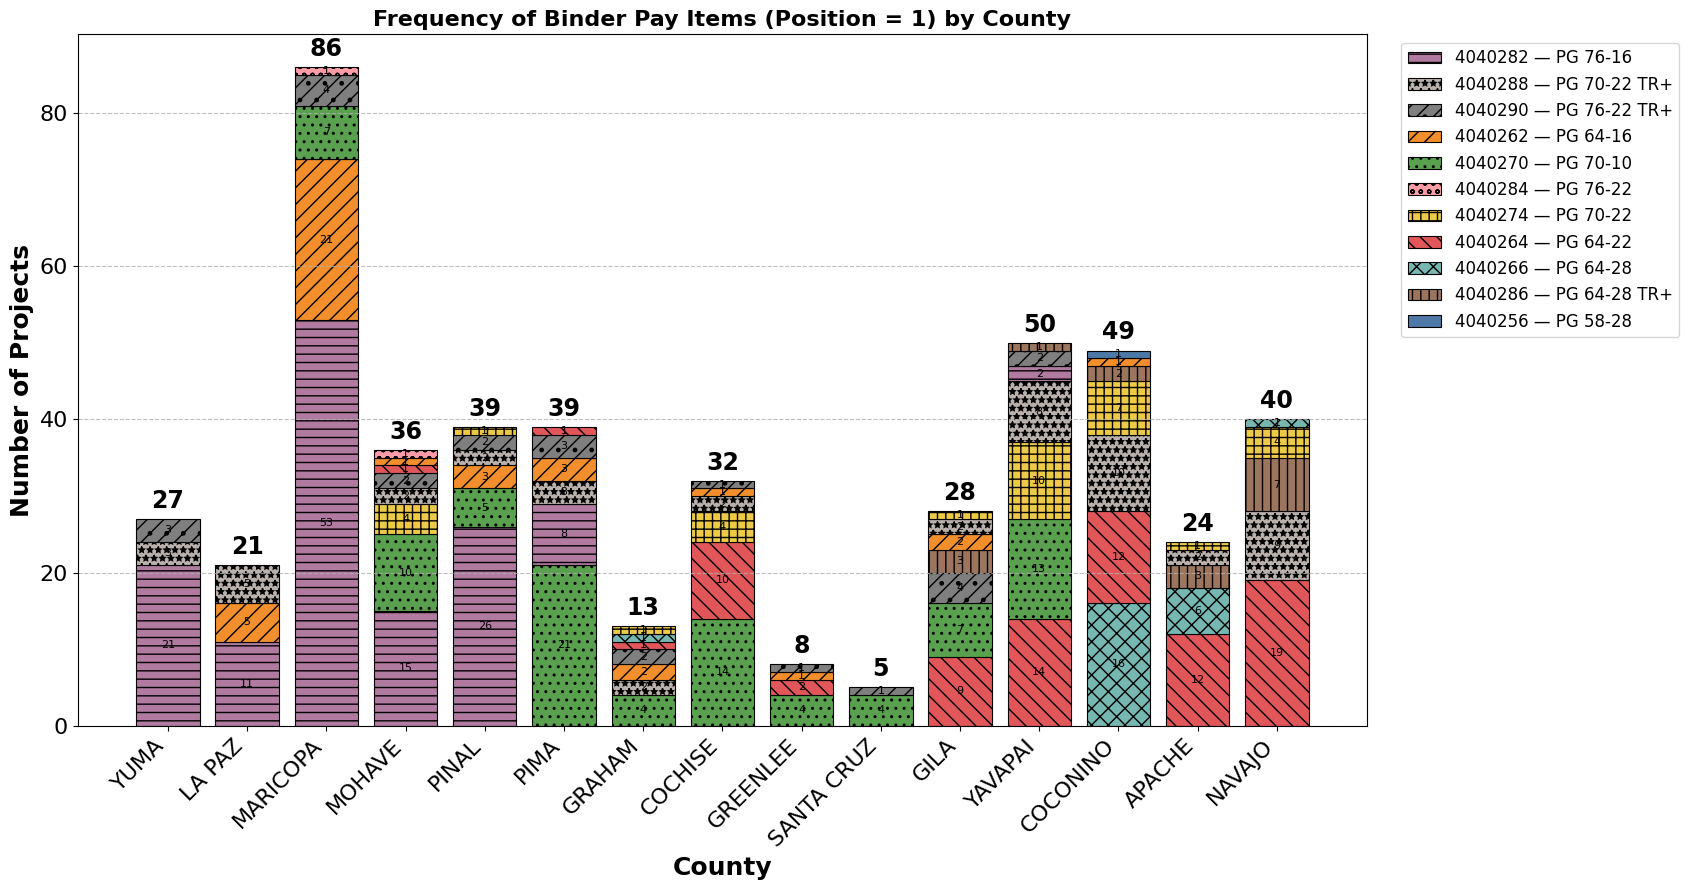

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1449304832.py:368: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


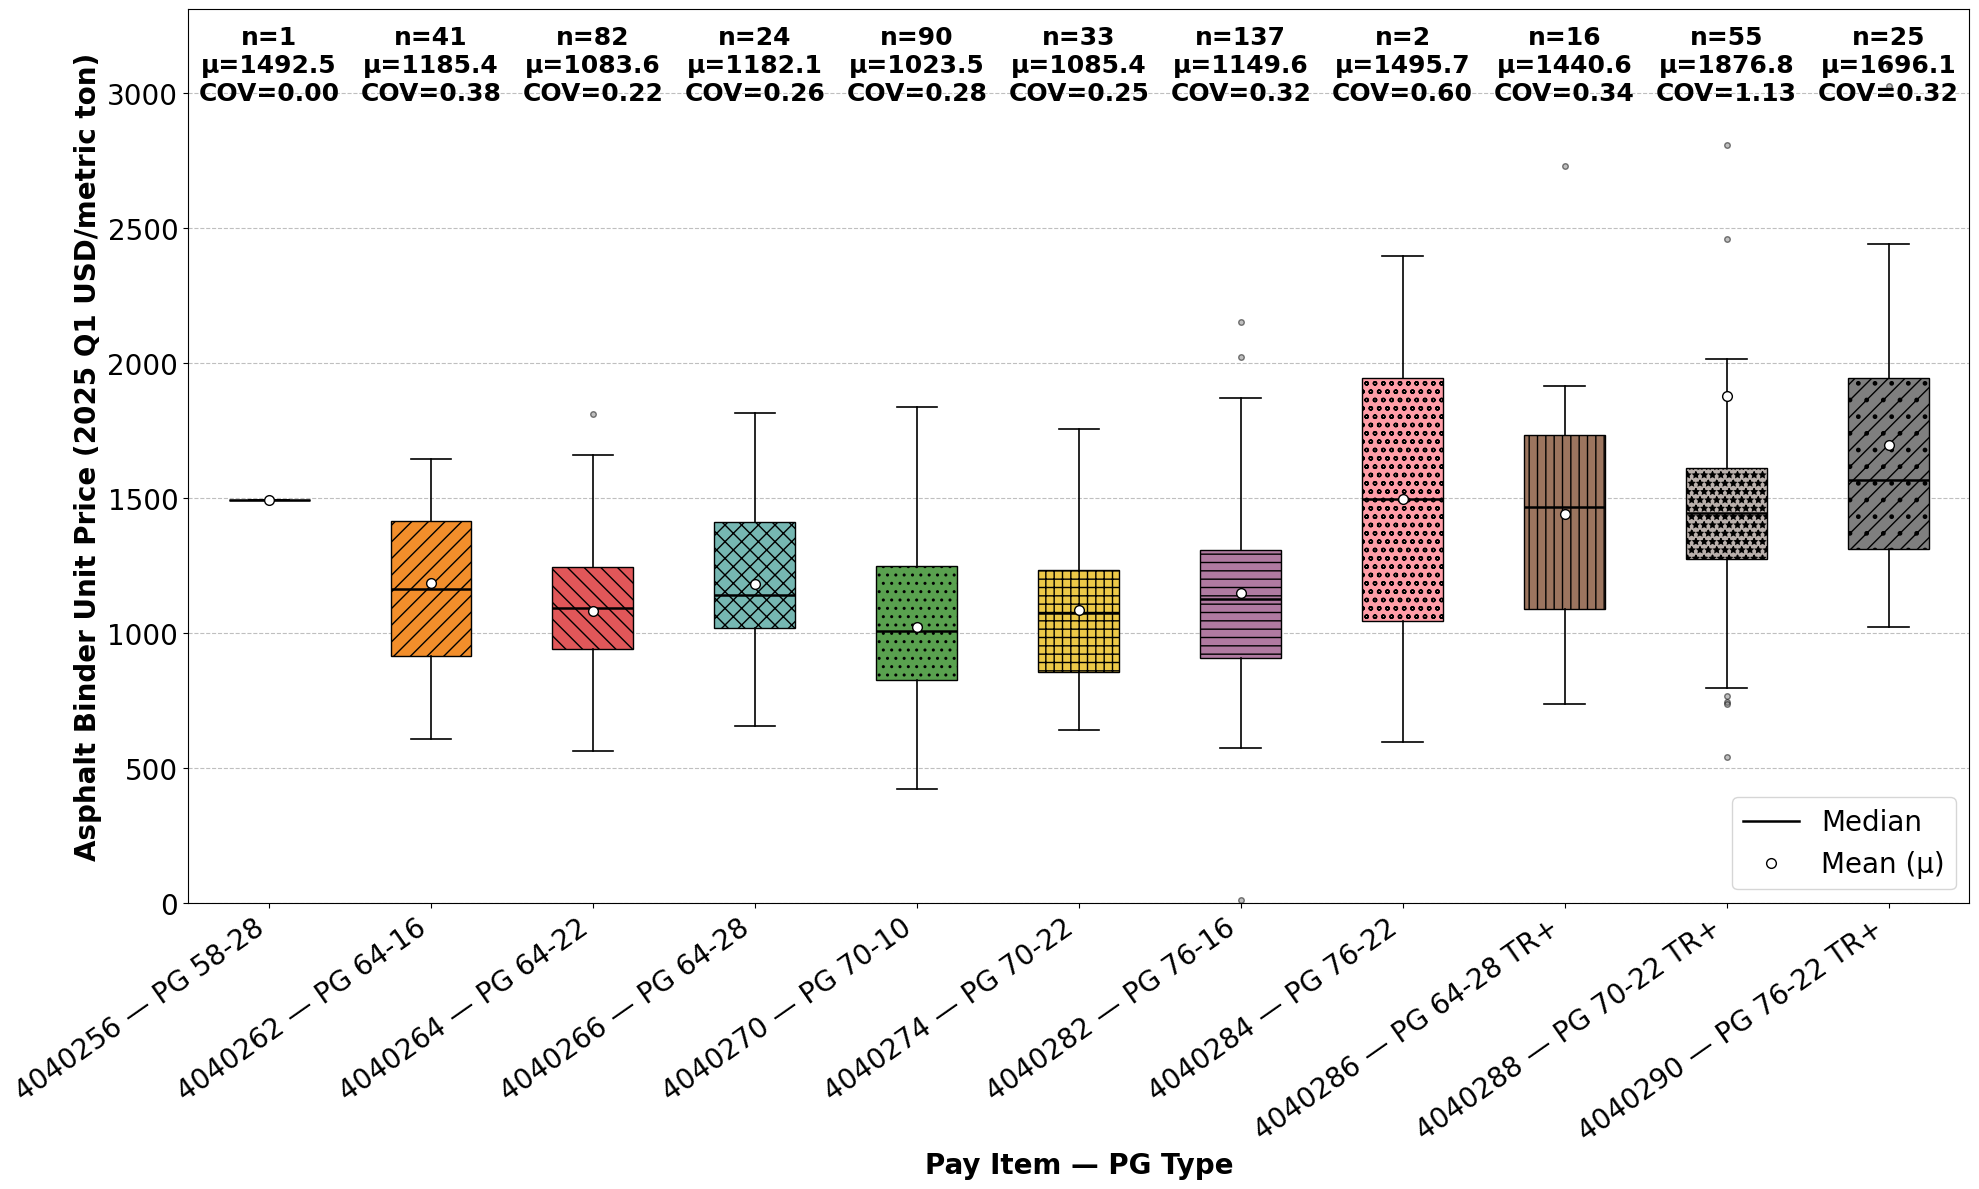

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
BINDER_PAYITEM_LABELS = [
    "4040256 — ASPHALT BINDER (PG 58-28)",
    "4040262 — ASPHALT BINDER (PG 64-16)",
    "4040264 — ASPHALT BINDER (PG 64-22)",
    "4040266 — ASPHALT BINDER (PG 64-28)",
    "4040270 — ASPHALT BINDER (PG 70-10)",
    "4040274 — ASPHALT BINDER (PG 70-22)",
    "4040282 — ASPHALT BINDER (PG 76-16)",
    "4040284 — ASPHALT BINDER (PG 76-22)",
    "4040286 — ASPHALT BINDER (PG 64-28 TR+)",
    "4040288 — ASPHALT BINDER (PG 70-22 TR+)",
    "4040290 — ASPHALT BINDER (PG 76-22 TR+)",
]

COUNTY_ORDER = [
    "YUMA", "LA PAZ", "MARICOPA", "MOHAVE", "PINAL", "PIMA",
    "GRAHAM", "COCHISE", "GREENLEE", "SANTA CRUZ", "GILA",
    "YAVAPAI", "COCONINO", "APACHE", "NAVAJO",
]

COLORS = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC", "#7F7F7F"
]

HATCHES = ["", "//", "\\\\", "xx", "..", "++", "--", "oo", "||", "**", "//."]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311


# ============================================================
# HELPERS
# ============================================================
def parse_payitem_id(series: pd.Series) -> pd.Series:
    """Extract numeric pay item code from any string/int representation."""
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )


def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()


def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")


def summary_stats_extended(x: pd.Series) -> dict:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "cov": np.nan,
            "min": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "max": np.nan
        }

    mean = float(x.mean())
    std = float(x.std(ddof=0))
    return {
        "n": int(len(x)),
        "mean": mean,
        "median": float(x.median()),
        "std": std,
        "cov": std / mean if mean != 0 else np.nan,
        "min": float(x.min()),
        "q1": float(x.quantile(0.25)),
        "q3": float(x.quantile(0.75)),
        "max": float(x.max()),
    }


def clean_binder_label(label: str) -> str:
    """
    Convert:
    '4040282 — ASPHALT BINDER (PG 76-16)'
    into:
    '4040282 — PG 76-16'
    """
    if pd.isna(label):
        return label

    label = str(label).strip()
    if "—" in label:
        payitem, desc = [part.strip() for part in label.split("—", 1)]
    else:
        return label

    desc = desc.replace("ASPHALT BINDER", "").strip()
    desc = desc.replace("(", "").replace(")", "").strip()
    desc = " ".join(desc.split())

    return f"{payitem} — {desc}"


def make_accessible_summary_text(freq: pd.DataFrame, price_summary: pd.DataFrame) -> str:
    """Create a text alternative / long description for screen readers."""
    lines = []
    lines.append("Accessible chart summary:")
    lines.append("Figure 1 is a stacked bar chart showing the frequency of binder pay items by county for Position = 1.")

    county_totals = freq.sum(axis=1).sort_values(ascending=False)
    if not county_totals.empty:
        top_county = county_totals.index[0]
        top_total = int(county_totals.iloc[0])
        lines.append(f"The county with the highest total binder count is {top_county} with {top_total} projects.")

    binder_totals = freq.sum(axis=0).sort_values(ascending=False)
    if not binder_totals.empty:
        top_binder = binder_totals.index[0]
        top_binder_n = int(binder_totals.iloc[0])
        lines.append(f"The most frequent binder pay item overall is {top_binder} with {top_binder_n} projects.")

    lines.append("Figure 2 is a boxplot of real unit prices by binder pay item.")
    if not price_summary.empty:
        highest_mean_row = price_summary.sort_values("mean", ascending=False).iloc[0]
        lowest_mean_row = price_summary.sort_values("mean", ascending=True).iloc[0]
        lines.append(
            f"The highest average unit price is for {highest_mean_row['Binder Label Clean']} "
            f"at {highest_mean_row['mean']:.2f} USD per metric ton."
        )
        lines.append(
            f"The lowest average unit price is for {lowest_mean_row['Binder Label Clean']} "
            f"at {lowest_mean_row['mean']:.2f} USD per metric ton."
        )

    lines.append("See the exported frequency and price summary tables for fully accessible data.")
    return "\n".join(lines)


# ============================================================
# MAIN
# ============================================================
def plot_binder_frequency_and_boxplot_508(
    df: pd.DataFrame,
    payitem_labels: list[str],
    county_order: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
    export_dir: str | None = None,
    show_plots: bool = True,
):
    """
    Creates more 508-friendly visual outputs plus accessible tables.

    IMPORTANT CHANGE:
    In the stacked bar chart, each county is stacked in descending order
    of frequency within that county. So the largest PG segment appears
    at the bottom for that county.

    Returns
    -------
    freq_table : pd.DataFrame
    price_summary : pd.DataFrame
    alt_text : str
    """

    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])

    ids = [lbl.split("—")[0].strip().split()[0] for lbl in payitem_labels]
    id_to_label = {pid: lbl for pid, lbl in zip(ids, payitem_labels)}
    id_to_clean_label = {pid: clean_binder_label(lbl) for pid, lbl in zip(ids, payitem_labels)}

    d = df.copy()
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()

    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin(ids)].copy()

    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])

    d["BinderPayItemID"] = d["_PayItemID_str"]
    d["Binder Label"] = d["BinderPayItemID"].map(id_to_label)
    d["Binder Label Clean"] = d["BinderPayItemID"].map(id_to_clean_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No binder rows found after filtering. Check PayItemIDs and Position.")

    # ============================================================
    # 1) Frequency table
    # ============================================================
    freq = (
        d.groupby(["County_std", "Binder Label Clean"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
         .astype(int)
    )

    clean_label_order = [clean_binder_label(lbl) for lbl in payitem_labels if clean_binder_label(lbl) in freq.columns]
    freq = freq[clean_label_order]

    freq_table = freq.copy()
    freq_table["Total"] = freq_table.sum(axis=1)

    # ============================================================
    # 2) Price summary table
    # ============================================================
    summary_rows = []
    for pid in sorted(ids, key=lambda s: int(s)):
        sub = d.loc[d["BinderPayItemID"] == pid, price_col]
        stats = summary_stats_extended(sub)
        stats["BinderPayItemID"] = pid
        stats["Binder Label"] = id_to_label[pid]
        stats["Binder Label Clean"] = id_to_clean_label[pid]
        summary_rows.append(stats)

    price_summary = pd.DataFrame(summary_rows)[[
        "BinderPayItemID", "Binder Label", "Binder Label Clean",
        "n", "mean", "median", "std", "cov", "min", "q1", "q3", "max"
    ]]

    # ============================================================
    # 3) Accessible text summary
    # ============================================================
    alt_text = make_accessible_summary_text(freq, price_summary)

    # ============================================================
    # 4) Export accessible outputs
    # ============================================================
    if export_dir is not None:
        out = Path(export_dir)
        out.mkdir(parents=True, exist_ok=True)

        freq_table.to_csv(out / "binder_frequency_by_county_accessible.csv", index=True)
        price_summary.to_csv(out / "binder_price_summary_accessible.csv", index=False)

        with open(out / "binder_chart_long_description.txt", "w", encoding="utf-8") as f:
            f.write(alt_text)

    # ============================================================
    # 5) Plot 1: Stacked bar chart with county-specific descending order
    # ============================================================
    if show_plots:
        binder_items = freq.columns.tolist()
        color_map = {item: COLORS[i % len(COLORS)] for i, item in enumerate(binder_items)}
        hatch_map = {item: HATCHES[i % len(HATCHES)] for i, item in enumerate(binder_items)}

        counties = freq.index.tolist()
        x = np.arange(len(counties))

        fig, ax = plt.subplots(figsize=(17, 9))

        # Track what has already appeared in legend
        shown_labels = set()

        for i, county in enumerate(counties):
            county_values = freq.loc[county]

            # Sort only nonzero values from largest to smallest for this county
            sorted_items = county_values[county_values > 0].sort_values(ascending=False)

            bottom = 0

            for item, val in sorted_items.items():
                label_for_legend = item if item not in shown_labels else None

                bars = ax.bar(
                    x[i],
                    val,
                    bottom=bottom,
                    label=label_for_legend,
                    color=color_map[item],
                    hatch=hatch_map[item],
                    edgecolor="black",
                    linewidth=0.8
                )

                # segment label
                ax.text(
                    x[i],
                    bottom + val / 2,
                    str(int(val)),
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

                bottom += val
                shown_labels.add(item)

            # total label on top
            ax.text(
                x[i],
                bottom + 0.8,
                str(int(bottom)),
                ha="center",
                va="bottom",
                fontsize=17,
                fontweight="bold"
            )

        ax.set_title("Frequency of Binder Pay Items (Position = 1) by County", fontsize=16, fontweight="bold")
        ax.set_xlabel("County", fontsize=18, fontweight="bold")
        ax.set_ylabel("Number of Projects", fontsize=18, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(counties, rotation=45, ha="right", fontsize=16)
        plt.yticks(fontsize=16)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.8)

        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=12,
            title_fontsize=10,
            frameon=True
        )

        plt.tight_layout()
        plt.show()

        # ========================================================
        # 6) Plot 2: Box plot
        # ========================================================
        id_sorted = sorted(ids, key=lambda s: int(s))
        data_to_plot = []
        labels = []
        top_annotations = []

        for pid in id_sorted:
            sub = pd.to_numeric(
                d.loc[d["BinderPayItemID"] == pid, price_col],
                errors="coerce"
            ).dropna()

            data_to_plot.append(sub)
            labels.append(id_to_clean_label[pid])

            stats = summary_stats_extended(sub)
            top_annotations.append({
                "n": stats["n"],
                "mean": stats["mean"],
                "cov": stats["cov"]
            })

        fig, ax = plt.subplots(figsize=(20, 12))

        bp = ax.boxplot(
            data_to_plot,
            labels=labels,
            showmeans=True,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=1.8),
            meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=7)
        )

        for i, box in enumerate(bp["boxes"]):
            box.set(
                facecolor=COLORS[i % len(COLORS)],
                edgecolor="black",
                hatch=HATCHES[i % len(HATCHES)],
                linewidth=1.0
            )

        for whisker in bp["whiskers"]:
            whisker.set(color="black", linewidth=1.2)
        for cap in bp["caps"]:
            cap.set(color="black", linewidth=1.2)
        for median in bp["medians"]:
            median.set(color="black", linewidth=1.8)
        for mean in bp["means"]:
            mean.set(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=7)
        for flier in bp["fliers"]:
            flier.set(marker="o", markerfacecolor="gray", markeredgecolor="black", alpha=0.5, markersize=4)

        ax.set_xlabel("Pay Item — PG Type", fontsize=20, fontweight="bold")
        ax.set_ylabel("Asphalt Binder Unit Price (2025 Q1 USD/metric ton)", fontsize=20, fontweight="bold")
        ax.set_ylim(0, 3310)

        plt.xticks(rotation=35, ha="right", fontsize=20)
        plt.yticks(fontsize=20)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.8)

        # Top annotations
        y_annot = 3250
        for i, ann in enumerate(top_annotations, start=1):
            mu_txt = f"{ann['mean']:.1f}" if pd.notna(ann["mean"]) else "NA"
            cov_txt = f"{ann['cov']:.2f}" if pd.notna(ann["cov"]) else "NA"
            text = f"n={ann['n']}\nμ={mu_txt}\nCOV={cov_txt}"
            ax.text(
                i,
                y_annot,
                text,
                ha="center",
                va="top",
                fontsize=18,
                fontweight="bold"
            )

        legend_elements = [
            Line2D([0], [0], color="black", lw=1.8, label="Median"),
            Line2D([0], [0], marker="o", color="black", markerfacecolor="white",
                   markersize=7, linestyle="None", label="Mean (μ)")
        ]
        ax.legend(
            handles=legend_elements,
            loc="lower right",
            frameon=True,
            fontsize=20,
            title_fontsize=16
        )

        plt.tight_layout()
        plt.show()

    # ============================================================
    # Print long description
    # ============================================================
    # Long description is generated and exported, but not printed in the notebook.

    return freq_table, price_summary, alt_text


# ============================================================
# RUN
# ============================================================
freq_table, price_summary, alt_text = plot_binder_frequency_and_boxplot_508(
    df=df,
    payitem_labels=BINDER_PAYITEM_LABELS,
    county_order=COUNTY_ORDER,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
    pos_value=1,
    export_dir="508_accessible_outputs",   # set to None if you do not want files saved
    show_plots=True
)


## Mixture

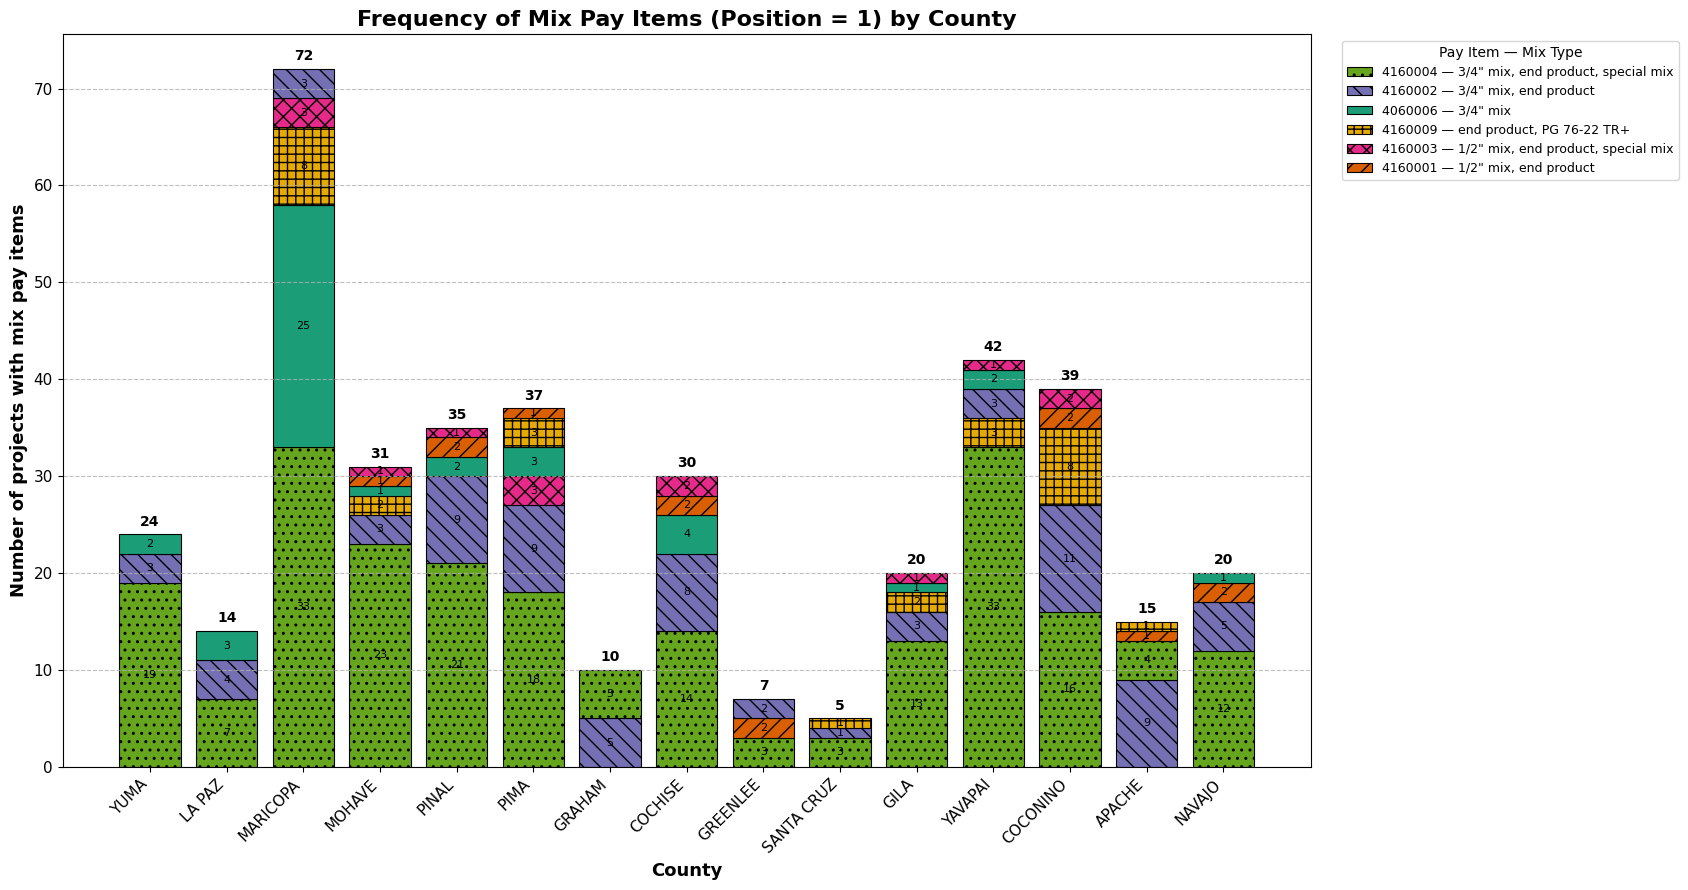

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2908469448.py:295: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


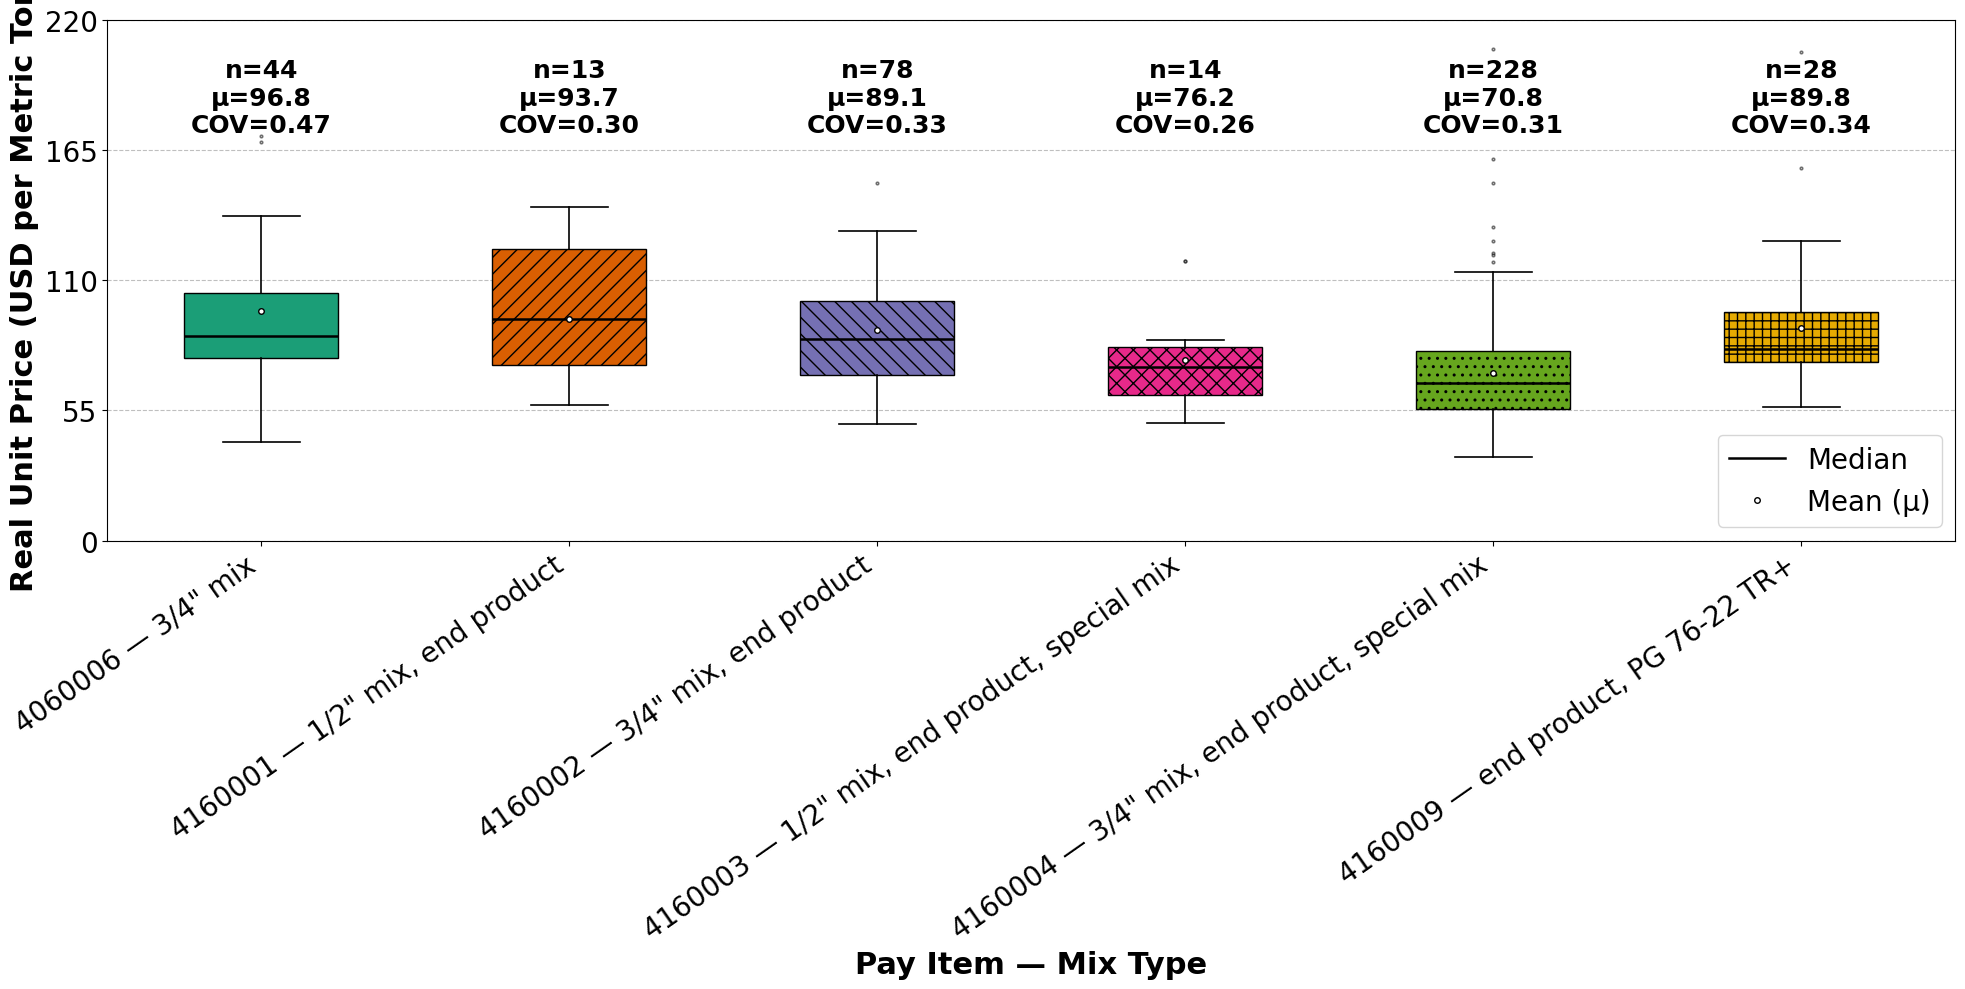

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================
MIX_PAYITEM_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)",
    "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)",
    "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)",
    "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
]

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

COLORS = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666",
    "#1f78b4", "#b2df8a", "#fb9a99", "#ff7f00",
    "#c0c0c0", "#9467bd", "#bcbd22",
]

HATCHES = ["", "//", "\\\\", "xx", "..", "++", "--", "oo", "||", "**", "//."]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311

# ============================================================
# HELPERS
# ============================================================
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

def parse_payitem_id(series: pd.Series) -> pd.Series:
    """Extract numeric pay item code from any string/int representation."""
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )

def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def summary_stats_extended(x: pd.Series) -> dict:
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "cov": np.nan,
            "min": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "max": np.nan,
        }

    mean = float(x.mean())
    std = float(x.std(ddof=0))
    return {
        "n": int(len(x)),
        "mean": mean,
        "median": float(x.median()),
        "std": std,
        "cov": std / mean if mean != 0 else np.nan,
        "min": float(x.min()),
        "q1": float(x.quantile(0.25)),
        "q3": float(x.quantile(0.75)),
        "max": float(x.max()),
    }

def clean_mix_label(label: str) -> str:
    if pd.isna(label):
        return label
    label = str(label).strip()
    if "—" not in label:
        return label
    payitem, desc = [part.strip() for part in label.split("—", 1)]
    desc = desc.replace("Asphaltic concrete", "").strip()
    parts = []
    import re
    matches = re.findall(r"\((.*?)\)", desc)
    for m in matches:
        m = m.strip()
        if m.lower().startswith("with "):
            m = m[5:].strip()
        parts.append(m)
    if not parts:
        desc_clean = " ".join(desc.replace("(", "").replace(")", "").split())
    else:
        desc_clean = ", ".join(parts)
    return f"{payitem} — {desc_clean}"

def make_accessible_summary_text(freq: pd.DataFrame, price_summary: pd.DataFrame) -> str:
    lines = []
    lines.append("Accessible chart summary:")
    lines.append("Figure 1 is a stacked bar chart showing the frequency of mix pay items by county for Position = 1.")
    county_totals = freq.sum(axis=1).sort_values(ascending=False)
    if not county_totals.empty:
        top_county = county_totals.index[0]
        top_total = int(county_totals.iloc[0])
        lines.append(f"The county with the highest total count is {top_county} with {top_total} projects.")
    mix_totals = freq.sum(axis=0).sort_values(ascending=False)
    if not mix_totals.empty:
        top_mix = mix_totals.index[0]
        top_mix_n = int(mix_totals.iloc[0])
        lines.append(f"The most frequent mix pay item overall is {top_mix} with {top_mix_n} projects.")
    lines.append("Figure 2 is a boxplot of real unit prices by mix pay item.")
    if not price_summary.empty:
        valid_summary = price_summary.dropna(subset=["mean"])
        if not valid_summary.empty:
            highest_mean_row = valid_summary.sort_values("mean", ascending=False).iloc[0]
            lowest_mean_row = valid_summary.sort_values("mean", ascending=True).iloc[0]
            lines.append(
                f"The highest average unit price is for {highest_mean_row['Mix Label Clean']} "
                f"at {highest_mean_row['mean']:.2f} USD per metric ton."
            )
            lines.append(
                f"The lowest average unit price is for {lowest_mean_row['Mix Label Clean']} "
                f"at {lowest_mean_row['mean']:.2f} USD per metric ton."
            )
    lines.append("See the exported frequency and price summary tables for fully accessible data.")
    return "\n".join(lines)

# ============================================================
# MAIN
# ============================================================
def plot_mix_frequency_and_boxplot_508(
    df: pd.DataFrame,
    payitem_labels: list[str],
    county_order: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
    export_dir: str | None = None,
    show_plots: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])
    ids = [lbl.split("—")[0].strip().split()[0] for lbl in payitem_labels]
    id_to_label = {pid: lbl for pid, lbl in zip(ids, payitem_labels)}
    id_to_clean_label = {pid: clean_mix_label(lbl) for pid, lbl in zip(ids, payitem_labels)}
    d = df.copy()
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin(ids)].copy()
    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])
    d["MixPayItemID"] = d["_PayItemID_str"]
    d["Mix Label"] = d["MixPayItemID"].map(id_to_label)
    d["Mix Label Clean"] = d["MixPayItemID"].map(id_to_clean_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No MIX rows found after filtering. Check PayItemIDs and Position==1.")
    freq = (
        d.groupby(["County_std", "Mix Label Clean"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
         .astype(int)
    )
    clean_label_order = [clean_mix_label(lbl) for lbl in payitem_labels if clean_mix_label(lbl) in freq.columns]
    freq = freq[clean_label_order]
    freq_table = freq.copy()
    freq_table["Total"] = freq_table.sum(axis=1)
    summary_rows = []
    for pid in sorted(ids, key=lambda s: int(s)):
        sub = d.loc[d["MixPayItemID"] == pid, price_col]
        stats = summary_stats_extended(sub)
        stats["MixPayItemID"] = pid
        stats["Mix Label"] = id_to_label[pid]
        stats["Mix Label Clean"] = id_to_clean_label[pid]
        summary_rows.append(stats)
    price_summary = pd.DataFrame(summary_rows)[[
        "MixPayItemID", "Mix Label", "Mix Label Clean",
        "n", "mean", "median", "std", "cov", "min", "q1", "q3", "max"
    ]]
    alt_text = make_accessible_summary_text(freq, price_summary)
    if export_dir is not None:
        out = Path(export_dir)
        out.mkdir(parents=True, exist_ok=True)
        freq_table.to_csv(out / "mix_frequency_by_county_accessible.csv", index=True)
        price_summary.to_csv(out / "mix_price_summary_accessible.csv", index=False)
        with open(out / "mix_chart_long_description.txt", "w", encoding="utf-8") as f:
            f.write(alt_text)
    if show_plots:
        mix_items = freq.columns.tolist()
        color_map = {item: COLORS[i % len(COLORS)] for i, item in enumerate(mix_items)}
        hatch_map = {item: HATCHES[i % len(HATCHES)] for i, item in enumerate(mix_items)}
        counties = freq.index.tolist()
        x = np.arange(len(counties))
        fig, ax = plt.subplots(figsize=(17, 9))
        shown_labels = set()
        for i, county in enumerate(counties):
            county_values = freq.loc[county]
            sorted_items = county_values[county_values > 0].sort_values(ascending=False)
            bottom = 0
            for item, val in sorted_items.items():
                label_for_legend = item if item not in shown_labels else None
                ax.bar(
                    x[i],
                    val,
                    bottom=bottom,
                    label=label_for_legend,
                    color=color_map[item],
                    hatch=hatch_map[item],
                    edgecolor="black",
                    linewidth=0.8
                )
                ax.text(
                    x[i],
                    bottom + val / 2,
                    str(int(val)),
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )
                bottom += val
                shown_labels.add(item)
            ax.text(
                x[i],
                bottom + 0.6,
                str(int(bottom)),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )
        ax.set_title(
            "Frequency of Mix Pay Items (Position = 1) by County",
            fontsize=16,
            fontweight="bold"
        )
        ax.set_xlabel("County", fontsize=13, fontweight="bold")
        ax.set_ylabel("Number of projects with mix pay items", fontsize=13, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(counties, rotation=45, ha="right", fontsize=11)
        ax.tick_params(axis="y", labelsize=11)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.8)
        ax.legend(
            title="Pay Item — Mix Type",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=9,
            title_fontsize=10,
            frameon=True
        )
        plt.tight_layout()
        plt.show()

        # ========================================================
        # 6) Plot 2: Boxplot of real unit prices
        # ========================================================
        id_sorted = sorted(ids, key=lambda s: int(s))
        data_to_plot = []
        labels = []
        top_annotations = []

        for pid in id_sorted:
            sub = pd.to_numeric(
                d.loc[d["MixPayItemID"] == pid, price_col],
                errors="coerce"
            ).dropna()
            data_to_plot.append(sub)
            labels.append(id_to_clean_label[pid])
            stats = summary_stats_extended(sub)
            top_annotations.append({
                "n": stats["n"],
                "mean": stats["mean"],
                "cov": stats["cov"]
            })

        fig, ax = plt.subplots(figsize=(20, 10))

        bp = ax.boxplot(
            data_to_plot,
            labels=labels,
            showmeans=True,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=1.8),
            meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=4)
        )

        for i, box in enumerate(bp["boxes"]):
            box.set(
                facecolor=COLORS[i % len(COLORS)],
                edgecolor="black",
                hatch=HATCHES[i % len(HATCHES)],
                linewidth=1.0
            )
        for whisker in bp["whiskers"]:
            whisker.set(color="black", linewidth=1.2)
        for cap in bp["caps"]:
            cap.set(color="black", linewidth=1.2)
        for median in bp["medians"]:
            median.set(color="black", linewidth=1.8)
        for mean in bp["means"]:
            mean.set(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=4)
        for flier in bp["fliers"]:
            flier.set(marker="o", markerfacecolor="gray", markeredgecolor="black", alpha=0.5, markersize=2)

        #ax.set_title("Real Unit Price by Mix Pay Item", fontsize=16, fontweight="bold")
        ax.set_xlabel("Pay Item — Mix Type", fontsize=22, fontweight="bold")
        ax.set_ylabel("Real Unit Price (USD per Metric Ton)", fontsize=22, fontweight="bold")

        # ---- Y-axis ticks every 50 from 0 to 200 ----
        ax.set_ylim(0, 220)
        ax.set_yticks(np.arange(0, 221, 55))

        plt.xticks(rotation=35, ha="right", fontsize=20)
        plt.yticks(fontsize=20)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.8)

        # ---- Top annotations: n, mean (mu), and CoV for each pay item ----
        y_annot = 204
        for i, ann in enumerate(top_annotations, start=1):
            mean_txt = f"{ann['mean']:.1f}" if pd.notna(ann["mean"]) else "NA"
            cov_txt = f"{ann['cov']:.2f}" if pd.notna(ann["cov"]) else "NA"
            text = (
                f"n={ann['n']}\n"
                f"μ={mean_txt}\n"
                f"COV={cov_txt}"
            )
            ax.text(
                i,
                y_annot,
                text,
                ha="center",
                va="top",
                fontsize=18,
                fontweight="bold"
            )

        # Legend for mean and median
        legend_elements = [
            Line2D([0], [0], color="black", lw=1.8, label="Median"),
            Line2D([0], [0], marker="o", color="black", markerfacecolor="white",
                   markersize=4, linestyle="None", label="Mean (μ)")
        ]
        ax.legend(
            handles=legend_elements,
            loc="lower right",
            frameon=True,
            fontsize=20
        )

        plt.tight_layout()
        plt.show()

    # Long description is generated and exported, but not printed in the notebook.

    return freq_table, price_summary, alt_text

freq_table, price_summary, alt_text = plot_mix_frequency_and_boxplot_508(
    df=df,
    payitem_labels=MIX_PAYITEM_LABELS,
    county_order=COUNTY_ORDER,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
    pos_value=1,
    export_dir="508_accessible_mix_outputs",
    show_plots=True
)

# Accessible tables are returned and exported, but not printed in the notebook.

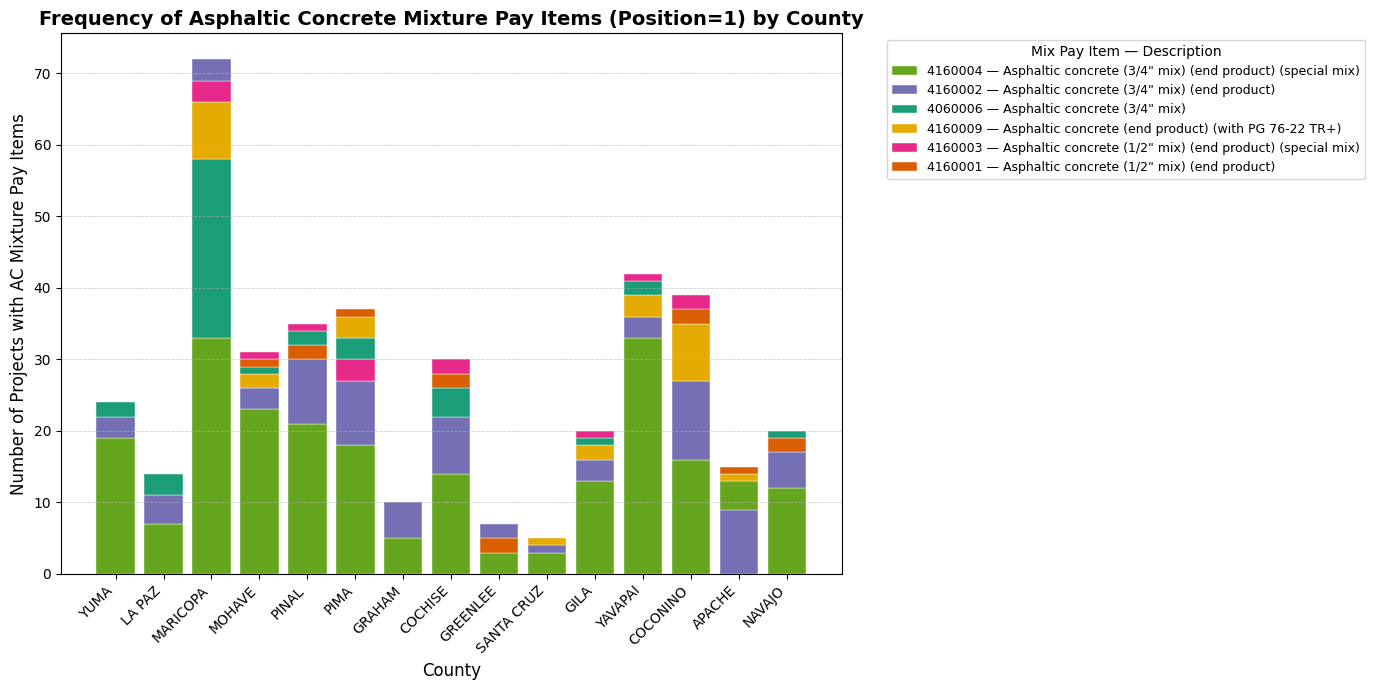

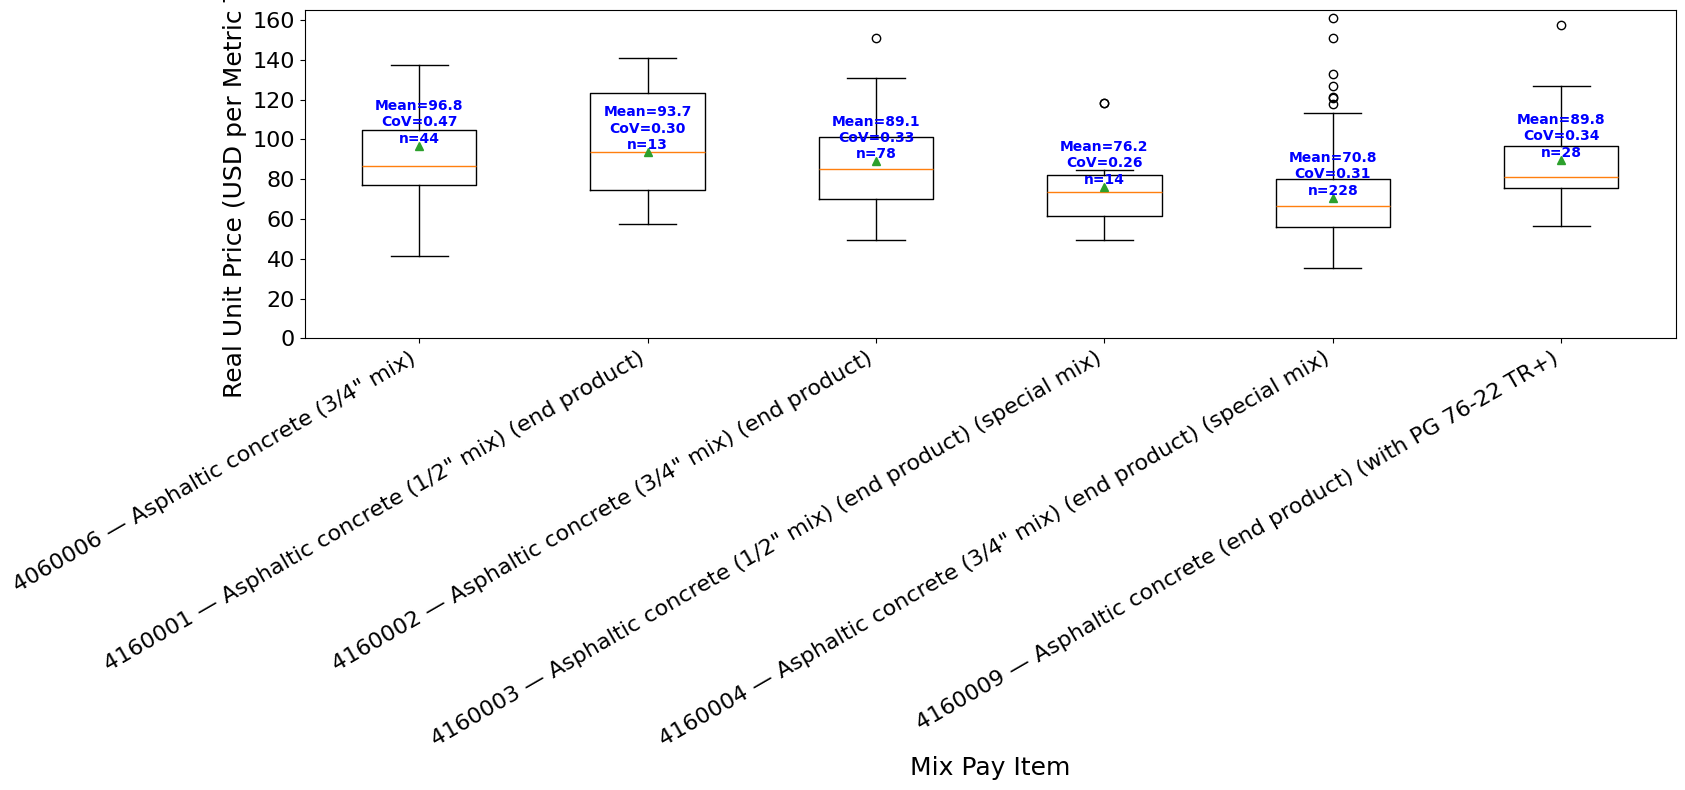

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
MIX_PAYITEM_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)",
    "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)",
    "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)",
    "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
    # "4060008 — Asphaltic concrete (3/4\" mix) (special mix)",  # No jobs in the bid tab data used this pay item
    # "4060015 — Asphaltic concrete (1/2\" mix) (special mix)",
    # "4060021 — Asphaltic concrete (base mix)",
    # "4060023 — Asphaltic concrete (4 in for maintenance)",     # No jobs in the bid tab data used this pay item
    # "4160007 — Asphaltic concrete (base mix) (end product) (special mix)",  # No jobs in the bid tab data used this pay item
    # "4160008 — Asphaltic concrete (base mix) (end product)",  
]

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

COLORS = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666",
    "#1f78b4", "#b2df8a", "#fb9a99", "#ff7f00",
    "#c0c0c0", "#9467bd", "#bcbd22",
]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311

# ============================================================
# HELPERS
# ============================================================
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

def parse_payitem_id(series: pd.Series) -> pd.Series:
    """Extract numeric pay item code from any string/int representation."""
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )

def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def summary_stats(x: pd.Series) -> tuple[float, float, float, int]:
    x = x.dropna()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    std = float(x.std(ddof=0))  # Population std (ddof=0); consistent across all pay item analyses in this notebook
    cov = std / mean if mean != 0 else np.nan
    return mean, std, cov, int(len(x))

# ============================================================
# MAIN: MIX plots (ONLY two plots)
# ============================================================
def plot_mix_frequency_and_boxplot(
    df: pd.DataFrame,
    payitem_labels: list[str],
    county_order: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
) -> None:
    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])

    ids = [lbl.split("—")[0].strip().split()[0] for lbl in payitem_labels]
    id_to_label = {pid: lbl for pid, lbl in zip(ids, payitem_labels)}

    d = df.copy()

    # Position filter
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()

    # PayItem filter (robust to int/string)
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin(ids)].copy()

    # County cleanup
    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])

    # Labels
    d["MixPayItemID"] = d["_PayItemID_str"]
    d["Mix Label"] = d["MixPayItemID"].map(id_to_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No MIX rows found after filtering. Check PayItemIDs and Position==1.")

    # ============================================================
    # 1) Frequency table + stacked bar plot
    # ============================================================
    freq = (
        d.groupby(["County_std", "Mix Label"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
    )
    col_order = [lbl for lbl in payitem_labels if lbl in freq.columns]
    freq = freq[col_order]

    mix_items = freq.columns.tolist()
    color_map = {item: COLORS[i % len(COLORS)] for i, item in enumerate(mix_items)}

    counties = freq.index.tolist()
    x = np.arange(len(counties))

    fig, ax = plt.subplots(figsize=(14, 7))
    seen = set()

    for i, county in enumerate(counties):
        counts = freq.loc[county]
        order = counts.sort_values(ascending=False).index  # most used at bottom
        bottom = 0.0
        for item in order:
            value = float(counts[item])
            if value == 0:
                continue
            label = item if item not in seen else "_nolegend_"
            ax.bar(
                x[i], value, bottom=bottom,
                color=color_map[item], edgecolor="white", linewidth=0.3,
                label=label,
            )
            seen.add(item)
            bottom += value

    ax.set_title("Frequency of Asphaltic Concrete Mixture Pay Items (Position=1) by County",
                 fontsize=14, weight="bold")
    ax.set_xlabel("County", fontsize=12)
    ax.set_ylabel("Number of Projects with AC Mixture Pay Items", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(counties, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.legend(title="Mix Pay Item — Description",
              bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2) Boxplot of real unit prices by pay item (Position=1)
    # ============================================================
    id_sorted = sorted(ids, key=lambda s: int(s))
    data_to_plot, labels, stats = [], [], []

    for pid in id_sorted:
        sub = d.loc[d["MixPayItemID"] == pid, price_col]
        mean, std, cov, n = summary_stats(sub)
        data_to_plot.append(sub.dropna())
        labels.append(id_to_label[pid])
        stats.append((mean, cov, n))

    plt.figure(figsize=(17, 8))
    plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)
    plt.xlabel("Mix Pay Item", fontsize=18)
    plt.ylabel("Real Unit Price (USD per Metric Ton)", fontsize=18)
    #plt.title("Real Unit Price for Asphaltic Concrete Mixture Pay Items - Winner Bidder (2025 Q1)",
              #fontsize=14, fontweight="bold")

    plt.xticks(rotation=30, ha="right", fontsize=16)  # Larger tick labels for readability
    plt.yticks(fontsize=16)
    plt.ylim(0, 165)  # Y-axis capped to 0-165; typical AC mix unit prices are under $165/tonne

    for i, (mean, cov, n) in enumerate(stats, start=1):
        if np.isnan(mean) or n == 0:
            continue
        plt.text(
            i, mean,
            f"Mean={mean:.1f}\nCoV={cov:.2f}\nn={n}",
            ha="center", va="bottom", fontsize=10, color="blue", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (assumes df already exists)
# ============================================================
plot_mix_frequency_and_boxplot(
    df=df,
    payitem_labels=MIX_PAYITEM_LABELS,
    county_order=COUNTY_ORDER,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
)


## Mineral Admixture

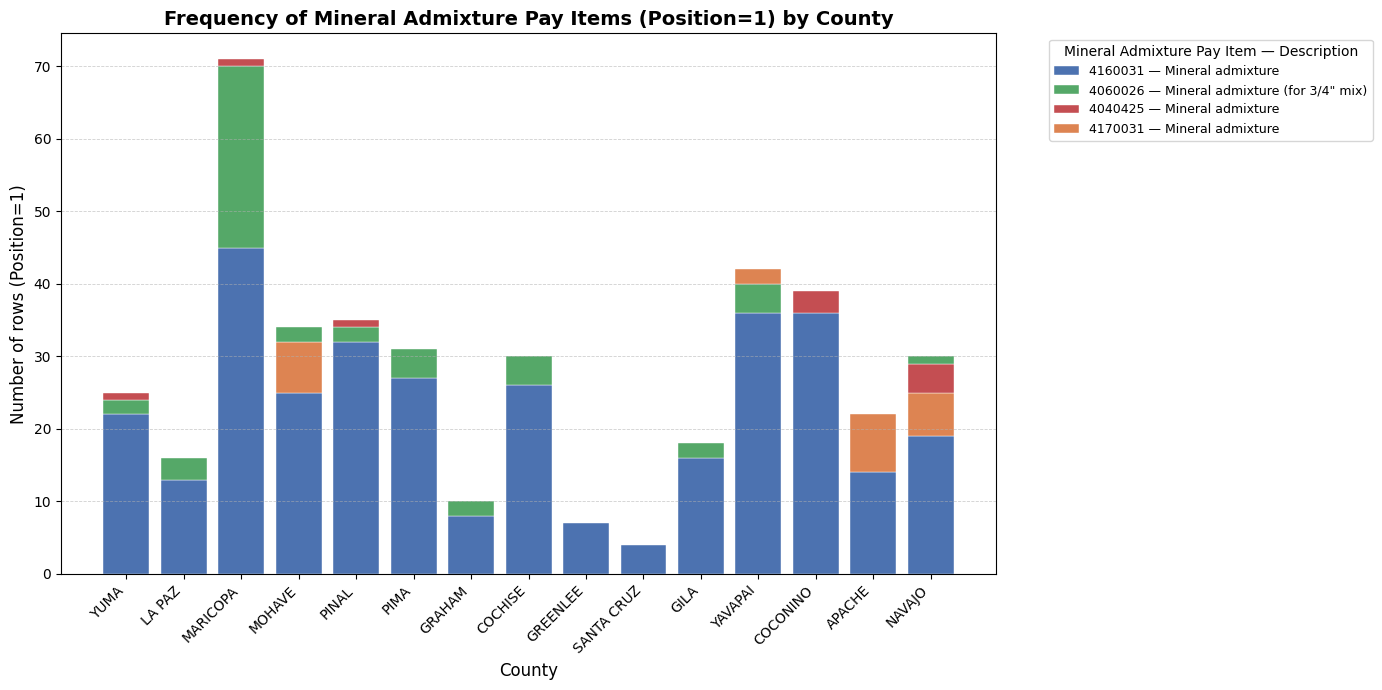

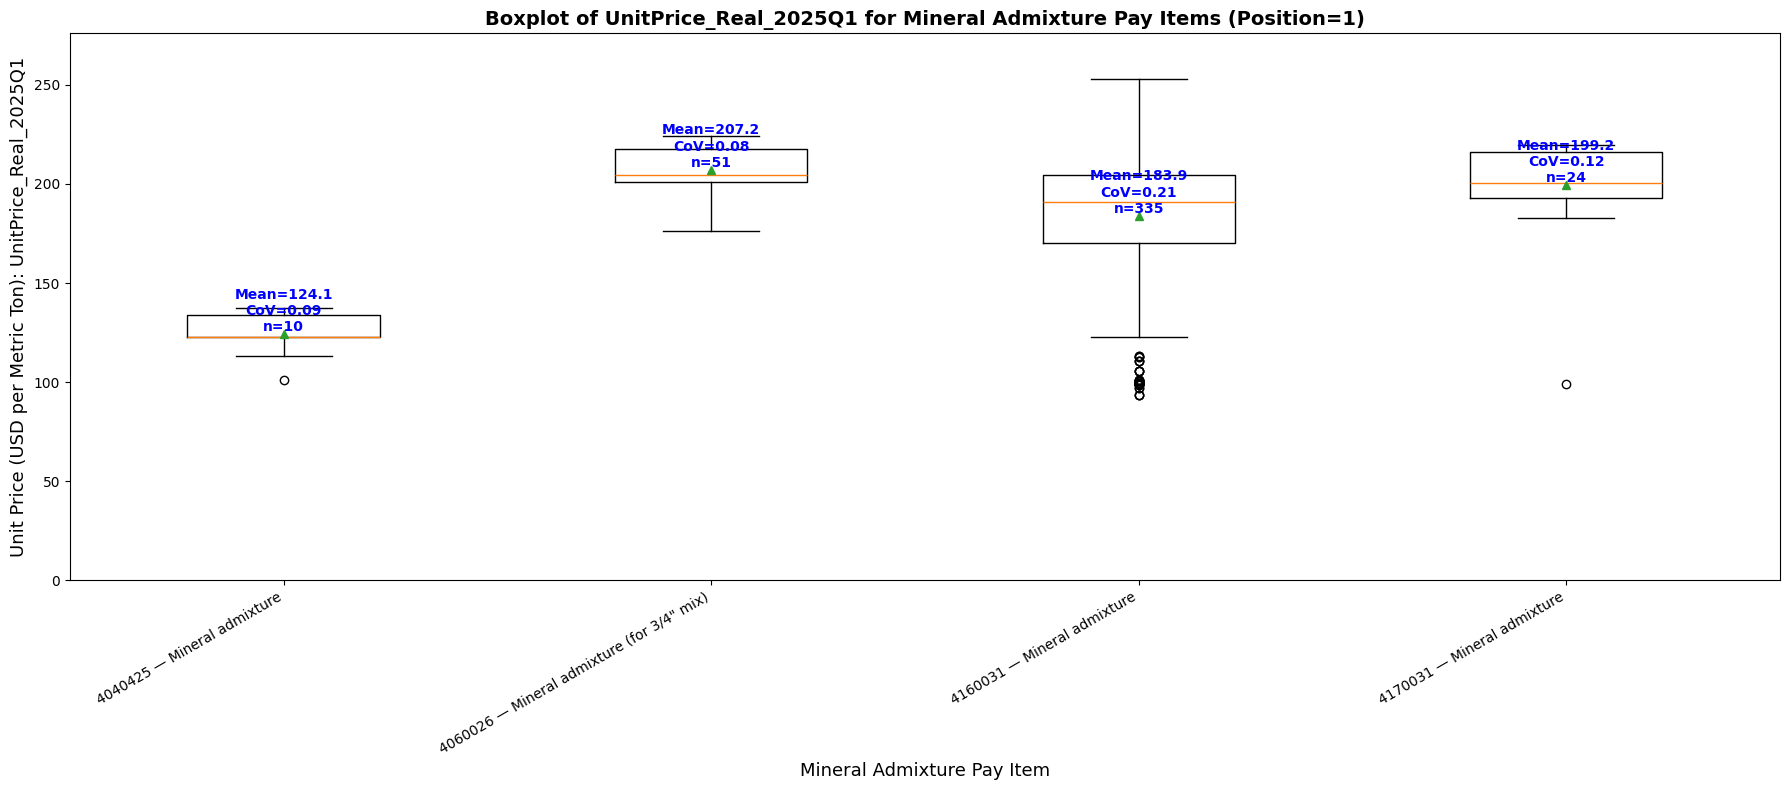

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
MINERAL_ADMIXTURE_LABELS = [
    "4160031 — Mineral admixture",
    "4170031 — Mineral admixture",
    "4060026 — Mineral admixture (for 3/4\" mix)",
    "4040425 — Mineral admixture",
]

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

ADMIX_COLORS = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860"]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311

# ============================================================
# HELPERS
# ============================================================
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

def parse_payitem_id(series: pd.Series) -> pd.Series:
    """Extract numeric pay item code from any string/int representation."""
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )

def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def summary_stats(x: pd.Series) -> tuple[float, float, float, int]:
    x = x.dropna()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    std = float(x.std(ddof=0))  # Population std (ddof=0); consistent across all pay item analyses in this notebook
    cov = std / mean if mean != 0 else np.nan
    return mean, std, cov, int(len(x))

# ============================================================
# MAIN: Mineral Admixture plots (ONLY two plots)
# ============================================================
def plot_mineral_admixture_frequency_and_boxplot(
    df: pd.DataFrame,
    payitem_labels: list[str],
    county_order: list[str],
    colors: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
) -> None:
    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])

    ids = [lbl.split("—")[0].strip().split()[0] for lbl in payitem_labels]
    id_to_label = {pid: lbl for pid, lbl in zip(ids, payitem_labels)}

    d = df.copy()

    # Position filter
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()

    # PayItem filter (robust to int/string)
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin(ids)].copy()

    # County cleanup
    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])

    # Labels
    d["AdmixPayItemID"] = d["_PayItemID_str"]
    d["Admix Label"] = d["AdmixPayItemID"].map(id_to_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No mineral admixture rows found after filtering. Check PayItemIDs and Position==1.")

    # ============================================================
    # 1) Frequency table + stacked bar plot
    # ============================================================
    freq = (
        d.groupby(["County_std", "Admix Label"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
    )
    col_order = [lbl for lbl in payitem_labels if lbl in freq.columns]
    freq = freq[col_order]

    items = freq.columns.tolist()
    color_map = {item: colors[i % len(colors)] for i, item in enumerate(items)}

    counties = freq.index.tolist()
    x = np.arange(len(counties))

    fig, ax = plt.subplots(figsize=(14, 7))
    seen = set()

    for i, county in enumerate(counties):
        counts = freq.loc[county]
        order = counts.sort_values(ascending=False).index
        bottom = 0.0
        for item in order:
            value = float(counts[item])
            if value == 0:
                continue
            label = item if item not in seen else "_nolegend_"
            ax.bar(
                x[i], value, bottom=bottom,
                color=color_map[item], edgecolor="white", linewidth=0.3,
                label=label,
            )
            seen.add(item)
            bottom += value

    ax.set_title("Frequency of Mineral Admixture Pay Items (Position=1) by County",
                 fontsize=14, weight="bold")
    ax.set_xlabel("County", fontsize=12)
    ax.set_ylabel("Number of rows (Position=1)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(counties, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    ax.legend(title="Mineral Admixture Pay Item — Description",
              bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2) Boxplot of real unit prices by pay item (Position=1)
    # ============================================================
    id_sorted = sorted(ids, key=lambda s: int(s))
    data_to_plot, labels, stats = [], [], []

    for pid in id_sorted:
        sub = d.loc[d["AdmixPayItemID"] == pid, price_col]
        mean, std, cov, n = summary_stats(sub)
        data_to_plot.append(sub.dropna())
        labels.append(id_to_label[pid])
        stats.append((mean, cov, n))

    plt.figure(figsize=(18, 8))
    plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)
    plt.xlabel("Mineral Admixture Pay Item", fontsize=13)
    plt.ylabel(f"Unit Price (USD per Metric Ton): {price_col}", fontsize=13)
    plt.title("Boxplot of UnitPrice_Real_2025Q1 for Mineral Admixture Pay Items (Position=1)",
              fontsize=14, fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 276)  # Y-axis capped to 0-276; typical mineral admixture prices are under $276/tonne

    for i, (mean, cov, n) in enumerate(stats, start=1):
        if np.isnan(mean) or n == 0:
            continue
        plt.text(
            i, mean,
            f"Mean={mean:.1f}\nCoV={cov:.2f}\nn={n}",
            ha="center", va="bottom", fontsize=10, color="blue", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (assumes df already exists)
# ============================================================
plot_mineral_admixture_frequency_and_boxplot(
    df=df,
    payitem_labels=MINERAL_ADMIXTURE_LABELS,
    county_order=COUNTY_ORDER,
    colors=ADMIX_COLORS,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
)


## Binder Content

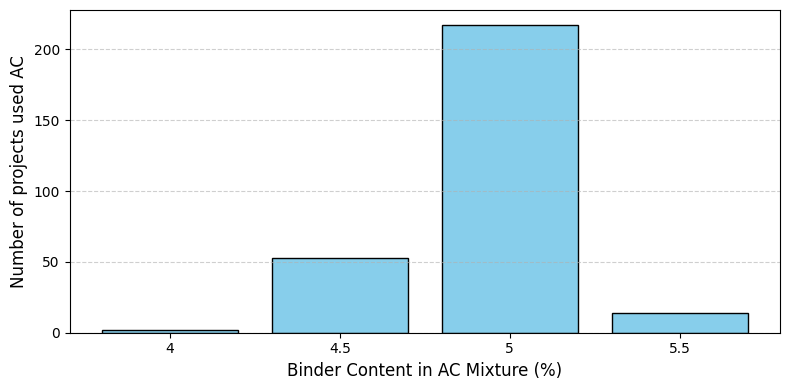

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Binder content distribution for AC projects
#   - computes binder content (%) per job from pay item quantities
#   - outputs ONLY the histogram plot (4–6%)
# ============================================================

# ----------------------------
# Mix pay item labels → IDs
# ----------------------------
MIX_PAYITEM_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)",
    "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)",
    "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)",
    "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
]
mix_payitem_ids = [lbl.split("—")[0].strip() for lbl in MIX_PAYITEM_LABELS]

# Pay items that exclude a job if present
exclude_payitem_ids = ["4070001", "4070002"]

# ----------------------------
# Binder pay item labels → IDs
# ----------------------------
BINDER_PAYITEM_LABELS = [
    "4040256 — ASPHALT BINDER (PG 58-28)",
    "4040262 — ASPHALT BINDER (PG 64-16)",
    "4040264 — ASPHALT BINDER (PG 64-22)",
    "4040266 — ASPHALT BINDER (PG 64-28)",
    "4040270 — ASPHALT BINDER (PG 70-10)",
    "4040274 — ASPHALT BINDER (PG 70-22)",
    "4040282 — ASPHALT BINDER (PG 76-16)",
    "4040284 — ASPHALT BINDER (PG 76-22)",
    "4040286 — ASPHALT BINDER (PG 64-28 TR+)",
    "4040288 — ASPHALT BINDER (PG 70-22 TR+)",
    "4040290 — ASPHALT BINDER (PG 76-22 TR+)",
    "4040230 — ASPHALT BINDER (PG 76-22 TR+SBS)",
]
binder_payitem_ids = [lbl.split("—")[0].strip() for lbl in BINDER_PAYITEM_LABELS]

# Special rule pair
special_mix_id = "4160009"
special_binder_id = "4040230"

# ----------------------------
# Validate df
# ----------------------------
required_cols = ["JobID", "PayItemID", "Quantity"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"df missing required columns: {missing}")

# ----------------------------
# Standardize PayItemID + Quantity once
# ----------------------------
d = df.copy()
d["PayItemID_str"] = (
    d["PayItemID"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.strip()
)
d["Quantity_num"] = pd.to_numeric(d["Quantity"], errors="coerce").fillna(0.0)

# (Optional) If you want Position==1 only, uncomment:
# if "Position" in d.columns:
#     d = d[pd.to_numeric(d["Position"], errors="coerce") == 1].copy()

# ----------------------------
# Determine included JobIDs
#   - must include at least one mix pay item
#   - must NOT include exclude pay items
# ----------------------------
mix_jobids = set(d.loc[d["PayItemID_str"].isin(mix_payitem_ids), "JobID"].unique())
exclude_jobids = set(d.loc[d["PayItemID_str"].isin(exclude_payitem_ids), "JobID"].unique())
final_jobids = mix_jobids - exclude_jobids

# Restrict to included jobs only
d = d[d["JobID"].isin(final_jobids)].copy()

# ----------------------------
# Aggregate quantities per JobID
# ----------------------------
mix_tot = (
    d.loc[d["PayItemID_str"].isin(mix_payitem_ids)]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("TotalMixQty")
)
binder_tot = (
    d.loc[d["PayItemID_str"].isin(binder_payitem_ids)]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("TotalBinderQty")
)

special_mix = (
    d.loc[d["PayItemID_str"] == special_mix_id]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("SpecialMixQty")
)
special_binder = (
    d.loc[d["PayItemID_str"] == special_binder_id]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("SpecialBinderQty")
)

jobs = pd.DataFrame(index=sorted(final_jobids))
jobs = jobs.join([mix_tot, binder_tot, special_mix, special_binder]).fillna(0.0)

jobs["HasSpecialMix"] = jobs["SpecialMixQty"] > 0
jobs["HasSpecialBinder"] = jobs["SpecialBinderQty"] > 0
jobs["HasBothSpecial"] = jobs["HasSpecialMix"] & jobs["HasSpecialBinder"]

jobs["RestMixQty"] = jobs["TotalMixQty"] - jobs["SpecialMixQty"]
jobs["RestBinderQty"] = jobs["TotalBinderQty"] - jobs["SpecialBinderQty"]

def safe_pct(binder_qty: pd.Series, mix_qty: pd.Series) -> np.ndarray:
    return np.where(mix_qty > 0, (binder_qty / mix_qty) * 100.0, np.nan)

# ----------------------------
# Build binder_content_df (but we will not print it)
# ----------------------------
# A) jobs WITHOUT both special → one row/job
a = jobs.loc[~jobs["HasBothSpecial"]]
a_out = pd.DataFrame({
    "JobID": a.index,
    "MixType": "all_mix",
    "TotalMixQty": a["TotalMixQty"].values,
    "TotalBinderQty": a["TotalBinderQty"].values,
    "BinderContent(%)": safe_pct(a["TotalBinderQty"], a["TotalMixQty"]),
})

# B1) jobs WITH both special → special_only row
b = jobs.loc[jobs["HasBothSpecial"]]
b_special = pd.DataFrame({
    "JobID": b.index,
    "MixType": "special_only",
    "TotalMixQty": b["SpecialMixQty"].values,
    "TotalBinderQty": b["SpecialBinderQty"].values,
    "BinderContent(%)": safe_pct(b["SpecialBinderQty"], b["SpecialMixQty"]),
})

# B2) jobs WITH both special → other_mix row (only if there is remaining qty)
has_rest = (b["RestMixQty"] > 0) | (b["RestBinderQty"] > 0)
b2 = b.loc[has_rest]
b_other = pd.DataFrame({
    "JobID": b2.index,
    "MixType": "other_mix",
    "TotalMixQty": b2["RestMixQty"].values,
    "TotalBinderQty": b2["RestBinderQty"].values,
    "BinderContent(%)": safe_pct(b2["RestBinderQty"], b2["RestMixQty"]),
})

binder_content_df = pd.concat([a_out, b_special, b_other], ignore_index=True)

# ----------------------------
# Plot ONLY: histogram for 4% to 6%
# ----------------------------
bc = (
    binder_content_df["BinderContent(%)"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
bc_4to6 = bc[(bc >= 4) & (bc <= 6)]

bins = [4, 4.5, 5, 5.5, 6]
labels = ["4", "4.5", "5", "5.5"]
counts, _ = np.histogram(bc_4to6, bins=bins)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, counts, width=0.8, color="skyblue", edgecolor="black")

ax.set_xlabel("Binder Content in AC Mixture (%)", fontsize=12)
ax.set_ylabel("Number of projects used AC", fontsize=12)
#ax.set_title("Distribution of Binder Content Percentage for AC Projects (4–6%)",
             #fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


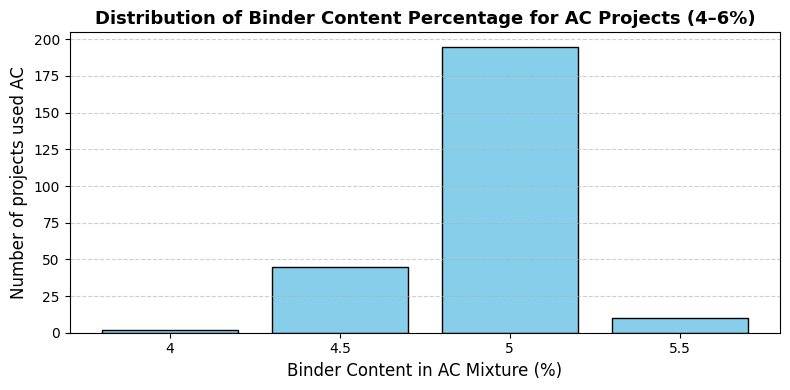

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Binder content distribution for AC projects
#   - computes binder content (%) per job from pay item quantities
#   - outputs ONLY the histogram plot (4–6%)
# ============================================================

# ----------------------------
# Mix pay item labels → IDs
# ----------------------------
MIX_PAYITEM_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)",
    "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)",
    "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)",
    "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
]
mix_payitem_ids = [lbl.split("—")[0].strip() for lbl in MIX_PAYITEM_LABELS]

# Pay items that exclude a job if present
exclude_payitem_ids = ["4070001", "4070002", "4040159", "4040162"]

# ----------------------------
# Binder pay item labels → IDs
# ----------------------------
BINDER_PAYITEM_LABELS = [
    "4040256 — ASPHALT BINDER (PG 58-28)",
    "4040262 — ASPHALT BINDER (PG 64-16)",
    "4040264 — ASPHALT BINDER (PG 64-22)",
    "4040266 — ASPHALT BINDER (PG 64-28)",
    "4040270 — ASPHALT BINDER (PG 70-10)",
    "4040274 — ASPHALT BINDER (PG 70-22)",
    "4040282 — ASPHALT BINDER (PG 76-16)",
    "4040284 — ASPHALT BINDER (PG 76-22)",
    "4040286 — ASPHALT BINDER (PG 64-28 TR+)",
    "4040288 — ASPHALT BINDER (PG 70-22 TR+)",
    "4040290 — ASPHALT BINDER (PG 76-22 TR+)",
    "4040230 — ASPHALT BINDER (PG 76-22 TR+SBS)",
]
binder_payitem_ids = [lbl.split("—")[0].strip() for lbl in BINDER_PAYITEM_LABELS]

# Special rule pair
special_mix_id = "4160009"
special_binder_id = "4040230"

# ----------------------------
# Validate df
# ----------------------------
required_cols = ["JobID", "PayItemID", "Quantity"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"df missing required columns: {missing}")

# ----------------------------
# Standardize PayItemID + Quantity once
# ----------------------------
d = df.copy()
d["PayItemID_str"] = (
    d["PayItemID"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.strip()
)
d["Quantity_num"] = pd.to_numeric(d["Quantity"], errors="coerce").fillna(0.0)

# (Optional) If you want Position==1 only, uncomment:
# if "Position" in d.columns:
#     d = d[pd.to_numeric(d["Position"], errors="coerce") == 1].copy()

# ----------------------------
# Determine included JobIDs
#   - must include at least one mix pay item
#   - must NOT include exclude pay items
# ----------------------------
mix_jobids = set(d.loc[d["PayItemID_str"].isin(mix_payitem_ids), "JobID"].unique())
exclude_jobids = set(d.loc[d["PayItemID_str"].isin(exclude_payitem_ids), "JobID"].unique())
final_jobids = mix_jobids - exclude_jobids

# Restrict to included jobs only
d = d[d["JobID"].isin(final_jobids)].copy()

# ----------------------------
# Aggregate quantities per JobID
# ----------------------------
mix_tot = (
    d.loc[d["PayItemID_str"].isin(mix_payitem_ids)]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("TotalMixQty")
)
binder_tot = (
    d.loc[d["PayItemID_str"].isin(binder_payitem_ids)]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("TotalBinderQty")
)

special_mix = (
    d.loc[d["PayItemID_str"] == special_mix_id]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("SpecialMixQty")
)
special_binder = (
    d.loc[d["PayItemID_str"] == special_binder_id]
     .groupby("JobID")["Quantity_num"].sum()
     .rename("SpecialBinderQty")
)

jobs = pd.DataFrame(index=sorted(final_jobids))
jobs = jobs.join([mix_tot, binder_tot, special_mix, special_binder]).fillna(0.0)

jobs["HasSpecialMix"] = jobs["SpecialMixQty"] > 0
jobs["HasSpecialBinder"] = jobs["SpecialBinderQty"] > 0
jobs["HasBothSpecial"] = jobs["HasSpecialMix"] & jobs["HasSpecialBinder"]

jobs["RestMixQty"] = jobs["TotalMixQty"] - jobs["SpecialMixQty"]
jobs["RestBinderQty"] = jobs["TotalBinderQty"] - jobs["SpecialBinderQty"]

def safe_pct(binder_qty: pd.Series, mix_qty: pd.Series) -> np.ndarray:
    return np.where(mix_qty > 0, (binder_qty / mix_qty) * 100.0, np.nan)

# ----------------------------
# Build binder_content_df (but we will not print it)
# ----------------------------
# A) jobs WITHOUT both special → one row/job
a = jobs.loc[~jobs["HasBothSpecial"]]
a_out = pd.DataFrame({
    "JobID": a.index,
    "MixType": "all_mix",
    "TotalMixQty": a["TotalMixQty"].values,
    "TotalBinderQty": a["TotalBinderQty"].values,
    "BinderContent(%)": safe_pct(a["TotalBinderQty"], a["TotalMixQty"]),
})

# B1) jobs WITH both special → special_only row
b = jobs.loc[jobs["HasBothSpecial"]]
b_special = pd.DataFrame({
    "JobID": b.index,
    "MixType": "special_only",
    "TotalMixQty": b["SpecialMixQty"].values,
    "TotalBinderQty": b["SpecialBinderQty"].values,
    "BinderContent(%)": safe_pct(b["SpecialBinderQty"], b["SpecialMixQty"]),
})

# B2) jobs WITH both special → other_mix row (only if there is remaining qty)
has_rest = (b["RestMixQty"] > 0) | (b["RestBinderQty"] > 0)
b2 = b.loc[has_rest]
b_other = pd.DataFrame({
    "JobID": b2.index,
    "MixType": "other_mix",
    "TotalMixQty": b2["RestMixQty"].values,
    "TotalBinderQty": b2["RestBinderQty"].values,
    "BinderContent(%)": safe_pct(b2["RestBinderQty"], b2["RestMixQty"]),
})

binder_content_df = pd.concat([a_out, b_special, b_other], ignore_index=True)

# ----------------------------
# Plot ONLY: histogram for 4% to 6%
# ----------------------------
bc = (
    binder_content_df["BinderContent(%)"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
bc_4to6 = bc[(bc >= 4) & (bc <= 6)]

bins = [4, 4.5, 5, 5.5, 6]
labels = ["4", "4.5", "5", "5.5"]
counts, _ = np.histogram(bc_4to6, bins=bins)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, counts, width=0.8, color="skyblue", edgecolor="black")

ax.set_xlabel("Binder Content in AC Mixture (%)", fontsize=12)
ax.set_ylabel("Number of projects used AC", fontsize=12)
ax.set_title("Distribution of Binder Content Percentage for AC Projects (4–6%)",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


# FR

## Binder

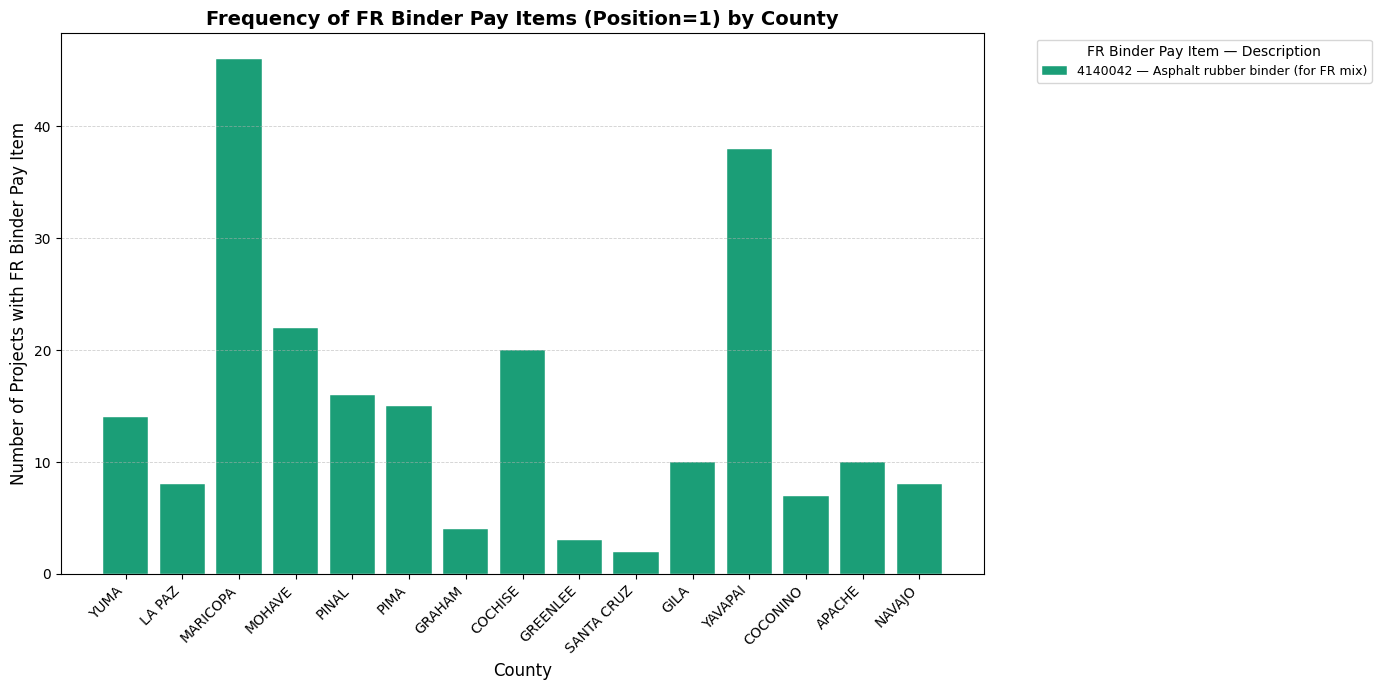

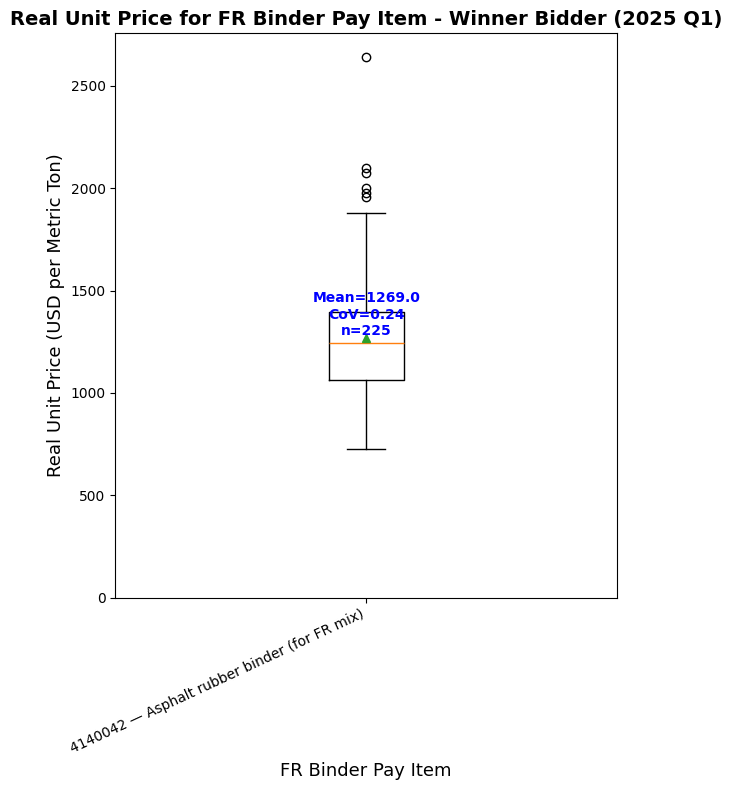

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FR Binder analysis (ONLY TWO PLOTS)
#   1) County frequency stacked bar (Position=1)
#   2) Boxplot of UnitPrice_Real_2025Q1 (Position=1)
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FR_BINDER_ITEMS = [
    {
        "id": "4140042",
        "label": "4140042 — Asphalt rubber binder (for FR mix)",
        "desc": "Asphalt rubber binder for Friction Rubber (FR) mix",
    }
]

FR_BINDER_IDS = [item["id"] for item in FR_BINDER_ITEMS]
FR_BINDER_LABELS = [item["label"] for item in FR_BINDER_ITEMS]
FR_BINDER_ID_TO_LABEL = {item["id"]: item["label"] for item in FR_BINDER_ITEMS}

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

FR_COLORS = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666",
    "#1f78b4", "#b2df8a", "#fb9a99", "#ff7f00",
]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311

# ----------------------------
# HELPERS
# ----------------------------
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

def parse_payitem_id(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )

def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def summary_stats(x: pd.Series) -> tuple[float, float, float, int]:
    x = x.dropna()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    std = float(x.std(ddof=0))
    cov = std / mean if mean != 0 else np.nan
    return mean, std, cov, int(len(x))

# ----------------------------
# MAIN
# ----------------------------
def plot_fr_binder_frequency_and_boxplot(
    df: pd.DataFrame,
    binder_ids: list[str],
    binder_id_to_label: dict[str, str],
    binder_labels_order: list[str],
    county_order: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
) -> None:
    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])

    d = df.copy()

    # Position filter
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()

    # PayItemID robust parse + filter
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin([str(x) for x in binder_ids])].copy()

    # County cleanup
    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])

    # Label
    d["FRBinderPayItemID"] = d["_PayItemID_str"]
    d["FRBinder Label"] = d["FRBinderPayItemID"].map(binder_id_to_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No FR binder rows found after filtering. Check PayItemID(s) and Position==1.")

    # ============================================================
    # 1) Frequency stacked bar by county
    # ============================================================
    freq = (
        d.groupby(["County_std", "FRBinder Label"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
    )

    col_order = [lbl for lbl in binder_labels_order if lbl in freq.columns]
    freq = freq[col_order]

    items = freq.columns.tolist()
    color_map = {item: FR_COLORS[i % len(FR_COLORS)] for i, item in enumerate(items)}

    counties = freq.index.tolist()
    x = np.arange(len(counties))

    fig, ax = plt.subplots(figsize=(14, 7))
    seen = set()

    for i, county in enumerate(counties):
        counts = freq.loc[county]
        order = counts.sort_values(ascending=False).index
        bottom = 0.0
        for item in order:
            value = float(counts[item])
            if value == 0:
                continue
            label = item if item not in seen else "_nolegend_"
            ax.bar(
                x[i], value, bottom=bottom,
                color=color_map[item], edgecolor="white", linewidth=0.3,
                label=label
            )
            seen.add(item)
            bottom += value

    ax.set_title("Frequency of FR Binder Pay Items (Position=1) by County", fontsize=14, weight="bold")
    ax.set_xlabel("County", fontsize=12)
    ax.set_ylabel("Number of Projects with FR Binder Pay Item", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(counties, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    ax.legend(title="FR Binder Pay Item — Description",
              bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2) Boxplot of UnitPrice_Real_2025Q1
    # ============================================================
    # keep order by numeric PayItemID (stable even if you add more later)
    ids_sorted = sorted([str(x) for x in binder_ids], key=lambda s: int(s))

    data_to_plot, labels, stats = [], [], []
    for pid in ids_sorted:
        sub = d.loc[d["FRBinderPayItemID"] == pid, price_col]
        mean, std, cov, n = summary_stats(sub)
        data_to_plot.append(sub.dropna())
        labels.append(binder_id_to_label[pid])
        stats.append((mean, cov, n))

    # width scales with number of items
    fig_w = max(6, 1.6 * len(labels))
    plt.figure(figsize=(fig_w, 8))
    plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)

    plt.xlabel("FR Binder Pay Item", fontsize=13)
    plt.ylabel("Real Unit Price (USD per Metric Ton)", fontsize=13)
    plt.title("Real Unit Price for FR Binder Pay Item - Winner Bidder (2025 Q1)",
              fontsize=14, fontweight="bold")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 2756)  # Y-axis capped to 0-2756 USD/tonne; FR binder prices span a wider range than standard AC binder

    for i, (mean, cov, n) in enumerate(stats, start=1):
        if np.isnan(mean) or n == 0:
            continue
        plt.text(
            i, mean,
            f"Mean={mean:.1f}\nCoV={cov:.2f}\nn={n}",
            ha="center", va="bottom", fontsize=10, color="blue", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (assumes df already exists)
# ============================================================
plot_fr_binder_frequency_and_boxplot(
    df=df,
    binder_ids=FR_BINDER_IDS,
    binder_id_to_label=FR_BINDER_ID_TO_LABEL,
    binder_labels_order=FR_BINDER_LABELS,
    county_order=COUNTY_ORDER,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
)


## Mixture

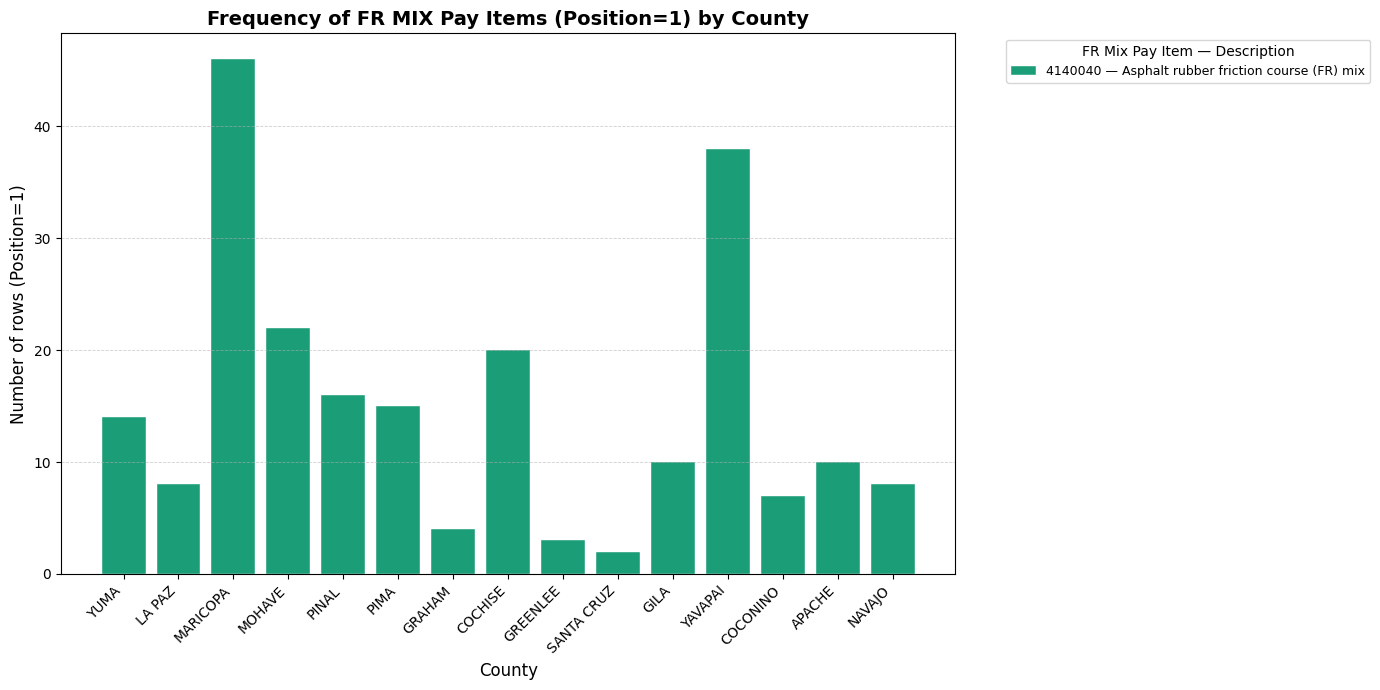

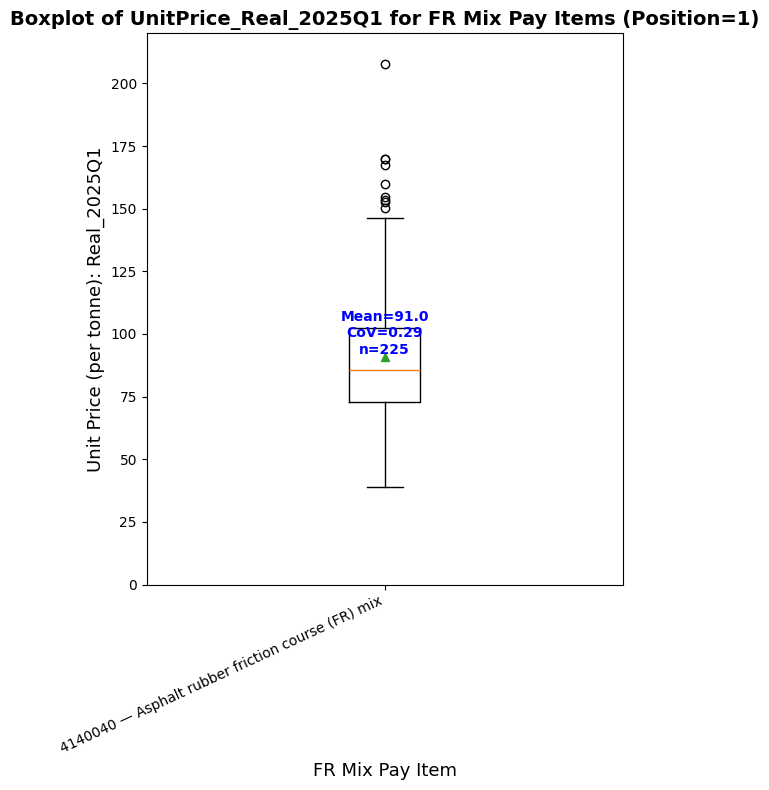

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FR MIX analysis (ONLY TWO PLOTS)
#   1) County frequency stacked bar (Position=1)
#   2) Boxplot of UnitPrice_Real_2025Q1 (Position=1)
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FR_MIX_ITEMS = [
    {
        "id": "4140040",
        "label": "4140040 — Asphalt rubber friction course (FR) mix",
        "desc": "Asphalt rubber friction course (FR) mix",
    }
    # Add more FR mix items here if needed
]

FR_MIX_IDS = [item["id"] for item in FR_MIX_ITEMS]
FR_MIX_LABELS = [item["label"] for item in FR_MIX_ITEMS]
FR_MIX_ID_TO_LABEL = {item["id"]: item["label"] for item in FR_MIX_ITEMS}

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

COLORS = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666",
    "#1f78b4", "#b2df8a", "#fb9a99", "#ff7f00",
    "#c0c0c0", "#9467bd", "#bcbd22",
]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311

# ----------------------------
# HELPERS
# ----------------------------
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

def parse_payitem_id(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )

def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def summary_stats(x: pd.Series) -> tuple[float, float, float, int]:
    x = x.dropna()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    std = float(x.std(ddof=0))
    cov = std / mean if mean != 0 else np.nan
    return mean, std, cov, int(len(x))

# ----------------------------
# MAIN
# ----------------------------
def plot_fr_mix_frequency_and_boxplot(
    df: pd.DataFrame,
    mix_ids: list[str],
    mix_id_to_label: dict[str, str],
    mix_labels_order: list[str],
    county_order: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
) -> None:
    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])

    d = df.copy()

    # Position filter
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()

    # PayItemID robust parse + filter
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin([str(x) for x in mix_ids])].copy()

    # County cleanup
    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])

    # Label
    d["FRMixPayItemID"] = d["_PayItemID_str"]
    d["FR Mix Label"] = d["FRMixPayItemID"].map(mix_id_to_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No FR mix rows found after filtering. Check PayItemID(s) and Position==1.")

    # ============================================================
    # 1) Frequency stacked bar by county
    # ============================================================
    freq = (
        d.groupby(["County_std", "FR Mix Label"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
    )

    col_order = [lbl for lbl in mix_labels_order if lbl in freq.columns]
    freq = freq[col_order]

    items = freq.columns.tolist()
    color_map = {item: COLORS[i % len(COLORS)] for i, item in enumerate(items)}

    counties = freq.index.tolist()
    x = np.arange(len(counties))

    fig, ax = plt.subplots(figsize=(14, 7))
    seen = set()

    for i, county in enumerate(counties):
        counts = freq.loc[county]
        order = counts.sort_values(ascending=False).index
        bottom = 0.0
        for item in order:
            value = float(counts[item])
            if value == 0:
                continue
            label = item if item not in seen else "_nolegend_"
            ax.bar(
                x[i], value, bottom=bottom,
                color=color_map[item], edgecolor="white", linewidth=0.3,
                label=label
            )
            seen.add(item)
            bottom += value

    ax.set_title("Frequency of FR MIX Pay Items (Position=1) by County", fontsize=14, weight="bold")
    ax.set_xlabel("County", fontsize=12)
    ax.set_ylabel("Number of rows (Position=1)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(counties, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    ax.legend(title="FR Mix Pay Item — Description",
              bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2) Boxplot of UnitPrice_Real_2025Q1
    # ============================================================
    ids_sorted = sorted([str(x) for x in mix_ids], key=lambda s: int(s))

    data_to_plot, labels, stats = [], [], []
    for pid in ids_sorted:
        sub = d.loc[d["FRMixPayItemID"] == pid, price_col]
        mean, std, cov, n = summary_stats(sub)
        data_to_plot.append(sub.dropna())
        labels.append(mix_id_to_label[pid])
        stats.append((mean, cov, n))

    fig_w = max(6, 1.6 * len(labels))
    plt.figure(figsize=(fig_w, 8))
    plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)

    plt.xlabel("FR Mix Pay Item", fontsize=13)
    plt.ylabel("Unit Price (per tonne): Real_2025Q1", fontsize=13)
    plt.title("Boxplot of UnitPrice_Real_2025Q1 for FR Mix Pay Items (Position=1)",
              fontsize=14, fontweight="bold")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 220)  # Y-axis capped to 0-220; typical FR mix unit prices are under $220/tonne

    for i, (mean, cov, n) in enumerate(stats, start=1):
        if np.isnan(mean) or n == 0:
            continue
        plt.text(
            i, mean,
            f"Mean={mean:.1f}\nCoV={cov:.2f}\nn={n}",
            ha="center", va="bottom", fontsize=10, color="blue", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (assumes df already exists)
# ============================================================
plot_fr_mix_frequency_and_boxplot(
    df=df,
    mix_ids=FR_MIX_IDS,
    mix_id_to_label=FR_MIX_ID_TO_LABEL,
    mix_labels_order=FR_MIX_LABELS,
    county_order=COUNTY_ORDER,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
)


## Mineral Admixture

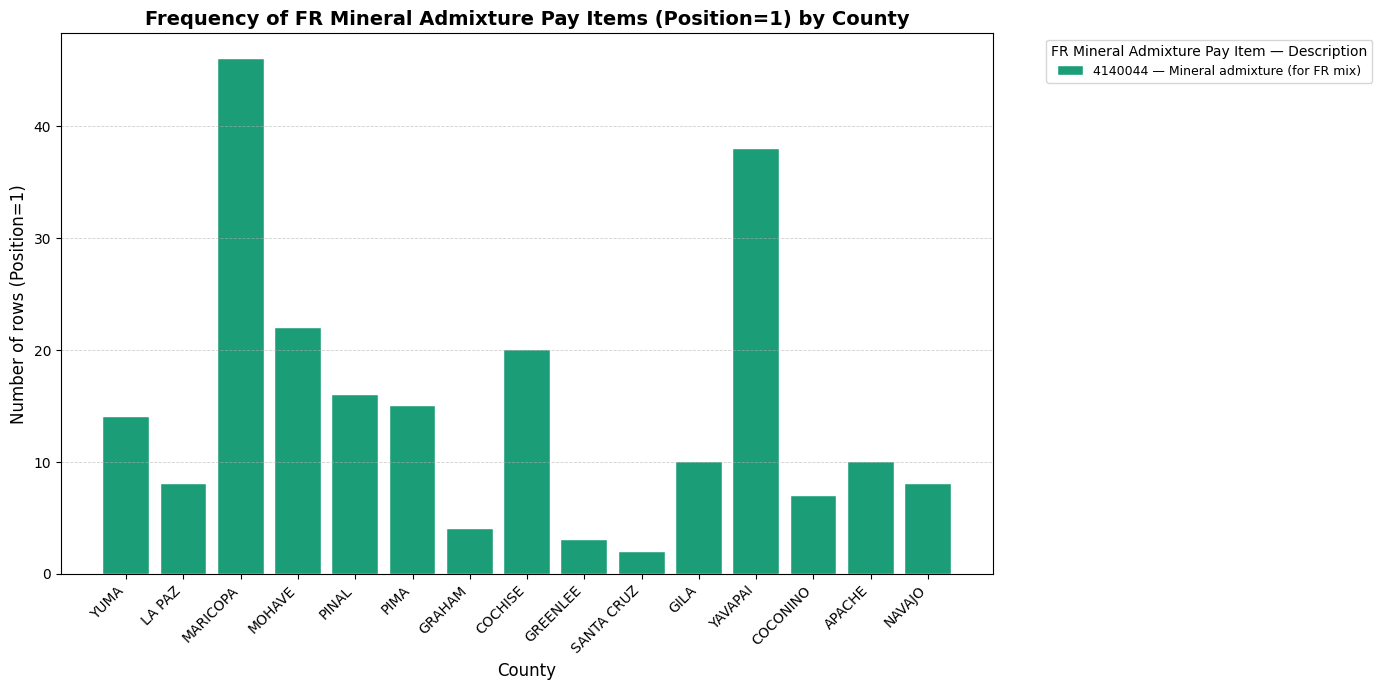

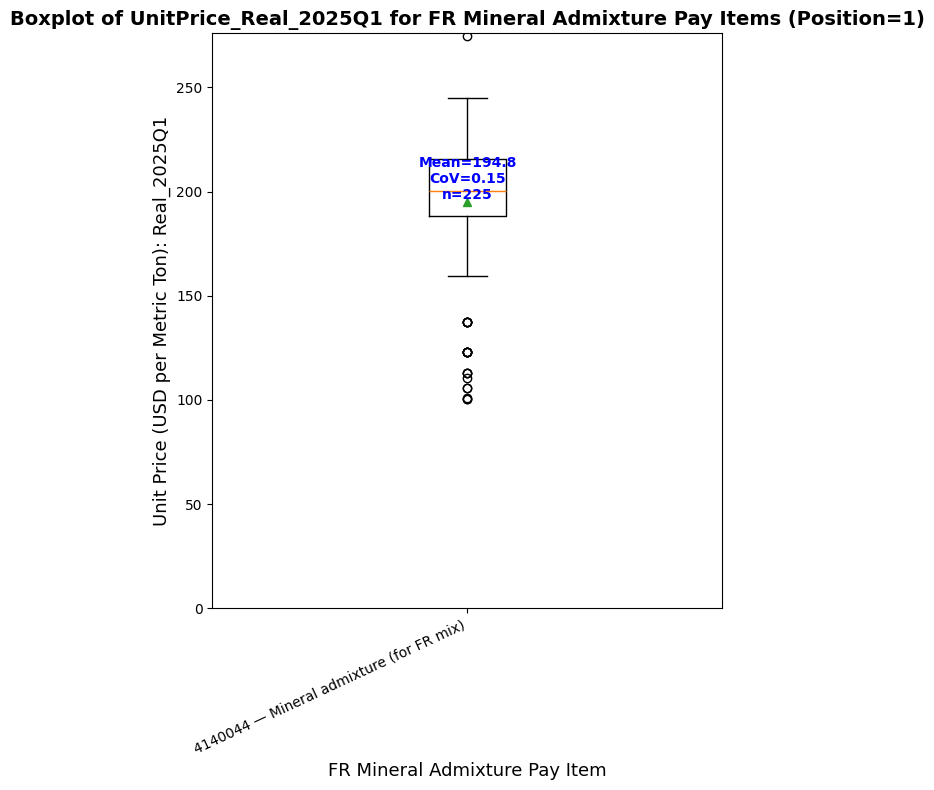

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FR Mineral Admixture analysis (ONLY TWO PLOTS)
#   1) County frequency stacked bar (Position=1)
#   2) Boxplot of UnitPrice_Real_2025Q1 (Position=1)
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
FR_MINERAL_ADMIX_ITEMS = [
    {
        "id": "4140044",
        "label": "4140044 — Mineral admixture (for FR mix)",
        "desc": "Mineral admixture (for FR mix)",
    }
    # Add more FR mineral admixture items here if needed
]

FR_MINERAL_ADMIX_IDS = [item["id"] for item in FR_MINERAL_ADMIX_ITEMS]
FR_MINERAL_ADMIX_LABELS = [item["label"] for item in FR_MINERAL_ADMIX_ITEMS]
FR_MINERAL_ADMIX_ID_TO_LABEL = {item["id"]: item["label"] for item in FR_MINERAL_ADMIX_ITEMS}

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

COLORS = [
    "#1b9e77", "#d95f02", "#7570b3", "#e7298a",
    "#66a61e", "#e6ab02", "#a6761d", "#666666",
    "#1f78b4", "#b2df8a", "#fb9a99", "#ff7f00",
    "#c0c0c0", "#9467bd", "#bcbd22",
]

USD_PER_TON_TO_USD_PER_TONNE = 1.102311  # 1 US short ton (2000 lb) = 0.907185 metric tonnes; $/tonne = $/ton x 1.102311

# ----------------------------
# HELPERS
# ----------------------------
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

def parse_payitem_id(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )

def standardize_county(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper()

def summary_stats(x: pd.Series) -> tuple[float, float, float, int]:
    x = x.dropna()
    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    std = float(x.std(ddof=0))
    cov = std / mean if mean != 0 else np.nan
    return mean, std, cov, int(len(x))

# ----------------------------
# MAIN
# ----------------------------
def plot_fr_mineral_admix_frequency_and_boxplot(
    df: pd.DataFrame,
    item_ids: list[str],
    id_to_label: dict[str, str],
    labels_order: list[str],
    county_order: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    pos_col: str = "Position",
    county_col: str = "County",
    pos_value: int = 1,
) -> None:
    ensure_required_cols(df, [payitem_col, pos_col, county_col, price_col])

    d = df.copy()

    # Position filter
    d["_PosNum"] = pd.to_numeric(d[pos_col], errors="coerce")
    d = d[d["_PosNum"] == pos_value].copy()

    # PayItemID robust parse + filter
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])
    d = d[d["_PayItemID_str"].isin([str(x) for x in item_ids])].copy()

    # County cleanup
    d = d[d[county_col].notna()].copy()
    d["County_std"] = standardize_county(d[county_col])

    # Label
    d["FRMinAdPayItemID"] = d["_PayItemID_str"]
    d["FR Mineral Admix Label"] = d["FRMinAdPayItemID"].map(id_to_label)

    # Convert US short-ton unit price to SI (USD per metric tonne)
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce") * USD_PER_TON_TO_USD_PER_TONNE

    if d.empty:
        raise ValueError("No FR mineral admixture rows found after filtering. Check PayItemID(s) and Position==1.")

    # ============================================================
    # 1) Frequency stacked bar by county
    # ============================================================
    freq = (
        d.groupby(["County_std", "FR Mineral Admix Label"])
         .size()
         .unstack(fill_value=0)
         .reindex(county_order)
         .fillna(0)
    )

    col_order = [lbl for lbl in labels_order if lbl in freq.columns]
    freq = freq[col_order]

    items = freq.columns.tolist()
    color_map = {item: COLORS[i % len(COLORS)] for i, item in enumerate(items)}

    counties = freq.index.tolist()
    x = np.arange(len(counties))

    fig, ax = plt.subplots(figsize=(14, 7))
    seen = set()

    for i, county in enumerate(counties):
        counts = freq.loc[county]
        order = counts.sort_values(ascending=False).index
        bottom = 0.0
        for item in order:
            value = float(counts[item])
            if value == 0:
                continue
            label = item if item not in seen else "_nolegend_"
            ax.bar(
                x[i], value, bottom=bottom,
                color=color_map[item], edgecolor="white", linewidth=0.3,
                label=label
            )
            seen.add(item)
            bottom += value

    ax.set_title("Frequency of FR Mineral Admixture Pay Items (Position=1) by County",
                 fontsize=14, weight="bold")
    ax.set_xlabel("County", fontsize=12)
    ax.set_ylabel("Number of rows (Position=1)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(counties, rotation=45, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

    ax.legend(title="FR Mineral Admixture Pay Item — Description",
              bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2) Boxplot of UnitPrice_Real_2025Q1
    # ============================================================
    ids_sorted = sorted([str(x) for x in item_ids], key=lambda s: int(s))

    data_to_plot, labels, stats = [], [], []
    for pid in ids_sorted:
        sub = d.loc[d["FRMinAdPayItemID"] == pid, price_col]
        mean, std, cov, n = summary_stats(sub)
        data_to_plot.append(sub.dropna())
        labels.append(id_to_label[pid])
        stats.append((mean, cov, n))

    fig_w = max(6, 1.6 * len(labels))
    plt.figure(figsize=(fig_w, 8))
    plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)

    plt.xlabel("FR Mineral Admixture Pay Item", fontsize=13)
    plt.ylabel("Unit Price (USD per Metric Ton): Real_2025Q1", fontsize=13)
    plt.title("Boxplot of UnitPrice_Real_2025Q1 for FR Mineral Admixture Pay Items (Position=1)",
              fontsize=14, fontweight="bold")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 276)  # Y-axis capped to 0-276; typical mineral admixture prices are under $276/tonne

    for i, (mean, cov, n) in enumerate(stats, start=1):
        if np.isnan(mean) or n == 0:
            continue
        plt.text(
            i, mean,
            f"Mean={mean:.1f}\nCoV={cov:.2f}\nn={n}",
            ha="center", va="bottom", fontsize=10, color="blue", fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (assumes df already exists)
# ============================================================
plot_fr_mineral_admix_frequency_and_boxplot(
    df=df,
    item_ids=FR_MINERAL_ADMIX_IDS,
    id_to_label=FR_MINERAL_ADMIX_ID_TO_LABEL,
    labels_order=FR_MINERAL_ADMIX_LABELS,
    county_order=COUNTY_ORDER,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    pos_col="Position",
    county_col="County",
)


## Binder Content

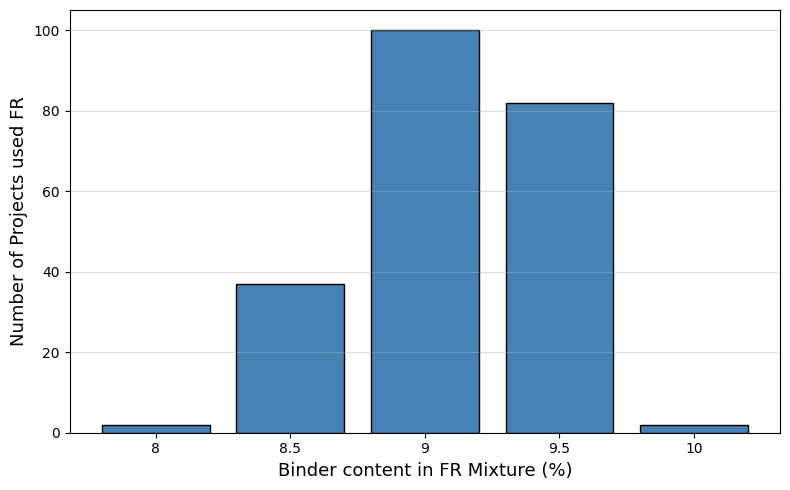

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2857838642.py:134: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["County", "Bin"])


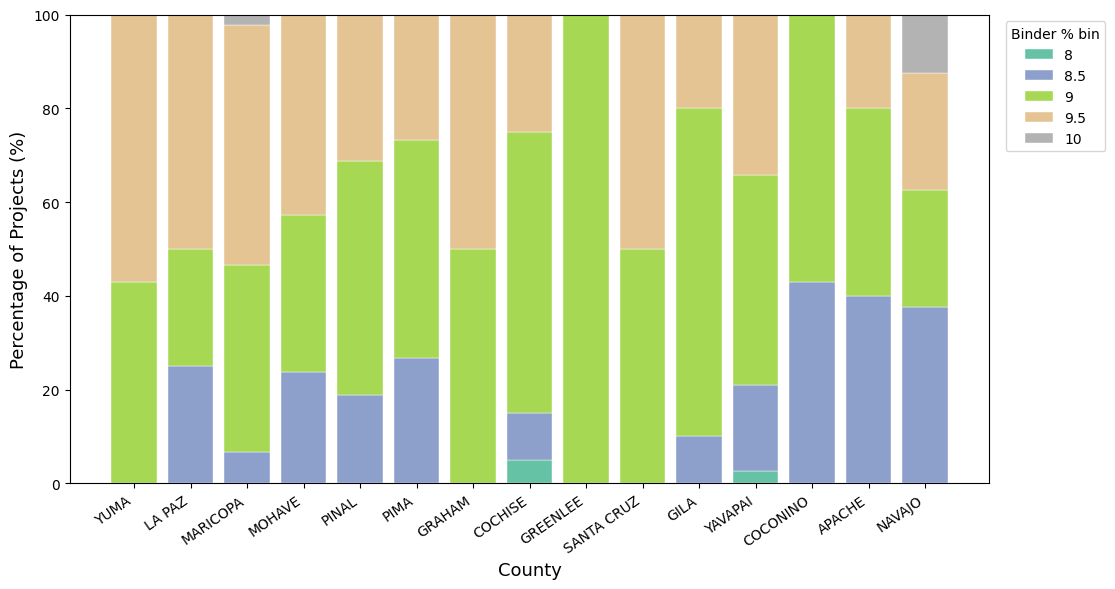

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
FR_MIX_ID = "4140040"
FR_BINDER_ID = "4140042"
FR_MINAD_ID = "4140044"
FR_IDS = [FR_MIX_ID, FR_BINDER_ID, FR_MINAD_ID]

BIN_EDGES = np.array([8, 8.5, 9, 9.5, 10, 10.5])
BIN_LABELS = ["8", "8.5", "9", "9.5", "10"]

COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

# ============================================================
# VALIDATE INPUT
# ============================================================
required_cols = ["JobID", "PayItemID", "Quantity", "County"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"df missing required columns: {missing}")

# ============================================================
# STANDARDIZE DATA
# ============================================================
d = df.copy()
d["PayItemID_str"] = (
    d["PayItemID"].astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.strip()
)
d["Quantity_num"] = pd.to_numeric(d["Quantity"], errors="coerce").fillna(0.0)
d["County_std"] = d["County"].astype(str).str.strip().str.upper()

# ============================================================
# 1) FIND JOBS WITH ALL THREE FR ITEMS
# ============================================================
jobs_with_all_fr = (
    d[d["PayItemID_str"].isin(FR_IDS)]
    .groupby("JobID")["PayItemID_str"]
    .nunique()
)
jobs_with_all_fr = jobs_with_all_fr[jobs_with_all_fr == 3].index

# ============================================================
# 2) BUILD QUANTITY PIVOT
# ============================================================
df_fr = d[
    (d["JobID"].isin(jobs_with_all_fr)) &
    (d["PayItemID_str"].isin(FR_IDS))
].copy()

pivot = df_fr.pivot_table(
    index="JobID",
    columns="PayItemID_str",
    values="Quantity_num",
    aggfunc="sum",
    fill_value=0.0
).rename(columns={
    FR_MIX_ID: "FR Mix Qty",
    FR_BINDER_ID: "FR Binder Qty",
    FR_MINAD_ID: "FR Mineral Admix Qty"
})

pivot["Binder %"] = np.where(
    pivot["FR Mix Qty"] > 0,
    (pivot["FR Binder Qty"] / pivot["FR Mix Qty"]) * 100,
    np.nan
)

# ============================================================
# PLOT 1: STATEWIDE HISTOGRAM (CENTERED BINS)
# ============================================================
vals = (
    pivot["Binder %"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

bin_centers = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

plt.figure(figsize=(8, 5))
plt.hist(
    vals,
    bins=BIN_EDGES,
    color="steelblue",
    edgecolor="black",
    rwidth=0.8
)

plt.xlabel("Binder content in FR Mixture (%)", fontsize=13)
plt.ylabel("Number of Projects used FR", fontsize=13)
#plt.title(
    #"Distribution of Binder content Percentage for FR projects (State of Arizona)",
    #fontsize=14,
    #fontweight="bold"
#)
plt.xticks(bin_centers, BIN_LABELS)
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: COUNTY-WISE STACKED PERCENTAGE DISTRIBUTION
# ============================================================
jobid_to_county = (
    d[["JobID", "County_std"]]
    .drop_duplicates("JobID")
    .set_index("JobID")["County_std"]
)

binder_df = pivot[["Binder %"]].reset_index()
binder_df["County"] = binder_df["JobID"].map(jobid_to_county)
binder_df = binder_df.dropna(subset=["Binder %", "County"])

binder_df["Bin"] = pd.cut(
    binder_df["Binder %"],
    bins=BIN_EDGES,
    labels=BIN_LABELS,
    include_lowest=True,
    right=False
)

bin_counts = (
    binder_df
    .groupby(["County", "Bin"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all bins exist
for lbl in BIN_LABELS:
    if lbl not in bin_counts.columns:
        bin_counts[lbl] = 0
bin_counts = bin_counts[BIN_LABELS]

bin_perc = bin_counts.div(bin_counts.sum(axis=1), axis=0) * 100

county_plot_order = [c for c in COUNTY_ORDER if c in bin_perc.index]
bin_perc = bin_perc.reindex(county_plot_order)

plt.figure(figsize=(max(7, len(bin_perc) * 0.55 + 3), 6))
bottom = np.zeros(len(bin_perc))
colors = plt.cm.Set2(np.linspace(0, 1, len(BIN_LABELS)))

for i, lbl in enumerate(BIN_LABELS):
    plt.bar(
        bin_perc.index,
        bin_perc[lbl],
        bottom=bottom,
        color=colors[i],
        edgecolor="white",
        linewidth=0.3,
        label=lbl
    )
    bottom += bin_perc[lbl].values

plt.ylabel("Percentage of Projects (%)", fontsize=13)
plt.xlabel("County", fontsize=13)
#plt.title(
   # "Distribution of Binder content (%) by County (FR projects)",
    #fontsize=14,
    #fontweight="bold"
#)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Binder % bin", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Milling

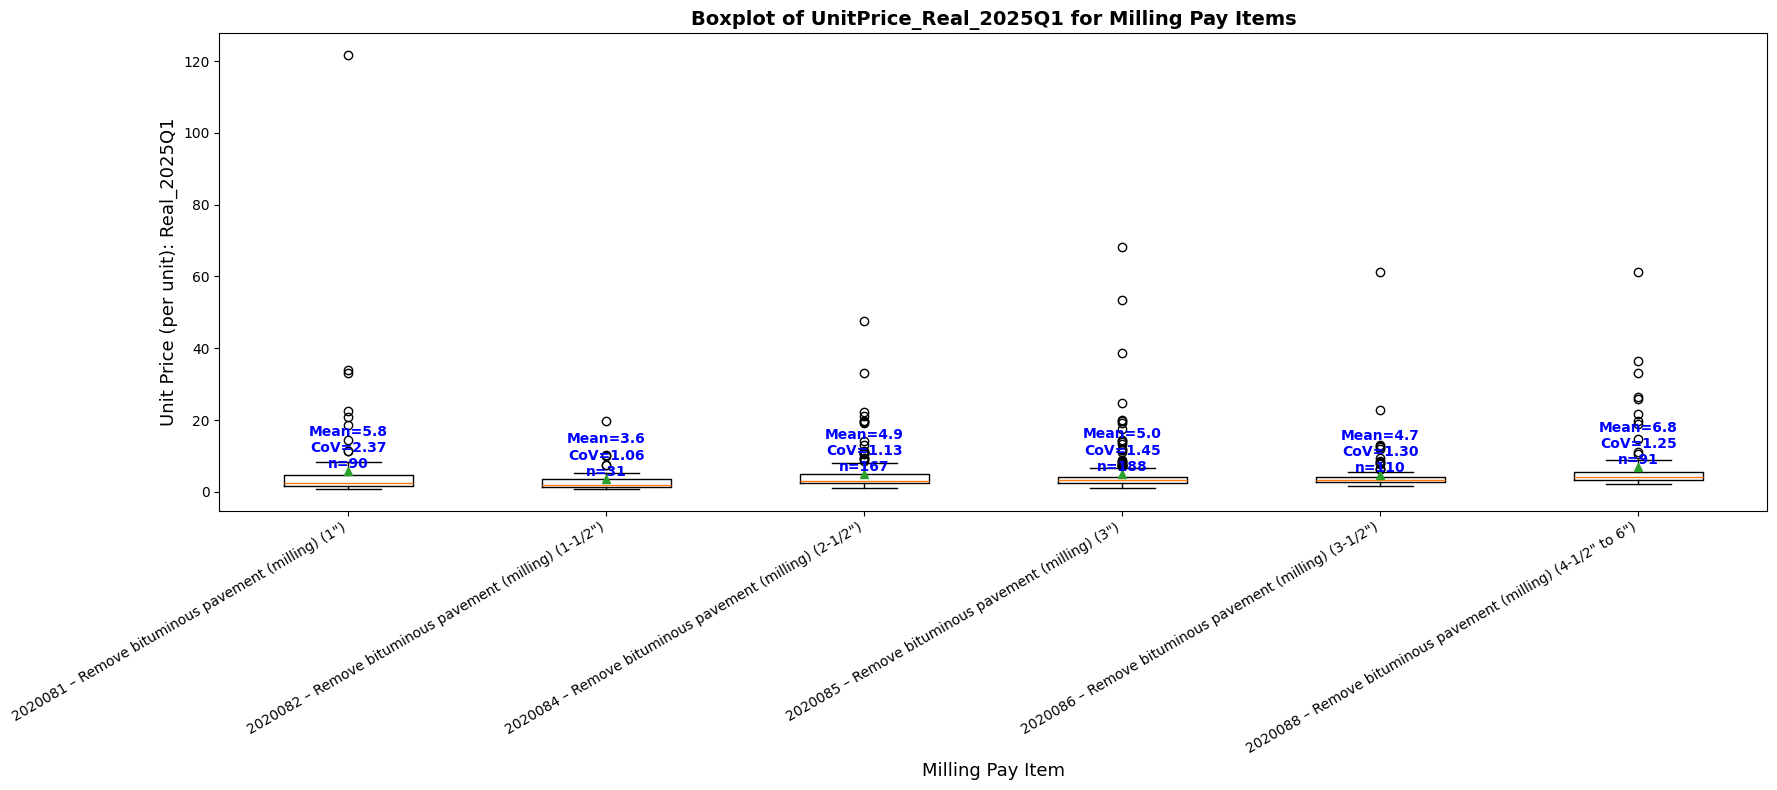

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Milling pay items: ONLY ONE PLOT (boxplot with mean/CoV/n)
#   - No table / no display()
#   - Robust to PayItemID being int or string
# ============================================================

MILLING_LABELS = [
    "2020081 – Remove bituminous pavement (milling) (1\")",
    "2020082 – Remove bituminous pavement (milling) (1-1/2\")",
    "2020084 – Remove bituminous pavement (milling) (2-1/2\")",
    "2020085 – Remove bituminous pavement (milling) (3\")",
    "2020086 – Remove bituminous pavement (milling) (3-1/2\")",
    "2020088 – Remove bituminous pavement (milling) (4-1/2\" to 6\")",
     #"2020079 – Remove bituminous pavement (milling) (1\" to 1-1/2\")",
    #"2020080 – Remove bituminous pavement (milling) (1/2\")",
    #"2020083 – Remove bituminous pavement (milling) (2\")",
    #"2020087 – Remove bituminous pavement (milling) (4\")",
    #"2020077 – Remove bituminous pavement from AC (milling friction course)",
    #"2020089 – Remove bituminous pavement (milling) (6-1/2\" to 8\")",
]

MILLING_IDS = [lbl.split("–")[0].strip().split()[0] for lbl in MILLING_LABELS]
MILLING_ID_TO_LABEL = {pid: lbl for pid, lbl in zip(MILLING_IDS, MILLING_LABELS)}

# ----------------------------
# Validate df
# ----------------------------
required_cols = ["PayItemID", "UnitPrice_Real_2025Q1"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"df missing required columns: {missing}")

# ----------------------------
# Standardize PayItemID once
# ----------------------------
d = df.copy()
d["PayItemID_str"] = d["PayItemID"].astype(str).str.extract(r"(\d+)", expand=False).str.strip()

# Filter for milling items
filtered_df = d[d["PayItemID_str"].isin(MILLING_IDS)].copy()

# ----------------------------
# Prepare data for boxplot (sorted by PayItemID)
# ----------------------------
sorted_ids = sorted(MILLING_IDS, key=lambda s: int(s))

data_to_plot = []
labels = []
stats = []  # (mean, cov, n)

for pid in sorted_ids:
    series = filtered_df.loc[filtered_df["PayItemID_str"] == pid, "UnitPrice_Real_2025Q1"]
    series = pd.to_numeric(series, errors="coerce").dropna()

    data_to_plot.append(series)
    labels.append(MILLING_ID_TO_LABEL[pid])

    if len(series) == 0:
        stats.append((np.nan, np.nan, 0))
        continue

    mean = float(series.mean())
    std = float(series.std(ddof=0))
    cov = std / mean if mean != 0 else np.nan
    stats.append((mean, cov, int(len(series))))

if all(len(s) == 0 for s in data_to_plot):
    raise ValueError("No valid UnitPrice_Real_2025Q1 values found for the milling pay items.")

# ----------------------------
# Plot: boxplot
# ----------------------------
plt.figure(figsize=(18, 8))
plt.boxplot(data_to_plot, tick_labels=labels, showmeans=True)

plt.xlabel("Milling Pay Item", fontsize=13)
plt.ylabel("Unit Price (per unit): Real_2025Q1", fontsize=13)
plt.title("Boxplot of UnitPrice_Real_2025Q1 for Milling Pay Items", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")

# Annotate each box with mean, CoV, and n
for i, (mean, cov, n) in enumerate(stats, start=1):
    if n == 0 or np.isnan(mean):
        continue
    plt.text(
        i, mean,
        f"Mean={mean:.1f}\nCoV={cov:.2f}\nn={n}",
        ha="center", va="bottom", fontsize=10, color="blue", fontweight="bold"
    )

plt.tight_layout()
plt.show()


C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\3919960060.py:277: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


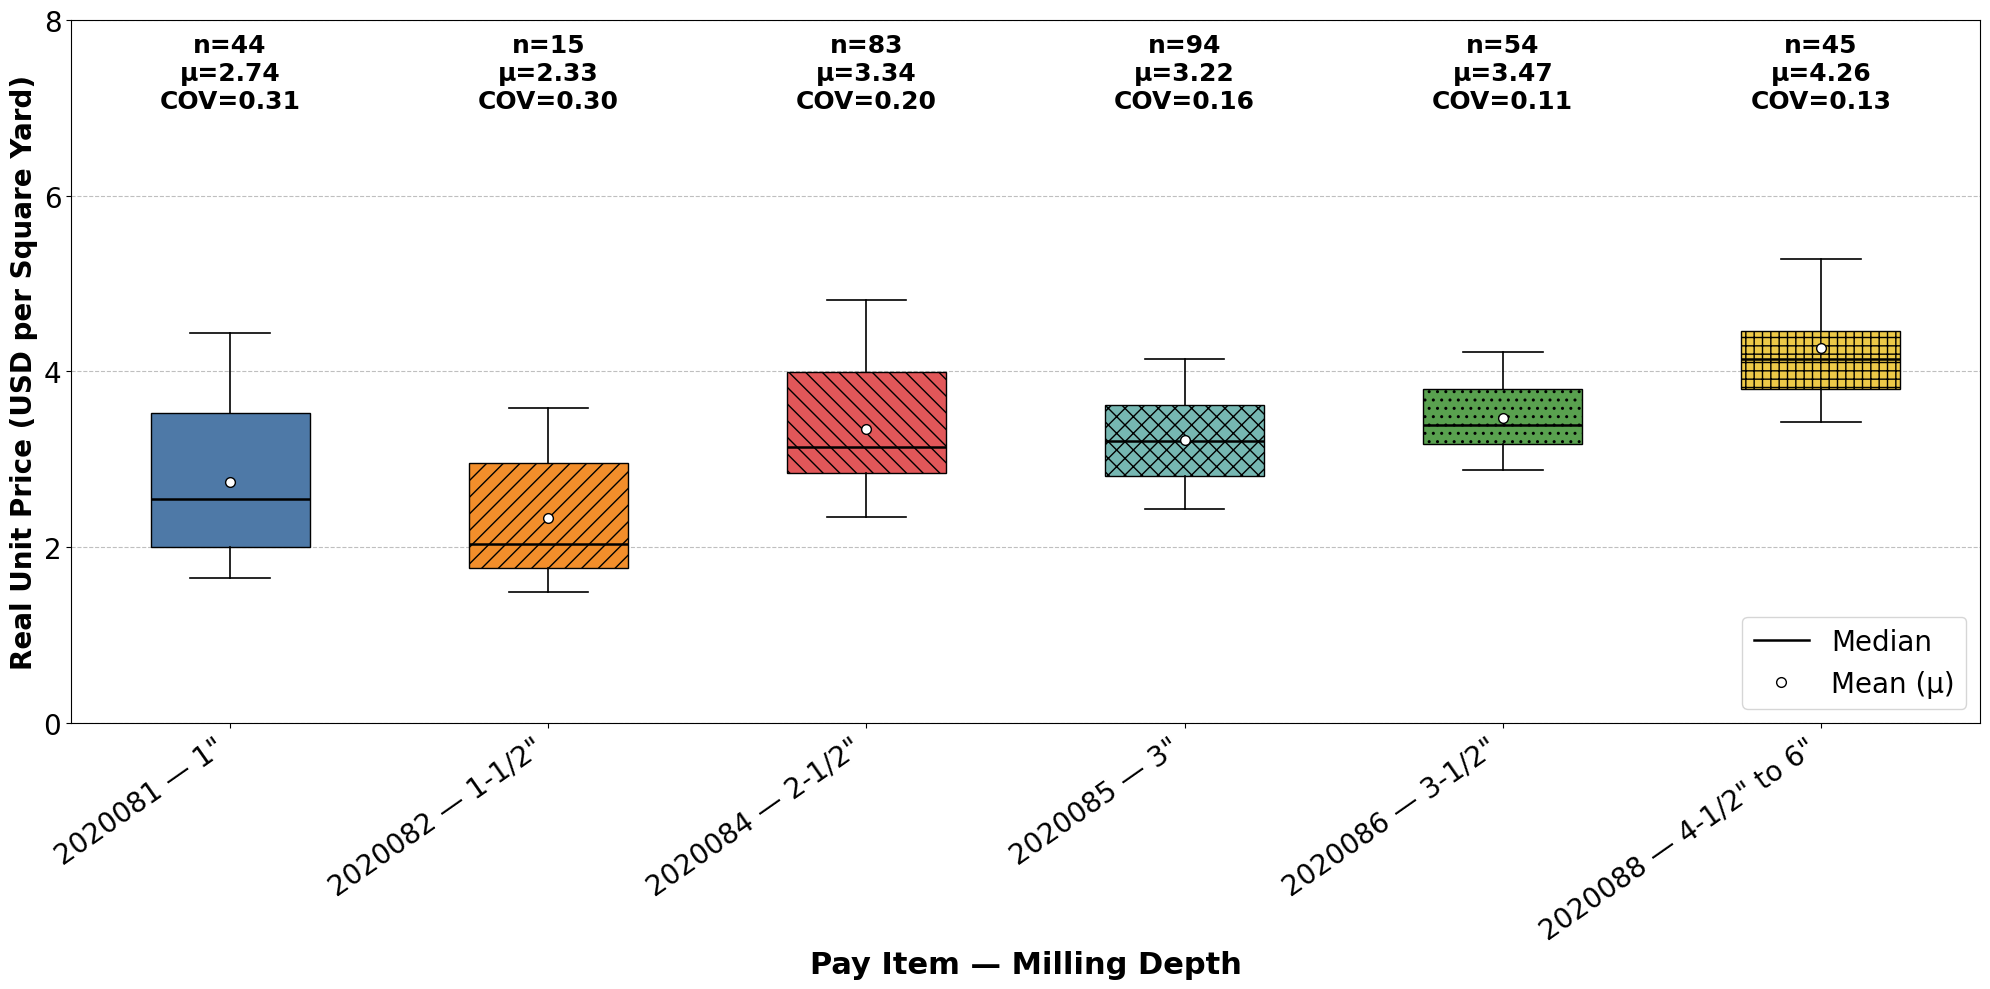

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import re

# ============================================================
# CONFIG
# ============================================================
MILLING_PAYITEM_LABELS = [
    '2020081 — Remove bituminous pavement (milling) (1")',
    '2020082 — Remove bituminous pavement (milling) (1-1/2")',
    '2020084 — Remove bituminous pavement (milling) (2-1/2")',
    '2020085 — Remove bituminous pavement (milling) (3")',
    '2020086 — Remove bituminous pavement (milling) (3-1/2")',
    '2020088 — Remove bituminous pavement (milling) (4-1/2" to 6")',
]

COLORS = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948"
]

HATCHES = ["", "//", "\\\\", "xx", "..", "++"]


# ============================================================
# HELPERS
# ============================================================
def ensure_required_cols(df: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")


def parse_payitem_id(series: pd.Series) -> pd.Series:
    """Extract numeric pay item code from any string/int representation."""
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .str.strip()
    )


def summary_stats_extended(x: pd.Series) -> dict:
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "median": np.nan,
            "std": np.nan,
            "cov": np.nan,
            "min": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "max": np.nan,
        }

    mean = float(x.mean())
    std = float(x.std(ddof=0))

    return {
        "n": int(len(x)),
        "mean": mean,
        "median": float(x.median()),
        "std": std,
        "cov": std / mean if mean != 0 else np.nan,
        "min": float(x.min()),
        "q1": float(x.quantile(0.25)),
        "q3": float(x.quantile(0.75)),
        "max": float(x.max()),
    }


def clean_milling_label(label: str) -> str:
    """
    Convert:
    '2020081 — Remove bituminous pavement (milling) (1")'
    into:
    '2020081 — 1"'

    Convert:
    '2020088 — Remove bituminous pavement (milling) (4-1/2" to 6")'
    into:
    '2020088 — 4-1/2" to 6"'
    """
    if pd.isna(label):
        return label

    label = str(label).strip()
    if "—" not in label:
        return label

    payitem, desc = [part.strip() for part in label.split("—", 1)]

    matches = re.findall(r"\((.*?)\)", desc)
    parts = []

    for m in matches:
        m = m.strip()
        m_lower = m.lower()

        # remove descriptive text, keep only thickness/range
        if m_lower in {"milling", "remove bituminous pavement"}:
            continue

        # thickness values usually contain quotes or ranges
        if '"' in m or "to" in m_lower or any(ch.isdigit() for ch in m):
            parts.append(m)

    if parts:
        desc_clean = parts[-1]
    else:
        desc_clean = desc.replace("Remove bituminous pavement", "").replace("(milling)", "")
        desc_clean = desc_clean.replace("(", "").replace(")", "").strip()
        desc_clean = " ".join(desc_clean.split())

    return f"{payitem} — {desc_clean}"


def make_accessible_summary_text(price_summary: pd.DataFrame) -> str:
    """Create a text alternative / long description for screen readers."""
    lines = []
    lines.append("Accessible chart summary:")
    lines.append("Figure 1 is a boxplot of real unit prices by milling pay item after IQR-based cleaning within each pay item.")

    valid_summary = price_summary.dropna(subset=["mean"])
    if not valid_summary.empty:
        highest_mean_row = valid_summary.sort_values("mean", ascending=False).iloc[0]
        lowest_mean_row = valid_summary.sort_values("mean", ascending=True).iloc[0]

        lines.append(
            f"The highest average unit price is for {highest_mean_row['Milling Label Clean']} "
            f"at {highest_mean_row['mean']:.2f} USD per square yard."
        )
        lines.append(
            f"The lowest average unit price is for {lowest_mean_row['Milling Label Clean']} "
            f"at {lowest_mean_row['mean']:.2f} USD per square yard."
        )

    lines.append("See the exported price summary table for fully accessible tabular values.")
    return "\n".join(lines)


# ============================================================
# MAIN
# ============================================================
def plot_milling_boxplot_508(
    df: pd.DataFrame,
    payitem_labels: list[str],
    price_col: str = "UnitPrice_Real_2025Q1",
    payitem_col: str = "PayItemID",
    export_dir: str | None = None,
    show_plots: bool = True,
) -> tuple[pd.DataFrame, str, pd.DataFrame]:
    """
    Creates a 508-friendlier boxplot and accessible supporting outputs
    for milling pay items after IQR cleaning within each pay item.

    Returns
    -------
    cleaned_df : pd.DataFrame
    alt_text : str
    price_summary : pd.DataFrame
    """

    ensure_required_cols(df, [payitem_col, price_col])

    ids = [lbl.split("—")[0].strip().split()[0] for lbl in payitem_labels]
    id_to_label = {pid: lbl for pid, lbl in zip(ids, payitem_labels)}
    id_to_clean_label = {pid: clean_milling_label(lbl) for pid, lbl in zip(ids, payitem_labels)}

    d = df.copy()
    d["_PayItemID_str"] = parse_payitem_id(d[payitem_col])

    # keep only target milling pay items
    d = d[d["_PayItemID_str"].isin(ids)].copy()
    d[price_col] = pd.to_numeric(d[price_col], errors="coerce")

    if d.empty:
        raise ValueError("No milling rows found after filtering. Check PayItemIDs.")

    # ============================================================
    # 1) IQR cleaning by pay item
    # ============================================================
    keep_mask = pd.Series(True, index=d.index)

    for pid in ids:
        idx = d.index[d["_PayItemID_str"] == pid]
        series = d.loc[idx, price_col].dropna()

        if len(series) < 4:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        keep_mask.loc[idx] = (d.loc[idx, price_col] >= q1) & (d.loc[idx, price_col] <= q3)

    cleaned_df = d.loc[keep_mask].copy()

    if cleaned_df.empty:
        raise ValueError("No milling observations remain after IQR filtering.")

    # labels
    cleaned_df["MillingPayItemID"] = cleaned_df["_PayItemID_str"]
    cleaned_df["Milling Label"] = cleaned_df["MillingPayItemID"].map(id_to_label)
    cleaned_df["Milling Label Clean"] = cleaned_df["MillingPayItemID"].map(id_to_clean_label)

    # ============================================================
    # 2) Price summary table
    # ============================================================
    summary_rows = []
    for pid in sorted(ids, key=lambda s: int(s)):
        sub = cleaned_df.loc[cleaned_df["MillingPayItemID"] == pid, price_col]
        stats = summary_stats_extended(sub)
        stats["MillingPayItemID"] = pid
        stats["Milling Label"] = id_to_label[pid]
        stats["Milling Label Clean"] = id_to_clean_label[pid]
        summary_rows.append(stats)

    price_summary = pd.DataFrame(summary_rows)[[
        "MillingPayItemID", "Milling Label", "Milling Label Clean",
        "n", "mean", "median", "std", "cov", "min", "q1", "q3", "max"
    ]]

    # ============================================================
    # 3) Accessible long description
    # ============================================================
    alt_text = make_accessible_summary_text(price_summary)

    # ============================================================
    # 4) Export accessible outputs
    # ============================================================
    if export_dir is not None:
        out = Path(export_dir)
        out.mkdir(parents=True, exist_ok=True)

        cleaned_df.to_csv(out / "milling_iqr_cleaned_data_accessible.csv", index=False)
        price_summary.to_csv(out / "milling_price_summary_accessible.csv", index=False)

        with open(out / "milling_chart_long_description.txt", "w", encoding="utf-8") as f:
            f.write(alt_text)

    # ============================================================
    # 5) Plot: Boxplot of real unit prices
    # ============================================================
    if show_plots:
        id_sorted = sorted(ids, key=lambda s: int(s))
        data_to_plot = []
        labels = []
        top_annotations = []

        for pid in id_sorted:
            sub = pd.to_numeric(
                cleaned_df.loc[cleaned_df["MillingPayItemID"] == pid, price_col],
                errors="coerce"
            ).dropna()

            data_to_plot.append(sub)
            labels.append(id_to_clean_label[pid])

            stats = summary_stats_extended(sub)
            top_annotations.append({
                "n": stats["n"],
                "mean": stats["mean"],
                "cov": stats["cov"]
            })

        if all(len(s) == 0 for s in data_to_plot):
            raise ValueError("No milling observations remain for plotting after IQR filtering.")

        fig, ax = plt.subplots(figsize=(20, 10))

        bp = ax.boxplot(
            data_to_plot,
            labels=labels,
            showmeans=True,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1.8),
            meanprops=dict(
                marker="o",
                markerfacecolor="white",
                markeredgecolor="black",
                markersize=7
            )
        )

        for i, box in enumerate(bp["boxes"]):
            box.set(
                facecolor=COLORS[i % len(COLORS)],
                edgecolor="black",
                hatch=HATCHES[i % len(HATCHES)],
                linewidth=1.0
            )

        for whisker in bp["whiskers"]:
            whisker.set(color="black", linewidth=1.2)
        for cap in bp["caps"]:
            cap.set(color="black", linewidth=1.2)
        for median in bp["medians"]:
            median.set(color="black", linewidth=1.8)
        for mean in bp["means"]:
            mean.set(
                marker="o",
                markerfacecolor="white",
                markeredgecolor="black",
                markersize=7
            )


        ax.set_xlabel("Pay Item — Milling Depth", fontsize=22, fontweight="bold")
        ax.set_ylabel("Real Unit Price (USD per Square Yard)", fontsize=20, fontweight="bold")

        # Fixed y-axis as requested
        ax.set_ylim(0, 8)
        ax.set_yticks(np.arange(0, 9, 2))

        plt.xticks(rotation=35, ha="right", fontsize=20)
        plt.yticks(fontsize=20)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.8)

        # Top annotations
        y_annot = 7.85
        for i, ann in enumerate(top_annotations, start=1):
            mu_txt = f"{ann['mean']:.2f}" if pd.notna(ann["mean"]) else "NA"
            cov_txt = f"{ann['cov']:.2f}" if pd.notna(ann["cov"]) else "NA"
            text = f"n={ann['n']}\nμ={mu_txt}\nCOV={cov_txt}"

            ax.text(
                i,
                y_annot,
                text,
                ha="center",
                va="top",
                fontsize=18,
                fontweight="bold"
            )

        legend_elements = [
            Line2D([0], [0], color="black", lw=1.8, label="Median"),
            Line2D(
                [0], [0],
                marker="o",
                color="black",
                markerfacecolor="white",
                markersize=7,
                linestyle="None",
                label="Mean (μ)"
            )
        ]

        ax.legend(
            handles=legend_elements,
            loc="lower right",
            frameon=True,
            fontsize=20
        )

        plt.tight_layout()
        plt.show()

    # ============================================================
    # Print long description
    # ============================================================
    # Long description is generated and exported, but not printed in the notebook.

    return cleaned_df, alt_text, price_summary


# ============================================================
# RUN
# ============================================================
cleaned_df, alt_text, price_summary = plot_milling_boxplot_508(
    df=df,
    payitem_labels=MILLING_PAYITEM_LABELS,
    price_col="UnitPrice_Real_2025Q1",
    payitem_col="PayItemID",
    export_dir="508_accessible_milling_outputs",   # set to None if you do not want files saved
    show_plots=True
)

# Accessible price summary is returned and exported, but not printed in the notebook.

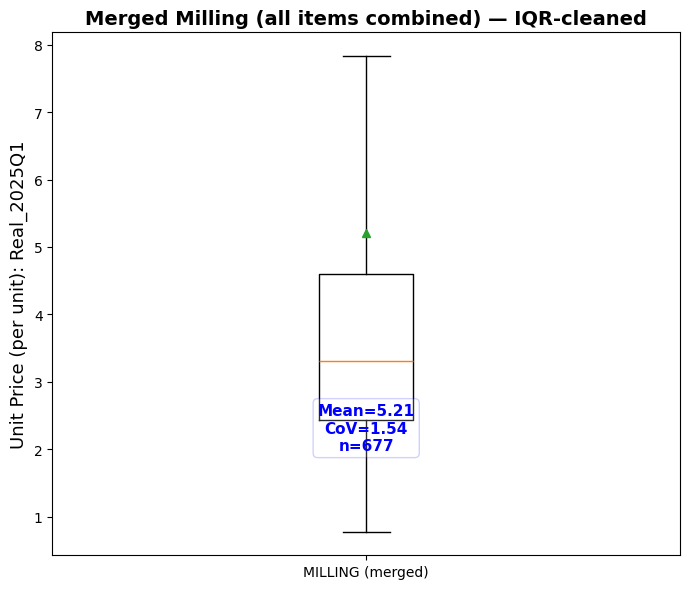

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CELL 2
#  - Uses df already cleaned in Cell 1
#  - Merge all milling pay items into one category
#  - Plot one merged milling box + mean/CoV/n
# ============================================================

# If you ran Cell 1, df already has PayItemID_str.
# If not (or you dropped it), recreate it safely:
if "PayItemID_str" not in df.columns:
    df["PayItemID_str"] = (
        df["PayItemID"].astype(str).str.extract(r"(\d+)", expand=False).str.strip()
    )

# Merge category column (keeps other pay items intact)
MERGED_COL = "PayItem_Group"
df[MERGED_COL] = np.where(df["PayItemID_str"].isin(MILLING_IDS), "MILLING", "OTHER")

milling_series = pd.to_numeric(
    df.loc[df[MERGED_COL] == "MILLING", "UnitPrice_Real_2025Q1"],
    errors="coerce"
).dropna()

if len(milling_series) == 0:
    raise ValueError("No milling observations remain for merged plot.")

mean = float(milling_series.mean())
std = float(milling_series.std(ddof=1)) if len(milling_series) > 1 else 0.0
cov = std / mean if mean != 0 else np.nan
n = int(len(milling_series))

plt.figure(figsize=(7, 6))
plt.boxplot([milling_series], tick_labels=["MILLING (merged)"], showmeans=True, showfliers=False)

plt.ylabel("Unit Price (per unit): Real_2025Q1", fontsize=13)
plt.title("Merged Milling (all items combined) — IQR-cleaned", fontsize=14, fontweight="bold")

# --------- Modified Annotation Location -------------
# Instead of above the max point, move annotation inside box (25th–75th percentile)
quartiles = np.percentile(milling_series, [25, 50, 75])
y_middle = quartiles[1]  # median
offset = -0.08 * (plt.ylim()[1] - plt.ylim()[0])  # Place annotation just below median line

plt.text(
    1, y_middle + offset,
    f"Mean={mean:.2f}\nCoV={cov:.2f}\nn={n}",
    ha="center", va="top",        # place above the anchor
    fontsize=11, color="blue", fontweight="bold",
    bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3', alpha=0.18)
)
# ---------------------------------------------------

plt.tight_layout()
plt.show()

# Optional: if you don't want helper column afterwards:
# df = df.drop(columns=["PayItemID_str"])


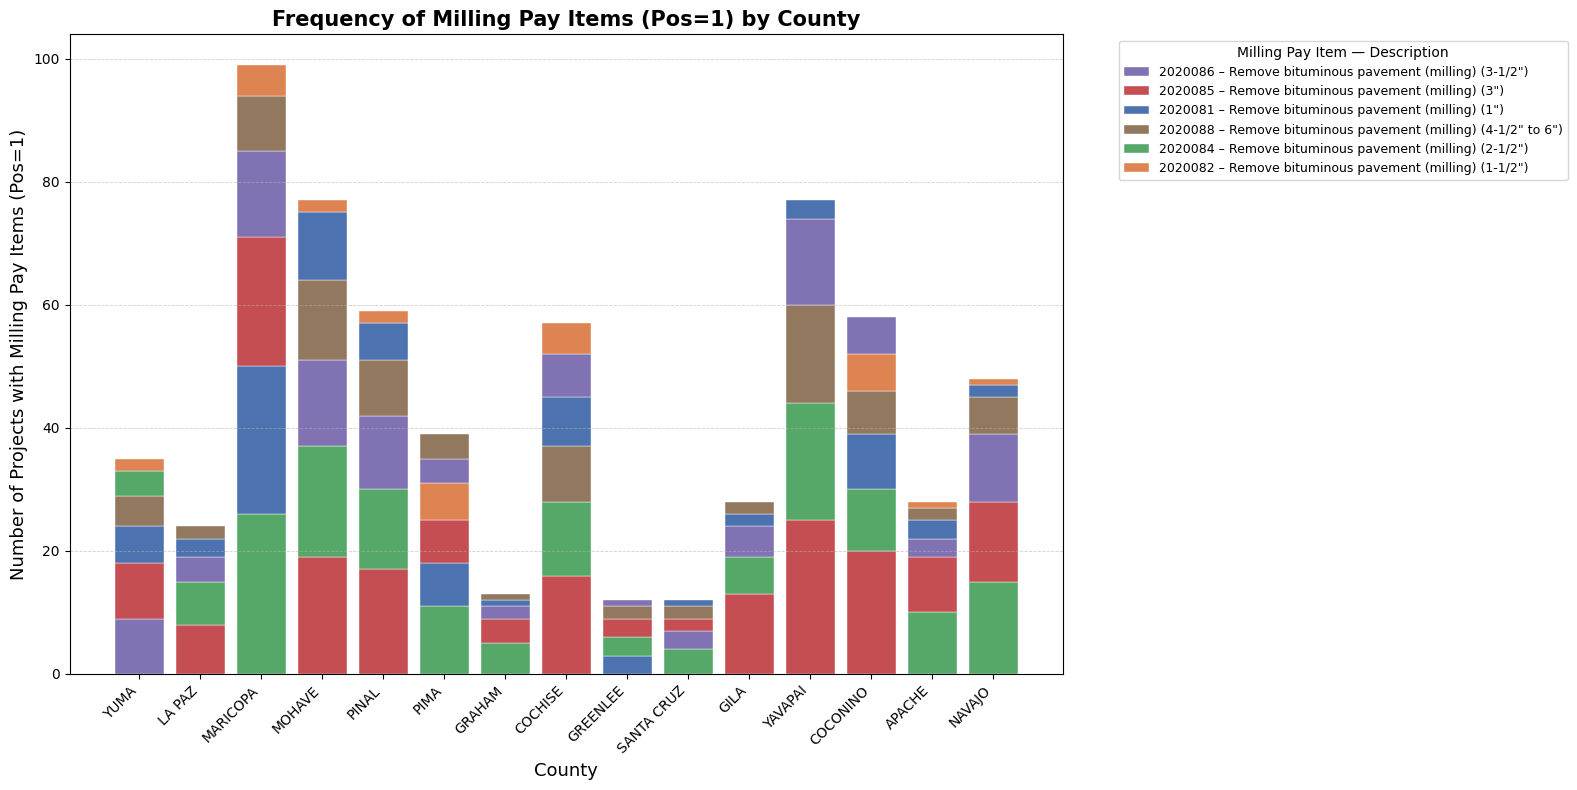

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Milling pay items (for legend & order)
# ============================================

MILLING_LABELS = [
    "2020081 – Remove bituminous pavement (milling) (1\")",
    "2020082 – Remove bituminous pavement (milling) (1-1/2\")",
    "2020084 – Remove bituminous pavement (milling) (2-1/2\")",
    "2020085 – Remove bituminous pavement (milling) (3\")",
    "2020086 – Remove bituminous pavement (milling) (3-1/2\")",
    "2020088 – Remove bituminous pavement (milling) (4-1/2\" to 6\")",
    #"2020079 – Remove bituminous pavement (milling) (1\" to 1-1/2\")",
    #"2020080 – Remove bituminous pavement (milling) (1/2\")",
    #"2020083 – Remove bituminous pavement (milling) (2\")",
    #"2020087 – Remove bituminous pavement (milling) (4\")",
    #"2020077 – Remove bituminous pavement from AC (milling friction course)",
    #"2020089 – Remove bituminous pavement (milling) (6-1/2\" to 8\")",
]

MILLING_IDS = [lbl.split("–")[0].strip().split()[0] for lbl in MILLING_LABELS]
MILLING_ID_TO_LABEL = {lbl.split("–")[0].strip().split()[0]: lbl for lbl in MILLING_LABELS}

# County order on x-axis
COUNTY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

# Color-blind–safe palette (13 colors for milling pay items)
MILLING_COLORS = [
    "#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860",
    "#da8bc3", "#8c8c8c", "#ccb974", "#64b5cd", "#8c564b", "#e377c2", "#7f7f7f"
]

# ============================================
# Helper: find column name by partial match
# ============================================
def find_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        c = cand.lower()
        for low, orig in cols_lower.items():
            if low == c or c in low:
                return orig
    return None

# ============================================
# 1) Use single dataframe (df) containing all required information
# ============================================
DEBUG = False  # Set True for more info

# Assume df is already loaded and contains everything.

# Find key columns: job ID, position, pay item, county
jobid_col   = find_col(df.columns, ["JobID", "Job ID", "ProjectID", "Project ID", "Project No"])
pos_col     = find_col(df.columns, ["Pos", "POS", "Position"])
payitem_col = find_col(df.columns, ["Pay Item", "PayItem", "Pay Item ID", "Pay Item Number", "PayItemID"])
county_col  = find_col(df.columns, ["County", "County Name"])

needed = [jobid_col, pos_col, payitem_col, county_col]
if any(c is None for c in needed):
    raise KeyError("Could not find one or more required columns in df.")

if DEBUG:
    print("df columns:", list(df.columns))
    print("Used columns:", needed)

# ============================================
# 2) Process df: Pos == 1 and Milling pay items
# ============================================
milling_df = df.copy()
milling_df["_PosNum"] = pd.to_numeric(milling_df[pos_col], errors="coerce")
milling_df = milling_df[milling_df["_PosNum"] == 1].copy()

milling_df["MillingPayItemID"] = (
    milling_df[payitem_col]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.strip()
)

milling_df = milling_df[milling_df["MillingPayItemID"].isin(MILLING_IDS)].copy()
milling_df = milling_df[~milling_df[county_col].isna()].copy()
milling_df["County"] = milling_df[county_col].astype(str).str.strip().str.upper()
milling_df["Milling Label"] = milling_df["MillingPayItemID"].map(MILLING_ID_TO_LABEL)

if milling_df.empty:
    raise ValueError("No milling rows found. Check that Position==1 filter and pay item IDs are correct.")

# ============================================
# 3) Build frequency table (County x Milling Label)
# ============================================
milling_freq_df = (
    milling_df.groupby(["County", "Milling Label"])
          .size()
          .unstack(fill_value=0)
)

milling_freq_df = milling_freq_df.reindex(COUNTY_ORDER).fillna(0)
cols_in_data = [lbl for lbl in MILLING_LABELS if lbl in milling_freq_df.columns]
milling_freq_df = milling_freq_df[cols_in_data]

# ============================================
# 4) Plot: stacked bar chart
# ============================================
milling_items = milling_freq_df.columns.tolist()
color_map = {item: MILLING_COLORS[i % len(MILLING_COLORS)] for i, item in enumerate(milling_items)}

counties = milling_freq_df.index.tolist()
x = np.arange(len(counties))

fig, ax = plt.subplots(figsize=(16, 8))
seen = set()

for i, county in enumerate(counties):
    counts = milling_freq_df.loc[county]
    order = counts.sort_values(ascending=False).index  # most used at bottom
    bottom = 0.0
    for item in order:
        value = float(counts[item])
        if value == 0:
            continue
        label = item if item not in seen else "_nolegend_"
        ax.bar(
            x[i],
            value,
            bottom=bottom,
            color=color_map[item],
            edgecolor="white",
            linewidth=0.3,
            label=label,
        )
        seen.add(item)
        bottom += value

ax.set_title("Frequency of Milling Pay Items (Pos=1) by County",
             fontsize=15, weight="bold")
ax.set_xlabel("County", fontsize=13)
ax.set_ylabel("Number of Projects with Milling Pay Items (Pos=1)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(counties, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

ax.legend(title="Milling Pay Item — Description",
          bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# Remove and Replace 0.5 inch AC+FR

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2672993619.py:132: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(fr_box_data, patch_artist=True, labels=plot_counties_fr, showmeans=True, meanline=True)


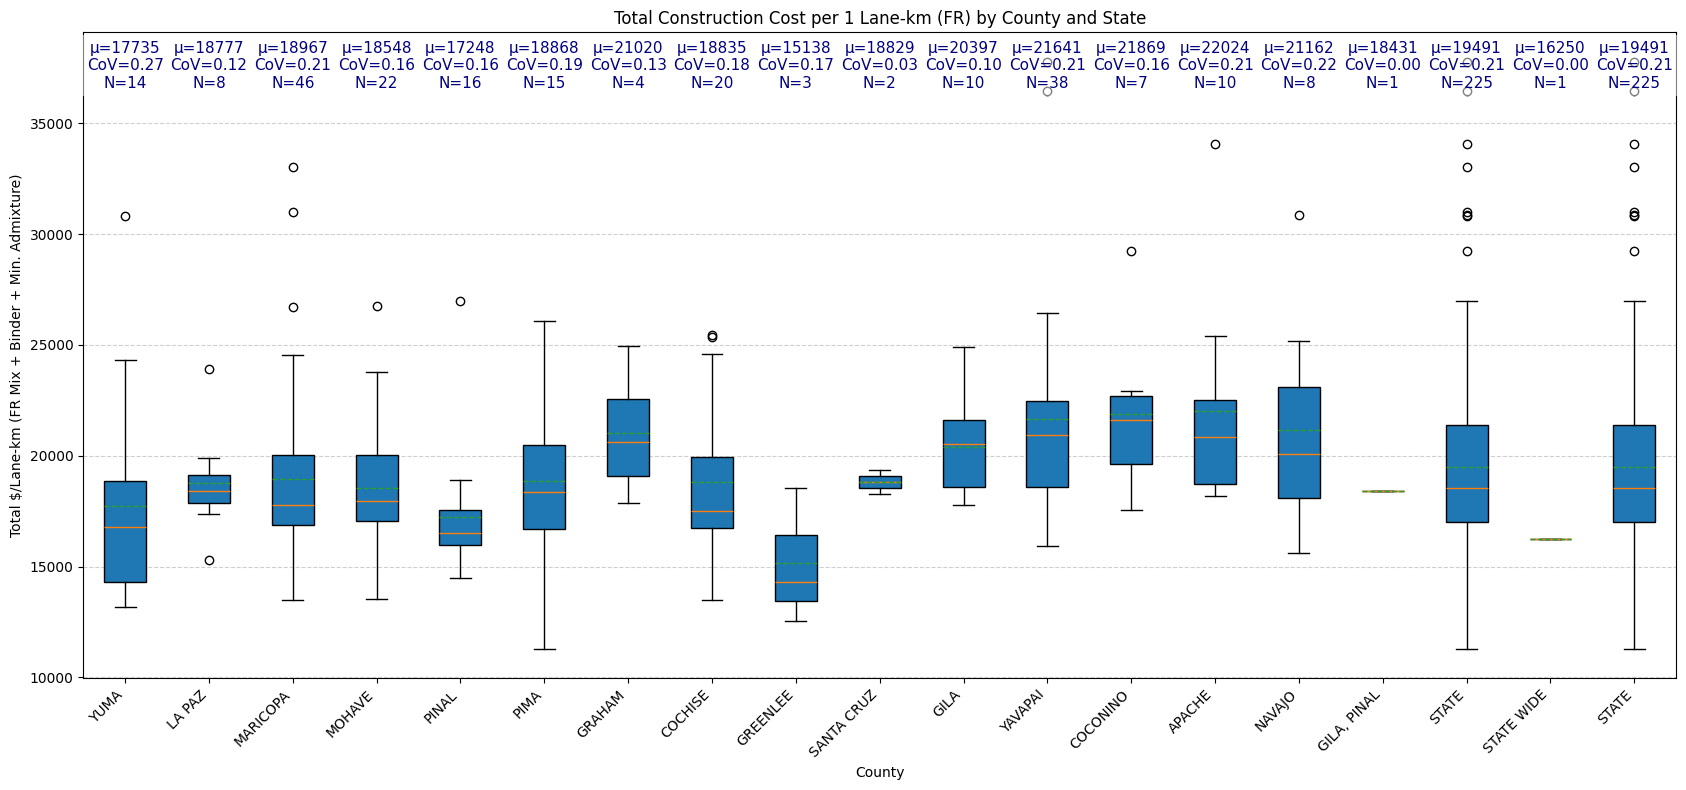

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2672993619.py:219: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(ac_box_data, patch_artist=True, labels=ac_plot_labels, showmeans=True)


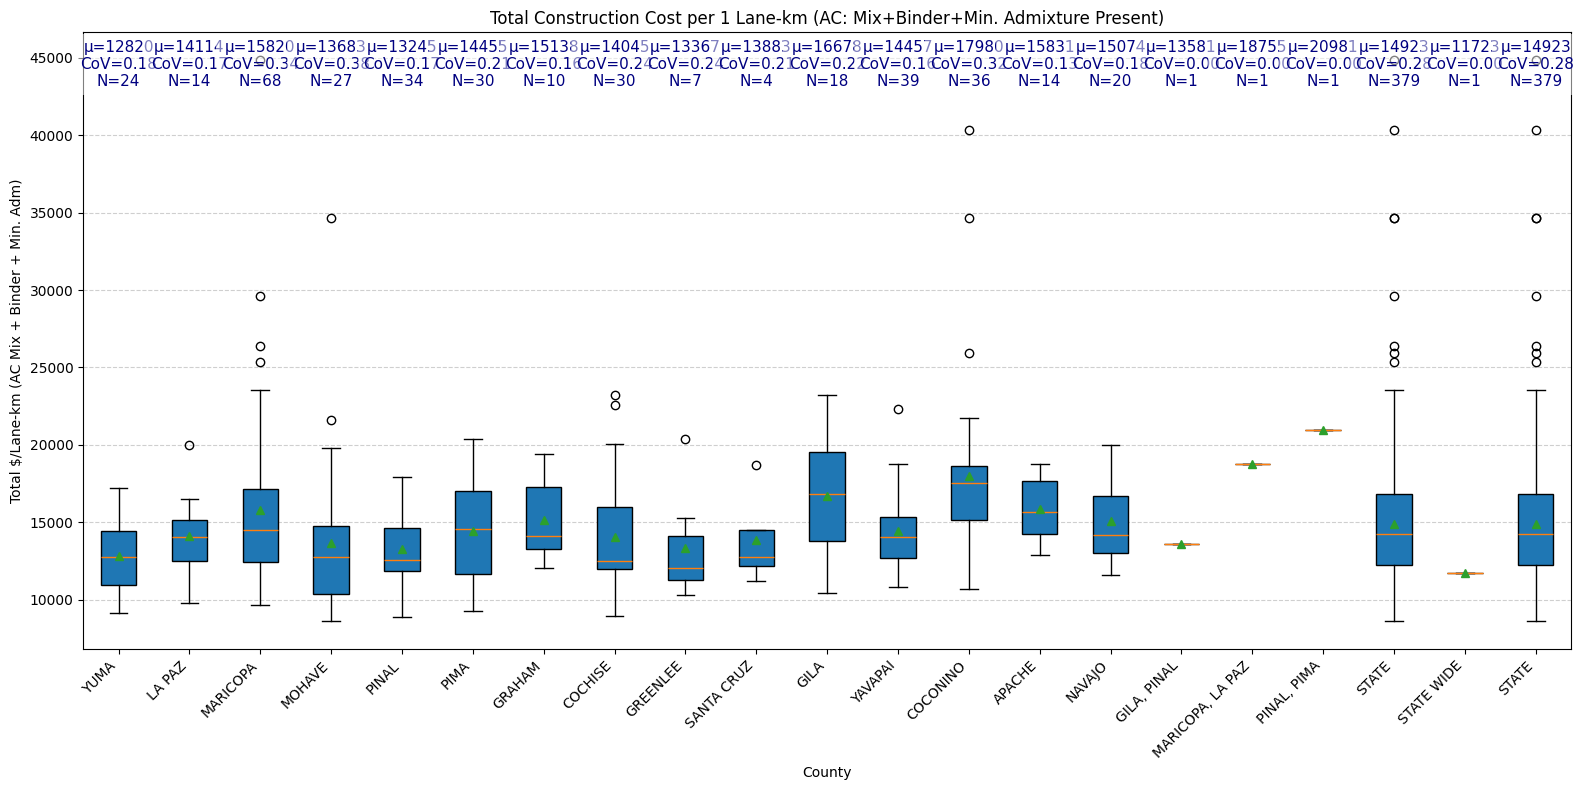

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2672993619.py:273: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(mill_box_data, patch_artist=True, labels=plot_counties_mill, showmeans=True)


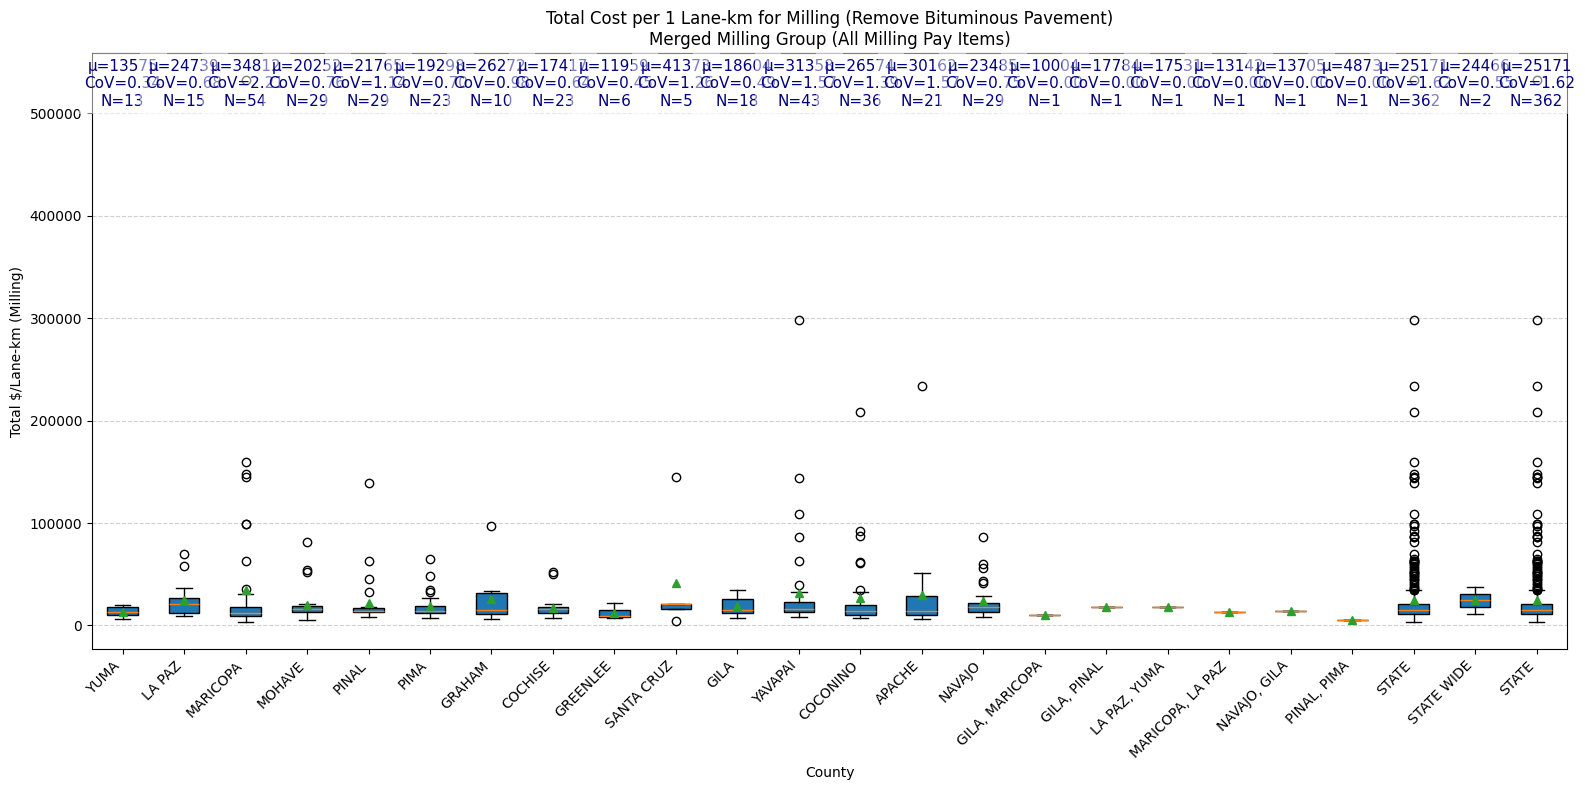

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2672993619.py:320: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(tack_box_data, patch_artist=True, labels=plot_counties_tack, showmeans=True)


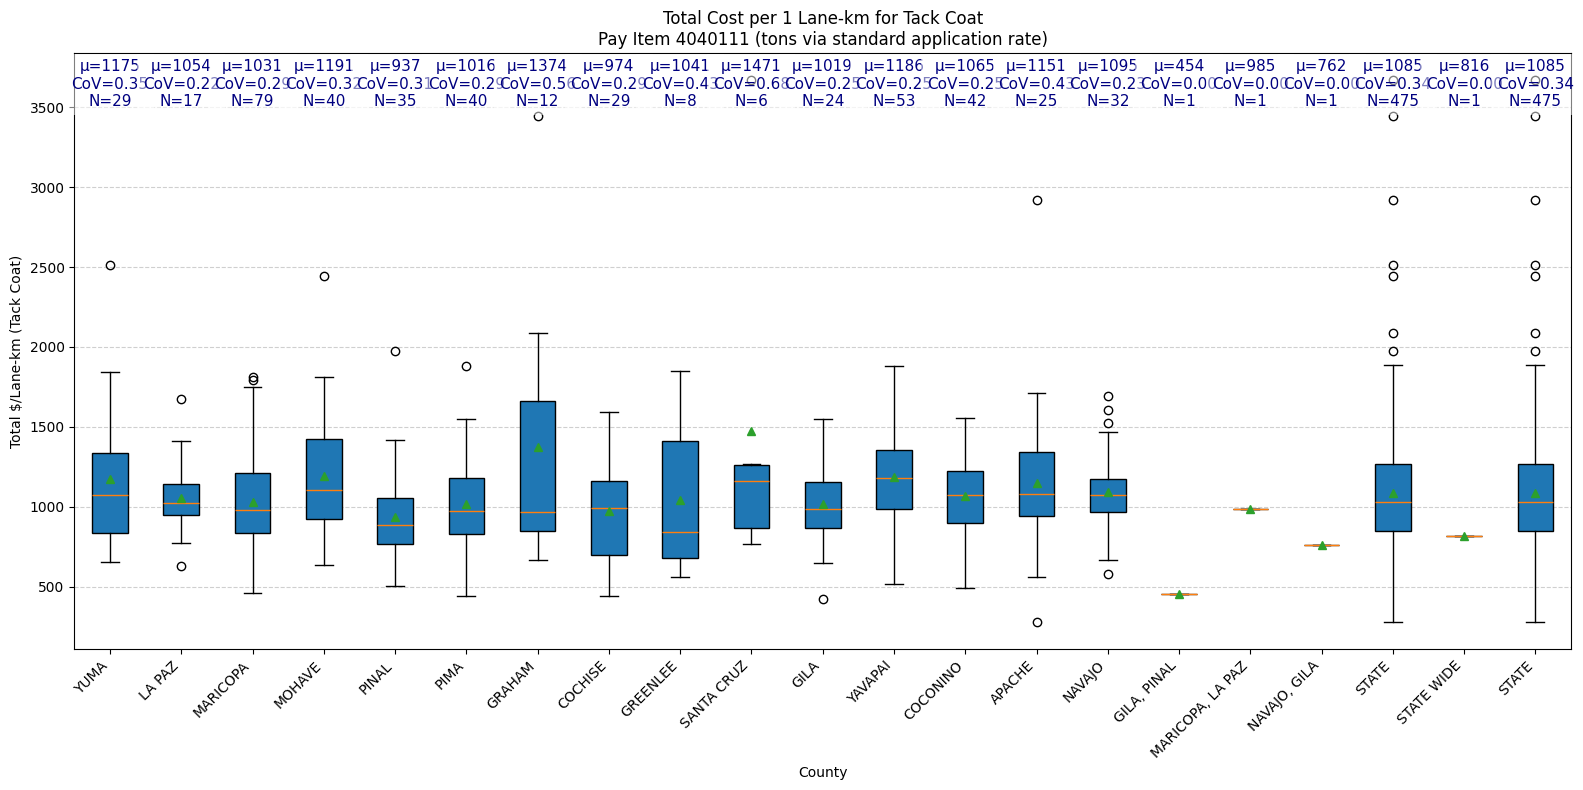

In [18]:
# FR and AC Lane-Mile Cost Calculation, Boxplots, and Bootstrap Sample Summary
# — now with Section 4: Tack Coat
# ✅ Updated Section 3: Milling uses MERGED milling group (all milling pay items)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# ---------------------------------------------------------------
# Common utilities
# ---------------------------------------------------------------
COUNTY_DISPLAY_ORDER = [
    "YUMA", "LA PAZ",
    "MARICOPA", "MOHAVE", "PINAL", "PIMA", "GRAHAM", "COCHISE", "GREENLEE",
    "SANTA CRUZ", "GILA", "YAVAPAI",
    "COCONINO", "APACHE", "NAVAJO",
]

def annot_boxplot(ax, box_data, labels, y_frac=0.99):
    """Annotate a boxplot with mean, CoV, N (for each box)."""
    ylim_top = ax.get_ylim()[1]
    for i, vals in enumerate(box_data):
        arr = np.asarray(vals, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            continue
        mean = arr.mean()
        std = arr.std(ddof=0)
        cov = std / mean if mean != 0 else np.nan
        n = len(arr)
        text = f"μ={mean:.0f}\nCoV={cov:.2f}\nN={n}"
        ax.text(
            i + 1, ylim_top * y_frac, text,
            ha="center", va="top", fontsize=11, color="navy",
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="none")
        )

def county_plot_order(df_with_county: pd.DataFrame, county_col: str = "County"):
    """Return counties in desired display order + extras, and include STATE at end."""
    unique_counties = set(df_with_county[county_col].dropna().astype(str))
    ordered = [c for c in COUNTY_DISPLAY_ORDER if c in unique_counties]
    extras = sorted(unique_counties - set(ordered))
    return ordered + extras + ["STATE"]

# ---------------------------------------------------------------
# One-time standardization (DO NOT overwrite PayItemID)
# ---------------------------------------------------------------
df = df.copy()
df["PayItemID_str"] = (
    df["PayItemID"].astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.strip()
)
df["Quantity_num"] = pd.to_numeric(df.get("Quantity", np.nan), errors="coerce")
df["UnitPrice_Real_2025Q1_num"] = pd.to_numeric(df.get("UnitPrice_Real_2025Q1", np.nan), errors="coerce")
df["County"] = df["County"].astype(str)

# ---------------------------------------------------------------
# Section 1: Fiber-Reinforced (FR) Project Processing
# ---------------------------------------------------------------
FR_PAYITEM_IDS = {
    "binder": "4140042",
    "mix": "4140040",
    "mineral_admix": "4140044",
}
required_fr = [FR_PAYITEM_IDS["binder"], FR_PAYITEM_IDS["mix"], FR_PAYITEM_IDS["mineral_admix"]]

fr_jobs = (
    df[df["PayItemID_str"].isin(required_fr)]
    .groupby("JobID")["PayItemID_str"]
    .nunique()
)
eligible_fr_jobs = fr_jobs[fr_jobs == 3].index

df_fr = df[df["JobID"].isin(eligible_fr_jobs) & df["PayItemID_str"].isin(required_fr)].copy()

pivot_cols = ["Quantity_num", "UnitPrice_Real_2025Q1_num"]
fr_pivot = df_fr.pivot_table(
    index=["JobID", "County"],
    columns="PayItemID_str",
    values=pivot_cols,
    aggfunc="first"
)
fr_pivot.columns = [f"{col}_{pid}" for col, pid in fr_pivot.columns]
fr_pivot = fr_pivot.reset_index()

fr_pivot.rename(columns={
    f"Quantity_num_{FR_PAYITEM_IDS['mix']}": "Mix_Ton",
    f"Quantity_num_{FR_PAYITEM_IDS['binder']}": "Binder_Ton",
    f"Quantity_num_{FR_PAYITEM_IDS['mineral_admix']}": "MinAdmix_Ton",
    f"UnitPrice_Real_2025Q1_num_{FR_PAYITEM_IDS['mix']}": "Mix_UnitPrice",
    f"UnitPrice_Real_2025Q1_num_{FR_PAYITEM_IDS['binder']}": "Binder_UnitPrice",
    f"UnitPrice_Real_2025Q1_num_{FR_PAYITEM_IDS['mineral_admix']}": "MinAdmix_UnitPrice",
}, inplace=True)

# Lane-mile conversion for FR (0.5 in thickness)
LANE_WIDTH_FT = 12
PAVE_THICKNESS_IN = 0.5
DENSITY_MIX_LB_FT3 = 125.0
FT_PER_LANE_MILE = LANE_WIDTH_FT * 5280
VOL_PER_LANE_MILE_FT3 = FT_PER_LANE_MILE * (PAVE_THICKNESS_IN / 12.0)
TONS_PER_LANE_MILE_FR = VOL_PER_LANE_MILE_FT3 * DENSITY_MIX_LB_FT3 / 2000.0

fr_pivot["Actual_Binder_Frac"] = fr_pivot["Binder_Ton"] / fr_pivot["Mix_Ton"]
fr_pivot["Agg_Tons_Per_LaneMile"] = TONS_PER_LANE_MILE_FR - (fr_pivot["Actual_Binder_Frac"] * TONS_PER_LANE_MILE_FR)
fr_pivot["MinAdmix_Tons_Per_LaneMile"] = fr_pivot["Agg_Tons_Per_LaneMile"] * (1 / 101)

fr_pivot["Mix_Cost_Per_LaneMile"] = fr_pivot["Mix_UnitPrice"] * TONS_PER_LANE_MILE_FR
fr_pivot["Binder_Cost_Per_LaneMile"] = fr_pivot["Binder_UnitPrice"] * (fr_pivot["Actual_Binder_Frac"] * TONS_PER_LANE_MILE_FR)
fr_pivot["MinAdmix_Cost_Per_LaneMile"] = fr_pivot["MinAdmix_UnitPrice"] * fr_pivot["MinAdmix_Tons_Per_LaneMile"]

fr_pivot["Total_Cost_LaneMile"] = (
    fr_pivot["Mix_Cost_Per_LaneMile"] +
    fr_pivot["Binder_Cost_Per_LaneMile"] +
    fr_pivot["MinAdmix_Cost_Per_LaneMile"]
) * MILE_TO_KM

# Boxplot FR
fr_state = fr_pivot.copy()
fr_state["County"] = "STATE"
fr_for_box = pd.concat([fr_pivot, fr_state], ignore_index=True)

plot_counties_fr = county_plot_order(fr_for_box, "County")
fr_box_data = [
    fr_for_box.loc[fr_for_box["County"] == county, "Total_Cost_LaneMile"].dropna().values
    for county in plot_counties_fr
]

fig, ax = plt.subplots(figsize=(17, 8))
ax.boxplot(fr_box_data, patch_artist=True, labels=plot_counties_fr, showmeans=True, meanline=True)
ax.set(
    title="Total Construction Cost per 1 Lane-km (FR) by County and State",
    xlabel="County",
    ylabel="Total $/Lane-km (FR Mix + Binder + Min. Admixture)"
)
ax.set_xticklabels(plot_counties_fr, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
annot_boxplot(ax, fr_box_data, plot_counties_fr)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Section 2: Asphalt Concrete (AC) Project Processing
# ---------------------------------------------------------------
AC_BINDER_LABELS = [
    "4040256 — ASPHALT BINDER (PG 58-28)", "4040262 — ASPHALT BINDER (PG 64-16)",
    "4040264 — ASPHALT BINDER (PG 64-22)", "4040266 — ASPHALT BINDER (PG 64-28)",
    "4040270 — ASPHALT BINDER (PG 70-10)", "4040274 — ASPHALT BINDER (PG 70-22)",
    "4040282 — ASPHALT BINDER (PG 76-16)", "4040284 — ASPHALT BINDER (PG 76-22)",
    "4040286 — ASPHALT BINDER (PG 64-28 TR+)", "4040288 — ASPHALT BINDER (PG 70-22 TR+)",
    "4040290 — ASPHALT BINDER (PG 76-22 TR+)", "4040230 — ASPHALT BINDER (PG 76-22 TR+)"
]
AC_MIX_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)", "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)", "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)", "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
]
AC_MINERAL_ADMIX_LABELS = [
    "4160031 — Mineral admixture", "4170031 — Mineral admixture",
    "4060026 — Mineral admixture (for 3/4\" mix)", "4040425 — Mineral admixture"
]

def get_payitem_id(label: str) -> str:
    return label.split("—")[0].strip()

ac_binder_ids = set(get_payitem_id(lbl) for lbl in AC_BINDER_LABELS)
ac_mix_ids = set(get_payitem_id(lbl) for lbl in AC_MIX_LABELS)
ac_ma_ids = set(get_payitem_id(lbl) for lbl in AC_MINERAL_ADMIX_LABELS)

# Lane-mile inputs for AC (1 in thickness)
AC_UNIT_WEIGHT_PCF = 145.0
AC_LANE_WIDTH_FT = 12.0
AC_THICKNESS_IN = 0.5
AC_ASPHALT_FRAC = 0.05
AC_ADMIX_AGG_FRAC = 0.01

ac_vol_ft3 = AC_LANE_WIDTH_FT * 5280.0 * (AC_THICKNESS_IN / 12.0)
ac_mix_tons_per_lane_mile = ac_vol_ft3 * AC_UNIT_WEIGHT_PCF / 2000.0
ac_binder_tons_per_lane_mile = AC_ASPHALT_FRAC * ac_mix_tons_per_lane_mile
ac_agg_tons_per_lane_mile = ac_mix_tons_per_lane_mile - ac_binder_tons_per_lane_mile
ac_admix_tons_per_lane_mile = AC_ADMIX_AGG_FRAC * ac_agg_tons_per_lane_mile

def jobids_with_any(ids):
    return set(df.loc[df["PayItemID_str"].isin(ids), "JobID"].unique())

ac_jobids = jobids_with_any(ac_binder_ids) & jobids_with_any(ac_mix_ids) & jobids_with_any(ac_ma_ids)

ac_records = []
for jobid in ac_jobids:
    job_rows = df[df["JobID"] == jobid]
    mix_p = job_rows[job_rows["PayItemID_str"].isin(ac_mix_ids)]["UnitPrice_Real_2025Q1_num"].median()
    binder_p = job_rows[job_rows["PayItemID_str"].isin(ac_binder_ids)]["UnitPrice_Real_2025Q1_num"].median()
    ma_p = job_rows[job_rows["PayItemID_str"].isin(ac_ma_ids)]["UnitPrice_Real_2025Q1_num"].median()
    county = job_rows["County"].iloc[0] if len(job_rows) else None

    if not (np.isnan(mix_p) or np.isnan(binder_p) or np.isnan(ma_p)):
        total_lane_mile_cost = (
            mix_p * ac_mix_tons_per_lane_mile +
            binder_p * ac_binder_tons_per_lane_mile +
            ma_p * ac_admix_tons_per_lane_mile
        )
        ac_records.append({"JobID": jobid, "County": str(county), "Total_Cost_LaneMile": total_lane_mile_cost})

ac_df = pd.DataFrame(ac_records)
ac_df["Total_Cost_LaneMile"] = ac_df["Total_Cost_LaneMile"] * MILE_TO_KM
ac_df_state = ac_df.copy()
ac_df_state["County"] = "STATE"
ac_combined_df = pd.concat([ac_df, ac_df_state], ignore_index=True)

ac_plot_labels = county_plot_order(ac_combined_df, "County")
ac_box_data = [
    ac_combined_df.loc[ac_combined_df["County"] == co, "Total_Cost_LaneMile"].dropna().values
    for co in ac_plot_labels
]

fig, ax = plt.subplots(figsize=(16, 8))
ax.boxplot(ac_box_data, patch_artist=True, labels=ac_plot_labels, showmeans=True)
ax.set(
    title="Total Construction Cost per 1 Lane-km (AC: Mix+Binder+Min. Admixture Present)",
    xlabel="County",
    ylabel="Total $/Lane-km (AC Mix + Binder + Min. Adm)"
)
ax.set_xticklabels(ac_plot_labels, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
annot_boxplot(ax, ac_box_data, ac_plot_labels)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Section 3: Milling (MERGED GROUP) Lane-Mile Cost  ✅ UPDATED
# ---------------------------------------------------------------
MILLING_LABELS = [
    "2020081 – Remove bituminous pavement (milling) (1\")",
    "2020082 – Remove bituminous pavement (milling) (1-1/2\")",
    "2020084 – Remove bituminous pavement (milling) (2-1/2\")",
    "2020085 – Remove bituminous pavement (milling) (3\")",
    "2020086 – Remove bituminous pavement (milling) (3-1/2\")",
    "2020088 – Remove bituminous pavement (milling) (4-1/2\" to 6\")",
]
MILLING_IDS = [lbl.split("–")[0].strip().split()[0] for lbl in MILLING_LABELS]

# Lane-mile area in square yards
LANE_WIDTH_FT = 12
LANE_LENGTH_FT = 5280
LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0

# Filter to all milling rows (merged group)
mill_rows = df[df["PayItemID_str"].isin(MILLING_IDS)].copy()
mill_rows = mill_rows.dropna(subset=["UnitPrice_Real_2025Q1_num", "JobID", "County"])

# If a job has multiple milling items, use the median unit price across milling items
mill_job_price = (
    mill_rows.groupby(["JobID", "County"], as_index=False)
    .agg(Milling_UnitPrice=("UnitPrice_Real_2025Q1_num", "median"))
)

mill_job_price["Milling_Cost_Per_LaneMile"] = mill_job_price["Milling_UnitPrice"] * LANE_AREA_SQYD * MILE_TO_KM

# Add STATE group
mill_state = mill_job_price.copy()
mill_state["County"] = "STATE"
mill_for_box = pd.concat([mill_job_price, mill_state], ignore_index=True)

plot_counties_mill = county_plot_order(mill_for_box, "County")
mill_box_data = [
    mill_for_box.loc[mill_for_box["County"] == c, "Milling_Cost_Per_LaneMile"].dropna().values
    for c in plot_counties_mill
]

fig, ax = plt.subplots(figsize=(16, 8))
ax.boxplot(mill_box_data, patch_artist=True, labels=plot_counties_mill, showmeans=True)
ax.set(
    title="Total Cost per 1 Lane-km for Milling (Remove Bituminous Pavement)\nMerged Milling Group (All Milling Pay Items)",
    xlabel="County",
    ylabel="Total $/Lane-km (Milling)"
)
ax.set_xticklabels(plot_counties_mill, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
annot_boxplot(ax, mill_box_data, plot_counties_mill)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Section 4: Tack Coat (BITUMINOUS TACK COAT) Lane-Mile Cost
# ---------------------------------------------------------------
TACK_PAYITEM_ID = "4040111"

tack_rows = df[df["PayItemID_str"] == TACK_PAYITEM_ID].copy()
tack_rows = tack_rows.dropna(subset=["UnitPrice_Real_2025Q1_num", "JobID", "County"])

# Constants for conversion:
TACK_APP_RATE_GAL_PER_SQYD = 0.07
TACK_UNIT_WEIGHT_LB_PER_GAL = 8.33
LB_PER_TON = 2000

LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0
tack_total_gallons = TACK_APP_RATE_GAL_PER_SQYD * LANE_AREA_SQYD
tack_total_lbs = tack_total_gallons * TACK_UNIT_WEIGHT_LB_PER_GAL
tack_tons_per_lane_mile = tack_total_lbs / LB_PER_TON

tack_grouped = (
    tack_rows.groupby(["JobID", "County"], as_index=False)
    .agg(Tack_UnitPrice=("UnitPrice_Real_2025Q1_num", "median"))
)
tack_grouped["Tack_Cost_Per_LaneMile"] = tack_grouped["Tack_UnitPrice"] * tack_tons_per_lane_mile * MILE_TO_KM

tack_state = tack_grouped.copy()
tack_state["County"] = "STATE"
tack_for_box = pd.concat([tack_grouped, tack_state], ignore_index=True)

plot_counties_tack = county_plot_order(tack_for_box, "County")
tack_box_data = [
    tack_for_box.loc[tack_for_box["County"] == c, "Tack_Cost_Per_LaneMile"].dropna().values
    for c in plot_counties_tack
]

fig, ax = plt.subplots(figsize=(16, 8))
ax.boxplot(tack_box_data, patch_artist=True, labels=plot_counties_tack, showmeans=True)
ax.set(
    title="Total Cost per 1 Lane-km for Tack Coat\nPay Item 4040111 (tons via standard application rate)",
    xlabel="County",
    ylabel="Total $/Lane-km (Tack Coat)"
)
ax.set_xticklabels(plot_counties_tack, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.6)
annot_boxplot(ax, tack_box_data, plot_counties_tack)
plt.tight_layout()
plt.show()


Bootstrap complete: N_BOOT_SAMPLES = 10000
Counties with valid combined samples: 19


C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\331468943.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_boot_data_all, patch_artist=True, labels=plot_boot_counties_all, showmeans=True)


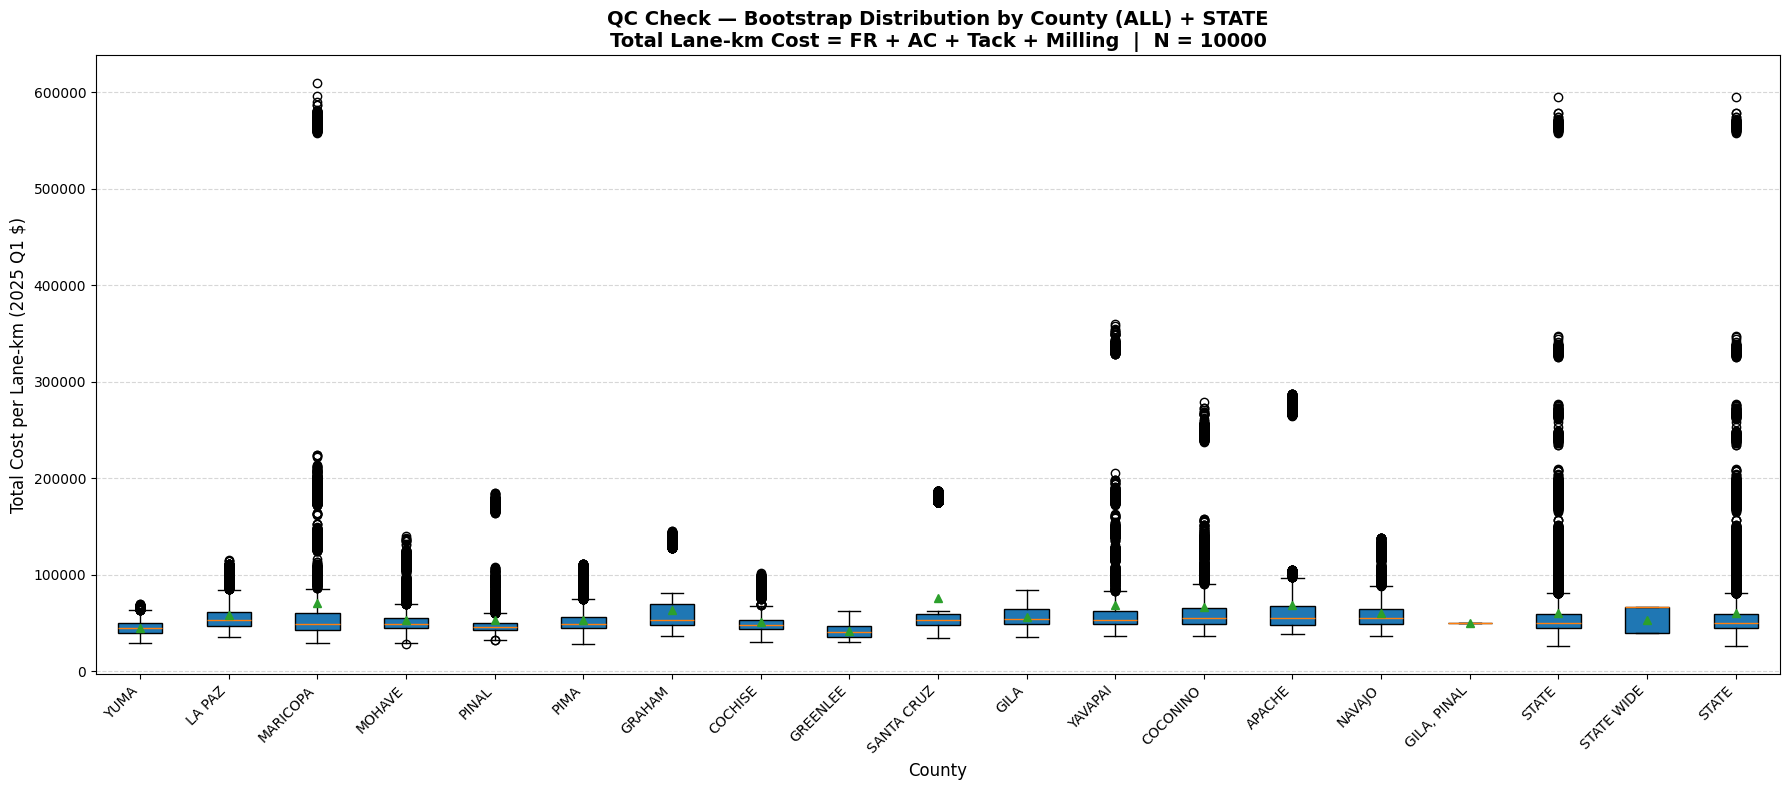

In [19]:
# ===============================================================
# Cell 1 — Bootstrap sampling (ALL counties + STATE) + QC BOXPLOT
#   Purpose: Quality-check all counties + STATE (not presentation)
#   Change N_BOOT_SAMPLES here only (used by Cells 2–3 too).
#   Outputs: boot_sum_dict, plot_boot_counties_all, plot_boot_data_all
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---- Global bootstrap settings (change here only) ----
N_BOOT_SAMPLES = 10000
RANDOM_SEED = GLOBAL_SEED
rng = np.random.default_rng(RANDOM_SEED)

# ---- Helper: values for a county; STATE uses full dataset ----
def _vals(df_, county, value_col):
    if county == "STATE":
        return df_[value_col].dropna().values
    return df_.loc[df_["County"] == county, value_col].dropna().values

# ---- Define the set of counties available anywhere ----
all_boot_counties = (
    set(fr_for_box["County"].unique())
    | set(ac_combined_df["County"].unique())
    | set(tack_for_box["County"].unique())
    | set(mill_for_box["County"].unique())
)

# Preserve AC treatment ordering (includes STATE if present)
boot_counties_ordered = [c for c in ac_plot_labels if c in all_boot_counties]

# If STATE wasn't in ac_plot_labels, append it (so we always compute it)
if "STATE" not in boot_counties_ordered and "STATE" in all_boot_counties:
    boot_counties_ordered.append("STATE")

# ---- Bootstrap sampling ----
boot_sum_dict = {c: [] for c in boot_counties_ordered}

for _ in range(N_BOOT_SAMPLES):
    for county in boot_counties_ordered:
        fr_vals   = _vals(fr_for_box,     county, "Total_Cost_LaneMile")
        ac_vals   = _vals(ac_combined_df, county, "Total_Cost_LaneMile")
        tack_vals = _vals(tack_for_box,   county, "Tack_Cost_Per_LaneMile")
        mill_vals = _vals(mill_for_box,   county, "Milling_Cost_Per_LaneMile")

        if len(fr_vals) and len(ac_vals) and len(tack_vals) and len(mill_vals):
            boot_sum_dict[county].append(
                rng.choice(fr_vals)
                + rng.choice(ac_vals)
                + rng.choice(tack_vals)
                + rng.choice(mill_vals)
            )
        else:
            boot_sum_dict[county].append(np.nan)

# ---- Build arrays for QC boxplot (ALL counties with any data + STATE) ----
plot_boot_counties_all = []
plot_boot_data_all = []

for c in boot_counties_ordered:
    arr = np.asarray(boot_sum_dict[c], dtype=float)
    arr = arr[~np.isnan(arr)]
    if c == "STATE" or len(arr) > 0:
        plot_boot_counties_all.append(c)
        plot_boot_data_all.append(arr)

print(f"Bootstrap complete: N_BOOT_SAMPLES = {N_BOOT_SAMPLES}")
print(f"Counties with valid combined samples: {len(plot_boot_counties_all)}")

# ---- QC BOXPLOT (all counties + STATE) ----
fig, ax = plt.subplots(figsize=(18, 8))
ax.boxplot(plot_boot_data_all, patch_artist=True, labels=plot_boot_counties_all, showmeans=True)

ax.set_title(
    f"QC Check — Bootstrap Distribution by County (ALL) + STATE\n"
    f"Total Lane-km Cost = FR + AC + Tack + Milling  |  N = {N_BOOT_SAMPLES}",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("County", fontsize=12)
ax.set_ylabel("Total Cost per Lane-km (2025 Q1 $)", fontsize=12)
ax.set_xticklabels(plot_boot_counties_all, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### Presentation

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1624571.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1624571.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = violin_df.groupby("County")["TotalCost"].mean()


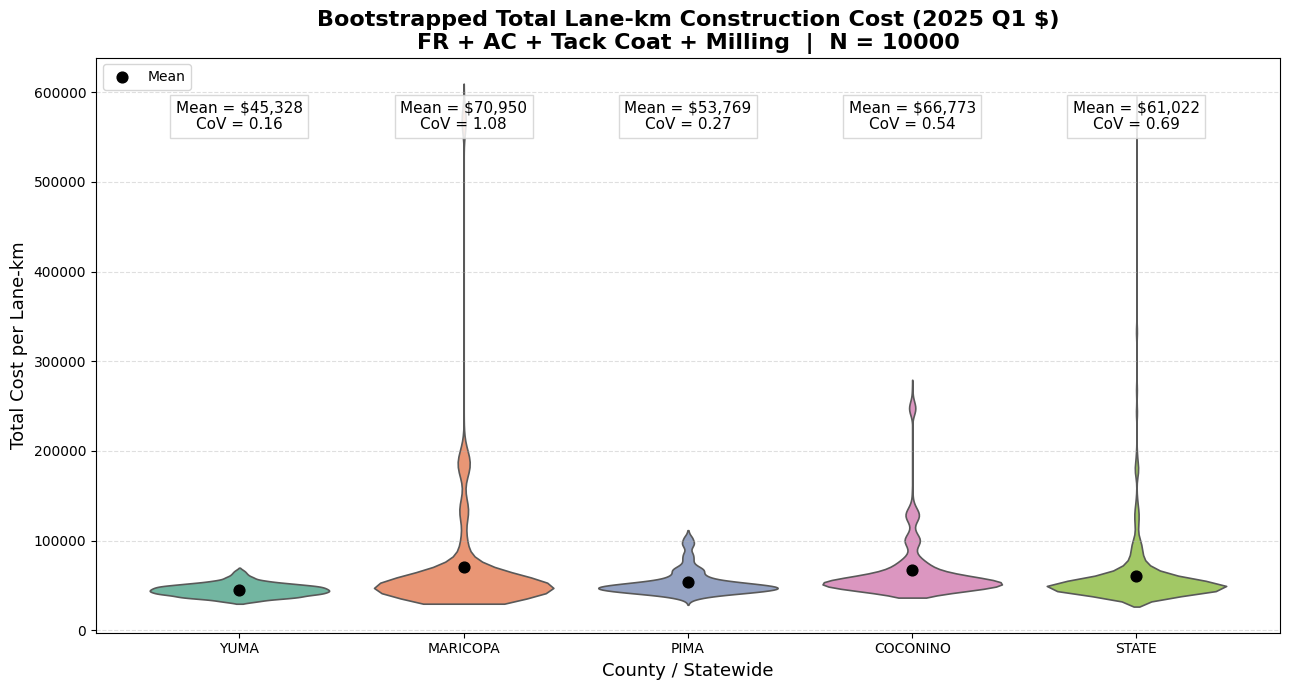

In [20]:
# ===============================================================
# Cell 2 — PRESENTATION: Violin plot (selected counties + STATE)
#   Shows: YUMA, MARICOPA, PIMA, COCONINO, STATE
#   Annotation: Mean + CoV (no N)
#   Uses outputs from Cell 1: boot_sum_dict + N_BOOT_SAMPLES
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PLOT_ORDER = ["YUMA", "MARICOPA", "PIMA", "COCONINO", "STATE"]

# Build tidy dataframe ONLY for selected counties from bootstrap dict
rows = []
for county in PLOT_ORDER:
    if county not in boot_sum_dict:
        continue
    arr = np.asarray(boot_sum_dict[county], dtype=float)
    arr = arr[~np.isnan(arr)]
    for v in arr:
        rows.append({"County": county, "TotalCost": v})

violin_df = pd.DataFrame(rows)
violin_df["County"] = pd.Categorical(violin_df["County"], categories=PLOT_ORDER, ordered=True)

plt.figure(figsize=(13, 7))
sns.violinplot(
    data=violin_df,
    x="County",
    y="TotalCost",
    order=PLOT_ORDER,
    inner=None,
    cut=0,
    linewidth=1.2,
    palette="Set2"
)

# Mean markers
means = violin_df.groupby("County")["TotalCost"].mean()
plt.scatter(np.arange(len(means)), means.values, color="black", s=60, zorder=3, label="Mean")

# Annotate Mean + CoV (no N)
ymax = violin_df["TotalCost"].max()
for i, county in enumerate(PLOT_ORDER):
    vals = violin_df.loc[violin_df["County"] == county, "TotalCost"].values
    if len(vals) == 0:
        continue
    mean = vals.mean()
    std = vals.std(ddof=0)
    cov = std / mean if mean != 0 else np.nan

    plt.text(
        i, ymax * 0.97,
        f"Mean = ${mean:,.0f}\nCoV = {cov:.2f}",
        ha="center", va="top",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray")
    )

plt.title(
    "Bootstrapped Total Lane-km Construction Cost (2025 Q1 $)\n"
    f"FR + AC + Tack Coat + Milling  |  N = {N_BOOT_SAMPLES}",
    fontsize=16, fontweight="bold"
)
plt.xlabel("County / Statewide", fontsize=13)
plt.ylabel("Total Cost per Lane-km", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()


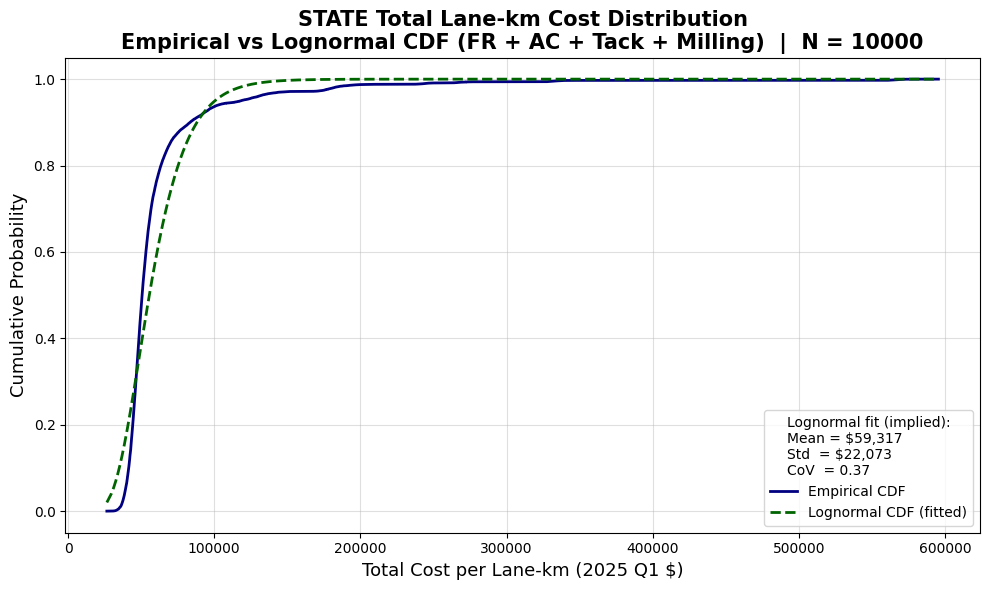

Lognormal interpretation (STATE):
  Mean = $59,316.79
  Std  = $22,072.78
  CoV  = 0.372
  (Offset used for fit: 0.00)


In [21]:
# ===============================================================
# Cell 3 — PRESENTATION: STATE CDF vs Lognormal fit
#   Interpretation: "STATE follows lognormal with mean/std/CoV"
#   Uses outputs from Cell 1: boot_sum_dict + N_BOOT_SAMPLES
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

if "STATE" not in boot_sum_dict:
    raise ValueError("STATE not found in boot_sum_dict. Check Cell 1 output.")

state_data = np.asarray(boot_sum_dict["STATE"], dtype=float)
state_data = state_data[~np.isnan(state_data)]

if len(state_data) == 0:
    raise ValueError("No STATE bootstrap data available.")

# Empirical CDF
state_sorted = np.sort(state_data)
emp_cdf = np.arange(1, len(state_sorted) + 1) / len(state_sorted)

# Lognormal fit requires positive values; offset if needed
min_val = state_sorted.min()
offset = 0.0
fit_data = state_sorted
if min_val <= 0:
    offset = -min_val + 1.0
    fit_data = state_sorted + offset

# Fit lognormal: shape=sigma, scale=exp(mu)
shape, loc, scale = lognorm.fit(fit_data, floc=0)
sigma = shape
mu = np.log(scale)

# Implied mean/std/CoV on original scale (after removing offset)
lognorm_mean = np.exp(mu + 0.5 * sigma**2) - offset
lognorm_std = np.sqrt((np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2))
lognorm_cov = lognorm_std / lognorm_mean if lognorm_mean != 0 else np.nan

# Fitted CDF evaluated at sorted data
log_cdf = lognorm.cdf(fit_data, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 6))
plt.plot(state_sorted, emp_cdf, lw=2, color="navy", label="Empirical CDF")
plt.plot(state_sorted, log_cdf, lw=2, linestyle="--", color="darkgreen", label="Lognormal CDF (fitted)")

plt.title(
    "STATE Total Lane-km Cost Distribution\n"
    f"Empirical vs Lognormal CDF (FR + AC + Tack + Milling)  |  N = {N_BOOT_SAMPLES}",
    fontsize=15, fontweight="bold"
)
plt.xlabel("Total Cost per Lane-km (2025 Q1 $)", fontsize=13)
plt.ylabel("Cumulative Probability", fontsize=13)
plt.grid(True, alpha=0.4)

plt.legend(
    title=(
        "Lognormal fit (implied):\n"
        f"Mean = ${lognorm_mean:,.0f}\n"
        f"Std  = ${lognorm_std:,.0f}\n"
        f"CoV  = {lognorm_cov:.2f}"
    ),
    loc="lower right"
)

plt.tight_layout()
plt.show()

print(
    "Lognormal interpretation (STATE):\n"
    f"  Mean = ${lognorm_mean:,.2f}\n"
    f"  Std  = ${lognorm_std:,.2f}\n"
    f"  CoV  = {lognorm_cov:.3f}\n"
    f"  (Offset used for fit: {offset:.2f})"
)


# ALL

Clean mill_for_box: 632 rows, STATE mean = $15,034, max = $34,359


C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


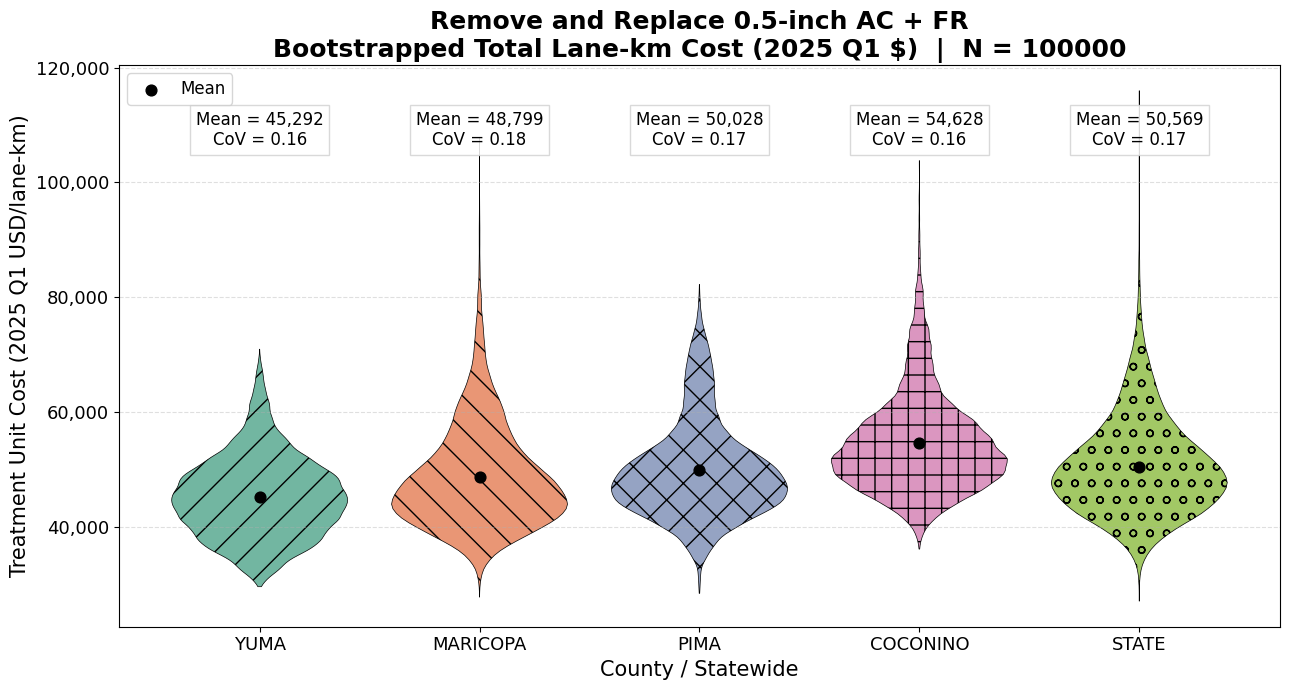

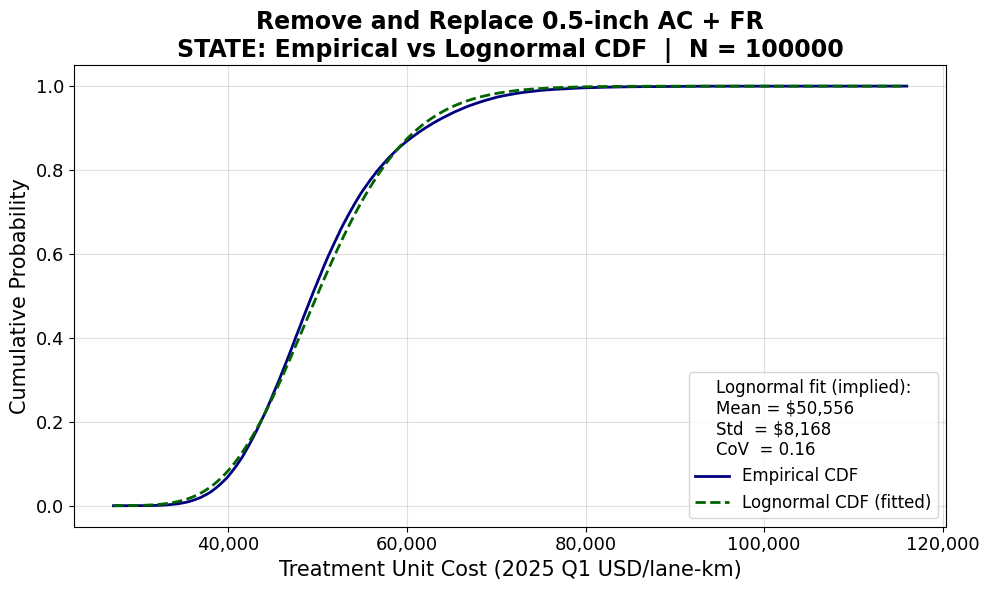

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


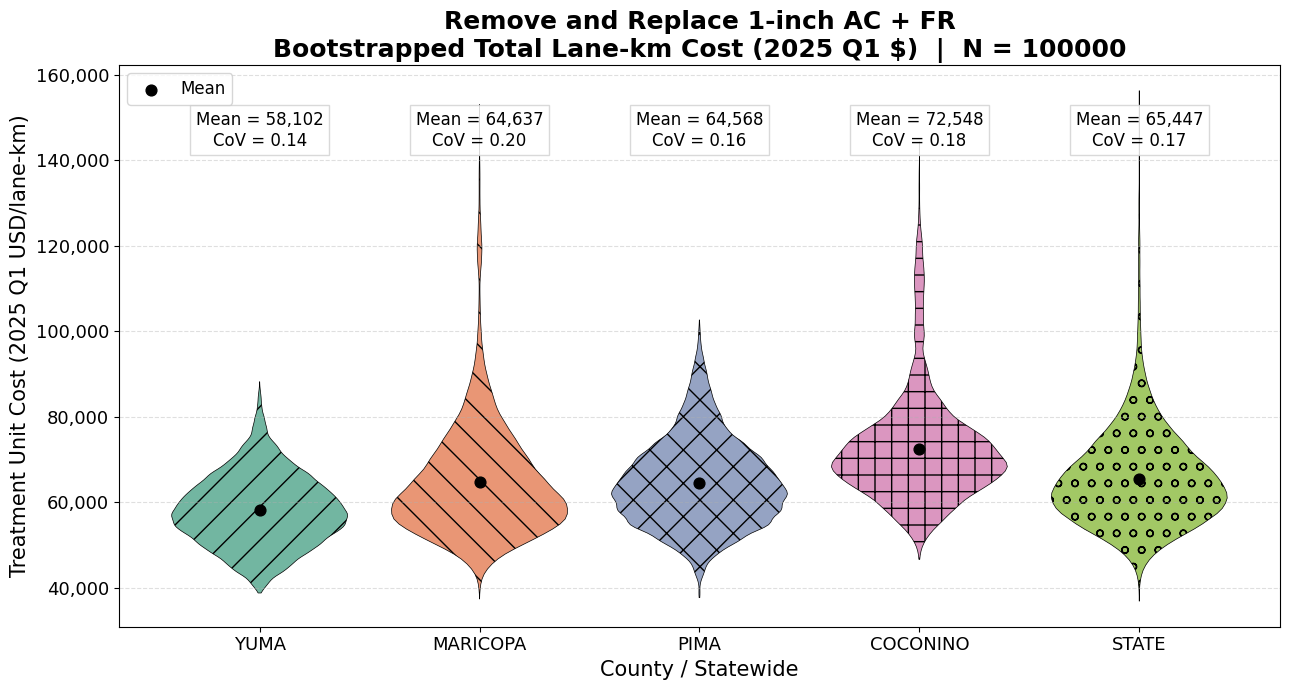

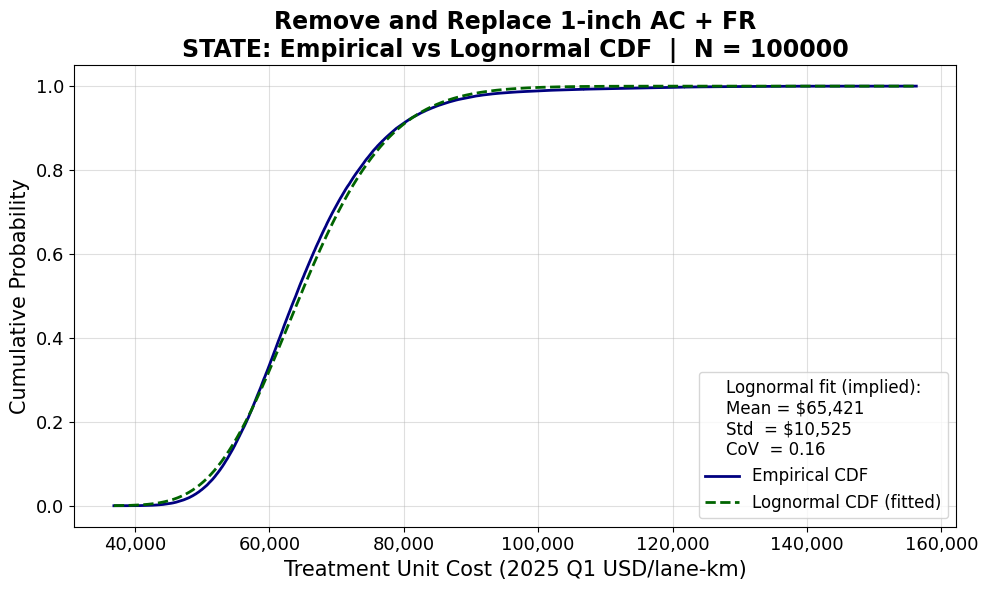

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


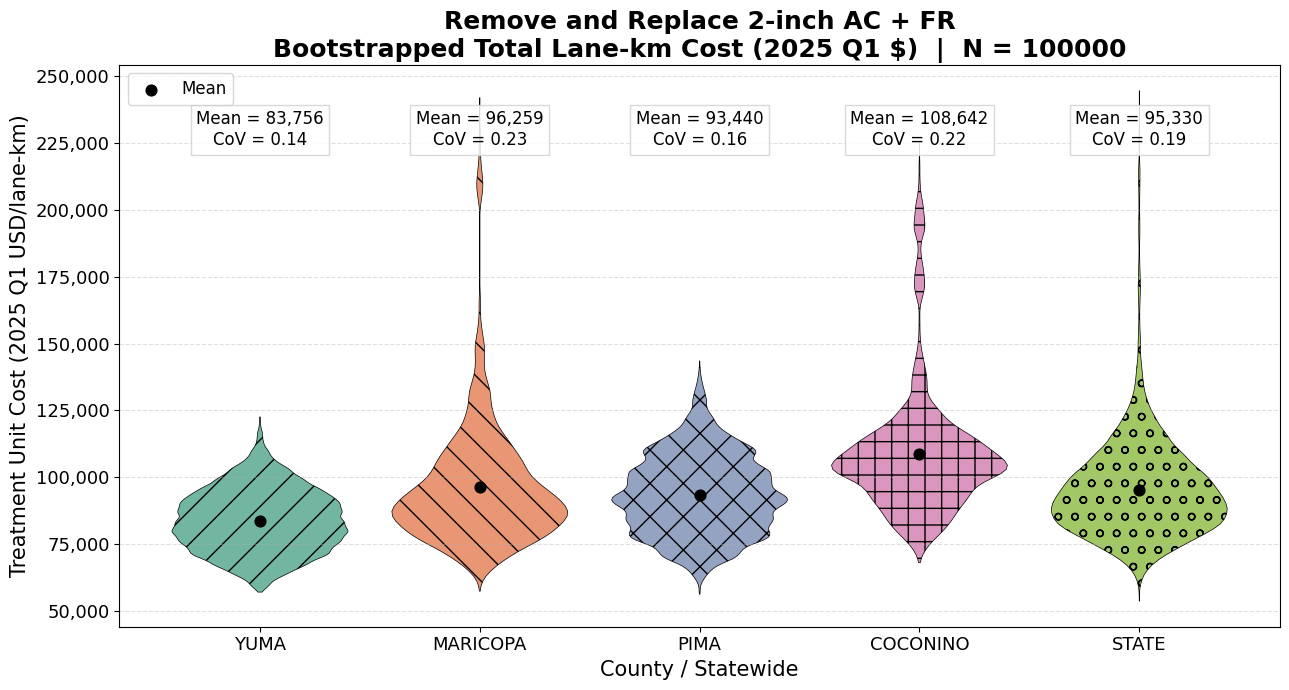

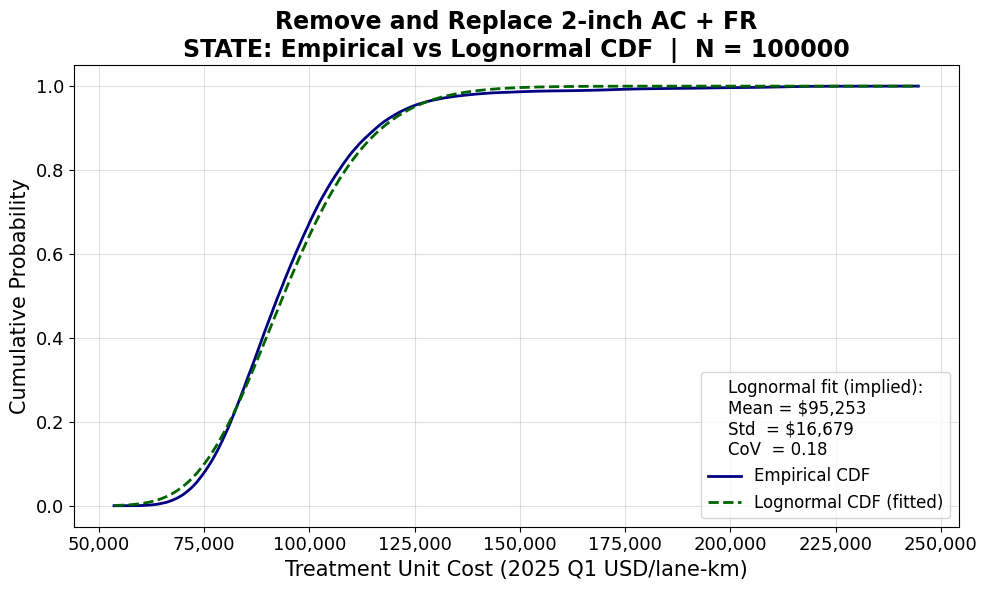

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


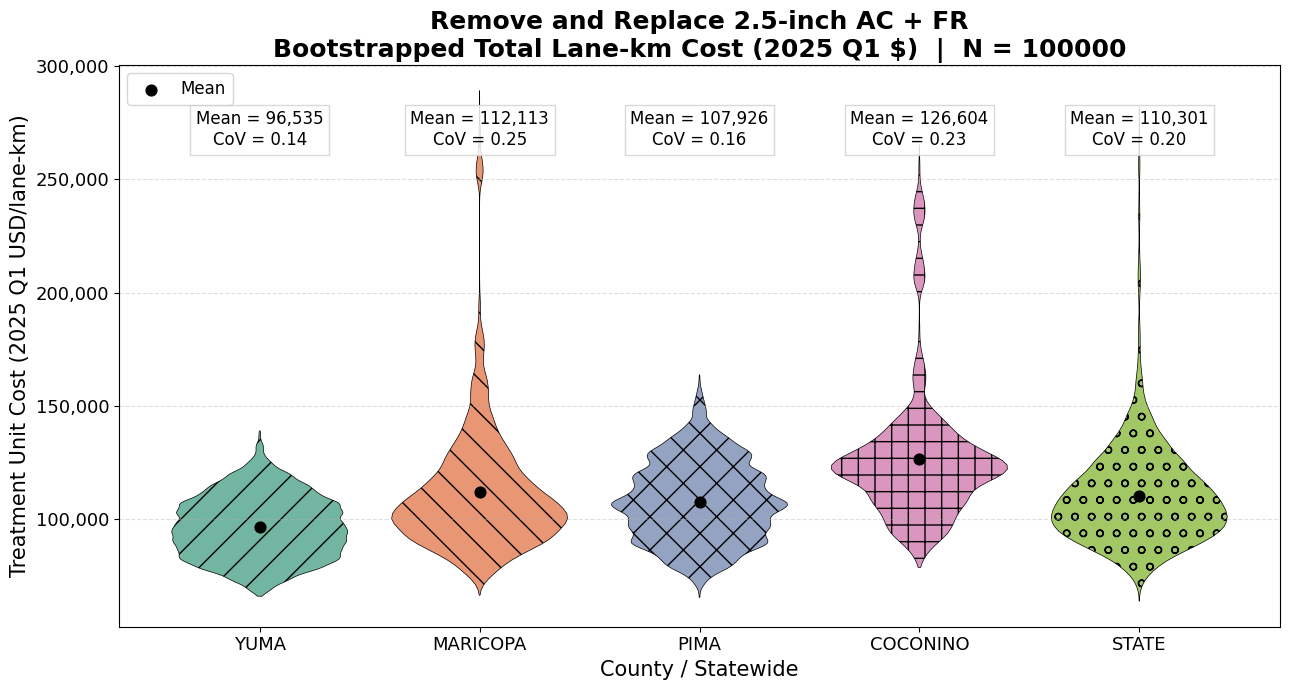

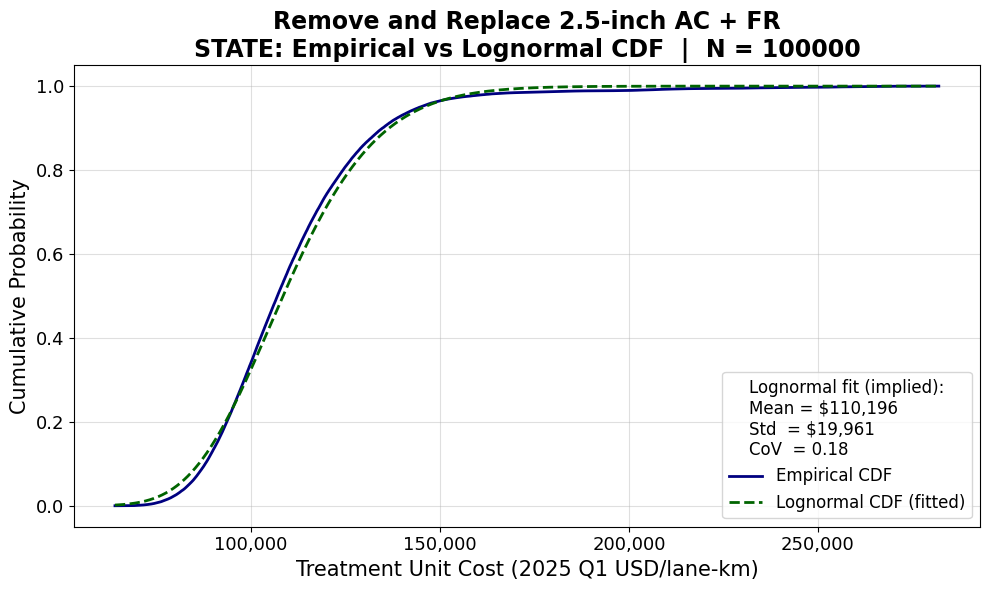

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


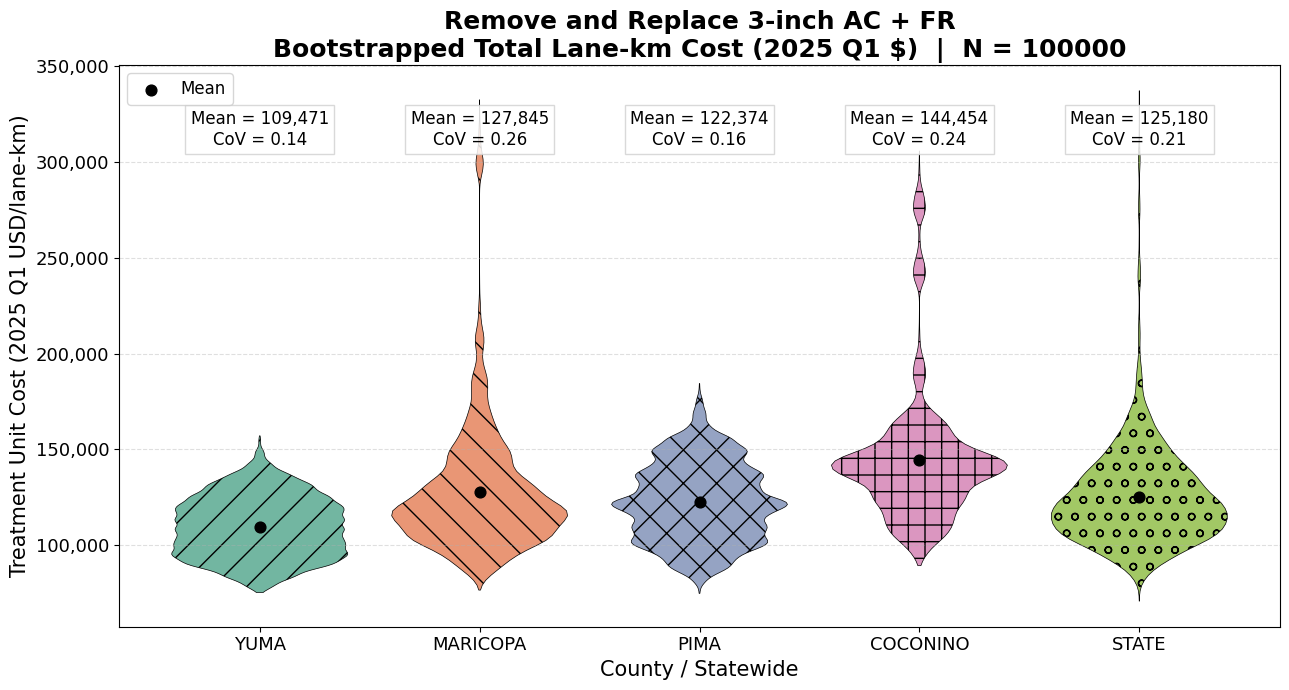

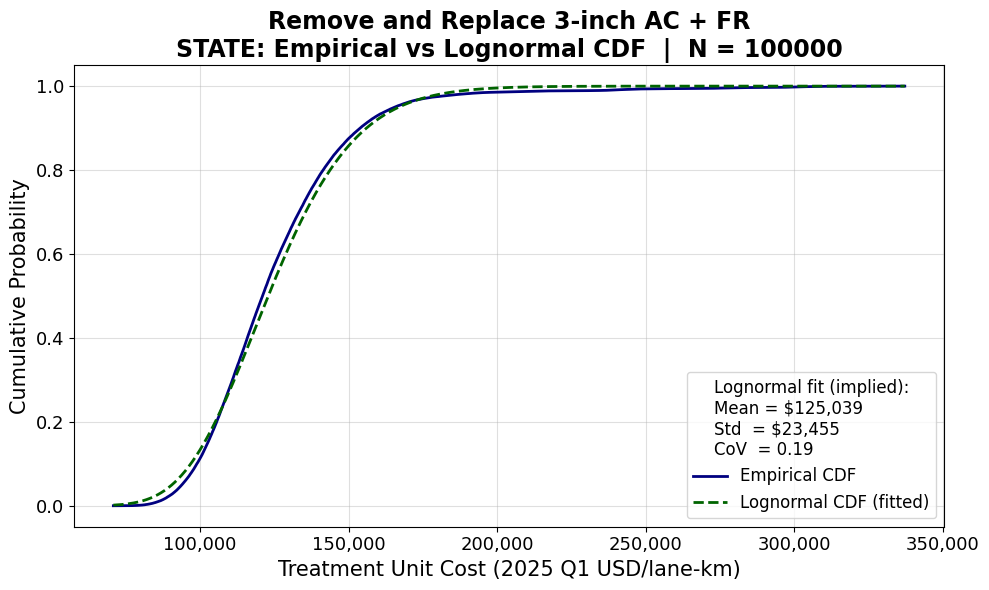

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


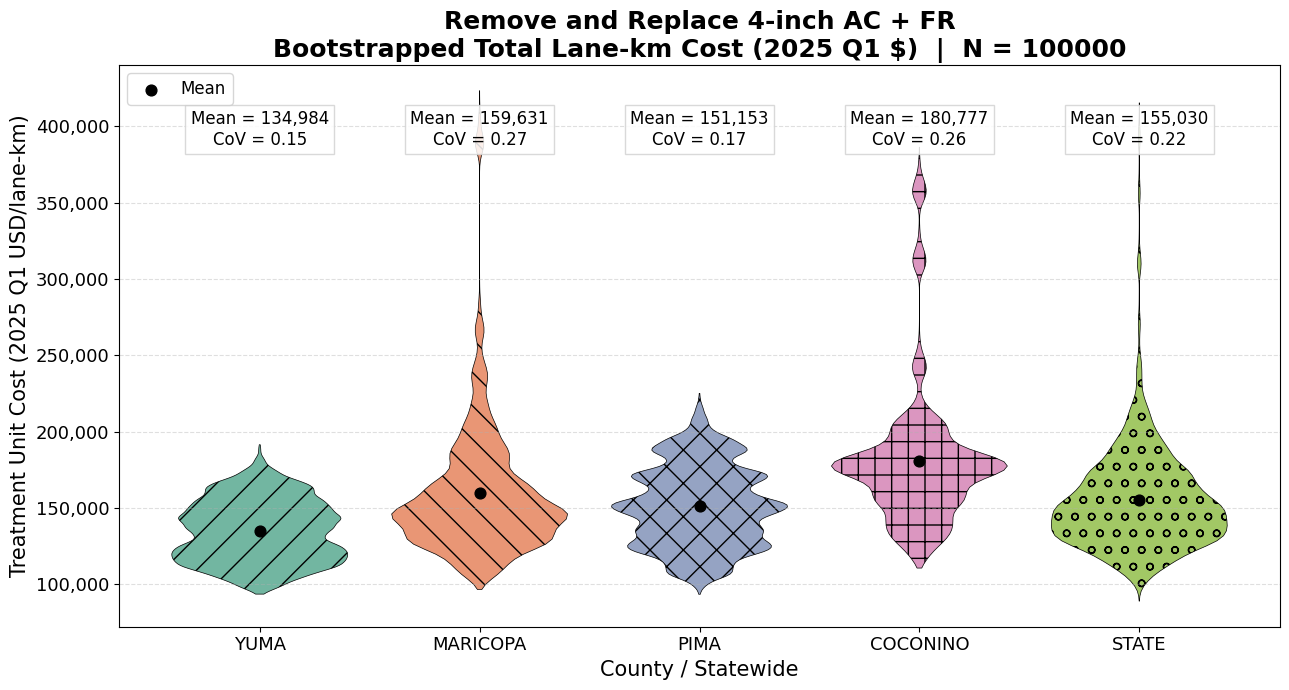

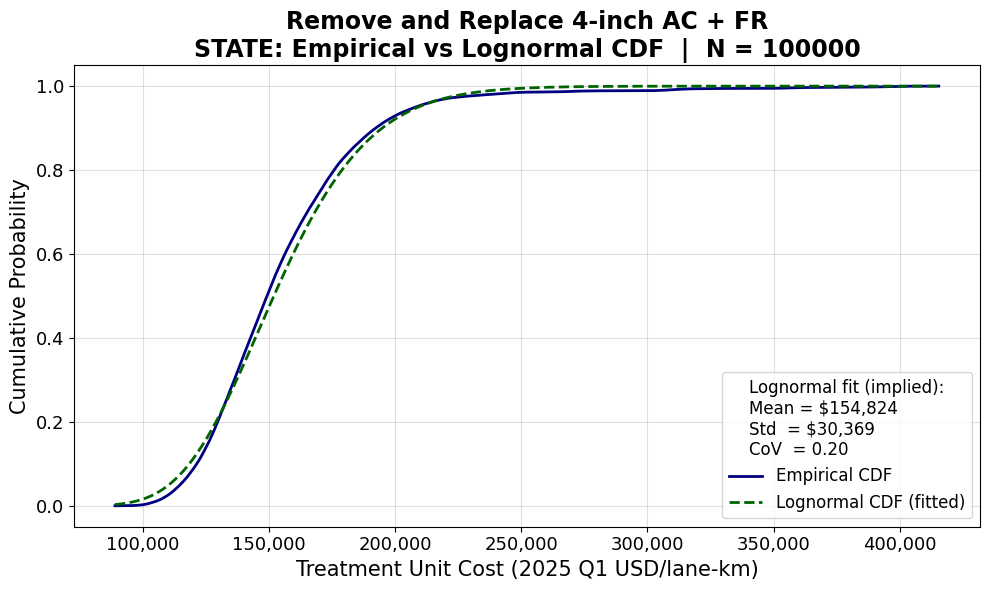

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1178055301.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


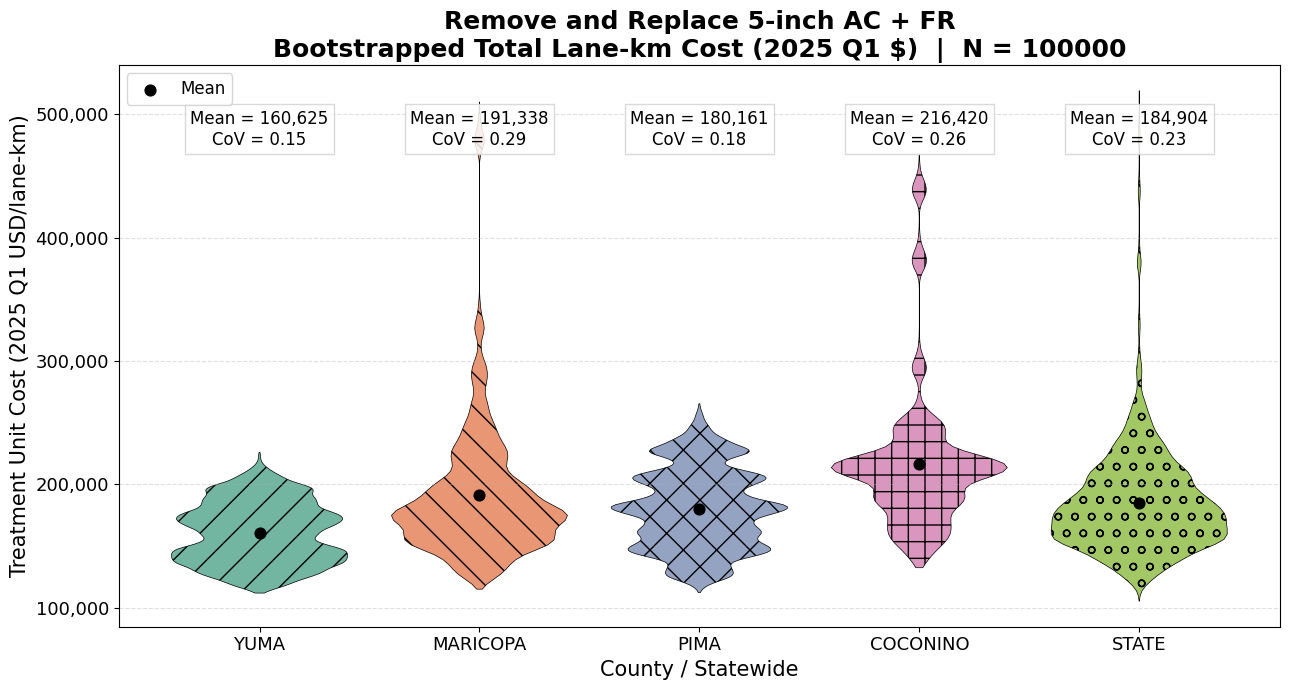

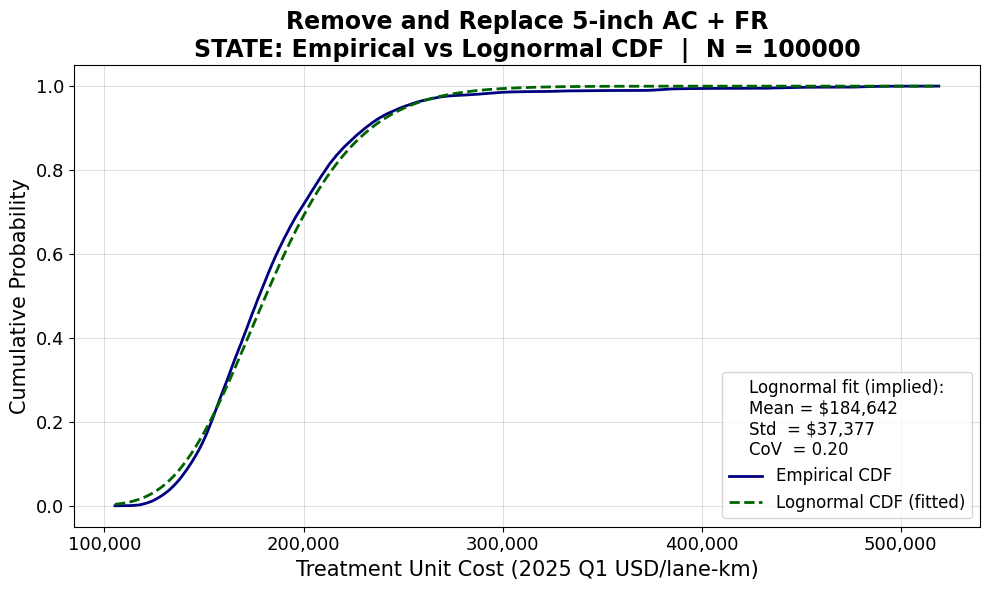

In [22]:
# ===============================================================
# Remove & Replace (AC thickness variants) + FR
# Outputs (for ALL thicknesses):
#   1) Violin plot (YUMA, MARICOPA, PIMA, COCONINO, STATE)
#   2) STATE CDF vs fitted Lognormal (mean/std/CoV shown)
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from matplotlib.collections import PolyCollection
from scipy.stats import lognorm

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# -----------------------
# Settings (change freely)
# -----------------------
THICKNESS_LIST_IN = [0.5, 1, 2, 2.5, 3, 4, 5]
TREATMENT_LABELS = {
    0.5: "Remove and Replace 0.5-inch AC + FR",
    1.0: "Remove and Replace 1-inch AC + FR",
    2.0: "Remove and Replace 2-inch AC + FR",
    2.5: "Remove and Replace 2.5-inch AC + FR",
    3.0: "Remove and Replace 3-inch AC + FR",
    4.0: "Remove and Replace 4-inch AC + FR",
    5.0: "Remove and Replace 5-inch AC + FR",
}

PLOT_COUNTIES = ["YUMA", "MARICOPA", "PIMA", "COCONINO", "STATE"]

N_BOOT_SAMPLES = 100000
RANDOM_SEED = GLOBAL_SEED
rng = np.random.default_rng(RANDOM_SEED)

# -----------------------
# Helper functions
# -----------------------
def _vals(df_, county, value_col):
    """Get samples for a county; STATE uses all rows."""
    if county == "STATE":
        return df_[value_col].dropna().values
    return df_.loc[df_["County"] == county, value_col].dropna().values


def iqr_filter(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Remove outliers beyond k*IQR from Q1/Q3."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - k * iqr) & (series <= q3 + k * iqr)]


def compute_ac_lane_mile_costs_for_thickness(
    df: pd.DataFrame,
    ac_binder_ids: set,
    ac_mix_ids: set,
    ac_ma_ids: set,
    thickness_in: float,
    unit_weight_pcf: float = 145.0,
    lane_width_ft: float = 12.0,
    asphalt_frac: float = 0.05,
    admix_agg_frac: float = 0.01,
) -> pd.DataFrame:
    """
    Build AC dataset (one row per job) with Total_Cost_LaneMile
    where thickness changes the tons/lane-mile.
    No IQR filter applied -- raw job costs preserved.
    """
    df_local = df.copy()
    df_local["PayItemID"] = df_local["PayItemID"].astype(str)

    # Lane-mile tonnage depends on thickness
    vol_ft3 = lane_width_ft * 5280.0 * (thickness_in / 12.0)
    mix_tons_per_lane_mile = vol_ft3 * unit_weight_pcf / 2000.0
    binder_tons_per_lane_mile = asphalt_frac * mix_tons_per_lane_mile
    agg_tons_per_lane_mile = mix_tons_per_lane_mile - binder_tons_per_lane_mile
    admix_tons_per_lane_mile = admix_agg_frac * agg_tons_per_lane_mile

    # Find jobids having ALL 3 groups (mix/binder/admix)
    job_mix = set(df_local.loc[df_local["PayItemID"].isin(ac_mix_ids), "JobID"].unique())
    job_binder = set(df_local.loc[df_local["PayItemID"].isin(ac_binder_ids), "JobID"].unique())
    job_ma = set(df_local.loc[df_local["PayItemID"].isin(ac_ma_ids), "JobID"].unique())
    ac_jobids = job_mix & job_binder & job_ma

    records = []
    for jobid in ac_jobids:
        job_rows = df_local[df_local["JobID"] == jobid]
        county = str(job_rows["County"].iloc[0]) if "County" in job_rows.columns and len(job_rows) else None

        mix_p = job_rows.loc[job_rows["PayItemID"].isin(ac_mix_ids), "UnitPrice_Real_2025Q1"].median()
        binder_p = job_rows.loc[job_rows["PayItemID"].isin(ac_binder_ids), "UnitPrice_Real_2025Q1"].median()
        ma_p = job_rows.loc[job_rows["PayItemID"].isin(ac_ma_ids), "UnitPrice_Real_2025Q1"].median()

        if np.isnan(mix_p) or np.isnan(binder_p) or np.isnan(ma_p):
            continue

        total_lane_mile_cost = (
            mix_p * mix_tons_per_lane_mile
            + binder_p * binder_tons_per_lane_mile
            + ma_p * admix_tons_per_lane_mile
        ) * MILE_TO_KM

        records.append({
            "JobID": jobid,
            "County": county,
            "AC_THICKNESS_IN": thickness_in,
            "Total_Cost_LaneMile": total_lane_mile_cost
        })

    ac_df = pd.DataFrame(records)
    if ac_df.empty:
        return ac_df

    # Add STATE group
    ac_state = ac_df.copy()
    ac_state["County"] = "STATE"
    return pd.concat([ac_df, ac_state], ignore_index=True)


def get_clean_mill_for_box(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Rebuild mill_for_box with IQR filter from raw df.
    This avoids using whatever mill_for_box is currently in memory.
    """
    MILLING_IDS = ["2020081", "2020082", "2020084", "2020085", "2020086", "2020088"]
    LANE_WIDTH_FT = 12
    LANE_LENGTH_FT = 5280
    LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0

    if "PayItemID_str" not in df_raw.columns:
        df_raw = df_raw.copy()
        df_raw["PayItemID_str"] = (
            df_raw["PayItemID"].astype(str)
            .str.extract(r"(\d+)", expand=False)
            .str.strip()
        )

    mill_rows = df_raw[df_raw["PayItemID_str"].isin(MILLING_IDS)].copy()
    mill_rows = mill_rows.dropna(subset=["UnitPrice_Real_2025Q1", "JobID", "County"])

    mill_job_price = (
        mill_rows.groupby(["JobID", "County"], as_index=False)
        .agg(Milling_UnitPrice=("UnitPrice_Real_2025Q1", "median"))
    )
    mill_job_price["Milling_Cost_Per_LaneMile"] = mill_job_price["Milling_UnitPrice"] * LANE_AREA_SQYD * MILE_TO_KM

    # IQR filter on milling costs
    cleaned = iqr_filter(mill_job_price["Milling_Cost_Per_LaneMile"])
    mill_job_price = mill_job_price.loc[cleaned.index].copy()

    mill_state = mill_job_price.copy()
    mill_state["County"] = "STATE"
    return pd.concat([mill_job_price, mill_state], ignore_index=True)


def bootstrap_total_cost(
    fr_for_box: pd.DataFrame,
    ac_df_for_thickness: pd.DataFrame,
    tack_for_box: pd.DataFrame,
    mill_for_box: pd.DataFrame,
    n_boot: int,
    rng: np.random.Generator,
    counties: list,
) -> dict:
    """Return dict county -> numpy array of bootstrapped sums."""
    out = {}
    for county in counties:
        fr_vals   = _vals(fr_for_box,          county, "Total_Cost_LaneMile")
        ac_vals   = _vals(ac_df_for_thickness,  county, "Total_Cost_LaneMile")
        tack_vals = _vals(tack_for_box,         county, "Tack_Cost_Per_LaneMile")
        mill_vals = _vals(mill_for_box,         county, "Milling_Cost_Per_LaneMile")

        if len(fr_vals) and len(ac_vals) and len(tack_vals) and len(mill_vals):
            sums = (
                rng.choice(fr_vals,   size=n_boot, replace=True)
                + rng.choice(ac_vals,   size=n_boot, replace=True)
                + rng.choice(tack_vals, size=n_boot, replace=True)
                + rng.choice(mill_vals, size=n_boot, replace=True)
            )
            out[county] = sums.astype(float)
        else:
            out[county] = np.array([], dtype=float)
    return out


def plot_violin_selected(boot_dict: dict, treatment_title: str, n_boot: int, plot_order: list):
    """Violin plot for selected counties with mean & CoV. 508-compliant: distinct hatches per county."""
    # Distinct hatch patterns for color-blind / print accessibility (Section 508)
    HATCHES = ['/', '\\', 'x', '+', 'o']

    rows = []
    for c in plot_order:
        arr = np.asarray(boot_dict.get(c, []), dtype=float)
        arr = arr[~np.isnan(arr)]
        for v in arr:
            rows.append({"County": c, "TotalCost": v})

    violin_df = pd.DataFrame(rows)
    if violin_df.empty:
        print(f"[WARN] No data to plot violin for: {treatment_title}")
        return

    violin_df["County"] = pd.Categorical(violin_df["County"], categories=plot_order, ordered=True)

    fig, ax = plt.subplots(figsize=(13, 7))
    sns.violinplot(
        data=violin_df,
        x="County",
        y="TotalCost",
        order=plot_order,
        inner=None,
        cut=0,
        linewidth=1.5,
        palette="Set2",
        ax=ax,
    )

    # Apply distinct hatch patterns to each violin body (Section 508 compliance)
    poly_patches = [c for c in ax.collections if isinstance(c, PolyCollection)]
    for patch, hatch in zip(poly_patches, HATCHES[:len(plot_order)]):
        patch.set_hatch(hatch)
        patch.set_edgecolor("black")
        patch.set_linewidth(0.5)

    means = violin_df.groupby("County", observed=True)["TotalCost"].mean()
    ax.scatter(np.arange(len(means)), means.values, color="black", s=60, zorder=3, label="Mean")

    ymax = violin_df["TotalCost"].max()
    for i, county in enumerate(plot_order):
        vals = violin_df.loc[violin_df["County"] == county, "TotalCost"].values
        if len(vals) == 0:
            continue
        mean = vals.mean()
        std = vals.std(ddof=0)
        cov = std / mean if mean != 0 else np.nan
        ax.text(
            i, ymax * 0.97,
            f"Mean = {mean:,.0f}\nCoV = {cov:.2f}",
            ha="center", va="top",
            fontsize=12,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray")
        )

    ax.set_title(
        f"{treatment_title}\nBootstrapped Total Lane-km Cost (2025 Q1 $)  |  N = {n_boot}",
        fontsize=18, fontweight="bold"
    )
    ax.set_xlabel("County / Statewide", fontsize=15)
    ax.set_ylabel("Treatment Unit Cost (2025 Q1 USD/lane-km)", fontsize=15)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(loc="upper left", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_state_cdf_lognormal(state_arr: np.ndarray, treatment_title: str, n_boot: int):
    """STATE empirical CDF vs fitted lognormal; shows implied mean/std/CoV."""
    arr = np.asarray(state_arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        print(f"[WARN] No STATE data for CDF: {treatment_title}")
        return

    x = np.sort(arr)
    emp_cdf = np.arange(1, len(x) + 1) / len(x)

    offset = 0.0
    fit_data = x
    if x.min() <= 0:
        offset = -x.min() + 1.0
        fit_data = x + offset

    shape, loc, scale = lognorm.fit(fit_data, floc=0)
    sigma = shape
    mu = np.log(scale)

    lognorm_mean = np.exp(mu + 0.5 * sigma**2) - offset
    lognorm_std = np.sqrt((np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2))
    lognorm_cov = lognorm_std / lognorm_mean if lognorm_mean != 0 else np.nan

    log_cdf = lognorm.cdf(fit_data, shape, loc=loc, scale=scale)

    plt.figure(figsize=(10, 6))
    plt.plot(x, emp_cdf, lw=2, color="navy", label="Empirical CDF")
    plt.plot(x, log_cdf, lw=2, linestyle="--", color="darkgreen", label="Lognormal CDF (fitted)")

    plt.title(
        f"{treatment_title}\nSTATE: Empirical vs Lognormal CDF  |  N = {n_boot}",
        fontsize=17, fontweight="bold"
    )
    plt.xlabel("Treatment Unit Cost (2025 Q1 USD/lane-km)", fontsize=15)
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
    plt.ylabel("Cumulative Probability", fontsize=15)
    plt.tick_params(axis="both", labelsize=13)
    plt.grid(True, alpha=0.4)
    plt.legend(
        title=(
            "Lognormal fit (implied):\n"
            f"Mean = ${lognorm_mean:,.0f}\n"
            f"Std  = ${lognorm_std:,.0f}\n"
            f"CoV  = {lognorm_cov:.2f}"
        ),
        loc="lower right",
        fontsize=12,
        title_fontsize=12,
    )
    plt.tight_layout()
    plt.show()


# ===============================================================
# RUN FOR ALL THICKNESSES
# ===============================================================

# Ensure PayItemID is str once
df["PayItemID"] = df["PayItemID"].astype(str)

# ---- Rebuild mill_for_box cleanly with IQR filter ----
# Guarantees clean milling data regardless of cell execution order
mill_for_box_clean = get_clean_mill_for_box(df)
print(f"Clean mill_for_box: {len(mill_for_box_clean)} rows, "
      f"STATE mean = ${mill_for_box_clean[mill_for_box_clean['County']=='STATE']['Milling_Cost_Per_LaneMile'].mean():,.0f}, "
      f"max = ${mill_for_box_clean['Milling_Cost_Per_LaneMile'].max():,.0f}")

for thick in THICKNESS_LIST_IN:
    title = TREATMENT_LABELS.get(float(thick), f"Remove and Replace {thick}-inch AC + FR")

    # 1) Build AC dataset for this thickness (no IQR filter)
    ac_thick_df = compute_ac_lane_mile_costs_for_thickness(
        df=df,
        ac_binder_ids=set(map(str, ac_binder_ids)),
        ac_mix_ids=set(map(str, ac_mix_ids)),
        ac_ma_ids=set(map(str, ac_ma_ids)),
        thickness_in=float(thick),
        unit_weight_pcf=145.0,
        lane_width_ft=12.0,
        asphalt_frac=0.05,
        admix_agg_frac=0.01,
    )

    if ac_thick_df.empty:
        print(f"[SKIP] No valid AC jobs found for thickness={thick} in -- {title}")
        continue

    # 2) Bootstrap combined totals for selected counties + STATE
    boot_dict = bootstrap_total_cost(
        fr_for_box=fr_for_box,
        ac_df_for_thickness=ac_thick_df,
        tack_for_box=tack_for_box,
        mill_for_box=mill_for_box_clean,
        n_boot=N_BOOT_SAMPLES,
        rng=rng,
        counties=PLOT_COUNTIES,
    )

    # 3) Presentation plots: Violin (selected) + STATE CDF vs lognormal
    plot_violin_selected(boot_dict, title, N_BOOT_SAMPLES, PLOT_COUNTIES)
    plot_state_cdf_lognormal(boot_dict.get("STATE", np.array([])), title, N_BOOT_SAMPLES)

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\3027429241.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\3027429241.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_adj = violin_df_adj.groupby("County")["TotalCost"].mean()


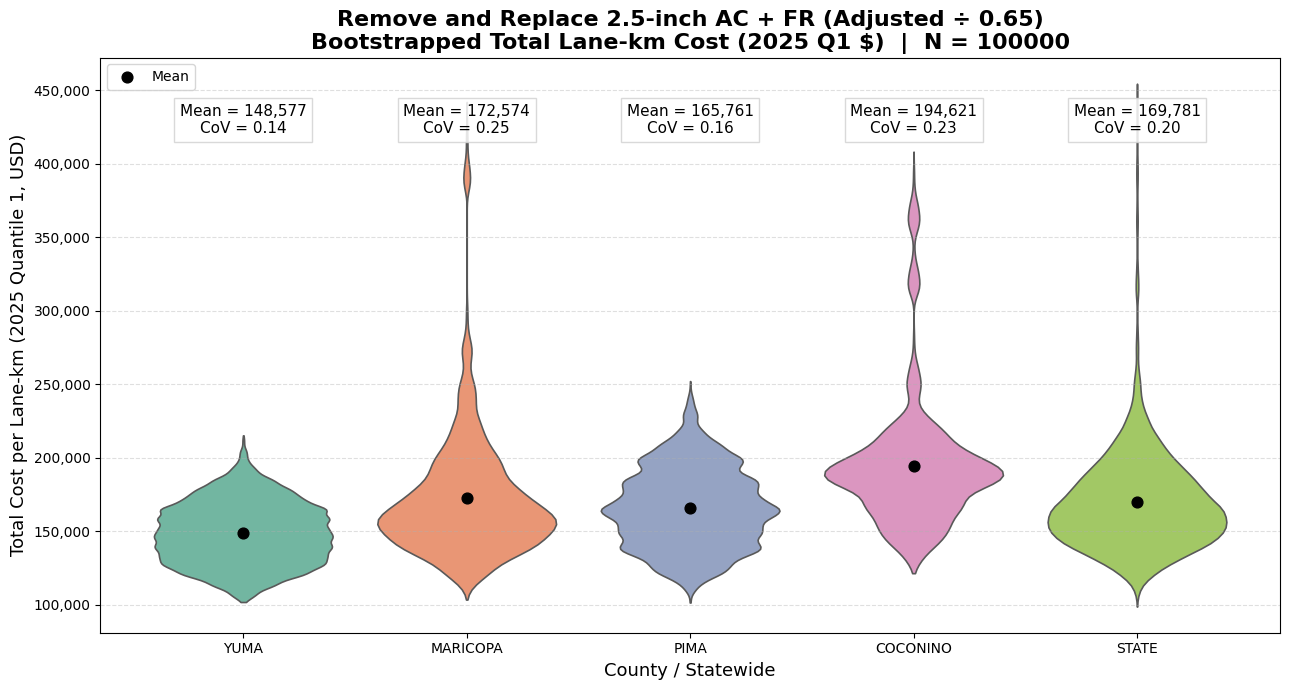

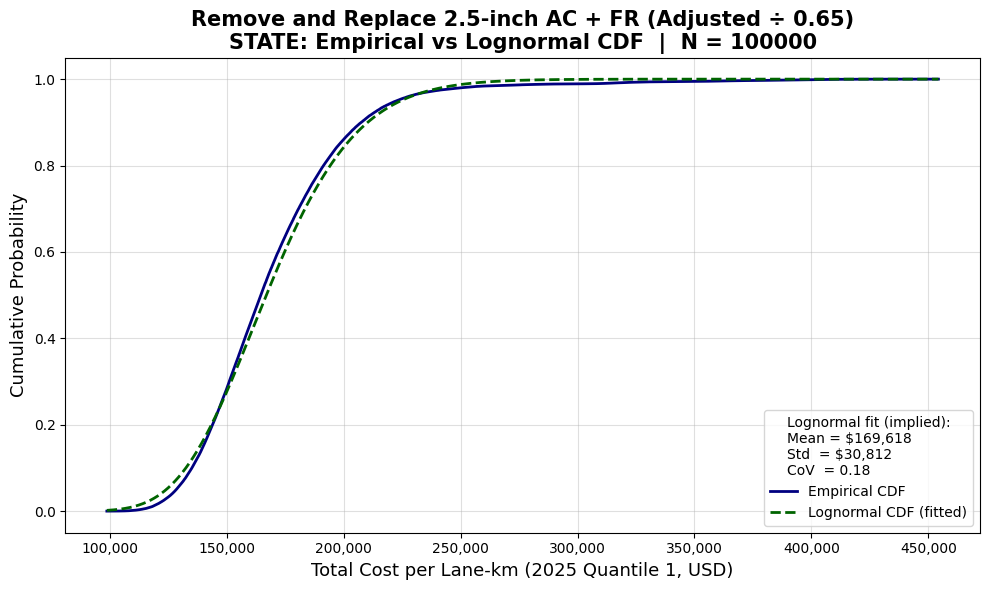

In [23]:
# ===============================================================
# Remove and Replace 2.5-inch AC + FR — Adjusted ÷ 0.65
# Applies a /0.65 adjustment to the 2.5-inch Remove & Replace cost (accounts for lane-area fraction of AC only)
# All bootstrapped values divided by 0.65 before plotting
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.stats import lognorm

ADJUST_THICK  = 2.5
ADJUST_FACTOR = 0.65
ADJUSTED_TITLE = "Remove and Replace 2.5-inch AC + FR (Adjusted ÷ 0.65)"

N_BOOT_SAMPLES = 100000
RANDOM_SEED    = GLOBAL_SEED
PLOT_COUNTIES  = ["YUMA", "MARICOPA", "PIMA", "COCONINO", "STATE"]

# ---- Rebuild AC 2.5-inch ----
ac_thick_df_adj = compute_ac_lane_mile_costs_for_thickness(
    df=df,
    ac_binder_ids=set(map(str, ac_binder_ids)),
    ac_mix_ids=set(map(str, ac_mix_ids)),
    ac_ma_ids=set(map(str, ac_ma_ids)),
    thickness_in=float(ADJUST_THICK),
    unit_weight_pcf=145.0,
    lane_width_ft=12.0,
    asphalt_frac=0.05,
    admix_agg_frac=0.01,
)

if ac_thick_df_adj.empty:
    print("[SKIP] No valid AC jobs found for 2.5-inch thickness.")
else:
    # ---- Bootstrap ----
    rng_adj = np.random.default_rng(RANDOM_SEED)

    boot_dict_adj = bootstrap_total_cost(
        fr_for_box=fr_for_box,
        ac_df_for_thickness=ac_thick_df_adj,
        tack_for_box=tack_for_box,
        mill_for_box=mill_for_box_clean,
        n_boot=N_BOOT_SAMPLES,
        rng=rng_adj,
        counties=PLOT_COUNTIES,
    )

    # ---- Divide all bootstrapped values by 0.65 ----
    boot_dict_scaled = {
        county: arr / ADJUST_FACTOR
        for county, arr in boot_dict_adj.items()
    }

    # ================================================================
    # Plot 1: Violin
    # ================================================================
    rows = []
    for c in PLOT_COUNTIES:
        arr = np.asarray(boot_dict_scaled.get(c, []), dtype=float)
        arr = arr[~np.isnan(arr)]
        for v in arr:
            rows.append({"County": c, "TotalCost": v})

    violin_df_adj = pd.DataFrame(rows)
    violin_df_adj["County"] = pd.Categorical(
        violin_df_adj["County"], categories=PLOT_COUNTIES, ordered=True
    )

    plt.figure(figsize=(13, 7))
    sns.violinplot(
        data=violin_df_adj,
        x="County",
        y="TotalCost",
        order=PLOT_COUNTIES,
        inner=None,
        cut=0,
        linewidth=1.2,
        palette="Set2",
    )

    means_adj = violin_df_adj.groupby("County")["TotalCost"].mean()
    plt.scatter(
        np.arange(len(means_adj)), means_adj.values,
        color="black", s=60, zorder=3, label="Mean"
    )

    ymax_adj = violin_df_adj["TotalCost"].max()
    for i, county in enumerate(PLOT_COUNTIES):
        vals = violin_df_adj.loc[violin_df_adj["County"] == county, "TotalCost"].values
        if len(vals) == 0:
            continue
        mean = vals.mean()
        std  = vals.std(ddof=0)
        cov  = std / mean if mean != 0 else np.nan
        plt.text(
            i, ymax_adj * 0.97,
            f"Mean = {mean:,.0f}\nCoV = {cov:.2f}",
            ha="center", va="top",
            fontsize=11,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray")
        )

    plt.title(
        f"{ADJUSTED_TITLE}\nBootstrapped Total Lane-km Cost (2025 Q1 $)  |  N = {N_BOOT_SAMPLES}",
        fontsize=16, fontweight="bold"
    )
    plt.xlabel("County / Statewide", fontsize=13)
    plt.ylabel("Total Cost per Lane-km (2025 Quantile 1, USD)", fontsize=13)
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # ================================================================
    # Plot 2: STATE CDF vs Lognormal
    # ================================================================
    state_arr = np.asarray(boot_dict_scaled.get("STATE", []), dtype=float)
    state_arr = state_arr[~np.isnan(state_arr)]

    if len(state_arr) == 0:
        print("[WARN] No STATE data for CDF.")
    else:
        x = np.sort(state_arr)
        emp_cdf = np.arange(1, len(x) + 1) / len(x)

        offset   = 0.0
        fit_data = x
        if x.min() <= 0:
            offset   = -x.min() + 1.0
            fit_data = x + offset

        shape, loc, scale = lognorm.fit(fit_data, floc=0)
        sigma = shape
        mu    = np.log(scale)

        lognorm_mean = np.exp(mu + 0.5 * sigma**2) - offset
        lognorm_std  = np.sqrt((np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2))
        lognorm_cov  = lognorm_std / lognorm_mean if lognorm_mean != 0 else np.nan

        log_cdf = lognorm.cdf(fit_data, shape, loc=loc, scale=scale)

        plt.figure(figsize=(10, 6))
        plt.plot(x, emp_cdf, lw=2, color="navy",      label="Empirical CDF")
        plt.plot(x, log_cdf, lw=2, linestyle="--",
                 color="darkgreen", label="Lognormal CDF (fitted)")

        plt.title(
            f"{ADJUSTED_TITLE}\nSTATE: Empirical vs Lognormal CDF  |  N = {N_BOOT_SAMPLES}",
            fontsize=15, fontweight="bold"
        )
        plt.xlabel("Total Cost per Lane-km (2025 Quantile 1, USD)", fontsize=13)
        plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
        plt.ylabel("Cumulative Probability", fontsize=13)
        plt.grid(True, alpha=0.4)
        plt.legend(
            title=(
                "Lognormal fit (implied):\n"
                f"Mean = ${lognorm_mean:,.0f}\n"
                f"Std  = ${lognorm_std:,.0f}\n"
                f"CoV  = {lognorm_cov:.2f}"
            ),
            loc="lower right"
        )
        plt.tight_layout()
        plt.show()


STATE-Level Mean Cost Composition (Percent):


,Treatment,AC_%,FR_%,Milling_%,Tack_%,Total_mean
0,Remove and Replace 0.5-inch AC + FR,24.596753,32.126221,41.488922,1.788104,60670.131070
1,Remove and Replace 1-inch AC + FR,39.482173,25.784156,33.298558,1.435113,75593.013301
2,Remove and Replace 2-inch AC + FR,56.612501,18.485628,23.872985,1.028886,105438.777763
3,Remove and Replace 2.5-inch AC + FR,61.991843,16.193712,20.913124,0.901321,120361.659995
4,Remove and Replace 3-inch AC + FR,66.184423,14.407426,18.606252,0.801899,135284.542226
5,Remove and Replace 4-inch AC + FR,72.296273,11.803418,15.243346,0.656963,165130.306688
6,Remove and Replace 5-inch AC + FR,76.536993,9.996622,12.909986,0.556399,194976.071150


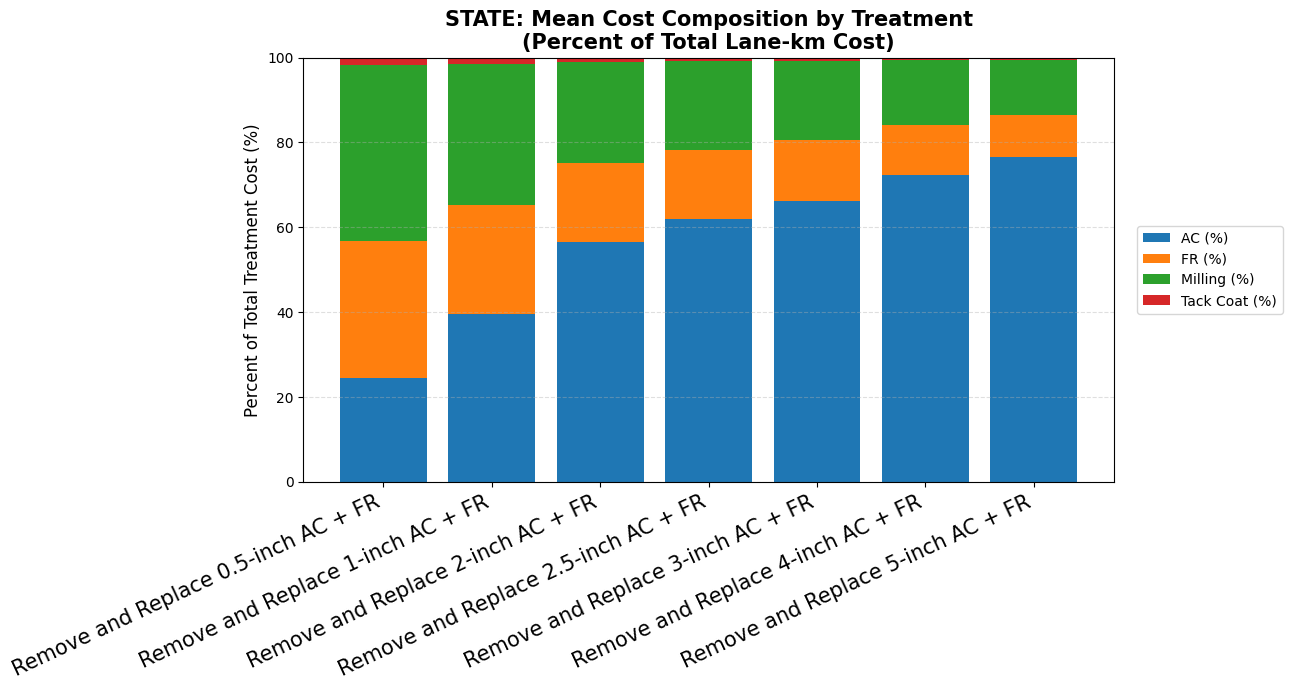

In [24]:
# ===============================================================
# STATE-LEVEL COST COMPOSITION
#   - AC + FR + Milling + Tack
#   - Percent contribution (sums to 100% for each treatment)
#   - X-axis: FULL treatment names
#   - Legend: outside plot
#
# Run this AFTER the Remove & Replace + FR code
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Helper: STATE mean
# -----------------------
def state_mean(df_, value_col):
    vals = df_.loc[df_["County"] == "STATE", value_col].dropna().values
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

# -----------------------
# Collect STATE means and proportions
# -----------------------
rows = []

for thick in THICKNESS_LIST_IN:
    try:
        # Get treatment name
        treatment_name = TREATMENT_LABELS.get(
            float(thick),
            f"Remove and Replace {thick}-inch AC + FR"
        )
    except Exception as e:
        print(f"[ERR] Bad thickness value {thick}: {e}")
        continue

    # Build AC dataset for this thickness (safely)
    try:
        ac_df = compute_ac_lane_mile_costs_for_thickness(
            df,
            set(map(str, ac_binder_ids)),
            set(map(str, ac_mix_ids)),
            set(map(str, ac_ma_ids)),
            float(thick),
            145.0,
            12.0,
            0.05,
            0.01,
        )
    except TypeError:
        # Try call without keywords (backward compatibility)
        try:
            ac_df = compute_ac_lane_mile_costs_for_thickness(
                df,
                set(map(str, ac_binder_ids)),
                set(map(str, ac_mix_ids)),
                set(map(str, ac_ma_ids)),
                float(thick),
                145.0,
                12.0,
                0.05,
                0.01,
            )
        except Exception as e:
            print(f"[ERR] Failed to compute AC for {treatment_name}: {e}")
            continue
    except Exception as e:
        print(f"[ERR] Failed to compute AC for {treatment_name}: {e}")
        continue

    if ac_df is None or ac_df.empty:
        print(f"[SKIP] No AC data for {treatment_name}")
        continue

    # STATE-level means (defensive)
    try:
        mean_ac   = state_mean(ac_df, "Total_Cost_LaneMile")
        mean_fr   = state_mean(fr_for_box, "Total_Cost_LaneMile")
        mean_mill = state_mean(mill_for_box, "Milling_Cost_Per_LaneMile")
        mean_tack = state_mean(tack_for_box, "Tack_Cost_Per_LaneMile")
        comps = np.array([mean_ac, mean_fr, mean_mill, mean_tack], dtype=float)
    except Exception as e:
        print(f"[ERR] Data error for {treatment_name}: {e}")
        continue

    if not np.all(np.isfinite(comps)):
        print(f"[WARN] Missing component for {treatment_name}, skipping.")
        continue

    total = comps.sum()
    if total <= 0:
        print(f"[WARN] Non-positive total for {treatment_name}, skipping.")
        continue

    pct = 100.0 * comps / total

    rows.append({
        "Treatment": treatment_name,
        "AC_%": pct[0],
        "FR_%": pct[1],
        "Milling_%": pct[2],
        "Tack_%": pct[3],
        "AC_mean": mean_ac,
        "FR_mean": mean_fr,
        "Milling_mean": mean_mill,
        "Tack_mean": mean_tack,
        "Total_mean": total
    })

prop_df = pd.DataFrame(rows)

print("\nSTATE-Level Mean Cost Composition (Percent):")
try:
    from IPython.display import display
    display(
        prop_df[[
            "Treatment",
            "AC_%",
            "FR_%",
            "Milling_%",
            "Tack_%",
            "Total_mean"
        ]]
    )
except Exception:
    print(prop_df[[
        "Treatment",
        "AC_%",
        "FR_%",
        "Milling_%",
        "Tack_%",
        "Total_mean"
    ]])

# -----------------------
# Stacked bar plot
# -----------------------
if not prop_df.empty:
    xlabels = prop_df["Treatment"].tolist()

    ac = prop_df["AC_%"].values
    fr = prop_df["FR_%"].values
    mill = prop_df["Milling_%"].values
    tack = prop_df["Tack_%"].values

    fig, ax = plt.subplots(figsize=(15, 7))

    bar1 = ax.bar(xlabels, ac, label="AC (%)")
    bar2 = ax.bar(xlabels, fr, bottom=ac, label="FR (%)")
    bar3 = ax.bar(xlabels, mill, bottom=ac + fr, label="Milling (%)")
    bar4 = ax.bar(xlabels, tack, bottom=ac + fr + mill, label="Tack Coat (%)")

    ax.set_title(
        "STATE: Mean Cost Composition by Treatment\n"
        "(Percent of Total Lane-km Cost)",
        fontsize=15,
        fontweight="bold"
    )
    ax.set_ylabel("Percent of Total Treatment Cost (%)", fontsize=12)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    # Full treatment names → rotate for readability
    ax.set_xticks(range(len(xlabels)))
    ax.set_xticklabels(xlabels, rotation=25, ha="right", fontsize=15)

    # Legend OUTSIDE plot
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    # Leave space for legend
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    print("[WARN] No treatments available to plot.")


# Chip seal

Chip Seal lane-km cost (REAL data): n=72, mean=17068, COV=0.27


C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2972931844.py:210: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot([lane_mile_costs], patch_artist=True, showmeans=True, labels=[TREATMENT_NAME])


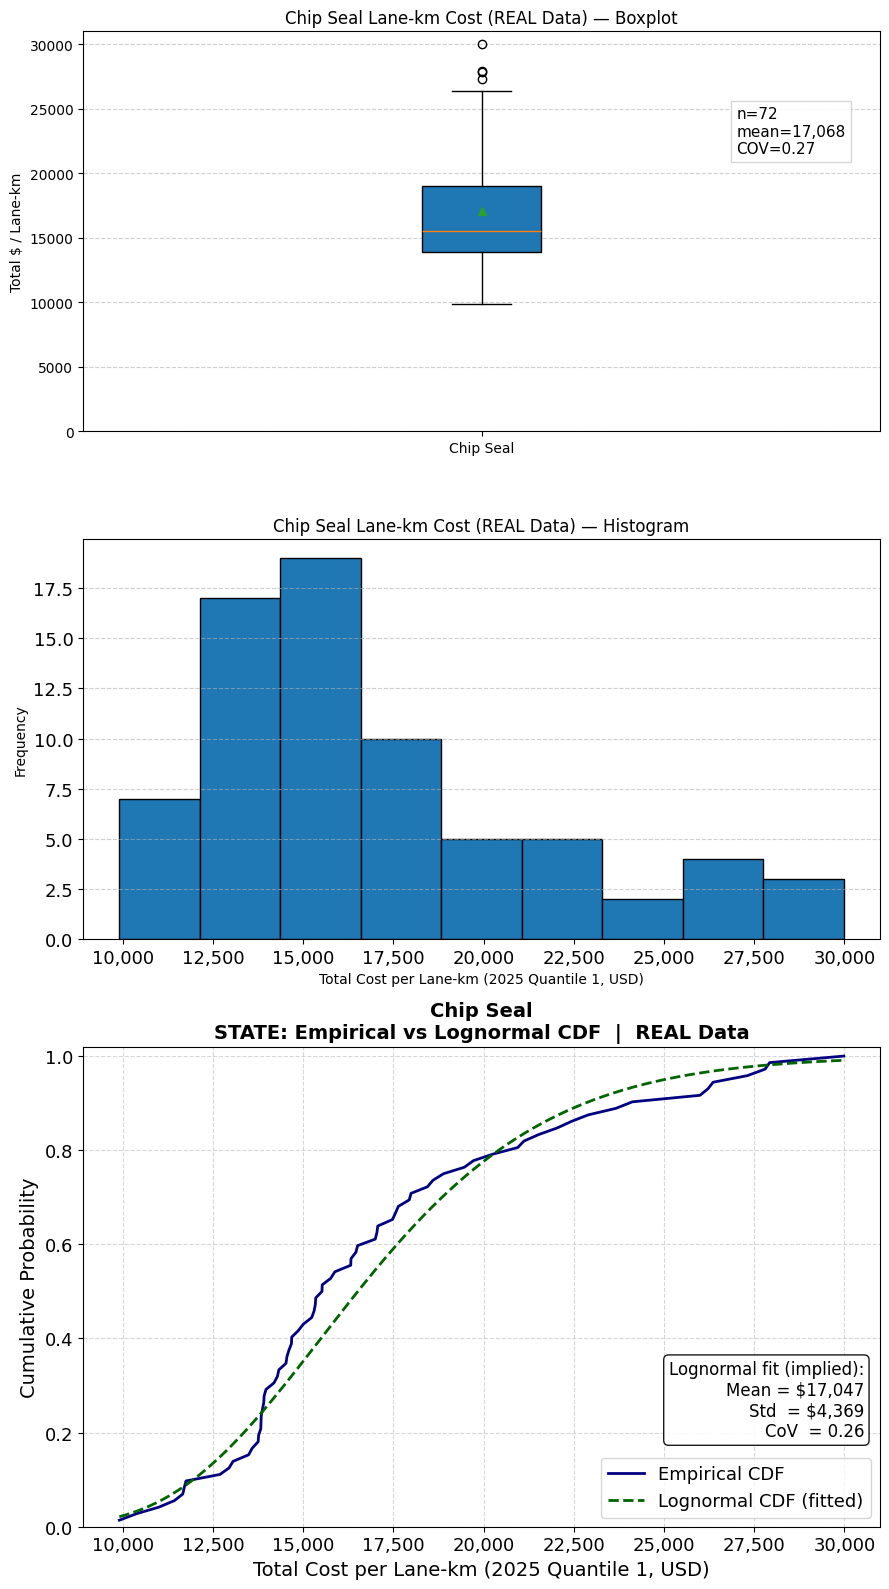

In [25]:
# ---------------------------------------------------------------
# Chip Seal Lane-Mile Cost (REAL Data):
#   - Boxplot (with n/mean/COV annotation INSIDE axes, right of box)
#   - Histogram
#   - Empirical CDF vs fitted Lognormal CDF (clean legend + clean annotation)
#
# Pipeline:
# 1) Remove outlier JobIDs
# 2) Identify chip seal jobs: exactly 1 cover + exactly 1 selected bituminous
# 3) Apply selection rules for bituminous pay items
# 4) Compute lane-mile cost (cover + bituminous)
# 5) Drop extreme computed lane-mile costs > MAX_LANE_MILE_COST
# 6) Plot
# ---------------------------------------------------------------
#
# Notes:
# - Cover conversions:
#     4040162 is priced per C.Y  -> multiply by cover_cy_per_lane_mile
#     4040159 is priced per S.Y  -> multiply by AREA_SQ_YD
# - Bituminous conversion assumes unit price is $/TON and uses gal/ton conversion.
# ---------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# =========================
# Configuration
# =========================
COVER_PAYITEMS = {"4040162", "4040159"}

CRS_PAYITEMS = {"4040073", "4040074"}  # emulsified asphalt
PG_BINDER_PAYITEMS = {"4040286", "4040288", "4040230"}  # PG binders
BITUMINOUS_PAYITEMS = CRS_PAYITEMS | PG_BINDER_PAYITEMS

OUTLIER_JOBIDS = {"2001152", "2017075", "2020060", "2022098"}
FORCED_PG_BY_JOBID = {"2024029": "4040286"}  # if job has >=2 PG binders -> force this one

# Lane-mile constants
AREA_SQ_YD = 7040
BINDER_APP_RATE = 0.45
COVER_APP_RATE = 0.01
GAL_PER_TON = 240

# Post-computation filter
MAX_LANE_MILE_COST = 50_000

# Plot labels
TREATMENT_NAME = "Chip Seal"
JURIS_LABEL = "STATE"


# =========================
# Helper functions
# =========================
def ensure_types(d: pd.DataFrame) -> pd.DataFrame:
    """Ensure key columns have consistent dtypes and numeric unit price."""
    out = d.copy()
    out["JobID"] = out["JobID"].astype(str)
    out["PayItemID"] = out["PayItemID"].astype(str)
    out["UnitPrice_Real_2025Q1"] = pd.to_numeric(out["UnitPrice_Real_2025Q1"], errors="coerce")
    return out


def pick_bituminous_for_job(jobid: str, cover_ids: set, bitum_ids: set) -> set:
    """
    Apply selection rules and return the chosen set of bituminous IDs.
    Rules:
      R3) Job-specific override: if job has >=2 PG binders and jobid in FORCED_PG_BY_JOBID -> keep forced PG.
      R1) If cover includes 4040162 AND job has CRS and PG -> keep CRS only.
      R2) If cover includes 4040159 AND job has >=2 PG binders and includes 4040288 -> keep only 4040288.
    """
    chosen = set(bitum_ids)

    # R3: force PG binder for specific job (only if multiple PG binders exist)
    if jobid in FORCED_PG_BY_JOBID:
        pg_in_job = chosen & PG_BINDER_PAYITEMS
        if len(pg_in_job) >= 2:
            chosen = (chosen - PG_BINDER_PAYITEMS) | {FORCED_PG_BY_JOBID[jobid]}

    # R1: if cover=4040162 and both CRS & PG exist -> keep CRS only
    if "4040162" in cover_ids:
        has_crs = len(chosen & CRS_PAYITEMS) > 0
        has_pg = len(chosen & PG_BINDER_PAYITEMS) > 0
        if has_crs and has_pg:
            chosen = chosen & CRS_PAYITEMS

    # R2: if cover=4040159 and multiple PG and includes 4040288 -> keep only 4040288
    if "4040159" in cover_ids:
        pg_in_job = chosen & PG_BINDER_PAYITEMS
        if len(pg_in_job) >= 2 and "4040288" in pg_in_job:
            chosen = (chosen - PG_BINDER_PAYITEMS) | {"4040288"}

    return chosen


def compute_lane_mile_cost(
    df_job: pd.DataFrame,
    cover_id: str,
    bitum_id: str,
    cover_cy_per_lane_mile: float,
    binder_tons_per_lane_mile: float,
    area_sq_yd: float
) -> float:
    """Compute lane-mile cost for one job. Returns np.nan if missing prices or unsupported cover."""
    cover_price = df_job.loc[df_job["PayItemID"] == cover_id, "UnitPrice_Real_2025Q1"].median()
    bitum_price = df_job.loc[df_job["PayItemID"] == bitum_id, "UnitPrice_Real_2025Q1"].median()

    if np.isnan(cover_price) or np.isnan(bitum_price):
        return np.nan

    # Cover conversion depends on pay item unit basis
    if cover_id == "4040162":          # $/C.Y
        cover_cost = cover_price * cover_cy_per_lane_mile
    elif cover_id == "4040159":        # $/S.Y
        cover_cost = cover_price * area_sq_yd
    else:
        return np.nan

    # Bituminous conversion (assume $/TON)
    binder_cost = bitum_price * binder_tons_per_lane_mile

    return cover_cost + binder_cost


def summarize_stats(x: np.ndarray) -> dict:
    """Return n, mean, std, cov."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    mean = x.mean() if n > 0 else np.nan
    std = x.std(ddof=1) if n > 1 else np.nan
    cov = (std / mean) if (n > 1 and mean != 0 and not np.isnan(std)) else np.nan
    return {"n": n, "mean": mean, "std": std, "cov": cov}


def format_money(x: float) -> str:
    return f"${x:,.0f}"


# =========================
# Main: compute REAL lane-mile costs
# =========================
df2 = ensure_types(df)

# Remove outlier JobIDs so they never appear anywhere
df2 = df2[~df2["JobID"].isin(OUTLIER_JOBIDS)].copy()

# Lane-mile conversion factors
binder_tons_per_lane_mile = (AREA_SQ_YD * BINDER_APP_RATE) / GAL_PER_TON
cover_cy_per_lane_mile = AREA_SQ_YD * COVER_APP_RATE

# PayItem sets per job
job_payitems = df2.groupby("JobID")["PayItemID"].apply(set)

lane_mile_costs = []

for jobid, payitems in job_payitems.items():
    cover_ids = payitems & COVER_PAYITEMS
    bitum_ids = payitems & BITUMINOUS_PAYITEMS

    if not cover_ids or not bitum_ids:
        continue

    chosen_bitum = pick_bituminous_for_job(jobid, cover_ids, bitum_ids)

    # For costing, enforce exactly 1 cover and 1 chosen bituminous
    if len(cover_ids) != 1 or len(chosen_bitum) != 1:
        continue

    cover_id = next(iter(cover_ids))
    bitum_id = next(iter(chosen_bitum))

    df_job = df2[df2["JobID"] == jobid]
    cost = compute_lane_mile_cost(
        df_job=df_job,
        cover_id=cover_id,
        bitum_id=bitum_id,
        cover_cy_per_lane_mile=cover_cy_per_lane_mile,
        binder_tons_per_lane_mile=binder_tons_per_lane_mile,
        area_sq_yd=AREA_SQ_YD
    )

    if np.isnan(cost):
        continue

    lane_mile_costs.append(cost)

lane_mile_costs = np.asarray(lane_mile_costs, dtype=float)
lane_mile_costs = lane_mile_costs[np.isfinite(lane_mile_costs)]
lane_mile_costs = lane_mile_costs[(lane_mile_costs > 0) & (lane_mile_costs <= MAX_LANE_MILE_COST)]
lane_mile_costs = lane_mile_costs * MILE_TO_KM  # convert $/lane-mile -> $/lane-km

stats = summarize_stats(lane_mile_costs)
print(f"{TREATMENT_NAME} lane-km cost (REAL data): n={stats['n']}, mean={stats['mean']:.0f}, COV={stats['cov']:.2f}"
      if stats["n"] > 1 else f"{TREATMENT_NAME} lane-km cost (REAL data): n={stats['n']} (insufficient for COV)")

# =========================
# Plot: Boxplot + Histogram + CDF vs Lognormal
# =========================
fig, axs = plt.subplots(3, 1, figsize=(9, 16), gridspec_kw={"height_ratios": [1, 1, 1.2]})
ax_box, ax_hist, ax_cdf = axs

# -------------------------
# (1) Boxplot
# -------------------------
ax_box.boxplot([lane_mile_costs], patch_artist=True, showmeans=True, labels=[TREATMENT_NAME])
ax_box.set_title(f"{TREATMENT_NAME} Lane-km Cost (REAL Data) — Boxplot")
ax_box.set_ylabel("Total $ / Lane-km")
ax_box.grid(axis="y", linestyle="--", alpha=0.6)

# Start y-axis at 0
ax_box.set_ylim(bottom=0, top=ax_box.get_ylim()[1])

# Annotation INSIDE axes, to the right of box
mean_int = int(round(stats["mean"])) if stats["n"] > 0 and np.isfinite(stats["mean"]) else 0
cov_str = f"{stats['cov']:.2f}" if stats["n"] > 1 and np.isfinite(stats["cov"]) else "N/A"
stat_str = f"n={stats['n']}\nmean={mean_int:,}\nCOV={cov_str}"

# Place using axes-fraction coordinates (guaranteed inside the axes)
ax_box.text(
    0.82, 0.75, stat_str,
    transform=ax_box.transAxes,
    ha="left", va="center", fontsize=11,
    bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.9)
)

# -------------------------
# (2) Histogram
# -------------------------
from matplotlib.ticker import FuncFormatter

# Plot histogram and format x-axis with comma
n_hist, bins_hist, patches_hist = ax_hist.hist(lane_mile_costs, bins="auto", edgecolor="black")
ax_hist.set_title(f"{TREATMENT_NAME} Lane-km Cost (REAL Data) — Histogram")
ax_hist.set_xlabel("Total Cost per Lane-km (2025 Quantile 1, USD)")
ax_hist.set_ylabel("Frequency")
ax_hist.grid(axis="y", linestyle="--", alpha=0.6)

# Format histogram x-axis ticks: use thousands separator
ax_hist.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}" if x >= 1000 or x <= -1000 else str(int(x))))

# Also increase font size of histogram x-tick and y-tick labels for readability and consistency
for label in ax_hist.get_xticklabels():
    label.set_fontsize(13)
for label in ax_hist.get_yticklabels():
    label.set_fontsize(13)

# -------------------------
# (3) CDF: Empirical vs Lognormal (fit on REAL data)
# -------------------------
sorted_vals = np.sort(lane_mile_costs)
n = len(sorted_vals)
emp_cdf = np.arange(1, n + 1) / n

# Fit lognormal (force loc=0)
shape, loc, scale = lognorm.fit(lane_mile_costs, floc=0)

x_fit = np.linspace(sorted_vals.min(), sorted_vals.max(), 600)
cdf_fit = lognorm.cdf(x_fit, shape, loc=loc, scale=scale)

# Implied moments of fitted lognormal
mean_ln = lognorm.mean(shape, loc=loc, scale=scale)
std_ln = lognorm.std(shape, loc=loc, scale=scale)
cov_ln = std_ln / mean_ln if mean_ln != 0 else np.nan

# Plot (clean legend)
ax_cdf.plot(sorted_vals, emp_cdf, color="navy", linewidth=2, label="Empirical CDF")
ax_cdf.plot(x_fit, cdf_fit, linestyle="--", color="darkgreen", linewidth=2, label="Lognormal CDF (fitted)")

ax_cdf.set_title(
    f"{TREATMENT_NAME}\n{JURIS_LABEL}: Empirical vs Lognormal CDF  |  REAL Data",
    fontweight="bold", fontsize=14
)
ax_cdf.set_xlabel("Total Cost per Lane-km (2025 Quantile 1, USD)", fontsize=14)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=14)
ax_cdf.set_ylim(0, 1.02)
ax_cdf.grid(True, linestyle="--", alpha=0.5)

# Format x-axis ticks: use thousands separator and increase font size
ax_cdf.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
for label in ax_cdf.get_xticklabels():
    label.set_fontsize(13)

for label in ax_cdf.get_yticklabels():
    label.set_fontsize(13)

# Put legend so it never overlaps the annotation box
ax_cdf.legend(loc="lower right", frameon=True, fontsize=13)

# Annotation box (separate from legend; avoids overlap)
textstr = (
    "Lognormal fit (implied):\n"
    f"Mean = {format_money(mean_ln)}\n"
    f"Std  = {format_money(std_ln)}\n"
    f"CoV  = {cov_ln:.2f}"
)
ax_cdf.text(
    0.98, 0.18, textstr,              # moved up so it doesn't collide with legend
    transform=ax_cdf.transAxes,
    fontsize=12,
    va="bottom",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()


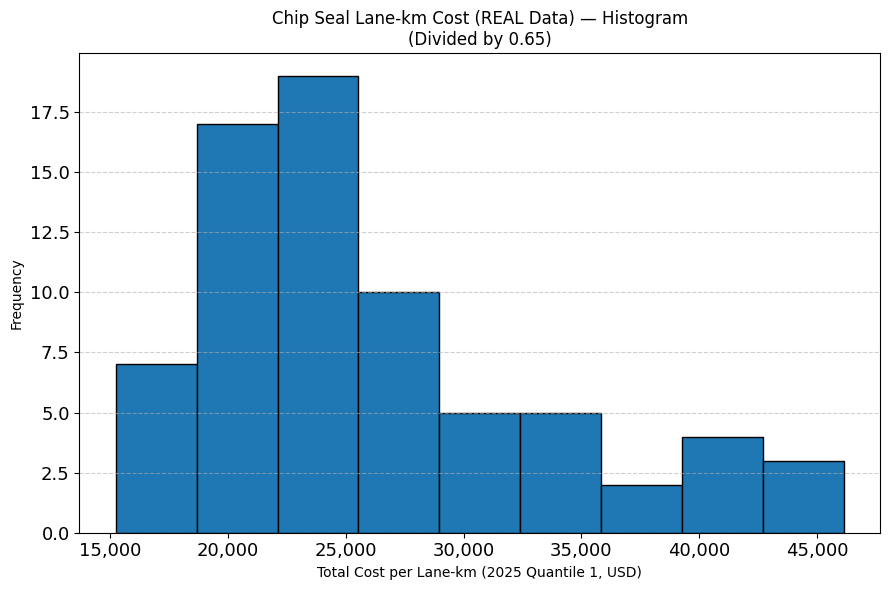

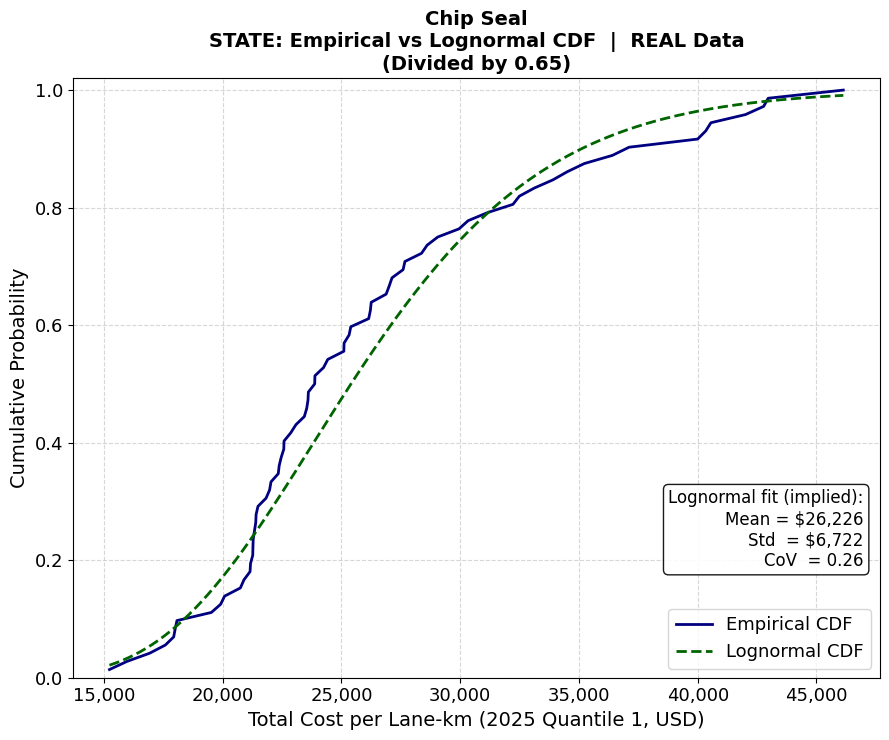

In [26]:
# ---------------------------------------------------------------
# Chip Seal Lane-Mile Cost (REAL Data):
#   - Histogram (all values divided by 0.65)
#   - Empirical CDF vs fitted Lognormal CDF (all values divided by 0.65)
# ---------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from matplotlib.ticker import FuncFormatter

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# =========================
# Configuration
# =========================
COVER_PAYITEMS = {"4040162", "4040159"}
CRS_PAYITEMS = {"4040073", "4040074"}  # emulsified asphalt
PG_BINDER_PAYITEMS = {"4040286", "4040288", "4040230"}  # PG binders
BITUMINOUS_PAYITEMS = CRS_PAYITEMS | PG_BINDER_PAYITEMS

OUTLIER_JOBIDS = {"2001152", "2017075", "2020060", "2022098"}
FORCED_PG_BY_JOBID = {"2024029": "4040286"}  # if job has >=2 PG binders -> force this one

AREA_SQ_YD = 7040
BINDER_APP_RATE = 0.45
COVER_APP_RATE = 0.01
GAL_PER_TON = 240
MAX_LANE_MILE_COST = 50_000

TREATMENT_NAME = "Chip Seal"
JURIS_LABEL = "STATE"

def ensure_types(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    out["JobID"] = out["JobID"].astype(str)
    out["PayItemID"] = out["PayItemID"].astype(str)
    out["UnitPrice_Real_2025Q1"] = pd.to_numeric(out["UnitPrice_Real_2025Q1"], errors="coerce")
    return out

def pick_bituminous_for_job(jobid: str, cover_ids: set, bitum_ids: set) -> set:
    chosen = set(bitum_ids)
    if jobid in FORCED_PG_BY_JOBID:
        pg_in_job = chosen & PG_BINDER_PAYITEMS
        if len(pg_in_job) >= 2:
            chosen = (chosen - PG_BINDER_PAYITEMS) | {FORCED_PG_BY_JOBID[jobid]}
    if "4040162" in cover_ids:
        has_crs = len(chosen & CRS_PAYITEMS) > 0
        has_pg = len(chosen & PG_BINDER_PAYITEMS) > 0
        if has_crs and has_pg:
            chosen = chosen & CRS_PAYITEMS
    if "4040159" in cover_ids:
        pg_in_job = chosen & PG_BINDER_PAYITEMS
        if len(pg_in_job) >= 2 and "4040288" in pg_in_job:
            chosen = (chosen - PG_BINDER_PAYITEMS) | {"4040288"}
    return chosen

def compute_lane_mile_cost(
    df_job: pd.DataFrame,
    cover_id: str,
    bitum_id: str,
    cover_cy_per_lane_mile: float,
    binder_tons_per_lane_mile: float,
    area_sq_yd: float
) -> float:
    cover_price = df_job.loc[df_job["PayItemID"] == cover_id, "UnitPrice_Real_2025Q1"].median()
    bitum_price = df_job.loc[df_job["PayItemID"] == bitum_id, "UnitPrice_Real_2025Q1"].median()
    if np.isnan(cover_price) or np.isnan(bitum_price):
        return np.nan
    if cover_id == "4040162":          # $/C.Y
        cover_cost = cover_price * cover_cy_per_lane_mile
    elif cover_id == "4040159":        # $/S.Y
        cover_cost = cover_price * area_sq_yd
    else:
        return np.nan
    binder_cost = bitum_price * binder_tons_per_lane_mile
    return cover_cost + binder_cost

def summarize_stats(x: np.ndarray) -> dict:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    mean = x.mean() if n > 0 else np.nan
    std = x.std(ddof=1) if n > 1 else np.nan
    cov = (std / mean) if (n > 1 and mean != 0 and not np.isnan(std)) else np.nan
    return {"n": n, "mean": mean, "std": std, "cov": cov}

def format_money(x: float) -> str:
    return f"${x:,.0f}"

# =========================
# Main (costs calculation)
# =========================
df2 = ensure_types(df)
df2 = df2[~df2["JobID"].isin(OUTLIER_JOBIDS)].copy()
binder_tons_per_lane_mile = (AREA_SQ_YD * BINDER_APP_RATE) / GAL_PER_TON
cover_cy_per_lane_mile = AREA_SQ_YD * COVER_APP_RATE
job_payitems = df2.groupby("JobID")["PayItemID"].apply(set)
lane_mile_costs = []

for jobid, payitems in job_payitems.items():
    cover_ids = payitems & COVER_PAYITEMS
    bitum_ids = payitems & BITUMINOUS_PAYITEMS
    if not cover_ids or not bitum_ids:
        continue
    chosen_bitum = pick_bituminous_for_job(jobid, cover_ids, bitum_ids)
    if len(cover_ids) != 1 or len(chosen_bitum) != 1:
        continue
    cover_id = next(iter(cover_ids))
    bitum_id = next(iter(chosen_bitum))
    df_job = df2[df2["JobID"] == jobid]
    cost = compute_lane_mile_cost(
        df_job=df_job,
        cover_id=cover_id,
        bitum_id=bitum_id,
        cover_cy_per_lane_mile=cover_cy_per_lane_mile,
        binder_tons_per_lane_mile=binder_tons_per_lane_mile,
        area_sq_yd=AREA_SQ_YD
    )
    if np.isnan(cost):
        continue
    lane_mile_costs.append(cost)

lane_mile_costs = np.asarray(lane_mile_costs, dtype=float)
lane_mile_costs = lane_mile_costs[np.isfinite(lane_mile_costs)]
lane_mile_costs = lane_mile_costs[(lane_mile_costs > 0) & (lane_mile_costs <= MAX_LANE_MILE_COST)]
lane_mile_costs = lane_mile_costs * MILE_TO_KM  # convert $/lane-mile -> $/lane-km

# Apply divide-by-0.65 transformation to all costs
lane_mile_costs_trans = lane_mile_costs / 0.65

# Histogram
plt.figure(figsize=(9, 6))
n_hist, bins_hist, patches_hist = plt.hist(lane_mile_costs_trans, bins="auto", edgecolor="black")
plt.title(f"{TREATMENT_NAME} Lane-km Cost (REAL Data) — Histogram\n(Divided by 0.65)")
plt.xlabel("Total Cost per Lane-km (2025 Quantile 1, USD)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}" if x >= 1000 or x <= -1000 else str(int(x))))
for label in plt.gca().get_xticklabels():
    label.set_fontsize(13)
for label in plt.gca().get_yticklabels():
    label.set_fontsize(13)
plt.tight_layout()
plt.show()

# CDF
sorted_vals = np.sort(lane_mile_costs_trans)
n = len(sorted_vals)
emp_cdf = np.arange(1, n + 1) / n

# Fit lognormal to scaled values (force loc=0)
shape, loc, scale = lognorm.fit(lane_mile_costs_trans, floc=0)
x_fit = np.linspace(sorted_vals.min(), sorted_vals.max(), 600)
cdf_fit = lognorm.cdf(x_fit, shape, loc=loc, scale=scale)
mean_ln = lognorm.mean(shape, loc=loc, scale=scale)
std_ln = lognorm.std(shape, loc=loc, scale=scale)
cov_ln = std_ln / mean_ln if mean_ln != 0 else np.nan

plt.figure(figsize=(9, 7.5))
ax_cdf = plt.gca()
ax_cdf.plot(sorted_vals, emp_cdf, color="navy", linewidth=2, label="Empirical CDF")
ax_cdf.plot(x_fit, cdf_fit, linestyle="--", color="darkgreen", linewidth=2, label="Lognormal CDF")

ax_cdf.set_title(
    f"{TREATMENT_NAME}\n{JURIS_LABEL}: Empirical vs Lognormal CDF  |  REAL Data\n(Divided by 0.65)",
    fontweight="bold", fontsize=14
)
ax_cdf.set_xlabel("Total Cost per Lane-km (2025 Quantile 1, USD)", fontsize=14)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=14)
ax_cdf.set_ylim(0, 1.02)
ax_cdf.grid(True, linestyle="--", alpha=0.5)
ax_cdf.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
for label in ax_cdf.get_xticklabels():
    label.set_fontsize(13)
for label in ax_cdf.get_yticklabels():
    label.set_fontsize(13)
ax_cdf.legend(loc="lower right", frameon=True, fontsize=13)
textstr = (
    "Lognormal fit (implied):\n"
    f"Mean = {format_money(mean_ln)}\n"
    f"Std  = {format_money(std_ln)}\n"
    f"CoV  = {cov_ln:.2f}"
)
ax_cdf.text(
    0.98, 0.18, textstr,
    transform=ax_cdf.transAxes,
    fontsize=12,
    va="bottom",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)
plt.tight_layout()
plt.show()


# Microsurfacing

Microsurfacing candidate jobs (exactly 1 AGG + 1 EMUL after merge): 41
Microsurfacing lane-km cost: n=41, mean=21059, COV=0.27


C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\4070478688.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([lane_mile_costs], patch_artist=True, showmeans=True, labels=["Microsurfacing"])


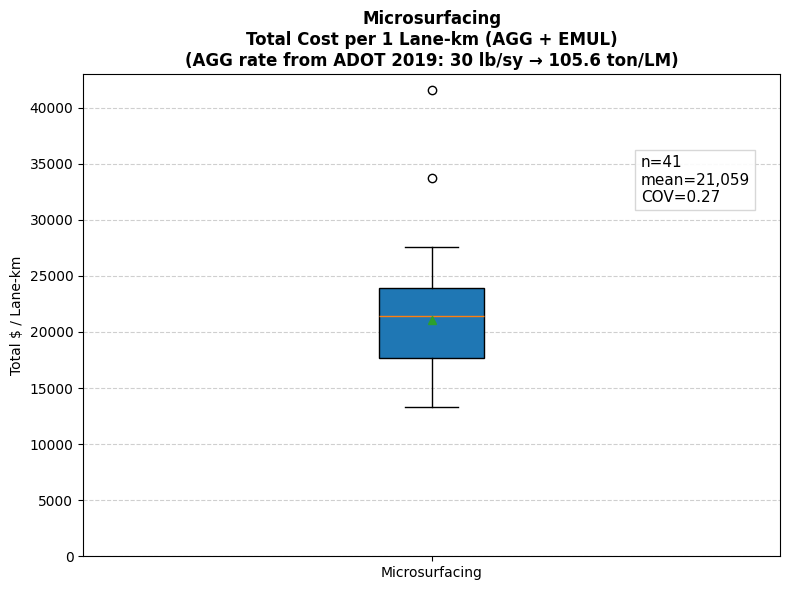

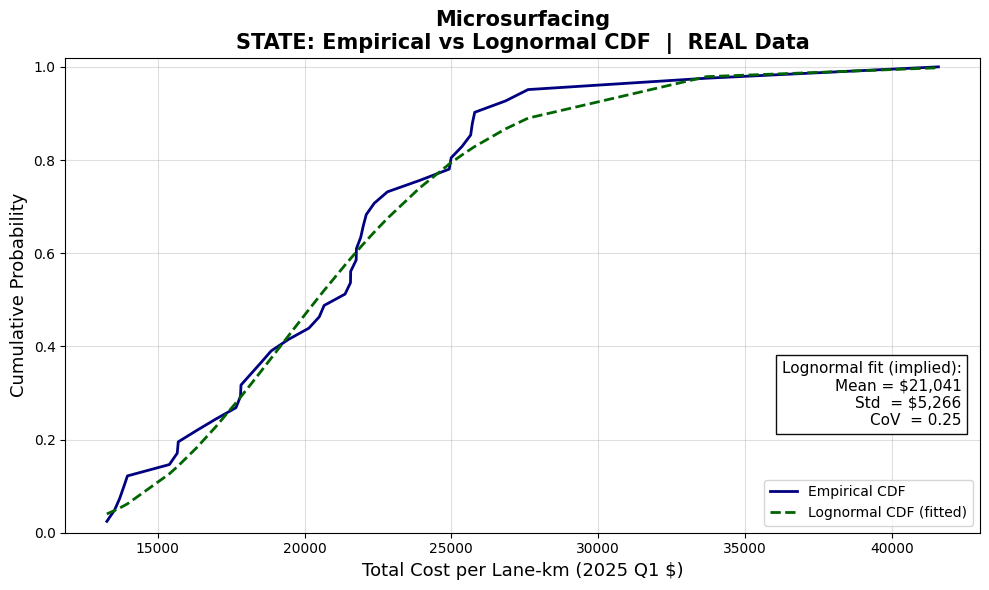

In [27]:
# ---------------------------------------------------------------
# Microsurfacing: Lane-Mile Cost (ONE boxplot, clean + reviewer-friendly)
#
# What this script does
# 1) Keeps ONLY microsurfacing material pay items (AGG + EMUL).
# 2) Aggregates quantities per JobID+PayItemID (Quantity SUM, UnitPrice MEDIAN).
# 3) Applies AGG merge rule:
#      If a job has BOTH 4040171 and 4040172:
#        - keep ONLY 4040172
#        - Qty(4040172) = Qty(4040171) + Qty(4040172)
#        - drop 4040171
# 4) Selects microsurfacing candidate jobs ONLY if:
#      - exactly ONE AGG code remains, AND
#      - exactly ONE EMUL code remains
# 5) Uses ADOT 2019 Microsurfacing Calculator rate for AGG:
#      - 15 lb/sy scratch + 15 lb/sy surface = 30 lb/sy total
#      - 30 lb/sy = 0.015 ton/sy
#      - Lane-mile area (12 ft lane) = 7040 sy
#      => AGG_TON_PER_LM = 7040 * 0.015 = 105.6 tons per lane-mile
# 6) Uses each job’s observed ratio:
#      r = AggQty / (AggQty + EmulQty)
#    to compute TOTAL MIX tons per lane-mile consistent with the AGG rate:
#      TotalMix_Ton_LM = Agg_Ton_LM / r
#      Emul_Ton_LM     = TotalMix_Ton_LM - Agg_Ton_LM
# 7) Computes lane-mile cost using unit prices ($/ton):
#      Cost_LM = AggPrice * Agg_Ton_LM + EmulPrice * Emul_Ton_LM
# 8) Plots ONE boxplot with annotation (n, mean, COV) inside the axes.
#
# Required df columns:
#   JobID, PayItemID, Quantity, UnitPrice_Real_2025Q1
# ---------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# =========================
# Pay item definitions
# =========================
AGG_CODES = {4040170, 4040171, 4040172}
EMUL_CODES = {4040077, 4040076}

# Merge rule: 4040171 + 4040172 -> 4040172
MERGE_FROM = 4040171
MERGE_TO   = 4040172

# =========================
# Lane-mile constants (ADOT 2019 calculator-based)
# =========================
AREA_SQ_YD = 7040

# ADOT calculator: 15 lb/sy scratch + 15 lb/sy surface = 30 lb/sy total aggregate
AGG_LB_PER_SY_TOTAL = 30.0
AGG_TON_PER_SY_TOTAL = AGG_LB_PER_SY_TOTAL / 2000.0  # 0.015 ton/sy
AGG_TON_PER_LM = AREA_SQ_YD * AGG_TON_PER_SY_TOTAL   # 105.6 tons per lane-mile

# =========================
# Helpers
# =========================
def ensure_types(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    out["JobID"] = out["JobID"].astype(str)
    out["PayItemID"] = pd.to_numeric(out["PayItemID"], errors="coerce")
    out["Quantity"] = pd.to_numeric(out["Quantity"], errors="coerce")
    out["UnitPrice_Real_2025Q1"] = pd.to_numeric(out["UnitPrice_Real_2025Q1"], errors="coerce")
    return out

def summarize_stats(x: np.ndarray) -> dict:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    mean = x.mean() if n > 0 else np.nan
    std = x.std(ddof=1) if n > 1 else np.nan
    cov = (std / mean) if (n > 1 and mean != 0 and np.isfinite(std)) else np.nan
    return {"n": n, "mean": mean, "std": std, "cov": cov}

# =========================
# 1) Clean + keep only AGG/EMUL rows
# =========================
df_ms = ensure_types(df)

sub = df_ms[df_ms["PayItemID"].isin(AGG_CODES | EMUL_CODES)][
    ["JobID", "PayItemID", "Quantity", "UnitPrice_Real_2025Q1"]
].copy()

sub = sub.dropna(subset=["JobID", "PayItemID"])

# Aggregate within each (JobID, PayItemID):
# - Quantity should be SUM
# - Unit price uses MEDIAN (robust)
job_code = (
    sub.groupby(["JobID", "PayItemID"], as_index=False)
       .agg(
           Quantity=("Quantity", lambda s: s.sum(min_count=1)),
           UnitPrice_Real_2025Q1=("UnitPrice_Real_2025Q1", "median")
       )
)

# =========================
# 2) Apply AGG merge rule (171+172 -> 172)
# =========================
q = job_code.pivot(index="JobID", columns="PayItemID", values="Quantity")
p = job_code.pivot(index="JobID", columns="PayItemID", values="UnitPrice_Real_2025Q1")

if (MERGE_FROM in q.columns) and (MERGE_TO in q.columns):
    jobs_both = q.index[q[MERGE_FROM].notna() & q[MERGE_TO].notna()]

    # Quantity: add MERGE_FROM into MERGE_TO, then drop MERGE_FROM
    q.loc[jobs_both, MERGE_TO] = q.loc[jobs_both, MERGE_TO].fillna(0) + q.loc[jobs_both, MERGE_FROM].fillna(0)
    q.loc[jobs_both, MERGE_FROM] = np.nan

    # Unit price: keep MERGE_TO price (no mixing unless you want weighted average)

# Back to long
q_long = (
    q.stack().dropna()
     .reset_index()
     .rename(columns={"level_1": "PayItemID", 0: "Quantity"})
)
p_long = (
    p.stack().dropna()
     .reset_index()
     .rename(columns={"level_1": "PayItemID", 0: "UnitPrice_Real_2025Q1"})
)
job_code_adj = q_long.merge(p_long, on=["JobID", "PayItemID"], how="left")
job_code_adj["PayItemID"] = pd.to_numeric(job_code_adj["PayItemID"], errors="coerce")

# =========================
# 3) Select microsurfacing jobs: EXACTLY 1 AGG and 1 EMUL remain
# =========================
valid_jobs = []
for jobid, g in job_code_adj.groupby("JobID"):
    agg_present = g[g["PayItemID"].isin(AGG_CODES)]
    emul_present = g[g["PayItemID"].isin(EMUL_CODES)]
    if len(agg_present) == 1 and len(emul_present) == 1:
        valid_jobs.append(jobid)

job_code_valid = job_code_adj[job_code_adj["JobID"].isin(valid_jobs)].copy()

print(f"Microsurfacing candidate jobs (exactly 1 AGG + 1 EMUL after merge): {len(valid_jobs)}")

# =========================
# 4) Compute lane-mile cost per job using:
#    - Job ratio r = AggQty/(AggQty+EmulQty)
#    - Fixed AGG_TON_PER_LM from ADOT rate
#    - TotalMix_Ton_LM = Agg_Ton_LM / r
#    - Emul_Ton_LM = TotalMix_Ton_LM - Agg_Ton_LM
# =========================
rows = []
for jobid, g in job_code_valid.groupby("JobID"):
    agg_row = g[g["PayItemID"].isin(AGG_CODES)].iloc[0]
    emul_row = g[g["PayItemID"].isin(EMUL_CODES)].iloc[0]

    agg_qty_proj = agg_row["Quantity"]
    emul_qty_proj = emul_row["Quantity"]
    agg_price = agg_row["UnitPrice_Real_2025Q1"]   # $/ton
    emul_price = emul_row["UnitPrice_Real_2025Q1"] # $/ton

    # Need valid values
    if not (np.isfinite(agg_qty_proj) and np.isfinite(emul_qty_proj) and np.isfinite(agg_price) and np.isfinite(emul_price)):
        continue

    denom = agg_qty_proj + emul_qty_proj
    if denom <= 0:
        continue

    r = agg_qty_proj / denom  # AGG/(AGG+EMUL)
    if r <= 0 or r >= 1:
        continue

    # Lane-mile ton split consistent with fixed aggregate application rate
    agg_ton_lm = AGG_TON_PER_LM
    total_mix_ton_lm = agg_ton_lm / r
    emul_ton_lm = total_mix_ton_lm - agg_ton_lm

    # Lane-mile cost
    cost_lm = agg_price * agg_ton_lm + emul_price * emul_ton_lm

    rows.append({
        "JobID": jobid,
        "AggCode": int(agg_row["PayItemID"]),
        "EmulCode": int(emul_row["PayItemID"]),
        "AggQty_Project": float(agg_qty_proj),
        "EmulQty_Project": float(emul_qty_proj),
        "Ratio_AGG_over_AGGplusEMUL": float(r),
        "AggTon_LM": float(agg_ton_lm),
        "EmulTon_LM": float(emul_ton_lm),
        "AggUnitPrice": float(agg_price),
        "EmulUnitPrice": float(emul_price),
        "LaneMileCost": float(cost_lm)
    })

ms_cost_df = pd.DataFrame(rows)

# Optional: review
# display(ms_cost_df.sort_values("LaneMileCost").reset_index(drop=True))

lane_mile_costs = ms_cost_df["LaneMileCost"].to_numpy(dtype=float)
lane_mile_costs = lane_mile_costs[np.isfinite(lane_mile_costs)]
lane_mile_costs = lane_mile_costs * MILE_TO_KM  # convert $/lane-mile -> $/lane-km

stats = summarize_stats(lane_mile_costs)
print(
    f"Microsurfacing lane-km cost: n={stats['n']}, mean={stats['mean']:.0f}, COV={stats['cov']:.2f}"
    if stats["n"] > 1 else
    f"Microsurfacing lane-km cost: n={stats['n']} (insufficient for COV)"
)

# =========================
# 5) ONE boxplot (consistent style)
# =========================
fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot([lane_mile_costs], patch_artist=True, showmeans=True, labels=["Microsurfacing"])
ax.set_title("Microsurfacing\nTotal Cost per 1 Lane-km (AGG + EMUL)\n(AGG rate from ADOT 2019: 30 lb/sy → 105.6 ton/LM)", fontweight="bold")
ax.set_ylabel("Total $ / Lane-km")
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylim(bottom=0, top=ax.get_ylim()[1])

# Annotation INSIDE axes, right side
mean_int = int(round(stats["mean"])) if stats["n"] > 0 and np.isfinite(stats["mean"]) else 0
cov_str = f"{stats['cov']:.2f}" if stats["n"] > 1 and np.isfinite(stats["cov"]) else "N/A"
stat_str = f"n={stats['n']}\nmean={mean_int:,}\nCOV={cov_str}"

ax.text(
    0.80, 0.78, stat_str,
    transform=ax.transAxes,
    ha="left", va="center", fontsize=11,
    bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.9)
)

plt.tight_layout()
plt.show()

# -----------------------
# Prepare data (REAL data)
# -----------------------
x = np.asarray(lane_mile_costs, dtype=float)
x = x[np.isfinite(x)]
x = np.sort(x)

n = len(x)
if n == 0:
    print("[WARN] No data available for CDF plot.")
else:
    emp_cdf = np.arange(1, n + 1) / n

    # -----------------------
    # Fit lognormal (force loc=0 for stability/consistency)
    # -----------------------
    # If the data ever contains <=0 values, shift slightly positive before lognormal fitting,
    # then report implied mean/std back on original scale.
    offset = 0.0
    fit_data = x.copy()
    if fit_data.min() <= 0:
        offset = -fit_data.min() + 1.0
        fit_data = fit_data + offset

    shape, loc, scale = lognorm.fit(fit_data, floc=0)  # shape=sigma, scale=exp(mu)
    sigma = shape
    mu = np.log(scale)

    # Compute implied mean/std/COV on ORIGINAL scale
    mean_fit = np.exp(mu + 0.5 * sigma**2) - offset
    var_fit = (np.exp(sigma**2) - 1.0) * np.exp(2 * mu + sigma**2)
    std_fit = np.sqrt(var_fit)
    cov_fit = std_fit / mean_fit if mean_fit != 0 else np.nan

    # Fitted CDF evaluated at x (same x grid)
    fit_x = x + offset
    fit_cdf = lognorm.cdf(fit_x, s=sigma, loc=0, scale=np.exp(mu))

    # -----------------------
    # Plot (match Chip Seal style)
    # -----------------------
    plt.figure(figsize=(10, 6))

    # Empirical CDF (solid navy)
    plt.plot(x, emp_cdf, lw=2, color="navy", label="Empirical CDF")

    # Fitted lognormal CDF (dashed green)
    plt.plot(x, fit_cdf, lw=2, linestyle="--", color="darkgreen", label="Lognormal CDF (fitted)")

    plt.title("Microsurfacing\nSTATE: Empirical vs Lognormal CDF  |  REAL Data", fontsize=15, fontweight="bold")
    plt.xlabel("Total Cost per Lane-km (2025 Q1 $)", fontsize=13)
    plt.ylabel("Cumulative Probability", fontsize=13)
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.4)

    # Legend (clean, not nested)
    plt.legend(loc="lower right", frameon=True)

    # Annotation box (separate from legend)
    ann = (
        "Lognormal fit (implied):\n"
        f"Mean = ${mean_fit:,.0f}\n"
        f"Std  = ${std_fit:,.0f}\n"
        f"CoV  = {cov_fit:.2f}"
    )
    ax = plt.gca()
    ax.text(
        0.98, 0.22, ann,
        transform=ax.transAxes,
        ha="right", va="bottom",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.95)
    )

    plt.tight_layout()
    plt.show()

# Crack Seal

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\2610175495.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data], patch_artist=True, showmeans=True, labels=["Crack Seal"])


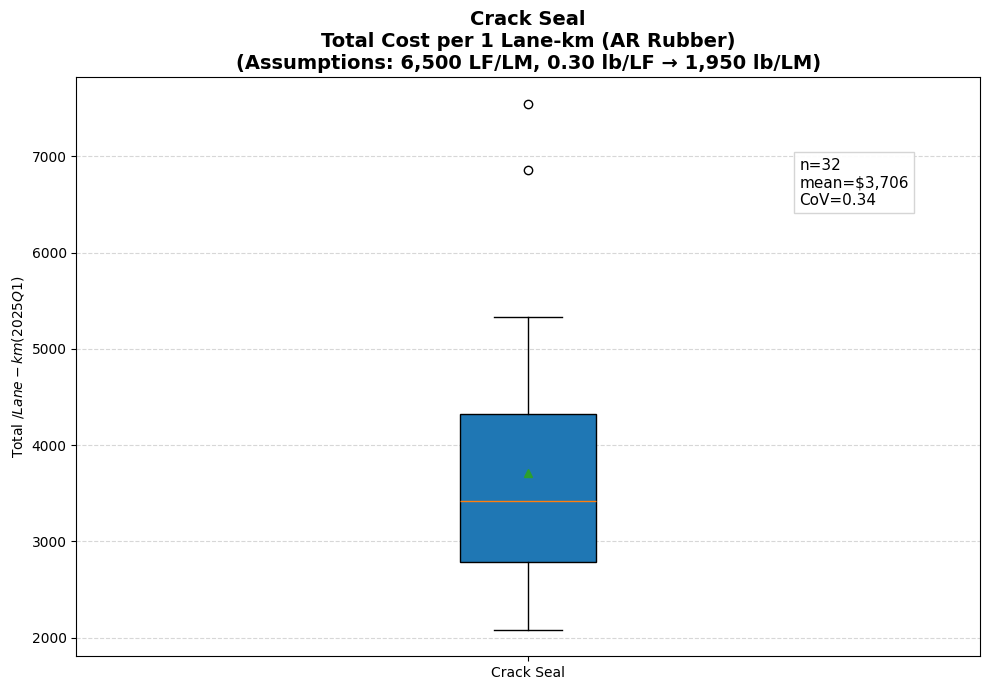

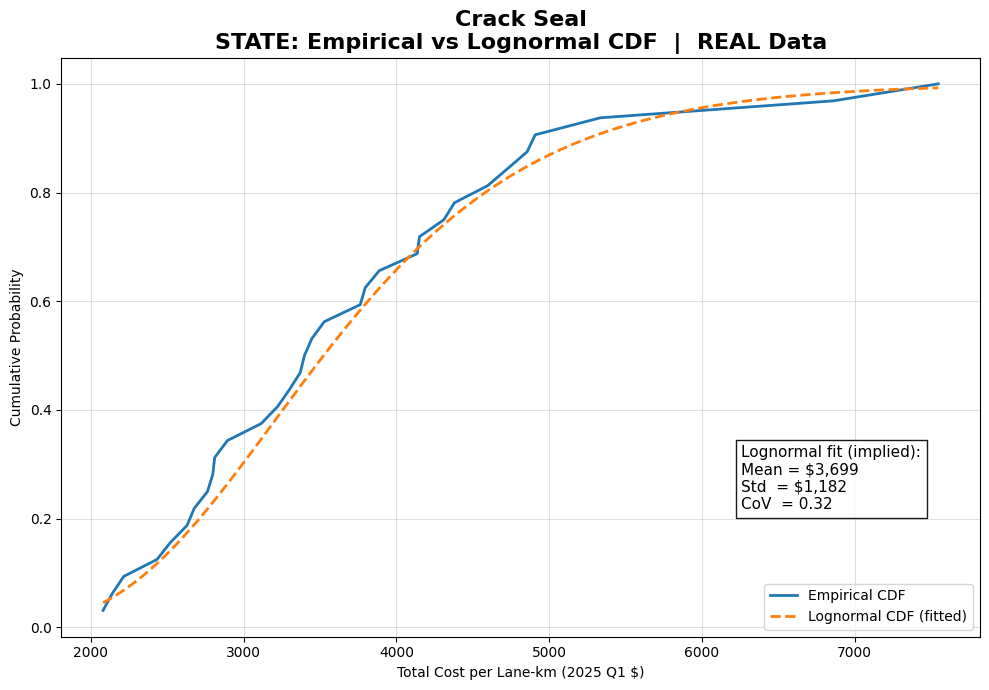

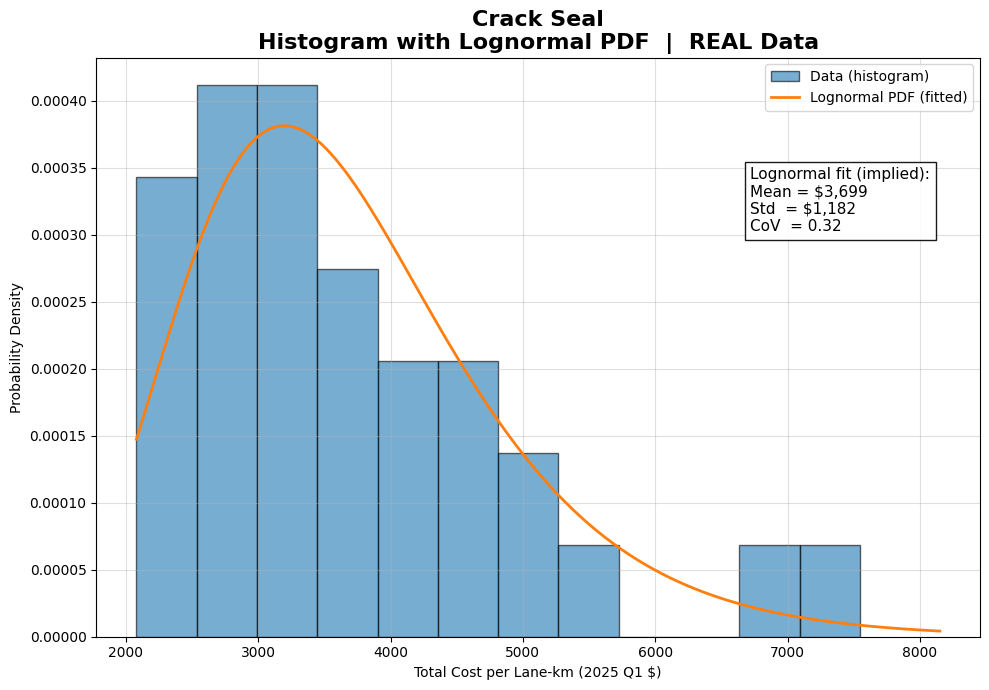

=== Lognormal fit parameters (scipy.stats.lognorm) ===
shape (sigma): 0.311772
loc:           0.000000
scale (exp(mu)):3523.656154


In [28]:
"""
Crack Seal (ADOT) — Lane-mile cost model (Typical scenario)
Pay Item: 9240116 (unit = $/lb)

Goal:
- Convert unit bid prices ($/lb) into total treatment cost ($/lane-mile) using a fixed,
  planning-level "Typical" conversion (lb per lane-mile).
- Visualize the resulting lane-mile cost distribution (boxplot, CDF, histogram).
- Fit a Lognormal distribution for stochastic modeling (loc fixed at 0).

Notes:
- ADOT measures this item by pounds of sealant placed (routing/cleaning included in pay item).
- Lane-mile conversion requires assumptions (crack density + lb/LF usage rate).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# =============================================================================
# 0) USER INPUTS (edit here when you find better references)
# =============================================================================

# Outlier JobIDs removed because unit prices were unusually high (e.g., > $10/lb).
# Keep this list transparent and consistent across analyses.
OUTLIER_JOBIDS = [
    "2005104", "2024059", "2010097", "2007098", "2015129", "2010027",
    "2009024", "2008087", "2008080", "2009172", "2007094"
]

# Target crack seal pay item (ADOT standard representative for crack seal preservation)
PAYITEM_ID = "9240116"
PAYITEM_LABEL = "Crack Seal (AR Rubber)"   # short label for plots

# --- Typical lane-mile conversion assumptions ---
# These are planning assumptions tied to the ADOT decision window you described
# (non-Interstate, AADT < 5000, HPMS cracking ~5–8%).
CRACK_LF_PER_LANE_MILE_TYP = 6500   # LF of cracks per lane-mile
LB_PER_LF_TYP              = 0.30   # lb of sealant per LF of crack
LB_PER_LANE_MILE_TYP       = CRACK_LF_PER_LANE_MILE_TYP * LB_PER_LF_TYP

ASSUMPTION_LINE = (
    f"(Assumptions: {CRACK_LF_PER_LANE_MILE_TYP:,.0f} LF/LM, "
    f"{LB_PER_LF_TYP:.2f} lb/LF → {LB_PER_LANE_MILE_TYP:,.0f} lb/LM)"
)

# Column name for inflation-adjusted prices
PRICE_COL = "UnitPrice_Real_2025Q1"  # $/lb


# =============================================================================
# 1) DATA PREP
# =============================================================================

# Ensure IDs are consistent types so filtering works reliably
df["PayItemID"] = df["PayItemID"].astype(str)
df["JobID"] = df["JobID"].astype(str)

# Filter to (a) the crack seal pay item and (b) exclude outlier JobIDs
df_cs = df[
    (df["PayItemID"] == PAYITEM_ID) &
    (~df["JobID"].isin(OUTLIER_JOBIDS))
].copy()

# Convert $/lb → $/lane-mile using fixed typical lb per lane-mile
df_cs["Cost_per_LaneMile_Real_2025Q1"] = df_cs[PRICE_COL] * LB_PER_LANE_MILE_TYP * MILE_TO_KM

# Extract clean numeric array for analysis
data = df_cs["Cost_per_LaneMile_Real_2025Q1"].dropna().values

if len(data) == 0:
    raise ValueError("No lane-mile cost data found after filtering. Check inputs/filters.")


# =============================================================================
# 2) BASIC STATS (empirical)
# =============================================================================

n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1) if n > 1 else np.nan
cov = (std / mean) if (n > 1 and mean != 0) else np.nan

stats_box_text = (
    f"n={n}\n"
    f"mean=${mean:,.0f}\n"
    f"CoV={cov:.2f}" if n > 1 else f"n={n}\nmean=${mean:,.0f}\nCoV=n/a"
)


# =============================================================================
# 3) BOXPLOT (Microsurfacing-style)
# =============================================================================

plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.boxplot([data], patch_artist=True, showmeans=True, labels=["Crack Seal"])

ax.set_title(
    "Crack Seal\n"
    "Total Cost per 1 Lane-km (AR Rubber)\n"
    + ASSUMPTION_LINE,
    fontsize=14, fontweight="bold"
)
ax.set_ylabel("Total $ / Lane-km (2025 Q1 $)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Place stats box in top-right inside axes
ax.text(
    0.80, 0.78, stats_box_text, transform=ax.transAxes, fontsize=11,
    bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.95)
)

plt.tight_layout()
plt.show()


# =============================================================================
# 4) EMPIRICAL vs LOGNORMAL CDF (Microsurfacing-style)
# =============================================================================

data_sorted = np.sort(data)
ecdf = np.arange(1, n + 1) / n

# Fit lognormal with loc fixed at 0 (common for positive cost distributions)
shape, loc, scale = lognorm.fit(data_sorted, floc=0)

# Smooth x-axis support for fitted curve
xvals = np.linspace(data_sorted.min(), data_sorted.max(), 500)
cdf_lognorm = lognorm.cdf(xvals, shape, loc, scale)

# Moments implied by fitted lognormal (useful for reporting)
mean_fit = lognorm.mean(shape, loc=loc, scale=scale)
std_fit = lognorm.std(shape, loc=loc, scale=scale)
cov_fit = std_fit / mean_fit if mean_fit != 0 else np.nan

fit_box_text = (
    "Lognormal fit (implied):\n"
    f"Mean = ${mean_fit:,.0f}\n"
    f"Std  = ${std_fit:,.0f}\n"
    f"CoV  = {cov_fit:.2f}"
)

plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.plot(data_sorted, ecdf, linewidth=2, label="Empirical CDF")
ax.plot(xvals, cdf_lognorm, linestyle="--", linewidth=2, label="Lognormal CDF (fitted)")

ax.set_title(
    "Crack Seal\nSTATE: Empirical vs Lognormal CDF  |  REAL Data",
    fontsize=16, fontweight="bold"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Cumulative Probability")
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc="lower right")

# Fit annotation box (matches style used in other treatment plots)
ax.text(
    0.74, 0.22, fit_box_text, transform=ax.transAxes, fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)

plt.tight_layout()
plt.show()


# =============================================================================
# 5) HISTOGRAM + LOGNORMAL PDF (optional)
# =============================================================================

plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.hist(
    data, bins=12, density=True,
    edgecolor="black", alpha=0.60,
    label="Data (histogram)"
)

x_pdf = np.linspace(data_sorted.min(), data_sorted.max() * 1.08, 500)
pdf_lognorm = lognorm.pdf(x_pdf, shape, loc, scale)
ax.plot(x_pdf, pdf_lognorm, linewidth=2, label="Lognormal PDF (fitted)")

ax.set_title(
    "Crack Seal\nHistogram with Lognormal PDF  |  REAL Data",
    fontsize=16, fontweight="bold"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Probability Density")
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc="upper right")

ax.text(
    0.74, 0.70, fit_box_text, transform=ax.transAxes, fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)

plt.tight_layout()
plt.show()


# =============================================================================
# 6) (Optional) Print fitted parameters for reproducibility
# =============================================================================
print("=== Lognormal fit parameters (scipy.stats.lognorm) ===")
print(f"shape (sigma): {shape:.6f}")
print(f"loc:           {loc:.6f}")
print(f"scale (exp(mu)):{scale:.6f}")
print("======================================================")


# Fog Coat

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\1331491446.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data], patch_artist=True, showmeans=True, labels=[LABEL_TREAT])


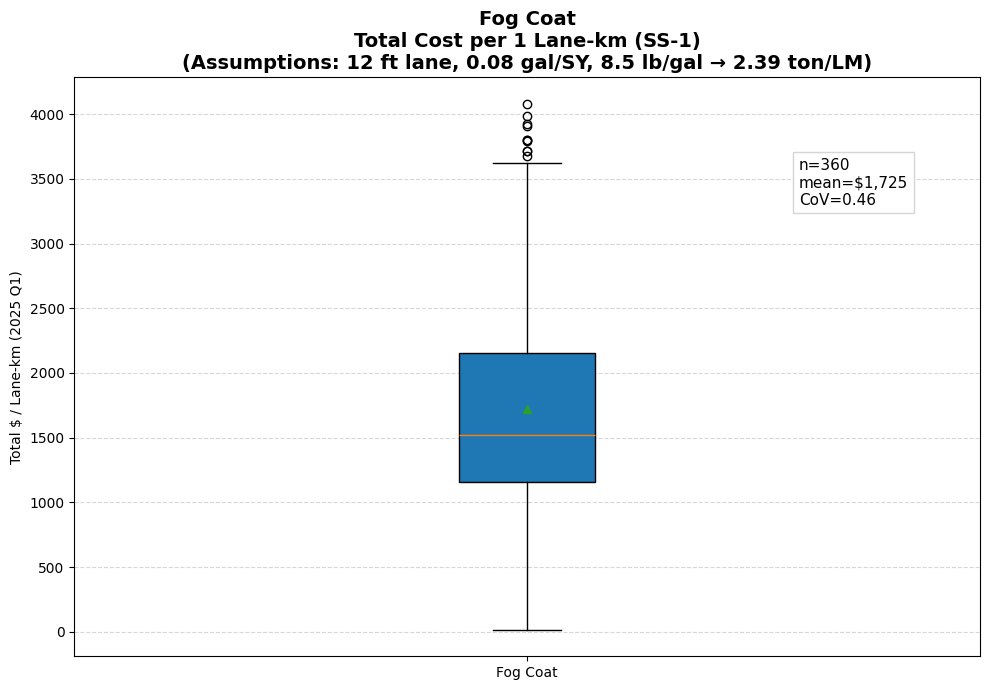

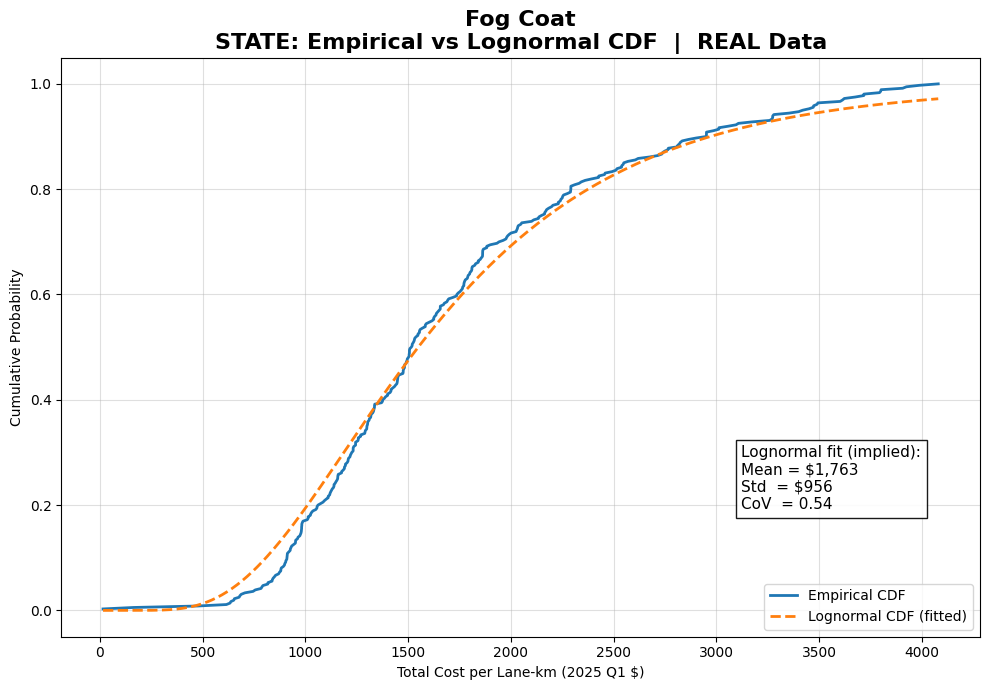

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# =============================================================================
# 0) INPUTS (EDIT THESE LATER IF YOU FIND BETTER INFO)
# =============================================================================

# Pay item
PAYITEM_ID    = "4040125"
LABEL_TREAT   = "Fog Coat"
LABEL_SUBTYPE = "SS-1"  # shows in title line 2

# Column name (inflation-adjusted unit price)
PRICE_COL = "UnitPrice_Real_2025Q1"    # assumed $/ton

# Outlier JobIDs list; defined earlier in the notebook
# OUTLIER_JOBIDS = [...]

# --- Lane-mile assumptions ---
LANE_WIDTH_FT = 12.0
APP_RATE_GAL_PER_SY = 0.08     # spec: 0.08 gal/SY
DENSITY_LB_PER_GAL  = 8.5      # SS-1 typical density (update if you find ADOT/supplier value)

# Constants
MILE_FT = 5280.0
FT2_PER_SY = 9.0
LB_PER_TON = 2000.0

# =============================================================================
# 1) FILTER DATA
# =============================================================================
df["PayItemID"] = df["PayItemID"].astype(str)
df["JobID"]     = df["JobID"].astype(str)

df_fc = df[
    (df["PayItemID"] == PAYITEM_ID) &
    (~df["JobID"].isin(OUTLIER_JOBIDS))
].copy()

unit_price_raw = df_fc[PRICE_COL].dropna().values
if len(unit_price_raw) == 0:
    raise ValueError("No unit price data found after filtering. Check PAYITEM_ID/PRICE_COL/outliers.")

# =============================================================================
# 2) IQR FILTER (use this filtered data for mean/CoV AND plots)
# =============================================================================
q1 = np.percentile(unit_price_raw, 25)
q3 = np.percentile(unit_price_raw, 75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

unit_price = unit_price_raw[(unit_price_raw >= low) & (unit_price_raw <= high)]
if len(unit_price) < 5:  # safety fallback if IQR removes too much
    unit_price = unit_price_raw

# =============================================================================
# 3) CONVERT $/ton -> $/lane-mile
# =============================================================================
# 1 lane-mile area (SY)
area_sy = (MILE_FT * LANE_WIDTH_FT) / FT2_PER_SY

# gallons per lane-mile
gal_per_lm = area_sy * APP_RATE_GAL_PER_SY

# tons per lane-mile
lb_per_lm  = gal_per_lm * DENSITY_LB_PER_GAL
ton_per_lm = lb_per_lm / LB_PER_TON

# cost per lane-mile
data = unit_price * ton_per_lm * MILE_TO_KM  # $/lane-km

# Summarize lane-mile conversion assumptions for display in the plot title
assump_line = (
    f"(Assumptions: {LANE_WIDTH_FT:.0f} ft lane, "
    f"{APP_RATE_GAL_PER_SY:.2f} gal/SY, "
    f"{DENSITY_LB_PER_GAL:.1f} lb/gal → {ton_per_lm:.2f} ton/LM)"
)

# =============================================================================
# 4) STATS (REAL data, IQR-filtered)
# =============================================================================
n = len(data)
mean = np.mean(data) if n > 0 else np.nan
std  = np.std(data, ddof=1) if n > 1 else np.nan
cov  = (std / mean) if (n > 1 and mean != 0 and not np.isnan(mean)) else np.nan

stats_text = (
    f"n={n}\n"
    f"mean=${mean:,.0f}\n"
    f"CoV={cov:.2f}" if n > 1 else f"n={n}\nmean=${mean:,.0f}\nCoV=n/a"
)

# =============================================================================
# 5) PLOT 1 — BOXPLOT (same style as Crack Seal)
# =============================================================================
plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.boxplot([data], patch_artist=True, showmeans=True, labels=[LABEL_TREAT])

ax.set_title(
    f"{LABEL_TREAT}\n"
    f"Total Cost per 1 Lane-km ({LABEL_SUBTYPE})\n"
    + assump_line,
    fontsize=14, fontweight="bold"
)
ax.set_ylabel("Total $ / Lane-km (2025 Q1)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# top-right stats box
ax.text(
    0.80, 0.78, stats_text, transform=ax.transAxes, fontsize=11,
    bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.95)
)

plt.tight_layout()
plt.show()

# =============================================================================
# 6) PLOT 2 — EMPIRICAL vs LOGNORMAL CDF (same style as Crack Seal)
# =============================================================================
data_sorted = np.sort(data)
ecdf = np.arange(1, n + 1) / n

# Fit lognormal (force loc=0)
shape, loc, scale = lognorm.fit(data_sorted, floc=0)

xvals = np.linspace(data_sorted.min(), data_sorted.max(), 500)
cdf_fit = lognorm.cdf(xvals, shape, loc, scale)

# implied moments (for annotation)
mean_fit = lognorm.mean(shape, loc=loc, scale=scale)
std_fit  = lognorm.std(shape,  loc=loc, scale=scale)
cov_fit  = std_fit / mean_fit if mean_fit != 0 else np.nan

fit_box = (
    "Lognormal fit (implied):\n"
    f"Mean = ${mean_fit:,.0f}\n"
    f"Std  = ${std_fit:,.0f}\n"
    f"CoV  = {cov_fit:.2f}"
)

plt.figure(figsize=(10, 7))
ax = plt.gca()

ax.plot(data_sorted, ecdf, linewidth=2, label="Empirical CDF")
ax.plot(xvals, cdf_fit, linestyle="--", linewidth=2, label="Lognormal CDF (fitted)")

ax.set_title(
    f"{LABEL_TREAT}\nSTATE: Empirical vs Lognormal CDF  |  REAL Data",
    fontsize=16, fontweight="bold"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Cumulative Probability")
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc="lower right")

ax.text(
    0.74, 0.22, fit_box, transform=ax.transAxes, fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.9)
)

plt.tight_layout()
plt.show()


# Mill + Cape Seal

In [30]:
# ===============================================================
# Cell 1 — Gather components for:
#   "Mill + Chip Seal + Microsurfacing"  (a.k.a. micro cape seal)
#
# Outputs created:
#   chip_for_boot  : columns [County, ChipSeal_Cost_Per_LaneMile]
#   micro_for_boot : columns [County, Microsurfacing_Cost_Per_LaneMile]
#   mill_state_vals, chip_state_vals, micro_state_vals (numpy arrays)
#
# Assumes you already have:
#   df  with columns: JobID, County, PayItemID, Quantity, UnitPrice_Real_2025Q1
#   mill_for_box with column: Milling_Cost_Per_LaneMile (built in the Milling section above)
# Optional:
#   OUTLIER_JOBIDS (set of JobIDs to drop)
# ===============================================================

import numpy as np
import pandas as pd

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# ---------------------------
# Safety: OUTLIER_JOBIDS
# ---------------------------
if "OUTLIER_JOBIDS" not in globals():
    OUTLIER_JOBIDS = set()

# Ensure key dtypes
df_ = df.copy()
df_["JobID"] = df_["JobID"].astype(str)
df_["County"] = df_["County"].astype(str)
df_["PayItemID"] = df_["PayItemID"].astype(str)
df_["Quantity"] = pd.to_numeric(df_["Quantity"], errors="coerce")
df_["UnitPrice_Real_2025Q1"] = pd.to_numeric(df_["UnitPrice_Real_2025Q1"], errors="coerce")

# Drop outlier jobs (if any)
df_ = df_[~df_["JobID"].isin(set(map(str, OUTLIER_JOBIDS)))].copy()

# ===============================================================
# A) CHIP SEAL — lane-mile cost distribution (STATE-level)
# ===============================================================

# Pay items (same as the Chip Seal section above)
COVER_PAYITEMS = {"4040162", "4040159"}  # cover: CY or SY
CRS_PAYITEMS = {"4040073", "4040074"}    # emulsified asphalt
PG_BINDER_PAYITEMS = {"4040286", "4040288", "4040230"}
BITUMINOUS_PAYITEMS = CRS_PAYITEMS | PG_BINDER_PAYITEMS

# If a job has >=2 PG binders, force the chosen one using the PG_OVERRIDE mapping
FORCED_PG_BY_JOBID = {"2024029": "4040286"}

# Lane-mile constants (same as the Chip Seal section above)
AREA_SQ_YD = 7040
BINDER_APP_RATE = 0.45     # gal/sy
COVER_APP_RATE = 0.01      # cy/sy (for 4040162)
GAL_PER_TON = 240

binder_tons_per_lane_mile = (AREA_SQ_YD * BINDER_APP_RATE) / GAL_PER_TON
cover_cy_per_lane_mile = AREA_SQ_YD * COVER_APP_RATE

MAX_LANE_MILE_COST_CHIP = 50_000

def pick_bituminous_for_job(jobid: str, cover_ids: set, bitum_ids: set) -> set:
    """
    Selection rules (same as the Chip Seal section above):
      - If job has both CRS and PG, prefer CRS (common pattern)
      - If multiple PG and job in FORCED_PG_BY_JOBID, keep forced PG
      - Otherwise keep single bituminous if unambiguous
    """
    jobid = str(jobid)

    # Forced rule (>=2 PG binders)
    pg = bitum_ids & PG_BINDER_PAYITEMS
    if (len(pg) >= 2) and (jobid in FORCED_PG_BY_JOBID):
        forced = FORCED_PG_BY_JOBID[jobid]
        if forced in bitum_ids:
            return {forced}

    crs = bitum_ids & CRS_PAYITEMS
    if crs and pg:
        # Prefer CRS if both exist
        return {sorted(crs)[0]}

    # Otherwise: if exactly one remains, keep it; if multiple, choose median-priced later (handled by cost fn)
    return set(bitum_ids)

def chip_cost_for_job(df_job: pd.DataFrame, cover_id: str, bitum_id: str) -> float:
    """
    Compute chip seal lane-mile cost for a job using:
      Cover cost + Binder cost
    Uses unit price medians for robustness.
    """
    # Cover unit price
    cover_rows = df_job[df_job["PayItemID"] == cover_id].copy()
    bitum_rows = df_job[df_job["PayItemID"] == bitum_id].copy()

    if cover_rows.empty or bitum_rows.empty:
        return np.nan

    cover_price = np.nanmedian(cover_rows["UnitPrice_Real_2025Q1"].values)
    bitum_price = np.nanmedian(bitum_rows["UnitPrice_Real_2025Q1"].values)

    if not np.isfinite(cover_price) or not np.isfinite(bitum_price):
        return np.nan

    # Convert cover to lane-mile quantity basis
    if cover_id == "4040162":       # priced per C.Y.
        cover_qty_lm = cover_cy_per_lane_mile
    elif cover_id == "4040159":     # priced per S.Y.
        cover_qty_lm = AREA_SQ_YD
    else:
        return np.nan

    cover_cost = cover_price * cover_qty_lm
    binder_cost = bitum_price * binder_tons_per_lane_mile  # assumes $/ton

    return float(cover_cost + binder_cost)

# Build per-job payitem sets
job_payitems = df_.groupby("JobID")["PayItemID"].apply(set)

chip_costs = []
for jobid, payset in job_payitems.items():
    cover_ids = payset & COVER_PAYITEMS
    bitum_ids = payset & BITUMINOUS_PAYITEMS
    if not cover_ids or not bitum_ids:
        continue

    # Require exactly 1 cover item
    if len(cover_ids) != 1:
        continue
    cover_id = list(cover_ids)[0]

    chosen_bitum = pick_bituminous_for_job(jobid, cover_ids, bitum_ids)

    # For a clean chip-seal job, enforce exactly 1 chosen bituminous
    # If multiple, pick the one with median unit price (robust)
    df_job = df_[df_["JobID"] == str(jobid)].copy()

    if len(chosen_bitum) == 1:
        bitum_id = list(chosen_bitum)[0]
    else:
        cand = df_job[df_job["PayItemID"].isin(list(chosen_bitum))].copy()
        if cand.empty:
            continue
        med_prices = cand.groupby("PayItemID")["UnitPrice_Real_2025Q1"].median().dropna()
        if med_prices.empty:
            continue
        bitum_id = med_prices.sort_values().index[len(med_prices)//2]

    cost = chip_cost_for_job(df_job, cover_id, bitum_id)
    if np.isfinite(cost) and (0 < cost <= MAX_LANE_MILE_COST_CHIP):
        chip_costs.append(cost)

chip_costs = np.asarray(chip_costs, dtype=float) * MILE_TO_KM

chip_for_boot = pd.DataFrame({
    "County": ["STATE"] * len(chip_costs),
    "ChipSeal_Cost_Per_LaneMile": chip_costs
})

# ===============================================================
# B) MICROSURFACING — lane-mile cost distribution (STATE-level)
# ===============================================================

AGG_CODES = {4040170, 4040171, 4040172}
EMUL_CODES = {4040077, 4040076}
MERGE_FROM = "4040171"
MERGE_TO   = "4040172"

# Lane-mile constants (same as the Microsurfacing section above)
AREA_SQ_YD = 7040
AGG_LB_PER_SY_TOTAL = 30.0
AGG_TON_PER_SY_TOTAL = AGG_LB_PER_SY_TOTAL / 2000.0  # 0.015 ton/sy
AGG_TON_PER_LM = AREA_SQ_YD * AGG_TON_PER_SY_TOTAL   # 105.6 ton/lane-mile

ms_df = df_.copy()
ms_df = ms_df[ms_df["PayItemID"].isin(set(map(str, AGG_CODES | EMUL_CODES)))].copy()

# Aggregate per JobID+PayItemID: Qty SUM, UnitPrice MEDIAN
ms_agg = (
    ms_df.groupby(["JobID", "PayItemID"], as_index=False)
         .agg(Quantity=("Quantity", "sum"),
              UnitPrice=("UnitPrice_Real_2025Q1", "median"))
)

# Merge rule: if both 4040171 and 4040172 exist -> keep 4040172 and sum qty
def apply_agg_merge_rule(d: pd.DataFrame) -> pd.DataFrame:
    out_rows = []
    for jobid, g in d.groupby("JobID"):
        payset = set(g["PayItemID"].astype(str).tolist())
        if (MERGE_FROM in payset) and (MERGE_TO in payset):
            g = g.copy()
            q_from = g.loc[g["PayItemID"] == MERGE_FROM, "Quantity"].sum()
            q_to   = g.loc[g["PayItemID"] == MERGE_TO, "Quantity"].sum()
            # Keep MERGE_TO, drop MERGE_FROM
            g = g[g["PayItemID"] != MERGE_FROM]
            g.loc[g["PayItemID"] == MERGE_TO, "Quantity"] = q_from + q_to
        out_rows.append(g)
    return pd.concat(out_rows, ignore_index=True)

ms_agg = apply_agg_merge_rule(ms_agg)

# Candidate jobs: exactly 1 AGG and exactly 1 EMUL
rows = []
for jobid, g in ms_agg.groupby("JobID"):
    pay_ids = g["PayItemID"].astype(str).tolist()
    agg_ids = [p for p in pay_ids if int(p) in AGG_CODES]
    emu_ids = [p for p in pay_ids if int(p) in EMUL_CODES]
    if (len(set(agg_ids)) != 1) or (len(set(emu_ids)) != 1):
        continue

    agg_id = agg_ids[0]
    emu_id = emu_ids[0]

    agg_row = g[g["PayItemID"] == agg_id].iloc[0]
    emu_row = g[g["PayItemID"] == emu_id].iloc[0]

    agg_qty = float(agg_row["Quantity"])
    emu_qty = float(emu_row["Quantity"])
    agg_price = float(agg_row["UnitPrice"])
    emu_price = float(emu_row["UnitPrice"])

    if not (np.isfinite(agg_qty) and np.isfinite(emu_qty) and np.isfinite(agg_price) and np.isfinite(emu_price)):
        continue
    if (agg_qty <= 0) or (emu_qty <= 0):
        continue

    r = agg_qty / (agg_qty + emu_qty)  # observed ratio
    if r <= 0 or r >= 1:
        continue

    totalmix_ton_lm = AGG_TON_PER_LM / r
    emu_ton_lm = totalmix_ton_lm - AGG_TON_PER_LM

    cost_lm = agg_price * AGG_TON_PER_LM + emu_price * emu_ton_lm
    if np.isfinite(cost_lm) and cost_lm > 0:
        rows.append(cost_lm)

micro_costs = np.asarray(rows, dtype=float) * MILE_TO_KM

micro_for_boot = pd.DataFrame({
    "County": ["STATE"] * len(micro_costs),
    "Microsurfacing_Cost_Per_LaneMile": micro_costs
})

# ===============================================================
# C) MILLING — pull STATE distribution from mill_for_box
# ===============================================================

if "mill_for_box" not in globals():
    raise ValueError("mill_for_box not found. Run the Milling lane-mile cost cell first.")

mill_state_vals = (
    mill_for_box.loc[mill_for_box["County"] == "STATE", "Milling_Cost_Per_LaneMile"]
    .dropna()
    .to_numpy(dtype=float)
)

chip_state_vals = chip_for_boot["ChipSeal_Cost_Per_LaneMile"].dropna().to_numpy(dtype=float)
micro_state_vals = micro_for_boot["Microsurfacing_Cost_Per_LaneMile"].dropna().to_numpy(dtype=float)

print("STATE sample sizes:")
print(f"  Milling        n = {len(mill_state_vals)}")
print(f"  Chip Seal      n = {len(chip_state_vals)}")
print(f"  Microsurfacing n = {len(micro_state_vals)}")

if (len(mill_state_vals) == 0) or (len(chip_state_vals) == 0) or (len(micro_state_vals) == 0):
    raise ValueError("One (or more) component distributions are empty. Check pay item filters / prior cells.")


STATE sample sizes:
  Milling        n = 362
  Chip Seal      n = 70
  Microsurfacing n = 41


BOOTSTRAP — Mill + Chip Seal + Microsurfacing (STATE)
  N boot = 10000
  Mean   = $63,448
  Std    = $43,507
  CoV    = 0.69


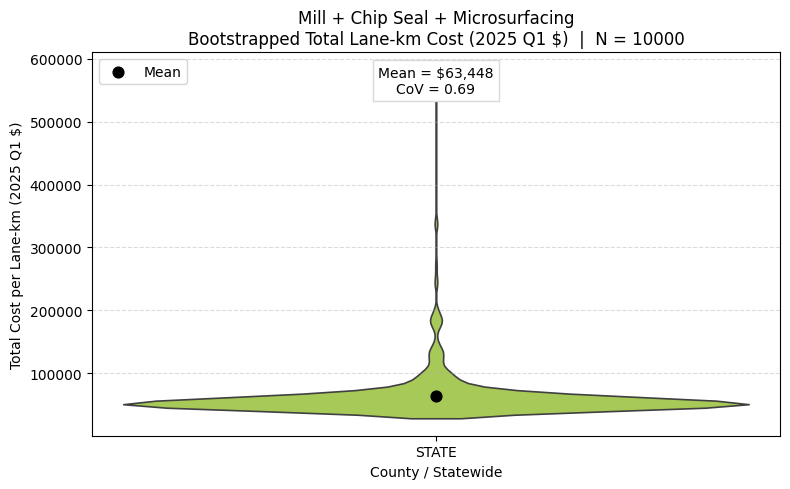

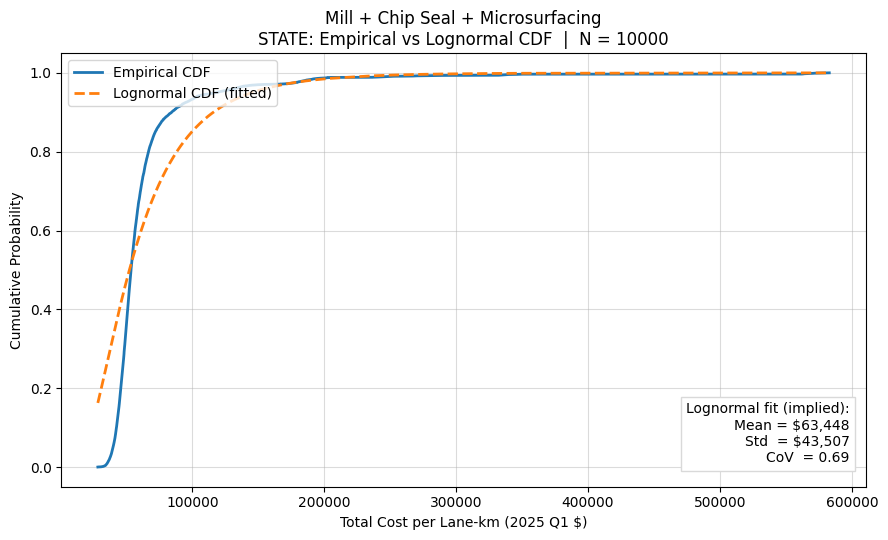

In [31]:
# ===============================================================
# Cell 2 — Bootstrap + STATE-only violin + STATE CDF
# (keeps the same “Mean dot” legend + annotation box style you used)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ---- Settings ----
N_BOOT_SAMPLES = 10000
RANDOM_SEED = GLOBAL_SEED
rng = np.random.default_rng(RANDOM_SEED)

# ---- Bootstrap (independent resampling of components) ----
mill_s  = rng.choice(mill_state_vals,  size=N_BOOT_SAMPLES, replace=True)
chip_s  = rng.choice(chip_state_vals,  size=N_BOOT_SAMPLES, replace=True)
micro_s = rng.choice(micro_state_vals, size=N_BOOT_SAMPLES, replace=True)

total_s = mill_s + chip_s + micro_s
boot_sum_dict = {"STATE": total_s}

# ---- Summary stats ----
mean_ = float(np.mean(total_s))
std_  = float(np.std(total_s, ddof=0))
cov_  = std_ / mean_ if mean_ != 0 else np.nan

print("BOOTSTRAP — Mill + Chip Seal + Microsurfacing (STATE)")
print(f"  N boot = {N_BOOT_SAMPLES}")
print(f"  Mean   = ${mean_:,.0f}")
print(f"  Std    = ${std_:,.0f}")
print(f"  CoV    = {cov_:.2f}")

# ===============================================================
# 1) STATE-only violin (matches the presentation style used in all other treatment sections)
# ===============================================================

# Use the same STATE violin color (light green) for consistency across treatments
STATE_COLOR = "#A7C957"   # light green used for STATE distributions throughout this notebook
EDGE_COLOR  = "0.25"

fig, ax = plt.subplots(figsize=(8, 5))

vp = ax.violinplot(
    [total_s],
    positions=[1],
    widths=0.65,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Style the violin body
for body in vp["bodies"]:
    body.set_facecolor(STATE_COLOR)
    body.set_edgecolor(EDGE_COLOR)
    body.set_alpha(1.0)
    body.set_linewidth(1.2)

# Mean dot + legend (same as the multi-county plot format)
mean_dot = ax.scatter([1], [mean_], s=60, c="k", label="Mean", zorder=3)

# Axis styling
ax.set_xticks([1])
ax.set_xticklabels(["STATE"])
ax.set_xlabel("County / Statewide")
ax.set_ylabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_title("Mill + Chip Seal + Microsurfacing\nBootstrapped Total Lane-km Cost (2025 Q1 $)  |  N = 10000")

ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper left", frameon=True)

# Annotation box: n, mean, CoV (matches other treatment plots)
ax.text(
    1, ax.get_ylim()[1] * 0.965,
    f"Mean = ${mean_:,.0f}\nCoV = {cov_:.2f}",
    ha="center", va="top",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()

# ===============================================================
# 2) STATE CDF: Empirical vs Lognormal (same format as other treatment CDFs in this notebook)
# ===============================================================

# Fit implied lognormal from mean & cov (same method as other treatment CDF cells)
# Implied lognormal parameters
sigma = np.sqrt(np.log(1 + cov_**2))
mu = np.log(mean_) - 0.5 * sigma**2

# Empirical CDF
x = np.sort(total_s)
y = np.arange(1, len(x) + 1) / len(x)

# Lognormal CDF
cdf_fit = lognorm.cdf(x, s=sigma, scale=np.exp(mu))

fig, ax = plt.subplots(figsize=(9, 5.5))

# Curves (keep same colors & styles as rest of presentation)
ax.plot(x, y, linewidth=2, label="Empirical CDF")
ax.plot(x, cdf_fit, "--", linewidth=2, label="Lognormal CDF (fitted)")

ax.set_title(
    "Mill + Chip Seal + Microsurfacing\n"
    "STATE: Empirical vs Lognormal CDF  |  N = 10000"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Cumulative Probability")
ax.grid(True, alpha=0.45)

# ---- Legend: move to upper-left (clear & readable)
ax.legend(
    loc="upper left",
    frameon=True
)

# ---- Stats box: bottom-right (same layout as other CDF figures in this notebook)
ax.text(
    0.98, 0.05,
    "Lognormal fit (implied):\n"
    f"Mean = ${mean_:,.0f}\n"
    f"Std  = ${std_:,.0f}\n"
    f"CoV  = {cov_:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()


# Remove and Repair 3-inch AC with Micro Surfacing

In [32]:
# ===============================================================
# Build STATE-level cost distributions for each component:
#   Spot Repair 3-inch AC (5%) + Microsurfacing (STATE)
#
# Outputs:
#   ac_spot_state_vals   (numpy array)  = 0.05 * (3-inch AC lane-mile costs)
#   micro_state_vals     (numpy array)  = microsurfacing lane-mile costs
# ===============================================================

import numpy as np
import pandas as pd

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# -------------------------
# 0) Sanity: required df
# -------------------------
if "df" not in globals():
    raise ValueError("df not found. Please run the ByJob merge cell first.")

df_local = df.copy()

# Standardize key columns (robust)
df_local["JobID"] = df_local["JobID"].astype(str)
df_local["County"] = df_local["County"].astype(str)
df_local["PayItemID"] = df_local["PayItemID"].astype(str)
df_local["UnitPrice_Real_2025Q1"] = pd.to_numeric(df_local["UnitPrice_Real_2025Q1"], errors="coerce")
df_local["Quantity"] = pd.to_numeric(df_local.get("Quantity", np.nan), errors="coerce")

# ===============================================================
# A) AC (3-inch) lane-mile costs (same method as the AC overlay section)
# ===============================================================

AC_BINDER_LABELS = [
    "4040256 — ASPHALT BINDER (PG 58-28)", "4040262 — ASPHALT BINDER (PG 64-16)",
    "4040264 — ASPHALT BINDER (PG 64-22)", "4040266 — ASPHALT BINDER (PG 64-28)",
    "4040270 — ASPHALT BINDER (PG 70-10)", "4040274 — ASPHALT BINDER (PG 70-22)",
    "4040282 — ASPHALT BINDER (PG 76-16)", "4040284 — ASPHALT BINDER (PG 76-22)",
    "4040286 — ASPHALT BINDER (PG 64-28 TR+)", "4040288 — ASPHALT BINDER (PG 70-22 TR+)",
    "4040290 — ASPHALT BINDER (PG 76-22 TR+)", "4040230 — ASPHALT BINDER (PG 76-22 TR+)"
]
AC_MIX_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)", "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)", "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)", "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
]
AC_MINERAL_ADMIX_LABELS = [
    "4160031 — Mineral admixture", "4170031 — Mineral admixture",
    "4060026 — Mineral admixture (for 3/4\" mix)", "4040425 — Mineral admixture"
]

def get_payitem_id(label: str) -> str:
    return label.split("—")[0].strip()

ac_binder_ids = set(get_payitem_id(lbl) for lbl in AC_BINDER_LABELS)
ac_mix_ids    = set(get_payitem_id(lbl) for lbl in AC_MIX_LABELS)
ac_ma_ids     = set(get_payitem_id(lbl) for lbl in AC_MINERAL_ADMIX_LABELS)

def compute_ac_lane_mile_costs_for_thickness(
    df_in: pd.DataFrame,
    ac_binder_ids: set,
    ac_mix_ids: set,
    ac_ma_ids: set,
    thickness_in: float,
    unit_weight_pcf: float = 145.0,
    lane_width_ft: float = 12.0,
    asphalt_frac: float = 0.05,
    admix_agg_frac: float = 0.01,
) -> pd.DataFrame:
    """
    One row per job that has ALL: mix + binder + mineral admixture
    Total_Cost_LaneMile = mix_price*mix_tons_lm + binder_price*binder_tons_lm + ma_price*admix_tons_lm
    Prices are job-level medians (same method as the overlay section).
    """
    df0 = df_in.copy()
    df0["PayItemID"] = df0["PayItemID"].astype(str)

    # Lane-mile tonnage depends on thickness
    vol_ft3 = lane_width_ft * 5280.0 * (thickness_in / 12.0)
    mix_tons_per_lane_mile = vol_ft3 * unit_weight_pcf / 2000.0
    binder_tons_per_lane_mile = asphalt_frac * mix_tons_per_lane_mile
    agg_tons_per_lane_mile = mix_tons_per_lane_mile - binder_tons_per_lane_mile
    admix_tons_per_lane_mile = admix_agg_frac * agg_tons_per_lane_mile

    # Jobs containing all 3 groups
    job_mix = set(df0.loc[df0["PayItemID"].isin(ac_mix_ids), "JobID"].unique())
    job_binder = set(df0.loc[df0["PayItemID"].isin(ac_binder_ids), "JobID"].unique())
    job_ma = set(df0.loc[df0["PayItemID"].isin(ac_ma_ids), "JobID"].unique())
    ac_jobids = job_mix & job_binder & job_ma

    recs = []
    for jobid in ac_jobids:
        jr = df0[df0["JobID"] == jobid]
        county = str(jr["County"].iloc[0]) if len(jr) else None

        mix_p = jr.loc[jr["PayItemID"].isin(ac_mix_ids), "UnitPrice_Real_2025Q1"].median()
        binder_p = jr.loc[jr["PayItemID"].isin(ac_binder_ids), "UnitPrice_Real_2025Q1"].median()
        ma_p = jr.loc[jr["PayItemID"].isin(ac_ma_ids), "UnitPrice_Real_2025Q1"].median()

        if np.isnan(mix_p) or np.isnan(binder_p) or np.isnan(ma_p):
            continue

        total_cost_lm = (
            mix_p * mix_tons_per_lane_mile
            + binder_p * binder_tons_per_lane_mile
            + ma_p * admix_tons_per_lane_mile
        ) * MILE_TO_KM

        recs.append({
            "JobID": jobid,
            "County": county,
            "AC_THICKNESS_IN": thickness_in,
            "Total_Cost_LaneMile": float(total_cost_lm)
        })

    out = pd.DataFrame(recs)
    if out.empty:
        return out

    # Add STATE group
    out_state = out.copy()
    out_state["County"] = "STATE"
    return pd.concat([out, out_state], ignore_index=True)

# Compute 3-inch AC lane-mile costs
ac_3in_df = compute_ac_lane_mile_costs_for_thickness(
    df_in=df_local,
    ac_binder_ids=ac_binder_ids,
    ac_mix_ids=ac_mix_ids,
    ac_ma_ids=ac_ma_ids,
    thickness_in=3.0
)

if ac_3in_df.empty:
    raise ValueError("AC 3-inch dataset is empty. Check payitem IDs / UnitPrice_Real_2025Q1 coverage.")

ac_3in_state_vals = (
    ac_3in_df.loc[ac_3in_df["County"] == "STATE", "Total_Cost_LaneMile"]
    .dropna()
    .to_numpy(dtype=float)
)

# Spot repair = 5% area
ac_spot_state_vals = 0.05 * ac_3in_state_vals
ac_spot_state_vals = ac_spot_state_vals[np.isfinite(ac_spot_state_vals) & (ac_spot_state_vals > 0)]

# ===============================================================
# B) Microsurfacing STATE lane-mile costs
#    (same logic you used in microsurfacing section)
# ===============================================================

AGG_CODES = {4040170, 4040171, 4040172}
EMUL_CODES = {4040077, 4040076}
MERGE_FROM = 4040171
MERGE_TO   = 4040172

# ADOT 2019 rate: 30 lb/sy, 7040 sy/lane-mile  -> 105.6 ton/lane-mile
AREA_SQ_YD = 7040.0
AGG_LB_PER_SY_TOTAL = 30.0
AGG_TON_PER_SY_TOTAL = AGG_LB_PER_SY_TOTAL / 2000.0
AGG_TON_PER_LM = AREA_SQ_YD * AGG_TON_PER_SY_TOTAL  # 105.6

# Keep only microsurfacing payitems
ms = df_local[df_local["PayItemID"].isin(set(map(str, AGG_CODES | EMUL_CODES)))].copy()
ms["PayItemID_num"] = pd.to_numeric(ms["PayItemID"], errors="coerce")

# Aggregate per JobID+PayItemID: Quantity SUM, UnitPrice MEDIAN
job_code = (
    ms.groupby(["JobID", "PayItemID_num"], as_index=False)
      .agg(Quantity=("Quantity", "sum"),
           UnitPrice_Real_2025Q1=("UnitPrice_Real_2025Q1", "median"))
      .dropna(subset=["PayItemID_num"])
)

# Pivot to apply merge rule (4040171 -> 4040172 when both exist)
q = job_code.pivot(index="JobID", columns="PayItemID_num", values="Quantity")
p = job_code.pivot(index="JobID", columns="PayItemID_num", values="UnitPrice_Real_2025Q1")

if (MERGE_FROM in q.columns) and (MERGE_TO in q.columns):
    jobs_both = q.index[q[MERGE_FROM].notna() & q[MERGE_TO].notna()]
    q.loc[jobs_both, MERGE_TO] = q.loc[jobs_both, MERGE_TO].fillna(0) + q.loc[jobs_both, MERGE_FROM].fillna(0)
    q.loc[jobs_both, MERGE_FROM] = np.nan
    # Keep MERGE_TO unit price (same as the Milling section)

# Back to long
q_long = q.stack().dropna().reset_index().rename(columns={"level_1": "PayItemID_num", 0: "Quantity"})
p_long = p.stack().dropna().reset_index().rename(columns={"level_1": "PayItemID_num", 0: "UnitPrice_Real_2025Q1"})
job_code_adj = q_long.merge(p_long, on=["JobID", "PayItemID_num"], how="left")

# Select jobs: exactly 1 AGG and 1 EMUL remain
valid_jobs = []
for jobid, g in job_code_adj.groupby("JobID"):
    agg_present = g[g["PayItemID_num"].isin(AGG_CODES)]
    emul_present = g[g["PayItemID_num"].isin(EMUL_CODES)]
    if len(agg_present) == 1 and len(emul_present) == 1:
        valid_jobs.append(jobid)

job_code_valid = job_code_adj[job_code_adj["JobID"].isin(valid_jobs)].copy()

# Compute lane-mile cost per job
rows = []
for jobid, g in job_code_valid.groupby("JobID"):
    agg_row = g[g["PayItemID_num"].isin(AGG_CODES)].iloc[0]
    emul_row = g[g["PayItemID_num"].isin(EMUL_CODES)].iloc[0]

    agg_qty_proj = float(agg_row["Quantity"])
    emul_qty_proj = float(emul_row["Quantity"])
    agg_price = float(agg_row["UnitPrice_Real_2025Q1"])   # $/ton
    emul_price = float(emul_row["UnitPrice_Real_2025Q1"]) # $/ton

    if not (np.isfinite(agg_qty_proj) and np.isfinite(emul_qty_proj) and np.isfinite(agg_price) and np.isfinite(emul_price)):
        continue
    denom = agg_qty_proj + emul_qty_proj
    if denom <= 0:
        continue

    r = agg_qty_proj / denom
    if r <= 0 or r >= 1:
        continue

    agg_ton_lm = AGG_TON_PER_LM
    total_mix_ton_lm = agg_ton_lm / r
    emul_ton_lm = total_mix_ton_lm - agg_ton_lm

    cost_lm = agg_price * agg_ton_lm + emul_price * emul_ton_lm
    if np.isfinite(cost_lm) and cost_lm > 0:
        rows.append(cost_lm)

micro_state_vals = np.asarray(rows, dtype=float) * MILE_TO_KM
micro_state_vals = micro_state_vals[np.isfinite(micro_state_vals) & (micro_state_vals > 0)]

# -------------------------
# Final checks
# -------------------------
print("STATE sample sizes (before bootstrap):")
print(f"  AC spot (3-inch * 5%)  n = {len(ac_spot_state_vals)}")
print(f"  Microsurfacing         n = {len(micro_state_vals)}")

if len(ac_spot_state_vals) == 0 or len(micro_state_vals) == 0:
    raise ValueError("One or more component distributions are empty.")


STATE sample sizes (before bootstrap):
  AC spot (3-inch * 5%)  n = 379
  Microsurfacing         n = 41


BOOTSTRAP — Spot Repair 3-inch AC (5%) + Microsurfacing (STATE)
  N boot = 10000
  Mean   = $25,488
  Std    = $5,527
  CoV    = 0.22


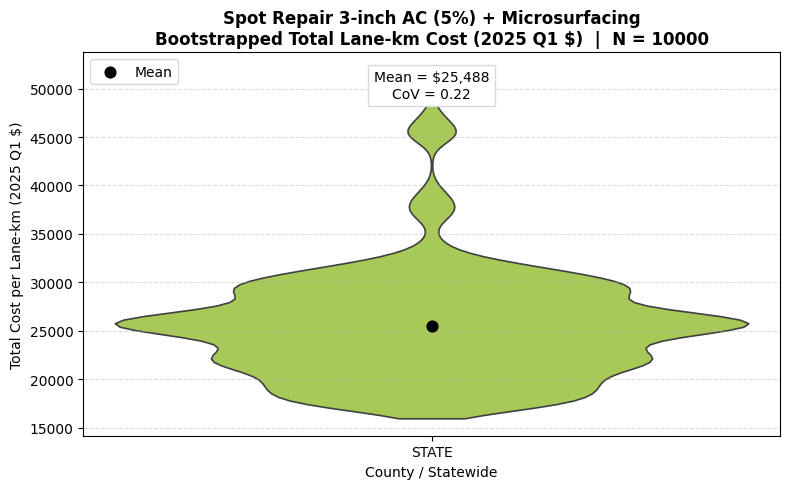

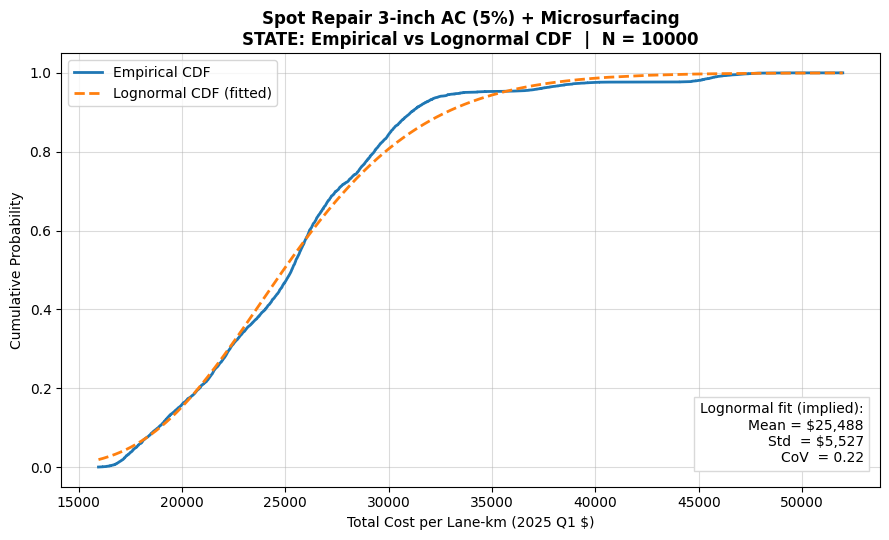

In [33]:
# ===============================================================
# Cell 2 — Bootstrap + STATE-only violin + STATE CDF
#   Spot Repair 3-inch AC (5%) + Microsurfacing (STATE)
# Legend and annotation box are separated to prevent overlap
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ---- Settings ----
N_BOOT_SAMPLES = 10000
RANDOM_SEED = GLOBAL_SEED
rng = np.random.default_rng(RANDOM_SEED)

# ---- Bootstrap (independent resampling of components) ----
ac_s    = rng.choice(ac_spot_state_vals, size=N_BOOT_SAMPLES, replace=True)
micro_s = rng.choice(micro_state_vals,   size=N_BOOT_SAMPLES, replace=True)

total_s = ac_s + micro_s

# ---- Summary ----
mean_ = float(np.mean(total_s))
std_  = float(np.std(total_s, ddof=0))
cov_  = std_ / mean_ if mean_ != 0 else np.nan

print("BOOTSTRAP — Spot Repair 3-inch AC (5%) + Microsurfacing (STATE)")
print(f"  N boot = {N_BOOT_SAMPLES}")
print(f"  Mean   = ${mean_:,.0f}")
print(f"  Std    = ${std_:,.0f}")
print(f"  CoV    = {cov_:.2f}")

# ===============================================================
# 1) STATE-only violin (same style you used)
# ===============================================================

STATE_COLOR = "#A7C957"  # light green used for STATE distributions throughout this notebook
EDGE_COLOR  = "0.25"

fig, ax = plt.subplots(figsize=(8, 5))

vp = ax.violinplot(
    [total_s],
    positions=[1],
    widths=0.65,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_facecolor(STATE_COLOR)
    body.set_edgecolor(EDGE_COLOR)
    body.set_alpha(1.0)
    body.set_linewidth(1.2)

ax.scatter([1], [mean_], s=60, c="k", label="Mean", zorder=3)

ax.set_xticks([1])
ax.set_xticklabels(["STATE"])
ax.set_xlabel("County / Statewide")
ax.set_ylabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_title(
    "Spot Repair 3-inch AC (5%) + Microsurfacing\n"
    "Bootstrapped Total Lane-km Cost (2025 Q1 $)  |  N = 10000",
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper left", frameon=True)

ax.text(
    1, ax.get_ylim()[1] * 0.965,
    f"Mean = ${mean_:,.0f}\nCoV = {cov_:.2f}",
    ha="center", va="top",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()

# ===============================================================
# 2) STATE CDF — Empirical vs Lognormal (legend separated)
# ===============================================================

sigma = np.sqrt(np.log(1 + cov_**2))
mu = np.log(mean_) - 0.5 * sigma**2

x = np.sort(total_s)
y = np.arange(1, len(x) + 1) / len(x)
cdf_fit = lognorm.cdf(x, s=sigma, scale=np.exp(mu))

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(x, y, linewidth=2, label="Empirical CDF")
ax.plot(x, cdf_fit, "--", linewidth=2, label="Lognormal CDF (fitted)")

ax.set_title(
    "Spot Repair 3-inch AC (5%) + Microsurfacing\n"
    "STATE: Empirical vs Lognormal CDF  |  N = 10000",
    fontweight="bold"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Cumulative Probability")
ax.grid(True, alpha=0.45)

# Legend upper-left, stats box bottom-right (no overlap)
ax.legend(loc="upper left", frameon=True)

ax.text(
    0.98, 0.05,
    "Lognormal fit (implied):\n"
    f"Mean = ${mean_:,.0f}\n"
    f"Std  = ${std_:,.0f}\n"
    f"CoV  = {cov_:.2f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()


In [34]:
# ===============================================================
# Build STATE-level cost distributions for each component:
#   Chip Seal (STATE) + Crack Seal (STATE)
#
# Outputs:
#   chip_state_vals   (numpy array) = chip seal lane-mile costs
#   crack_state_vals  (numpy array) = crack seal lane-mile costs
# ===============================================================

import numpy as np
import pandas as pd

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# -------------------------
# 0) Sanity: required df
# -------------------------
if "df" not in globals():
    raise ValueError("df not found. Please run the ByJob merge cell first.")

df_local = df.copy()

# Standardize key columns (robust)
df_local["JobID"] = df_local["JobID"].astype(str)
df_local["County"] = df_local["County"].astype(str)
df_local["PayItemID"] = df_local["PayItemID"].astype(str)
df_local["UnitPrice_Real_2025Q1"] = pd.to_numeric(df_local["UnitPrice_Real_2025Q1"], errors="coerce")
df_local["Quantity"] = pd.to_numeric(df_local.get("Quantity", np.nan), errors="coerce")

# ===============================================================
# A) CHIP SEAL — STATE lane-mile costs (same logic as the Chip Seal section above)
# ===============================================================

# Payitems
COVER_PAYITEMS = {"4040162", "4040159"}
CRS_PAYITEMS = {"4040073", "4040074"}                # emulsified asphalt
PG_BINDER_PAYITEMS = {"4040286", "4040288", "4040230"}  # PG binders
BITUMINOUS_PAYITEMS = CRS_PAYITEMS | PG_BINDER_PAYITEMS

# Outliers / overrides (same as the Chip Seal section above)
OUTLIER_JOBIDS_CHIP = {"2001152", "2017075", "2020060", "2022098"}
FORCED_PG_BY_JOBID = {"2024029": "4040286"}  # if job has >=2 PG binders -> force this one

# Lane-mile constants (same as the Chip Seal section above)
AREA_SQ_YD = 7040.0
BINDER_APP_RATE = 0.45
COVER_APP_RATE = 0.01
GAL_PER_TON = 240.0

MAX_LANE_MILE_COST = 50_000.0

def pick_bituminous_for_job(jobid: str, cover_ids: set, bitum_ids: set) -> set:
    """
    Apply chip-seal selection rules and return the chosen bituminous IDs.
    Rules:
      R3) Job-specific override: if job has >=2 PG binders and jobid in FORCED_PG_BY_JOBID -> keep forced PG.
      R1) If cover includes 4040162 AND job has CRS and PG -> keep CRS only.
      R2) If cover includes 4040159 AND job has >=2 PG binders and includes 4040288 -> keep only 4040288.
    """
    chosen = set(bitum_ids)

    # R3
    if jobid in FORCED_PG_BY_JOBID:
        pg_in_job = chosen & PG_BINDER_PAYITEMS
        if len(pg_in_job) >= 2:
            chosen = (chosen - PG_BINDER_PAYITEMS) | {FORCED_PG_BY_JOBID[jobid]}

    # R1
    if "4040162" in cover_ids:
        has_crs = len(chosen & CRS_PAYITEMS) > 0
        has_pg = len(chosen & PG_BINDER_PAYITEMS) > 0
        if has_crs and has_pg:
            chosen = chosen & CRS_PAYITEMS

    # R2
    if "4040159" in cover_ids:
        pg_in_job = chosen & PG_BINDER_PAYITEMS
        if len(pg_in_job) >= 2 and "4040288" in pg_in_job:
            chosen = (chosen - PG_BINDER_PAYITEMS) | {"4040288"}

    return chosen

def compute_chip_lane_mile_cost(df_job: pd.DataFrame,
                               cover_id: str,
                               bitum_id: str,
                               cover_cy_per_lane_mile: float,
                               binder_tons_per_lane_mile: float,
                               area_sq_yd: float) -> float:
    cover_price = df_job.loc[df_job["PayItemID"] == cover_id, "UnitPrice_Real_2025Q1"].median()
    bitum_price = df_job.loc[df_job["PayItemID"] == bitum_id, "UnitPrice_Real_2025Q1"].median()
    if np.isnan(cover_price) or np.isnan(bitum_price):
        return np.nan

    # Cover conversion
    if cover_id == "4040162":        # $/C.Y
        cover_cost = cover_price * cover_cy_per_lane_mile
    elif cover_id == "4040159":      # $/S.Y
        cover_cost = cover_price * area_sq_yd
    else:
        return np.nan

    # Bituminous conversion (assume $/TON)
    binder_cost = bitum_price * binder_tons_per_lane_mile

    return cover_cost + binder_cost

# Remove chip outlier jobs
df_chip = df_local[~df_local["JobID"].isin(OUTLIER_JOBIDS_CHIP)].copy()

# Lane-mile conversion factors
binder_tons_per_lane_mile = (AREA_SQ_YD * BINDER_APP_RATE) / GAL_PER_TON
cover_cy_per_lane_mile = AREA_SQ_YD * COVER_APP_RATE

job_payitems = df_chip.groupby("JobID")["PayItemID"].apply(set)

chip_costs = []
for jobid, payitems in job_payitems.items():
    cover_ids = payitems & COVER_PAYITEMS
    bitum_ids = payitems & BITUMINOUS_PAYITEMS
    if not cover_ids or not bitum_ids:
        continue

    chosen_bitum = pick_bituminous_for_job(jobid, cover_ids, bitum_ids)

    # enforce exactly 1 cover and 1 chosen bituminous
    if len(cover_ids) != 1 or len(chosen_bitum) != 1:
        continue

    cover_id = next(iter(cover_ids))
    bitum_id = next(iter(chosen_bitum))

    df_job = df_chip[df_chip["JobID"] == jobid]
    c = compute_chip_lane_mile_cost(
        df_job=df_job,
        cover_id=cover_id,
        bitum_id=bitum_id,
        cover_cy_per_lane_mile=cover_cy_per_lane_mile,
        binder_tons_per_lane_mile=binder_tons_per_lane_mile,
        area_sq_yd=AREA_SQ_YD
    )
    if np.isfinite(c):
        chip_costs.append(c)

chip_state_vals = np.asarray(chip_costs, dtype=float)
chip_state_vals = chip_state_vals[np.isfinite(chip_state_vals)]
chip_state_vals = chip_state_vals[(chip_state_vals > 0) & (chip_state_vals <= MAX_LANE_MILE_COST)]
chip_state_vals = chip_state_vals * MILE_TO_KM  # convert $/lane-mile -> $/lane-km

# ===============================================================
# B) CRACK SEAL — STATE lane-mile costs (same logic as the Crack Seal section above)
# ===============================================================

PAYITEM_ID_CRACK = "9240116"
OUTLIER_JOBIDS_CRACK = [
    "2005104", "2024059", "2010097", "2007098", "2015129", "2010027",
    "2009024", "2008087", "2008080", "2009172", "2007094"
]

# Typical lane-mile conversion assumptions (same as the Crack Seal section above)
CRACK_LF_PER_LANE_MILE_TYP = 6500.0  # LF of cracks per lane-mile
LB_PER_LF_TYP = 0.30                 # lb of sealant per LF
LB_PER_LANE_MILE_TYP = CRACK_LF_PER_LANE_MILE_TYP * LB_PER_LF_TYP
PRICE_COL = "UnitPrice_Real_2025Q1"  # $/lb

df_crack = df_local[
    (df_local["PayItemID"] == PAYITEM_ID_CRACK) &
    (~df_local["JobID"].isin(OUTLIER_JOBIDS_CRACK))
].copy()

df_crack["Cost_per_LaneMile_Real_2025Q1"] = df_crack[PRICE_COL] * LB_PER_LANE_MILE_TYP * MILE_TO_KM

crack_state_vals = df_crack["Cost_per_LaneMile_Real_2025Q1"].dropna().to_numpy(dtype=float)
crack_state_vals = crack_state_vals[np.isfinite(crack_state_vals) & (crack_state_vals > 0)]

# -------------------------
# Final checks
# -------------------------
print("STATE sample sizes (before bootstrap):")
print(f"  Chip Seal   n = {len(chip_state_vals)}")
print(f"  Crack Seal  n = {len(crack_state_vals)}")

if len(chip_state_vals) == 0 or len(crack_state_vals) == 0:
    raise ValueError("One or more component distributions are empty (Chip or Crack). Check payitems / filters.")

STATE sample sizes (before bootstrap):
  Chip Seal   n = 72
  Crack Seal  n = 32


BOOTSTRAP — Chip Seal + Crack Seal (STATE)
  N boot = 10000
  Mean   = $20,764
  Std    = $4,793
  CoV    = 0.23


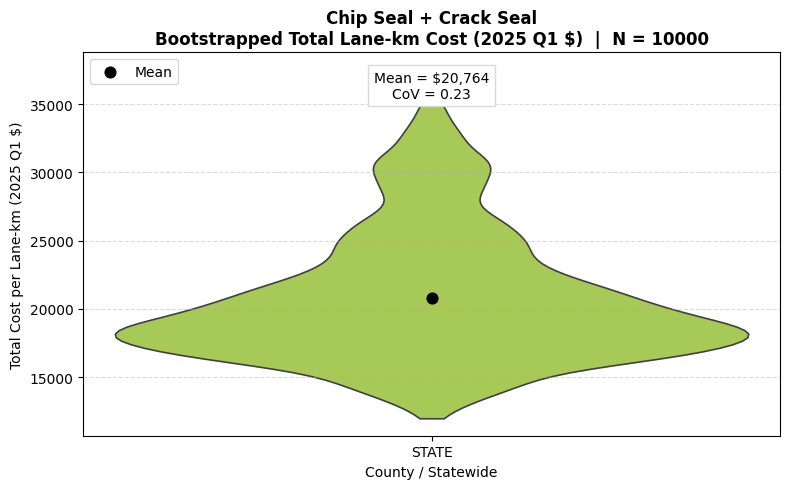

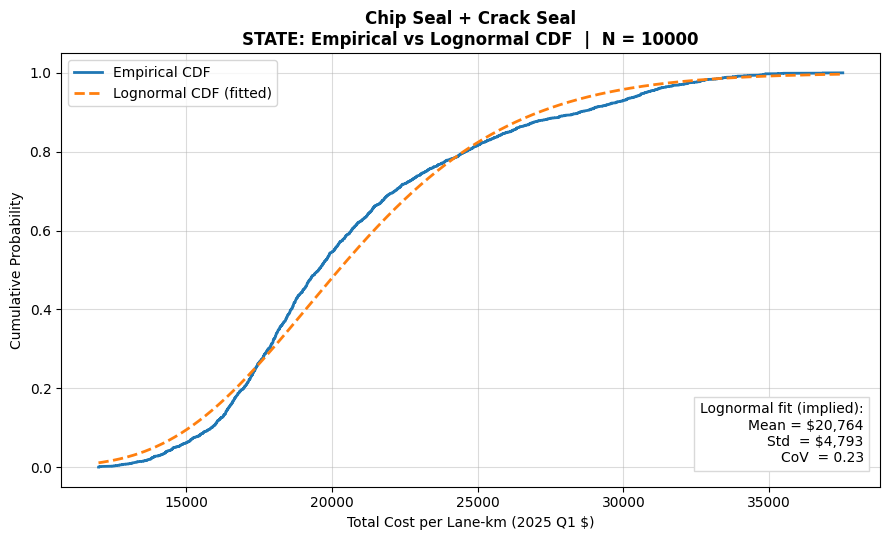

In [35]:
# ===============================================================
# Cell 2 — Bootstrap + STATE-only violin + STATE CDF
#   Chip Seal (STATE) + Crack Seal (STATE)
# Legend and annotation box are separated to prevent overlap
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ---- Settings ----
N_BOOT_SAMPLES = 10000
RANDOM_SEED = GLOBAL_SEED
rng = np.random.default_rng(RANDOM_SEED)

# ---- Bootstrap (independent resampling of components) ----
chip_s  = rng.choice(chip_state_vals,  size=N_BOOT_SAMPLES, replace=True)
crack_s = rng.choice(crack_state_vals, size=N_BOOT_SAMPLES, replace=True)

total_s = chip_s + crack_s

# ---- Summary ----
mean_ = float(np.mean(total_s))
std_  = float(np.std(total_s, ddof=0))
cov_  = std_ / mean_ if mean_ != 0 else np.nan

print("BOOTSTRAP — Chip Seal + Crack Seal (STATE)")
print(f"  N boot = {N_BOOT_SAMPLES}")
print(f"  Mean   = ${mean_:,.0f}")
print(f"  Std    = ${std_:,.0f}")
print(f"  CoV    = {cov_:.2f}")

# ===============================================================
# 1) STATE-only violin
# ===============================================================

STATE_COLOR = "#A7C957"  # light green used for STATE distributions throughout this notebook
EDGE_COLOR  = "0.25"

fig, ax = plt.subplots(figsize=(8, 5))

vp = ax.violinplot(
    [total_s],
    positions=[1],
    widths=0.65,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_facecolor(STATE_COLOR)
    body.set_edgecolor(EDGE_COLOR)
    body.set_alpha(1.0)
    body.set_linewidth(1.2)

ax.scatter([1], [mean_], s=60, c="k", label="Mean", zorder=3)

ax.set_xticks([1])
ax.set_xticklabels(["STATE"])
ax.set_xlabel("County / Statewide")
ax.set_ylabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_title(
    "Chip Seal + Crack Seal\n"
    "Bootstrapped Total Lane-km Cost (2025 Q1 $)  |  N = 10000",
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper left", frameon=True)

ax.text(
    1, ax.get_ylim()[1] * 0.965,
    f"Mean = ${mean_:,.0f}\nCoV = {cov_:.2f}",
    ha="center", va="top",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()

# ===============================================================
# 2) STATE CDF — Empirical vs Lognormal (legend separated)
# ===============================================================

sigma = np.sqrt(np.log(1 + cov_**2))
mu = np.log(mean_) - 0.5 * sigma**2

x = np.sort(total_s)
y = np.arange(1, len(x) + 1) / len(x)
cdf_fit = lognorm.cdf(x, s=sigma, scale=np.exp(mu))

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(x, y, linewidth=2, label="Empirical CDF")
ax.plot(x, cdf_fit, "--", linewidth=2, label="Lognormal CDF (fitted)")

ax.set_title(
    "Chip Seal + Crack Seal\n"
    "STATE: Empirical vs Lognormal CDF  |  N = 10000",
    fontweight="bold"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Cumulative Probability")
ax.grid(True, alpha=0.45)

# Legend upper-left, stats box bottom-right (no overlap)
ax.legend(loc="upper left", frameon=True)

ax.text(
    0.98, 0.05,
    "Lognormal fit (implied):\n"
    f"Mean = ${mean_:,.0f}\n"
    f"Std  = ${std_:,.0f}\n"
    f"CoV  = {cov_:.2f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()

# Reconstruction

In [36]:
# ===============================================================
# Build STATE-level cost distributions for Reconstruction components:
# Treatment assumed:
#   Mill + 9" AC + 0.5" FR + Tack + 4" Base + 12" Subbase
#
# Rules:
#   - Milling: IQR filter per milling PayItemID, then job-median unit price
#   - Base/Subbase: IQR filter per PayItemID (you asked IQR for base; I apply same to subbase too
#                   so reconstruction is consistent and stable)
#   - All outputs are STATE-level numpy arrays ready for bootstrapping
#
# Outputs:
#   mill_state_vals     ($/lane-mile)
#   ac5_state_vals      ($/lane-mile)
#   fr05_state_vals     ($/lane-mile)
#   tack_state_vals     ($/lane-mile)
#   base4_state_vals    ($/lane-mile)
#   subbase8_state_vals ($/lane-mile)
# ===============================================================

import numpy as np
import pandas as pd

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# -------------------------
# 0) Prepare df (robust)
# -------------------------
if "df" not in globals():
    raise ValueError("df not found. Run the cell that creates NHCCI-adjusted df first.")

df0 = df.copy()
df0["JobID"] = df0["JobID"].astype(str)
df0["County"] = df0["County"].astype(str)
df0["PayItemID"] = df0["PayItemID"].astype(str)
df0["UnitPrice_Real_2025Q1"] = pd.to_numeric(df0["UnitPrice_Real_2025Q1"], errors="coerce")

# Optional qty (only used in FR pivot)
if "Quantity" in df0.columns:
    df0["Quantity"] = pd.to_numeric(df0["Quantity"], errors="coerce")
else:
    df0["Quantity"] = np.nan

# -------------------------
# Helper: IQR filter
# -------------------------
def iqr_bounds(x: pd.Series, k: float = 1.5):
    x = x.dropna()
    if len(x) < 4:
        return -np.inf, np.inf
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return lo, hi

def apply_iqr_filter_by_payitem(df_in: pd.DataFrame, payitem_ids: list[str], price_col: str):
    """Return df filtered to payitem_ids with IQR outliers removed per PayItemID."""
    d = df_in[df_in["PayItemID"].isin(payitem_ids)].copy()
    out_parts = []
    for pid, g in d.groupby("PayItemID"):
        lo, hi = iqr_bounds(g[price_col], k=1.5)
        out_parts.append(g[(g[price_col] >= lo) & (g[price_col] <= hi)])
    if len(out_parts) == 0:
        return d.iloc[0:0].copy()
    return pd.concat(out_parts, ignore_index=True)

# ===============================================================
# 1) MILLING (IQR per PayItemID, then job-median)  → $/lane-mile
#   (Same approach as the overlay and milling sections above)
# ===============================================================

MILLING_IDS = ["2020081","2020082","2020084","2020085","2020086","2020088"]  # ADOT milling pay item IDs

LANE_WIDTH_FT = 12.0
LANE_LENGTH_FT = 5280.0
LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0  # SY per lane-mile

mill_rows = df0[df0["PayItemID"].isin(MILLING_IDS)].dropna(subset=["UnitPrice_Real_2025Q1"]).copy()
mill_rows_iqr = apply_iqr_filter_by_payitem(mill_rows, MILLING_IDS, "UnitPrice_Real_2025Q1")

# if a job has multiple milling items, use the median across milling items
mill_job = (
    mill_rows_iqr.groupby("JobID", as_index=False)
    .agg(Milling_UnitPrice=("UnitPrice_Real_2025Q1", "median"))
)
mill_job["Milling_Cost_Per_LaneMile"] = mill_job["Milling_UnitPrice"] * LANE_AREA_SQYD * MILE_TO_KM
mill_state_vals = mill_job["Milling_Cost_Per_LaneMile"].dropna().to_numpy(dtype=float)

# ===============================================================
# 2) TACK COAT (Pay item 4040111) → $/lane-mile
#   (Same constants as the Tack Coat section above)
# ===============================================================

TACK_PAYITEM_ID = "4040111"
TACK_APP_RATE_GAL_PER_SQYD = 0.07
TACK_UNIT_WEIGHT_LB_PER_GAL = 8.33
LB_PER_TON = 2000.0

tack_rows = df0[df0["PayItemID"] == TACK_PAYITEM_ID].dropna(subset=["UnitPrice_Real_2025Q1"]).copy()

tack_total_gallons = TACK_APP_RATE_GAL_PER_SQYD * LANE_AREA_SQYD
tack_total_lbs = tack_total_gallons * TACK_UNIT_WEIGHT_LB_PER_GAL
tack_tons_per_lane_mile = tack_total_lbs / LB_PER_TON

tack_job = (
    tack_rows.groupby("JobID", as_index=False)
    .agg(Tack_UnitPrice=("UnitPrice_Real_2025Q1", "median"))
)
tack_job["Tack_Cost_Per_LaneMile"] = tack_job["Tack_UnitPrice"] * tack_tons_per_lane_mile * MILE_TO_KM
tack_state_vals = tack_job["Tack_Cost_Per_LaneMile"].dropna().to_numpy(dtype=float)

# ===============================================================
# 3) AC (5-inch) → $/lane-mile
#   (Same structure as the AC section above, but thickness = 5 in)
# ===============================================================

AC_BINDER_IDS = {
    "4040256","4040262","4040264","4040266","4040270","4040274",
    "4040282","4040284","4040286","4040288","4040290","4040230"
}
AC_MIX_IDS = {"4060006","4160001","4160002","4160003","4160004","4160009"}
AC_MINADMIX_IDS = {"4160031","4170031","4060026","4040425"}

AC_UNIT_WEIGHT_PCF = 145.0
AC_THICKNESS_IN = 9.0
AC_ASPHALT_FRAC = 0.05
AC_ADMIX_AGG_FRAC = 0.01

ac_vol_ft3 = LANE_WIDTH_FT * 5280.0 * (AC_THICKNESS_IN / 12.0)
ac_mix_tons_lm = ac_vol_ft3 * AC_UNIT_WEIGHT_PCF / 2000.0
ac_binder_tons_lm = AC_ASPHALT_FRAC * ac_mix_tons_lm
ac_agg_tons_lm = ac_mix_tons_lm - ac_binder_tons_lm
ac_minadmix_tons_lm = AC_ADMIX_AGG_FRAC * ac_agg_tons_lm

def jobids_with_any(ids: set[str]) -> set[str]:
    return set(df0.loc[df0["PayItemID"].isin(ids), "JobID"].unique())

ac_jobids = jobids_with_any(AC_BINDER_IDS) & jobids_with_any(AC_MIX_IDS) & jobids_with_any(AC_MINADMIX_IDS)

ac_costs = []
for jobid in ac_jobids:
    jr = df0[df0["JobID"] == jobid]
    mix_p = jr.loc[jr["PayItemID"].isin(AC_MIX_IDS), "UnitPrice_Real_2025Q1"].median()
    binder_p = jr.loc[jr["PayItemID"].isin(AC_BINDER_IDS), "UnitPrice_Real_2025Q1"].median()
    minad_p = jr.loc[jr["PayItemID"].isin(AC_MINADMIX_IDS), "UnitPrice_Real_2025Q1"].median()

    if np.isnan(mix_p) or np.isnan(binder_p) or np.isnan(minad_p):
        continue

    total_cost_lm = (
        mix_p * ac_mix_tons_lm
        + binder_p * ac_binder_tons_lm
        + minad_p * ac_minadmix_tons_lm
    )
    if np.isfinite(total_cost_lm) and total_cost_lm > 0:
        ac_costs.append(float(total_cost_lm))

ac5_state_vals = np.asarray(ac_costs, dtype=float) * MILE_TO_KM

# ===============================================================
# 4) FR (0.5-inch) → $/lane-mile
#   (Same structure as the FR section above)
# ===============================================================

FR_MIX_ID = "4140040"
FR_BINDER_ID = "4140042"
FR_MINAD_ID = "4140044"
FR_IDS = [FR_MIX_ID, FR_BINDER_ID, FR_MINAD_ID]

fr_jobs = (
    df0[df0["PayItemID"].isin(FR_IDS)]
    .groupby("JobID")["PayItemID"]
    .nunique()
)
eligible_fr_jobs = set(fr_jobs[fr_jobs == 3].index)

df_fr = df0[df0["JobID"].isin(eligible_fr_jobs) & df0["PayItemID"].isin(FR_IDS)].copy()

# Need Quantity for binder fraction
df_fr = df_fr.dropna(subset=["Quantity", "UnitPrice_Real_2025Q1"])

fr_pivot = df_fr.pivot_table(
    index=["JobID"],
    columns="PayItemID",
    values=["Quantity", "UnitPrice_Real_2025Q1"],
    aggfunc="first"
)
fr_pivot.columns = [f"{col}_{pid}" for col, pid in fr_pivot.columns]
fr_pivot = fr_pivot.reset_index()

# Lane-mile conversion for FR (0.5 in thickness)
FR_THICKNESS_IN = 0.5
DENSITY_MIX_LB_FT3 = 125.0
ft_per_lane_mile = LANE_WIDTH_FT * 5280.0
vol_ft3 = ft_per_lane_mile * (FR_THICKNESS_IN / 12.0)
tons_lm_fr = vol_ft3 * DENSITY_MIX_LB_FT3 / 2000.0

# Extract columns
fr_pivot["Mix_Ton"] = fr_pivot.get(f"Quantity_{FR_MIX_ID}")
fr_pivot["Binder_Ton"] = fr_pivot.get(f"Quantity_{FR_BINDER_ID}")
fr_pivot["MinAd_Ton"] = fr_pivot.get(f"Quantity_{FR_MINAD_ID}")

fr_pivot["Mix_P"] = fr_pivot.get(f"UnitPrice_Real_2025Q1_{FR_MIX_ID}")
fr_pivot["Binder_P"] = fr_pivot.get(f"UnitPrice_Real_2025Q1_{FR_BINDER_ID}")
fr_pivot["MinAd_P"] = fr_pivot.get(f"UnitPrice_Real_2025Q1_{FR_MINAD_ID}")

fr_pivot = fr_pivot.dropna(subset=["Mix_Ton","Binder_Ton","MinAd_Ton","Mix_P","Binder_P","MinAd_P"])

# Actual binder fraction per job
fr_pivot["Binder_Frac"] = fr_pivot["Binder_Ton"] / fr_pivot["Mix_Ton"]
fr_pivot = fr_pivot[(fr_pivot["Binder_Frac"] > 0) & (fr_pivot["Binder_Frac"] < 1)]

fr_pivot["Agg_Tons_LM"] = tons_lm_fr - (fr_pivot["Binder_Frac"] * tons_lm_fr)
fr_pivot["MinAd_Tons_LM"] = fr_pivot["Agg_Tons_LM"] * (1/101)  # 1 part mineral admixture per 101 parts aggregate; ADOT spec

fr_pivot["Total_Cost_LM"] = (
    fr_pivot["Mix_P"] * tons_lm_fr
    + fr_pivot["Binder_P"] * (fr_pivot["Binder_Frac"] * tons_lm_fr)
    + fr_pivot["MinAd_P"] * fr_pivot["MinAd_Tons_LM"]
)

fr05_state_vals = fr_pivot["Total_Cost_LM"].dropna().to_numpy(dtype=float) * MILE_TO_KM

# ===============================================================
# 5) BASE (4-inch) and SUBBASE (8-inch) → $/lane-mile
#   - IQR filter per PayItemID
#   - job-median unit price within BASE group and SUBBASE group
# ===============================================================

BASE_PAYITEMS = ["3030022"]     # base classes 2 (C.Y.)
SUBBASE_PAYITEMS = ["3030026"]  # subbase classes 6 (C.Y.)

# Lane-mile CY for each thickness
def cy_per_lane_mile(thickness_in: float) -> float:
    thickness_ft = thickness_in / 12.0
    vol_ft3 = LANE_WIDTH_FT * LANE_LENGTH_FT * thickness_ft
    return vol_ft3 / 27.0

CY_LM_BASE = cy_per_lane_mile(4.0)
CY_LM_SUBBASE = cy_per_lane_mile(12.0)

# Filter & IQR-clean unit prices
base_rows = df0[df0["PayItemID"].isin(BASE_PAYITEMS)].dropna(subset=["UnitPrice_Real_2025Q1"]).copy()
subbase_rows = df0[df0["PayItemID"].isin(SUBBASE_PAYITEMS)].dropna(subset=["UnitPrice_Real_2025Q1"]).copy()

base_rows_iqr = apply_iqr_filter_by_payitem(base_rows, BASE_PAYITEMS, "UnitPrice_Real_2025Q1")
subbase_rows_iqr = apply_iqr_filter_by_payitem(subbase_rows, SUBBASE_PAYITEMS, "UnitPrice_Real_2025Q1")

# Job-median price within each group
base_job = (
    base_rows_iqr.groupby("JobID", as_index=False)
    .agg(Base_UnitPrice=("UnitPrice_Real_2025Q1", "median"))
)
base_job["Base_Cost_Per_LaneMile"] = base_job["Base_UnitPrice"] * CY_LM_BASE * MILE_TO_KM
base4_state_vals = base_job["Base_Cost_Per_LaneMile"].dropna().to_numpy(dtype=float)

subbase_job = (
    subbase_rows_iqr.groupby("JobID", as_index=False)
    .agg(Subbase_UnitPrice=("UnitPrice_Real_2025Q1", "median"))
)
subbase_job["Subbase_Cost_Per_LaneMile"] = subbase_job["Subbase_UnitPrice"] * CY_LM_SUBBASE * MILE_TO_KM
subbase8_state_vals = subbase_job["Subbase_Cost_Per_LaneMile"].dropna().to_numpy(dtype=float)

# -------------------------
# Final checks (STATE sizes)
# -------------------------
print("STATE sample sizes (before bootstrap):")
print(f"  Milling      n = {len(mill_state_vals)}")
print(f"  AC 5-inch    n = {len(ac5_state_vals)}")
print(f"  FR 0.5-inch  n = {len(fr05_state_vals)}")
print(f"  Tack coat    n = {len(tack_state_vals)}")
print(f"  Base 4-inch  n = {len(base4_state_vals)}")
print(f"  Subbase 8in  n = {len(subbase8_state_vals)}")

if min(len(mill_state_vals), len(ac5_state_vals), len(fr05_state_vals), len(tack_state_vals), len(base4_state_vals), len(subbase8_state_vals)) == 0:
    raise ValueError("One or more component distributions are empty. Check payitem IDs and UnitPrice_Real_2025Q1 coverage.")


STATE sample sizes (before bootstrap):
  Milling      n = 314
  AC 5-inch    n = 379
  FR 0.5-inch  n = 225
  Tack coat    n = 475
  Base 4-inch  n = 291
  Subbase 8in  n = 15


BOOTSTRAP — RECONSTRUCTION (STATE)
  Mill + 9" AC + 0.5" FR + Tack + 4" Base + 12" Subbase
  N boot = 10000
  Mean   = $417,531
  Std    = $84,101
  CoV    = 0.20


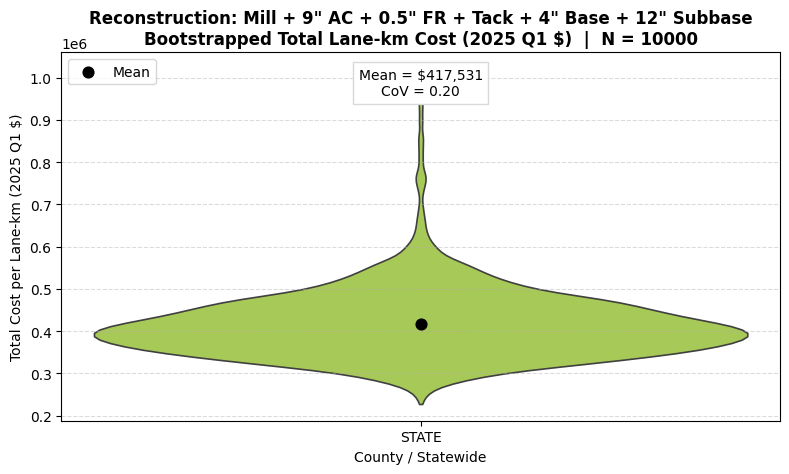

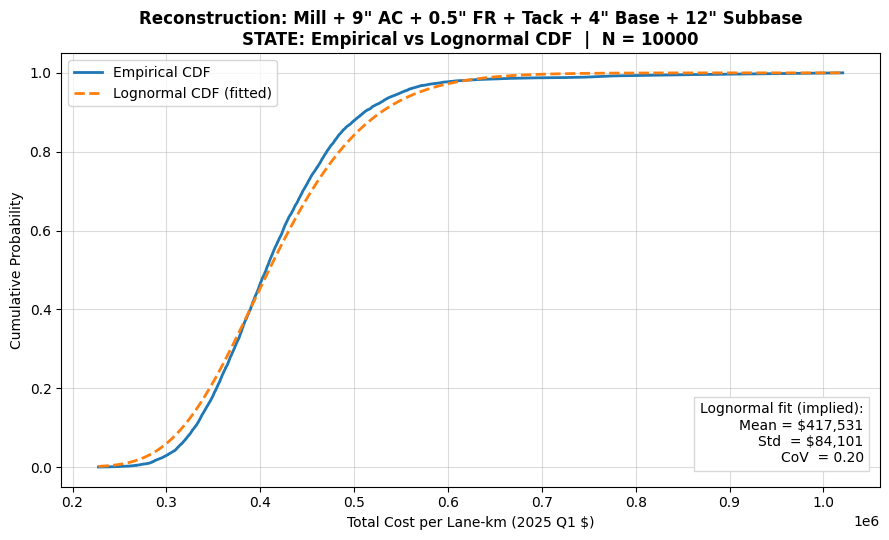

In [37]:
# ===============================================================
# Cell 2 — Bootstrap (STATE) + STATE-only violin + STATE CDF
# Reconstruction:
#   Mill + 9" AC + 0.5" FR + Tack + 4" Base + 12" Subbase
#
# Style: matches the CDF presentation used in other treatment sections
#   - single STATE violin
#   - mean dot legend
#   - CDF legend upper-left + stats box bottom-right (no overlap)
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ---- Settings ----
N_BOOT_SAMPLES = 10000
RANDOM_SEED = GLOBAL_SEED
rng = np.random.default_rng(RANDOM_SEED)

# ---- Bootstrap: sample each component independently ----
mill_s    = rng.choice(mill_state_vals,     size=N_BOOT_SAMPLES, replace=True)
ac_s      = rng.choice(ac5_state_vals,      size=N_BOOT_SAMPLES, replace=True)
fr_s      = rng.choice(fr05_state_vals,     size=N_BOOT_SAMPLES, replace=True)
tack_s    = rng.choice(tack_state_vals,     size=N_BOOT_SAMPLES, replace=True)
base_s    = rng.choice(base4_state_vals,    size=N_BOOT_SAMPLES, replace=True)
subbase_s = rng.choice(subbase8_state_vals, size=N_BOOT_SAMPLES, replace=True)

total_s = mill_s + ac_s + fr_s + tack_s + base_s + subbase_s
boot_sum_dict = {"STATE": total_s}

# ---- Summary ----
mean_ = float(np.mean(total_s))
std_  = float(np.std(total_s, ddof=0))
cov_  = std_ / mean_ if mean_ != 0 else np.nan

print("BOOTSTRAP — RECONSTRUCTION (STATE)")
print("  Mill + 9\" AC + 0.5\" FR + Tack + 4\" Base + 12\" Subbase")
print(f"  N boot = {N_BOOT_SAMPLES}")
print(f"  Mean   = ${mean_:,.0f}")
print(f"  Std    = ${std_:,.0f}")
print(f"  CoV    = {cov_:.2f}")

# ===============================================================
# 1) STATE-only violin
# ===============================================================

STATE_COLOR = "#A7C957"   # same STATE green you’ve been using
EDGE_COLOR  = "0.25"

fig, ax = plt.subplots(figsize=(8, 5))

vp = ax.violinplot(
    [total_s],
    positions=[1],
    widths=0.65,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_facecolor(STATE_COLOR)
    body.set_edgecolor(EDGE_COLOR)
    body.set_alpha(1.0)
    body.set_linewidth(1.2)

ax.scatter([1], [mean_], s=60, c="k", label="Mean", zorder=3)

ax.set_xticks([1])
ax.set_xticklabels(["STATE"])
ax.set_xlabel("County / Statewide")
ax.set_ylabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_title(
    "Reconstruction: Mill + 9\" AC + 0.5\" FR + Tack + 4\" Base + 12\" Subbase\n"
    "Bootstrapped Total Lane-km Cost (2025 Q1 $)  |  N = 10000",
    fontweight="bold"
)

ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper left", frameon=True)

ax.text(
    1, ax.get_ylim()[1] * 0.965,
    f"Mean = ${mean_:,.0f}\nCoV = {cov_:.2f}",
    ha="center", va="top",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()

# ===============================================================
# 2) STATE CDF — Empirical vs Lognormal
# ===============================================================

sigma = np.sqrt(np.log(1 + cov_**2))
mu = np.log(mean_) - 0.5 * sigma**2

x = np.sort(total_s)
y = np.arange(1, len(x) + 1) / len(x)
cdf_fit = lognorm.cdf(x, s=sigma, scale=np.exp(mu))

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(x, y, linewidth=2, label="Empirical CDF")
ax.plot(x, cdf_fit, "--", linewidth=2, label="Lognormal CDF (fitted)")

ax.set_title(
    "Reconstruction: Mill + 9\" AC + 0.5\" FR + Tack + 4\" Base + 12\" Subbase\n"
    "STATE: Empirical vs Lognormal CDF  |  N = 10000",
    fontweight="bold"
)
ax.set_xlabel("Total Cost per Lane-km (2025 Q1 $)")
ax.set_ylabel("Cumulative Probability")
ax.grid(True, alpha=0.45)

# Legend upper-left, stats box bottom-right (no overlap)
ax.legend(loc="upper left", frameon=True)

ax.text(
    0.98, 0.05,
    "Lognormal fit (implied):\n"
    f"Mean = ${mean_:,.0f}\n"
    f"Std  = ${std_:,.0f}\n"
    f"CoV  = {cov_:.2f}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    bbox=dict(facecolor="white", edgecolor="0.85", alpha=1.0)
)

plt.tight_layout()
plt.show()


# Presentation

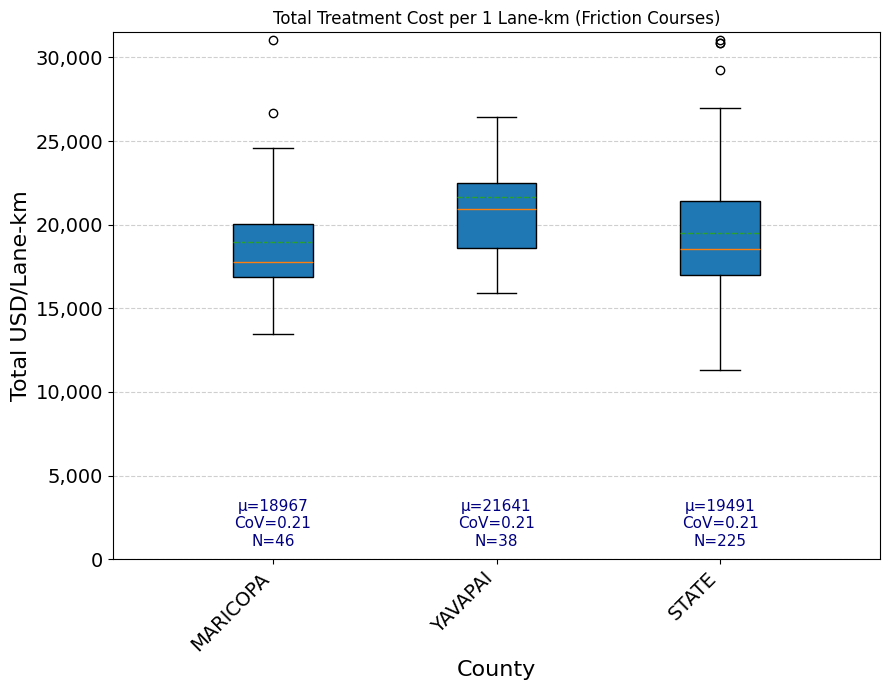

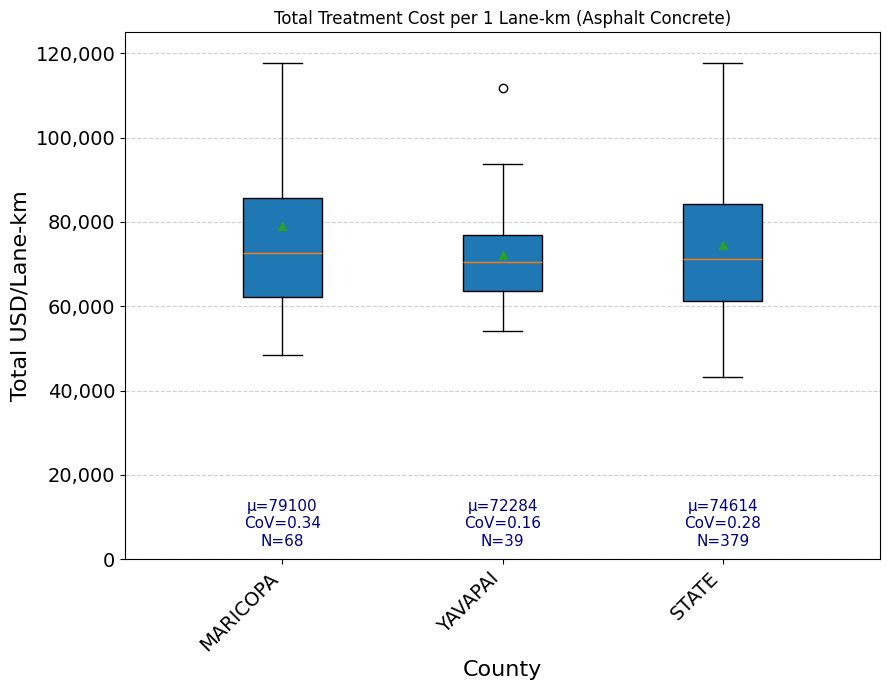

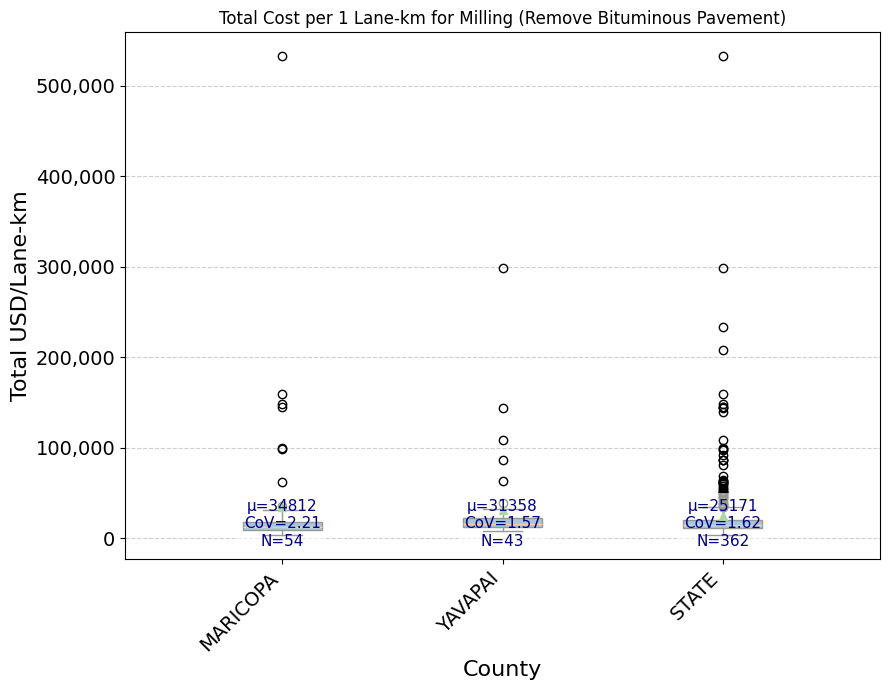

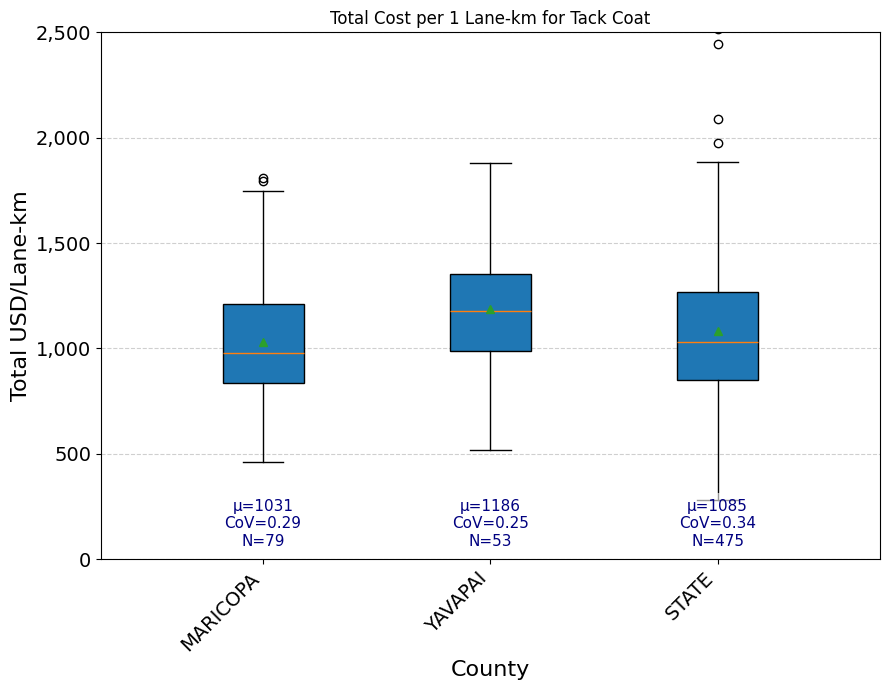

In [38]:
# FR and AC Lane-Mile Cost Calculation, Boxplots, and Bootstrap Sample Summary
# — now with Section 4: Tack Coat
# ✅ Updated Section 3: Milling uses MERGED milling group (all milling pay items)
# ✅ FIXED: annotations now align with box positions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# ---------------------------------------------------------------
# Common utilities
# ---------------------------------------------------------------
WANTED_COUNTIES = ["MARICOPA", "YAVAPAI", "STATE"]

def annot_boxplot(ax, box_data, positions=None, y_frac=0.02, valign="bottom"):
    """
    Annotate a boxplot with mean, CoV, N (for each box).
    FIX: uses the actual x positions used in ax.boxplot().
    """
    y0, y1 = ax.get_ylim()
    yr = y1 - y0

    if positions is None:
        positions = np.arange(1, len(box_data) + 1)

    for x, vals in zip(positions, box_data):
        arr = np.asarray(vals, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            continue

        mean = arr.mean()
        std = arr.std(ddof=0)
        cov = std / mean if mean != 0 else np.nan
        n = len(arr)

        text = f"μ={mean:.0f}\nCoV={cov:.2f}\nN={n}"

        if valign == "top":
            y_text = y1 - yr * y_frac
            va = "top"
        else:
            y_text = y0 + yr * y_frac
            va = "bottom"

        ax.text(
            x, y_text, text,
            ha="center", va=va, fontsize=11, color="navy",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

# ---------------------------------------------------------------
# One-time standardization (DO NOT overwrite PayItemID)
# ---------------------------------------------------------------
df = df.copy()
df["PayItemID_str"] = (
    df["PayItemID"].astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.strip()
)
df["Quantity_num"] = pd.to_numeric(df.get("Quantity", np.nan), errors="coerce")
df["UnitPrice_Real_2025Q1_num"] = pd.to_numeric(df.get("UnitPrice_Real_2025Q1", np.nan), errors="coerce")
df["County"] = df["County"].astype(str)

# ---------------------------------------------------------------
# Section 1: Fiber-Reinforced (FR) Project Processing
# ---------------------------------------------------------------
FR_PAYITEM_IDS = {
    "binder": "4140042",
    "mix": "4140040",
    "mineral_admix": "4140044",
}
required_fr = [FR_PAYITEM_IDS["binder"], FR_PAYITEM_IDS["mix"], FR_PAYITEM_IDS["mineral_admix"]]

fr_jobs = (
    df[df["PayItemID_str"].isin(required_fr)]
    .groupby("JobID")["PayItemID_str"]
    .nunique()
)
eligible_fr_jobs = fr_jobs[fr_jobs == 3].index

df_fr = df[df["JobID"].isin(eligible_fr_jobs) & df["PayItemID_str"].isin(required_fr)].copy()

pivot_cols = ["Quantity_num", "UnitPrice_Real_2025Q1_num"]
fr_pivot = df_fr.pivot_table(
    index=["JobID", "County"],
    columns="PayItemID_str",
    values=pivot_cols,
    aggfunc="first"
)
fr_pivot.columns = [f"{col}_{pid}" for col, pid in fr_pivot.columns]
fr_pivot = fr_pivot.reset_index()

fr_pivot.rename(columns={
    f"Quantity_num_{FR_PAYITEM_IDS['mix']}": "Mix_Ton",
    f"Quantity_num_{FR_PAYITEM_IDS['binder']}": "Binder_Ton",
    f"Quantity_num_{FR_PAYITEM_IDS['mineral_admix']}": "MinAdmix_Ton",
    f"UnitPrice_Real_2025Q1_num_{FR_PAYITEM_IDS['mix']}": "Mix_UnitPrice",
    f"UnitPrice_Real_2025Q1_num_{FR_PAYITEM_IDS['binder']}": "Binder_UnitPrice",
    f"UnitPrice_Real_2025Q1_num_{FR_PAYITEM_IDS['mineral_admix']}": "MinAdmix_UnitPrice",
}, inplace=True)

# Lane-mile conversion for FR (0.5 in thickness)
LANE_WIDTH_FT = 12
PAVE_THICKNESS_IN = 0.5
DENSITY_MIX_LB_FT3 = 125.0
FT_PER_LANE_MILE = LANE_WIDTH_FT * 5280
VOL_PER_LANE_MILE_FT3 = FT_PER_LANE_MILE * (PAVE_THICKNESS_IN / 12.0)
TONS_PER_LANE_MILE_FR = VOL_PER_LANE_MILE_FT3 * DENSITY_MIX_LB_FT3 / 2000.0

fr_pivot["Actual_Binder_Frac"] = fr_pivot["Binder_Ton"] / fr_pivot["Mix_Ton"]
fr_pivot["Agg_Tons_Per_LaneMile"] = TONS_PER_LANE_MILE_FR - (fr_pivot["Actual_Binder_Frac"] * TONS_PER_LANE_MILE_FR)
fr_pivot["MinAdmix_Tons_Per_LaneMile"] = fr_pivot["Agg_Tons_Per_LaneMile"] * (1 / 101)

fr_pivot["Mix_Cost_Per_LaneMile"] = fr_pivot["Mix_UnitPrice"] * TONS_PER_LANE_MILE_FR
fr_pivot["Binder_Cost_Per_LaneMile"] = fr_pivot["Binder_UnitPrice"] * (fr_pivot["Actual_Binder_Frac"] * TONS_PER_LANE_MILE_FR)
fr_pivot["MinAdmix_Cost_Per_LaneMile"] = fr_pivot["MinAdmix_UnitPrice"] * fr_pivot["MinAdmix_Tons_Per_LaneMile"]

fr_pivot["Total_Cost_LaneMile"] = (
    fr_pivot["Mix_Cost_Per_LaneMile"] +
    fr_pivot["Binder_Cost_Per_LaneMile"] +
    fr_pivot["MinAdmix_Cost_Per_LaneMile"]
) * MILE_TO_KM

# Boxplot FR (only selected counties)
fr_state = fr_pivot.copy()
fr_state["County"] = "STATE"
fr_for_box = pd.concat([fr_pivot, fr_state], ignore_index=True)
fr_for_box = fr_for_box[fr_for_box["County"].isin(WANTED_COUNTIES)]

plot_counties_fr = WANTED_COUNTIES
fr_box_data = [
    fr_for_box.loc[fr_for_box["County"] == county, "Total_Cost_LaneMile"].dropna().values
    for county in plot_counties_fr
]

positions_fr = np.arange(1, len(plot_counties_fr) + 1) * 0.7

fig, ax = plt.subplots(figsize=(9, 7))
ax.boxplot(
    fr_box_data,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    positions=positions_fr,
    widths=0.25
)
ax.set(
    title="Total Treatment Cost per 1 Lane-km (Friction Courses)",
    xlabel="County",
    ylabel="Total USD/Lane-km"
)
ax.set_ylim([0, 31500])
ax.set_xticks(positions_fr)
ax.set_xticklabels(plot_counties_fr, rotation=45, ha="right", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylabel("Total USD/Lane-km", fontsize=16)
ax.set_xlabel("County", fontsize=16)
# Add thousands separator to y axis
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# ✅ FIXED: align annotations with positions_fr
annot_boxplot(ax, fr_box_data, positions=positions_fr, y_frac=0.02, valign="bottom")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Section 2: Asphalt Concrete (AC) Project Processing
# ---------------------------------------------------------------
AC_BINDER_LABELS = [
    "4040256 — ASPHALT BINDER (PG 58-28)", "4040262 — ASPHALT BINDER (PG 64-16)",
    "4040264 — ASPHALT BINDER (PG 64-22)", "4040266 — ASPHALT BINDER (PG 64-28)",
    "4040270 — ASPHALT BINDER (PG 70-10)", "4040274 — ASPHALT BINDER (PG 70-22)",
    "4040282 — ASPHALT BINDER (PG 76-16)", "4040284 — ASPHALT BINDER (PG 76-22)",
    "4040286 — ASPHALT BINDER (PG 64-28 TR+)", "4040288 — ASPHALT BINDER (PG 70-22 TR+)",
    "4040290 — ASPHALT BINDER (PG 76-22 TR+)", "4040230 — ASPHALT BINDER (PG 76-22 TR+)"
]
AC_MIX_LABELS = [
    "4060006 — Asphaltic concrete (3/4\" mix)", "4160001 — Asphaltic concrete (1/2\" mix) (end product)",
    "4160002 — Asphaltic concrete (3/4\" mix) (end product)", "4160003 — Asphaltic concrete (1/2\" mix) (end product) (special mix)",
    "4160004 — Asphaltic concrete (3/4\" mix) (end product) (special mix)", "4160009 — Asphaltic concrete (end product) (with PG 76-22 TR+)",
]
AC_MINERAL_ADMIX_LABELS = [
    "4160031 — Mineral admixture", "4170031 — Mineral admixture",
    "4060026 — Mineral admixture (for 3/4\" mix)", "4040425 — Mineral admixture"
]

def get_payitem_id(label: str) -> str:
    return label.split("—")[0].strip()

ac_binder_ids = set(get_payitem_id(lbl) for lbl in AC_BINDER_LABELS)
ac_mix_ids = set(get_payitem_id(lbl) for lbl in AC_MIX_LABELS)
ac_ma_ids = set(get_payitem_id(lbl) for lbl in AC_MINERAL_ADMIX_LABELS)

# Lane-mile inputs for AC (0.5 in thickness)
AC_UNIT_WEIGHT_PCF = 145.0
AC_LANE_WIDTH_FT = 12.0
AC_THICKNESS_IN = 2.5
AC_ASPHALT_FRAC = 0.05
AC_ADMIX_AGG_FRAC = 0.01

ac_vol_ft3 = AC_LANE_WIDTH_FT * 5280.0 * (AC_THICKNESS_IN / 12.0)
ac_mix_tons_per_lane_mile = ac_vol_ft3 * AC_UNIT_WEIGHT_PCF / 2000.0
ac_binder_tons_per_lane_mile = AC_ASPHALT_FRAC * ac_mix_tons_per_lane_mile
ac_agg_tons_per_lane_mile = ac_mix_tons_per_lane_mile - ac_binder_tons_per_lane_mile
ac_admix_tons_per_lane_mile = AC_ADMIX_AGG_FRAC * ac_agg_tons_per_lane_mile

def jobids_with_any(ids):
    return set(df.loc[df["PayItemID_str"].isin(ids), "JobID"].unique())

ac_jobids = jobids_with_any(ac_binder_ids) & jobids_with_any(ac_mix_ids) & jobids_with_any(ac_ma_ids)

ac_records = []
for jobid in ac_jobids:
    job_rows = df[df["JobID"] == jobid]
    mix_p = job_rows[job_rows["PayItemID_str"].isin(ac_mix_ids)]["UnitPrice_Real_2025Q1_num"].median()
    binder_p = job_rows[job_rows["PayItemID_str"].isin(ac_binder_ids)]["UnitPrice_Real_2025Q1_num"].median()
    ma_p = job_rows[job_rows["PayItemID_str"].isin(ac_ma_ids)]["UnitPrice_Real_2025Q1_num"].median()
    county = job_rows["County"].iloc[0] if len(job_rows) else None

    if not (np.isnan(mix_p) or np.isnan(binder_p) or np.isnan(ma_p)):
        total_lane_mile_cost = (
            mix_p * ac_mix_tons_per_lane_mile +
            binder_p * ac_binder_tons_per_lane_mile +
            ma_p * ac_admix_tons_per_lane_mile
        )
        ac_records.append({"JobID": jobid, "County": str(county), "Total_Cost_LaneMile": total_lane_mile_cost})

ac_df = pd.DataFrame(ac_records)
ac_df["Total_Cost_LaneMile"] = ac_df["Total_Cost_LaneMile"] * MILE_TO_KM
ac_df_state = ac_df.copy()
ac_df_state["County"] = "STATE"
ac_combined_df = pd.concat([ac_df, ac_df_state], ignore_index=True)
ac_combined_df = ac_combined_df[ac_combined_df["County"].isin(WANTED_COUNTIES)]

ac_plot_labels = WANTED_COUNTIES
ac_box_data = [
    ac_combined_df.loc[ac_combined_df["County"] == co, "Total_Cost_LaneMile"].dropna().values
    for co in ac_plot_labels
]

positions_ac = np.arange(1, len(ac_plot_labels) + 1) * 0.7
fig, ax = plt.subplots(figsize=(9, 7))
ax.boxplot(
    ac_box_data,
    patch_artist=True,
    showmeans=True,
    positions=positions_ac,
    widths=0.25
)
ax.set(
    title="Total Treatment Cost per 1 Lane-km (Asphalt Concrete)",
    xlabel="County",
    ylabel="Total USD/Lane-km"
)
ax.set_ylim([0, 125000])
ax.set_xticks(positions_ac)
ax.set_xticklabels(ac_plot_labels, rotation=45, ha="right", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylabel("Total USD/Lane-km", fontsize=16)
ax.set_xlabel("County", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# ✅ FIXED: align annotations with positions_ac
annot_boxplot(ax, ac_box_data, positions=positions_ac, y_frac=0.02, valign="bottom")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Section 3: Milling (MERGED GROUP) Lane-Mile Cost  ✅ UPDATED
# ---------------------------------------------------------------
MILLING_LABELS = [
    "2020081 – Remove bituminous pavement (milling) (1\")",
    "2020082 – Remove bituminous pavement (milling) (1-1/2\")",
    "2020084 – Remove bituminous pavement (milling) (2-1/2\")",
    "2020085 – Remove bituminous pavement (milling) (3\")",
    "2020086 – Remove bituminous pavement (milling) (3-1/2\")",
    "2020088 – Remove bituminous pavement (milling) (4-1/2\" to 6\")",
]
MILLING_IDS = [lbl.split("–")[0].strip().split()[0] for lbl in MILLING_LABELS]

# Lane-mile area in square yards
LANE_WIDTH_FT = 12
LANE_LENGTH_FT = 5280
LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0

mill_rows = df[df["PayItemID_str"].isin(MILLING_IDS)].copy()
mill_rows = mill_rows.dropna(subset=["UnitPrice_Real_2025Q1_num", "JobID", "County"])

mill_job_price = (
    mill_rows.groupby(["JobID", "County"], as_index=False)
    .agg(Milling_UnitPrice=("UnitPrice_Real_2025Q1_num", "median"))
)

mill_job_price["Milling_Cost_Per_LaneMile"] = mill_job_price["Milling_UnitPrice"] * LANE_AREA_SQYD * MILE_TO_KM

mill_state = mill_job_price.copy()
mill_state["County"] = "STATE"
mill_for_box = pd.concat([mill_job_price, mill_state], ignore_index=True)
mill_for_box = mill_for_box[mill_for_box["County"].isin(WANTED_COUNTIES)]

plot_counties_mill = WANTED_COUNTIES
mill_box_data = [
    mill_for_box.loc[mill_for_box["County"] == c, "Milling_Cost_Per_LaneMile"].dropna().values
    for c in plot_counties_mill
]

positions_mill = np.arange(1, len(plot_counties_mill) + 1) * 0.7
fig, ax = plt.subplots(figsize=(9, 7))
ax.boxplot(
    mill_box_data,
    patch_artist=True,
    showmeans=True,
    positions=positions_mill,
    widths=0.25
)
ax.set(
    title="Total Cost per 1 Lane-km for Milling (Remove Bituminous Pavement)",
    xlabel="County",
    ylabel="Total USD/Lane-km"
)
ax.set_xticks(positions_mill)
ax.set_xticklabels(plot_counties_mill, rotation=45, ha="right", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylabel("Total USD/Lane-km", fontsize=16)
ax.set_xlabel("County", fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# ✅ FIXED: align annotations with positions_mill
annot_boxplot(ax, mill_box_data, positions=positions_mill, y_frac=0.02, valign="bottom")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Section 4: Tack Coat (BITUMINOUS TACK COAT) Lane-Mile Cost
# ---------------------------------------------------------------
TACK_PAYITEM_ID = "4040111"

tack_rows = df[df["PayItemID_str"] == TACK_PAYITEM_ID].copy()
tack_rows = tack_rows.dropna(subset=["UnitPrice_Real_2025Q1_num", "JobID", "County"])

# Constants for conversion:
TACK_APP_RATE_GAL_PER_SQYD = 0.07
TACK_UNIT_WEIGHT_LB_PER_GAL = 8.33
LB_PER_TON = 2000

LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0
tack_total_gallons = TACK_APP_RATE_GAL_PER_SQYD * LANE_AREA_SQYD
tack_total_lbs = tack_total_gallons * TACK_UNIT_WEIGHT_LB_PER_GAL
tack_tons_per_lane_mile = tack_total_lbs / LB_PER_TON

tack_grouped = (
    tack_rows.groupby(["JobID", "County"], as_index=False)
    .agg(Tack_UnitPrice=("UnitPrice_Real_2025Q1_num", "median"))
)
tack_grouped["Tack_Cost_Per_LaneMile"] = tack_grouped["Tack_UnitPrice"] * tack_tons_per_lane_mile * MILE_TO_KM

tack_state = tack_grouped.copy()
tack_state["County"] = "STATE"
tack_for_box = pd.concat([tack_grouped, tack_state], ignore_index=True)
tack_for_box = tack_for_box[tack_for_box["County"].isin(WANTED_COUNTIES)]

plot_counties_tack = WANTED_COUNTIES
tack_box_data = [
    tack_for_box.loc[tack_for_box["County"] == c, "Tack_Cost_Per_LaneMile"].dropna().values
    for c in plot_counties_tack
]

positions_tack = np.arange(1, len(plot_counties_tack) + 1) * 0.7
fig, ax = plt.subplots(figsize=(9, 7))
ax.boxplot(
    tack_box_data,
    patch_artist=True,
    showmeans=True,
    positions=positions_tack,
    widths=0.25
)
ax.set(
    title="Total Cost per 1 Lane-km for Tack Coat",
    xlabel="County",
    ylabel="Total USD/Lane-km"
)
ax.set_xticks(positions_tack)
ax.set_xticklabels(plot_counties_tack, rotation=45, ha="right", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylabel("Total USD/Lane-km", fontsize=16)
ax.set_xlabel("County", fontsize=16)
ax.set_ylim([0, 2500])
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# ✅ FIXED: align annotations with positions_tack
annot_boxplot(ax, tack_box_data, positions=positions_tack, y_frac=0.02, valign="bottom")

plt.tight_layout()
plt.show()


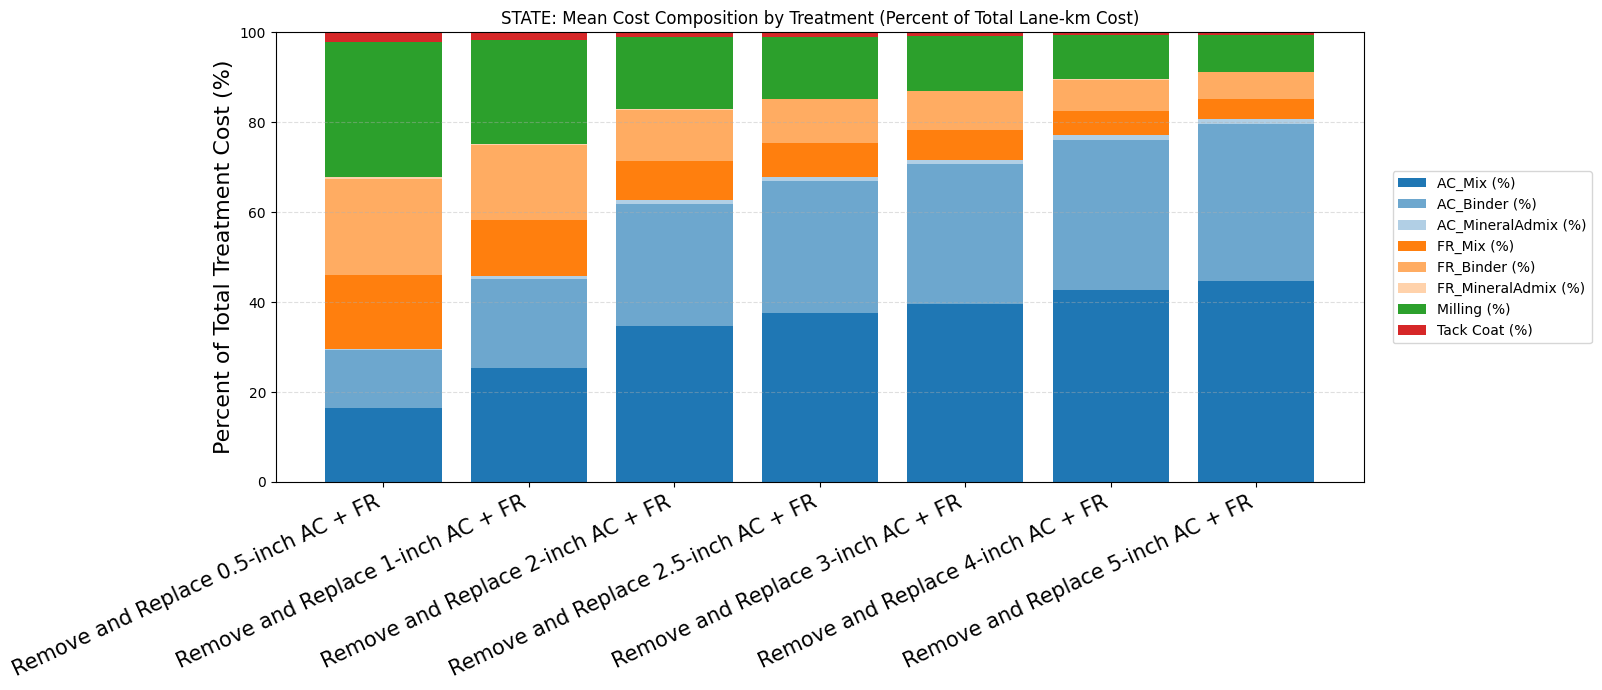

---- $/Lane-km (STATE representative) ----


,Treatment,AC_Mix,AC_Binder,AC_MineralAdmix,FR_Mix,FR_Binder,FR_MineralAdmix,Milling,Tack Coat,Total
0,Remove and Replace 0.5-inch AC + FR,8004.580167,6276.818361,197.922715,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,48825.149665
1,Remove and Replace 1-inch AC + FR,16009.160335,12553.636722,395.845429,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,63304.470908
2,Remove and Replace 2-inch AC + FR,32018.320670,25107.273444,791.690859,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,92263.113394
3,Remove and Replace 2.5-inch AC + FR,40022.900837,31384.091805,989.613574,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,106742.434637
4,Remove and Replace 3-inch AC + FR,48027.481005,37660.910165,1187.536288,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,121221.755880
5,Remove and Replace 4-inch AC + FR,64036.641339,50214.546887,1583.381718,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,150180.398366
6,Remove and Replace 5-inch AC + FR,80045.801674,62768.183609,1979.227147,7982.363973,10450.224444,167.794997,14713.083071,1032.361936,179139.040852


---- Percent of Total ----


,Treatment,AC_Mix,AC_Binder,AC_MineralAdmix,FR_Mix,FR_Binder,FR_MineralAdmix,Milling,Tack Coat
0,Remove and Replace 0.5-inch AC + FR,16.394379,12.855707,0.405370,16.348878,21.403364,0.343665,30.134230,2.114406
1,Remove and Replace 1-inch AC + FR,25.289146,19.830569,0.625304,12.609479,16.507877,0.265060,23.241776,1.630788
2,Remove and Replace 2-inch AC + FR,34.703274,27.212688,0.858079,8.651739,11.326547,0.181866,15.946875,1.118932
3,Remove and Replace 2.5-inch AC + FR,37.494836,29.401701,0.927104,7.478154,9.790131,0.157196,13.783724,0.967152
4,Remove and Replace 3-inch AC + FR,39.619523,31.067781,0.979640,6.584927,8.620750,0.138420,12.137329,0.851631
5,Remove and Replace 4-inch AC + FR,42.639813,33.436152,1.054320,5.315184,6.958448,0.111729,9.796940,0.687415
6,Remove and Replace 5-inch AC + FR,44.683616,35.038807,1.104855,4.455960,5.833583,0.093667,8.213220,0.576291


In [39]:
# ===============================================================
# EXTENSION: Detailed component-level % composition by treatment
# with CONSISTENT COLOR FAMILIES:
#   - AC components = BLUE shades (dark -> light)
#   - FR components = ORANGE shades (dark -> light)
#   - Milling = GREEN, Tack = RED
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# -----------------------------
# Safety: ensure standardized columns exist (won't hurt if already created)
# -----------------------------
df = df.copy()
if "PayItemID_str" not in df.columns:
    df["PayItemID_str"] = (
        df["PayItemID"].astype(str).str.extract(r"(\d+)", expand=False).str.strip()
    )
if "UnitPrice_Real_2025Q1_num" not in df.columns:
    df["UnitPrice_Real_2025Q1_num"] = pd.to_numeric(df.get("UnitPrice_Real_2025Q1", np.nan), errors="coerce")
if "Quantity_num" not in df.columns:
    df["Quantity_num"] = pd.to_numeric(df.get("Quantity", np.nan), errors="coerce")
df["County"] = df["County"].astype(str)

# -----------------------------
# Helpers
# -----------------------------
LANE_WIDTH_FT = 12.0
LANE_LENGTH_FT = 5280.0
LANE_AREA_SQYD = (LANE_WIDTH_FT * LANE_LENGTH_FT) / 9.0

def lane_mile_tons_from_thickness(thickness_in, density_pcf):
    """Convert thickness (in) + density (lb/ft3) -> tons per lane-mile."""
    vol_ft3 = LANE_WIDTH_FT * LANE_LENGTH_FT * (thickness_in / 12.0)
    tons = vol_ft3 * density_pcf / 2000.0
    return tons

def job_median_prices(df_in, ids_set):
    """Returns Series indexed by JobID with job-median unit price for any rows in ids_set."""
    tmp = df_in[df_in["PayItemID_str"].isin(ids_set)].copy()
    tmp = tmp.dropna(subset=["JobID", "UnitPrice_Real_2025Q1_num"])
    if tmp.empty:
        return pd.Series(dtype=float)
    return tmp.groupby("JobID")["UnitPrice_Real_2025Q1_num"].median()

def robust_state_price(job_medians):
    """Robust single 'STATE' price: median of job-median unit prices."""
    if job_medians is None or len(job_medians) == 0:
        return np.nan
    return float(np.nanmedian(job_medians.values))

# ===============================================================
# 1) Define PayItem IDs for each component you want to split
# ===============================================================

# --- FR (you already used these)
FR_PAYITEM_IDS = {
    "FR_Binder": "4140042",
    "FR_Mix": "4140040",
    "FR_MineralAdmix": "4140044",
}
fr_binder_ids = {FR_PAYITEM_IDS["FR_Binder"]}
fr_mix_ids    = {FR_PAYITEM_IDS["FR_Mix"]}
fr_ma_ids     = {FR_PAYITEM_IDS["FR_MineralAdmix"]}

# --- AC (uses label lists defined earlier in this notebook)
def get_payitem_id(label: str) -> str:
    return label.split("—")[0].strip()

ac_binder_ids = set(get_payitem_id(lbl) for lbl in AC_BINDER_LABELS)
ac_mix_ids    = set(get_payitem_id(lbl) for lbl in AC_MIX_LABELS)
ac_ma_ids     = set(get_payitem_id(lbl) for lbl in AC_MINERAL_ADMIX_LABELS)

# --- Milling (merged group)
MILLING_IDS = [lbl.split("–")[0].strip().split()[0] for lbl in MILLING_LABELS]

# --- Tack
TACK_PAYITEM_ID = "4040111"

# ===============================================================
# 2) Get STATE-representative unit prices for each component
# ===============================================================

ac_mix_state_price    = robust_state_price(job_median_prices(df, ac_mix_ids))
ac_binder_state_price = robust_state_price(job_median_prices(df, ac_binder_ids))
ac_ma_state_price     = robust_state_price(job_median_prices(df, ac_ma_ids))

fr_mix_state_price    = robust_state_price(job_median_prices(df, fr_mix_ids))
fr_binder_state_price = robust_state_price(job_median_prices(df, fr_binder_ids))
fr_ma_state_price     = robust_state_price(job_median_prices(df, fr_ma_ids))

mill_state_price_per_syd = robust_state_price(job_median_prices(df, set(MILLING_IDS)))
tack_state_price_per_ton = robust_state_price(job_median_prices(df, {TACK_PAYITEM_ID}))

# ===============================================================
# 3) Convert each component to $/lane-mile for any treatment definition
# ===============================================================

# ---- AC conversion assumptions (same as the AC sections above)
AC_UNIT_WEIGHT_PCF = 145.0
AC_ASPHALT_FRAC = 0.05         # binder fraction of total mix tons
AC_ADMIX_AGG_FRAC = 0.01       # mineral admixture fraction of aggregate tons

def ac_component_costs_per_lane_mile(ac_thickness_in):
    mix_tons = lane_mile_tons_from_thickness(ac_thickness_in, AC_UNIT_WEIGHT_PCF)
    binder_tons = AC_ASPHALT_FRAC * mix_tons
    agg_tons = mix_tons - binder_tons
    ma_tons = AC_ADMIX_AGG_FRAC * agg_tons
    return {
        "AC_Mix": (ac_mix_state_price * mix_tons),
        "AC_Binder": (ac_binder_state_price * binder_tons),
        "AC_MineralAdmix": (ac_ma_state_price * ma_tons),
    }

# ---- FR conversion assumptions (same logic as the FR sections above)
FR_DENSITY_PCF = 125.0

def fr_component_costs_per_lane_mile(fr_thickness_in):
    mix_tons = lane_mile_tons_from_thickness(fr_thickness_in, FR_DENSITY_PCF)

    fr_rows = df[df["PayItemID_str"].isin([FR_PAYITEM_IDS["FR_Mix"], FR_PAYITEM_IDS["FR_Binder"]])].copy()
    fr_rows = fr_rows.dropna(subset=["JobID", "Quantity_num"])
    fr_ratio = np.nan
    if not fr_rows.empty:
        piv = fr_rows.pivot_table(index="JobID", columns="PayItemID_str", values="Quantity_num", aggfunc="first")
        if (FR_PAYITEM_IDS["FR_Mix"] in piv.columns) and (FR_PAYITEM_IDS["FR_Binder"] in piv.columns):
            ratios = (piv[FR_PAYITEM_IDS["FR_Binder"]] / piv[FR_PAYITEM_IDS["FR_Mix"]]).replace([np.inf, -np.inf], np.nan).dropna()
            if len(ratios) > 0:
                fr_ratio = float(np.nanmedian(ratios.values))
    if np.isnan(fr_ratio):
        fr_ratio = 0.05  # fallback

    binder_tons = fr_ratio * mix_tons
    agg_tons = mix_tons - binder_tons
    ma_tons = agg_tons * (1 / 101)

    return {
        "FR_Mix": (fr_mix_state_price * mix_tons),
        "FR_Binder": (fr_binder_state_price * binder_tons),
        "FR_MineralAdmix": (fr_ma_state_price * ma_tons),
    }

# ---- Milling cost per lane-mile
def milling_cost_per_lane_mile():
    if np.isnan(mill_state_price_per_syd):
        return np.nan
    return mill_state_price_per_syd * LANE_AREA_SQYD

# ---- Tack cost per lane-mile
TACK_APP_RATE_GAL_PER_SQYD = 0.07
TACK_UNIT_WEIGHT_LB_PER_GAL = 8.33
LB_PER_TON = 2000.0

def tack_cost_per_lane_mile():
    if np.isnan(tack_state_price_per_ton):
        return np.nan
    tack_total_gal = TACK_APP_RATE_GAL_PER_SQYD * LANE_AREA_SQYD
    tack_total_lb = tack_total_gal * TACK_UNIT_WEIGHT_LB_PER_GAL
    tack_tons = tack_total_lb / LB_PER_TON
    return tack_state_price_per_ton * tack_tons

# ===============================================================
# 4) Define treatments (recipes)
# ===============================================================

AC_THICKNESSES = [0.5, 1, 2, 2.5, 3, 4, 5]
FR_THICKNESS = 0.5

treatment_rows = []
for t_ac in AC_THICKNESSES:
    comp = {}
    comp.update(ac_component_costs_per_lane_mile(t_ac))
    comp.update(fr_component_costs_per_lane_mile(FR_THICKNESS))
    comp["Milling"] = milling_cost_per_lane_mile()
    comp["Tack Coat"] = tack_cost_per_lane_mile()
    treatment_rows.append({
        "Treatment": f"Remove and Replace {t_ac}-inch AC + FR",
        **comp
    })

treat_df = pd.DataFrame(treatment_rows).fillna(0.0)
_component_cols_si = [c for c in treat_df.columns if c != "Treatment"]
treat_df[_component_cols_si] = treat_df[_component_cols_si] * MILE_TO_KM  # $/lane-mile -> $/lane-km

# ===============================================================
# 5) Convert $/lane-mile to % of total, then plot stacked bars
# ===============================================================

component_cols = [c for c in treat_df.columns if c != "Treatment"]
treat_df["Total"] = treat_df[component_cols].sum(axis=1)

pct_df = treat_df.copy()
for c in component_cols:
    pct_df[c] = np.where(pct_df["Total"] > 0, 100.0 * pct_df[c] / pct_df["Total"], 0.0)

stack_order = [
    "AC_Mix", "AC_Binder", "AC_MineralAdmix",
    "FR_Mix", "FR_Binder", "FR_MineralAdmix",
    "Milling", "Tack Coat",
    "ChipSeal_Cover", "ChipSeal_Bituminous",
    "Micro_Aggregate", "Micro_Emulsion",
    "CrackSeal", "FogCoat",
]
stack_order = [c for c in stack_order if c in pct_df.columns]

# ===============================================================
# 6) CONSISTENT COLOR MAP (AC blues, FR oranges)
# ===============================================================

def lighten(rgb, amt):
    """Blend color toward white by amt in [0,1]. 0=no change, 1=white."""
    r, g, b = rgb
    return (r + (1 - r) * amt, g + (1 - g) * amt, b + (1 - b) * amt)

# Base palette anchors (matplotlib tab10 first colors)
BASE_BLUE   = to_rgb("tab:blue")
BASE_ORANGE = to_rgb("tab:orange")
BASE_GREEN  = to_rgb("tab:green")
BASE_RED    = to_rgb("tab:red")
BASE_PURPLE = to_rgb("tab:purple")
BASE_BROWN  = to_rgb("tab:brown")
BASE_PINK   = to_rgb("tab:pink")
BASE_GRAY   = to_rgb("tab:gray")

color_map = {
    # AC (all blue shades)
    "AC_Mix":          lighten(BASE_BLUE,   0.00),  # darkest
    "AC_Binder":       lighten(BASE_BLUE,   0.35),
    "AC_MineralAdmix": lighten(BASE_BLUE,   0.65),  # lightest

    # FR (all orange shades)
    "FR_Mix":          lighten(BASE_ORANGE, 0.00),
    "FR_Binder":       lighten(BASE_ORANGE, 0.35),
    "FR_MineralAdmix": lighten(BASE_ORANGE, 0.65),

    # Others (consistent fixed colors)
    "Milling":   BASE_GREEN,
    "Tack Coat": BASE_RED,

    # If you later include these in other cells:
    "ChipSeal_Cover":      lighten(BASE_PURPLE, 0.45),
    "ChipSeal_Bituminous": BASE_PURPLE,

    "Micro_Aggregate": lighten(BASE_BROWN, 0.40),
    "Micro_Emulsion":  BASE_BROWN,

    "CrackSeal": BASE_GRAY,
    "FogCoat":   BASE_PINK,
}

# ===============================================================
# 7) Plot
# ===============================================================

x = np.arange(len(pct_df))
bottom = np.zeros(len(pct_df))

plt.figure(figsize=(16, 7))
for c in stack_order:
    plt.bar(
        x,
        pct_df[c].values,
        bottom=bottom,
        label=f"{c} (%)",
        color=color_map.get(c, None)  # fallback if new component appears
    )
    bottom += pct_df[c].values

plt.title("STATE: Mean Cost Composition by Treatment (Percent of Total Lane-km Cost)")
plt.ylabel("Percent of Total Treatment Cost (%)", fontsize = 16)
plt.xticks(x, pct_df["Treatment"], rotation=25, ha="right", fontsize = 15) 
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# ===============================================================
# 8) Optional table outputs
# ===============================================================
display_cols = ["Treatment"] + stack_order + ["Total"]
summary_table = treat_df[display_cols].copy()
summary_table_pct = pct_df[["Treatment"] + stack_order].copy()

print("---- $/Lane-km (STATE representative) ----")
display(summary_table)
print("---- Percent of Total ----")
display(summary_table_pct)

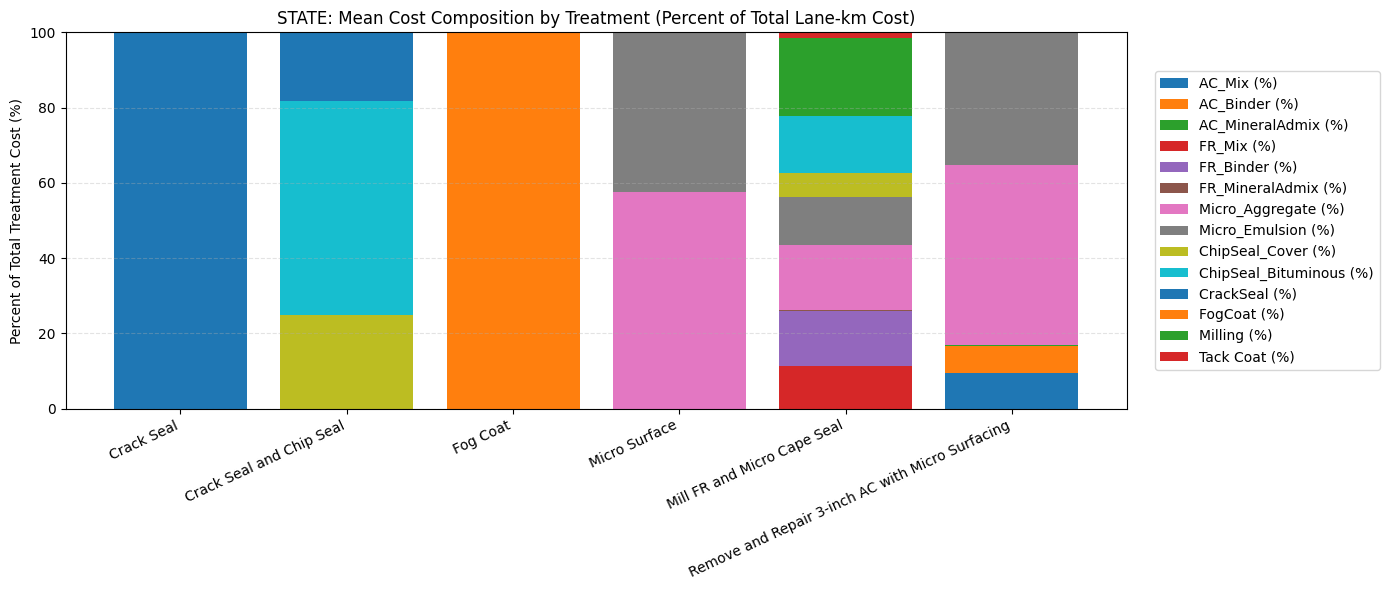

,Treatment,AC_Mix,AC_Binder,AC_MineralAdmix,FR_Mix,FR_Binder,FR_MineralAdmix,Micro_Aggregate,Micro_Emulsion,ChipSeal_Cover,ChipSeal_Bituminous,CrackSeal,FogCoat,Milling,Tack Coat
0,Crack Seal,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.0,0.00,0.00
1,Crack Seal and Chip Seal,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,24.91,56.85,18.24,0.0,0.00,0.00
2,Fog Coat,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.0,0.00,0.00
3,Micro Surface,0.00,0.00,0.00,0.00,0.00,0.00,57.59,42.41,0.00,0.00,0.00,0.0,0.00,0.00
4,Mill FR and Micro Cape Seal,0.00,0.00,0.00,11.26,14.75,0.24,17.22,12.68,6.60,15.05,0.00,0.0,20.76,1.46
5,Remove and Repair 3-inch AC with Micro Surfacing,9.41,7.38,0.23,0.00,0.00,0.00,47.79,35.20,0.00,0.00,0.00,0.0,0.00,0.00


In [40]:
# ===============================================================
# NEW CELL — 100% stacked composition for preservation treatments
# Treatments:
#  - Crack Seal
#  - Crack Seal and Chip Seal
#  - Fog Coat
#  - Mill FR and Micro Cape Seal
#  - Micro Surface
#  - Remove and Repair 3-inch AC with Micro Surfacing
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Sanity / standard columns
# -----------------------------
if "df" not in globals():
    raise ValueError("df not found. Run the merge/clean cell first.")

df2 = df.copy()

if "PayItemID_str" not in df2.columns:
    df2["PayItemID_str"] = df2["PayItemID"].astype(str).str.extract(r"(\d+)", expand=False).str.strip()

if "UnitPrice_Real_2025Q1_num" not in df2.columns:
    df2["UnitPrice_Real_2025Q1_num"] = pd.to_numeric(df2.get("UnitPrice_Real_2025Q1", np.nan), errors="coerce")

if "Quantity_num" not in df2.columns:
    df2["Quantity_num"] = pd.to_numeric(df2.get("Quantity", np.nan), errors="coerce")

df2["JobID"] = df2["JobID"].astype(str)

# -----------------------------
# 1) Pay item sets (defined in the individual treatment sections above)
# -----------------------------
# Chip Seal (same as the Chip Seal section above)
COVER_PAYITEMS = {"4040162", "4040159"}
CRS_PAYITEMS = {"4040073", "4040074"}
PG_BINDER_PAYITEMS = {"4040286", "4040288", "4040230"}
BITUMINOUS_PAYITEMS = CRS_PAYITEMS | PG_BINDER_PAYITEMS

# Crack Seal (same as the Crack Seal section above)
CRACK_SEAL_PAYITEM_ID = "9240116"
CRACK_OUTLIER_JOBIDS = {
    "2005104", "2024059", "2010097", "2007098", "2015129", "2010027",
    "2009024", "2008087", "2008080", "2009172", "2007094"
}
CRACK_LF_PER_LANE_MILE_TYP = 6500
LB_PER_LF_TYP = 0.30
LB_PER_LANE_MILE_TYP = CRACK_LF_PER_LANE_MILE_TYP * LB_PER_LF_TYP  # lb/LM

# Fog Coat (same as the Fog Coat section above)
FOG_COAT_PAYITEM_ID = "4040125"
APP_RATE_GAL_PER_SY = 0.08
DENSITY_LB_PER_GAL  = 8.5

# Microsurfacing (same as the Microsurfacing section above)
AGG_CODES  = {"4040170", "4040171", "4040172"}
EMUL_CODES = {"4040077", "4040076"}
MERGE_FROM = "4040171"
MERGE_TO   = "4040172"

AREA_SQ_YD = 7040
AGG_TON_PER_LM = 105.6  # 7040 SY * 0.015 ton/SY = 105.6 ton/LM (ADOT 2019 rate)

# -----------------------------
# 2) Helper: robust state unit price with optional JobID filtering
# -----------------------------
def robust_state_price_filtered(df_in, ids_set, drop_jobids=None):
    tmp = df_in.copy()
    if drop_jobids is not None:
        tmp = tmp[~tmp["JobID"].isin(set(drop_jobids))].copy()
    return robust_state_price(job_median_prices(tmp, set(ids_set)))

# -----------------------------
# 3) Component cost functions (match notebook logic)
# -----------------------------
def crackseal_cost_per_lane_mile():
    # pay item is $/lb (same as the Crack Seal section above)
    p = robust_state_price_filtered(df2, {CRACK_SEAL_PAYITEM_ID}, drop_jobids=CRACK_OUTLIER_JOBIDS)
    return float(p * LB_PER_LANE_MILE_TYP) if np.isfinite(p) else 0.0

def fogcoat_cost_per_lane_mile():
    # fog pay item is $/ton; convert gal/sy -> lb/sy -> ton/LM
    p = robust_state_price_filtered(df2, {FOG_COAT_PAYITEM_ID})
    lb_per_sy = APP_RATE_GAL_PER_SY * DENSITY_LB_PER_GAL
    ton_per_lm = (AREA_SQ_YD * lb_per_sy) / 2000.0
    return float(p * ton_per_lm) if np.isfinite(p) else 0.0

def chipseal_component_costs_per_lane_mile():
    # Chip Seal cover conversion:
    # cover: 0.01 ton/SY * 7040 SY/LM
    # binder: 0.45 gal/SY, 240 gal/ton
    cover_price = robust_state_price_filtered(df2, COVER_PAYITEMS)
    bitum_price = robust_state_price_filtered(df2, BITUMINOUS_PAYITEMS)

    COVER_APP_RATE = 0.01
    BINDER_APP_RATE = 0.45
    GAL_PER_TON = 240

    cover_ton_lm = AREA_SQ_YD * COVER_APP_RATE
    bitum_ton_lm = (AREA_SQ_YD * BINDER_APP_RATE) / GAL_PER_TON

    return {
        "ChipSeal_Cover": float(cover_price * cover_ton_lm) if np.isfinite(cover_price) else 0.0,
        "ChipSeal_Bituminous": float(bitum_price * bitum_ton_lm) if np.isfinite(bitum_price) else 0.0,
    }

def build_ms_cost_df_if_missing():
    """
    Rebuilds ms_cost_df using the same job-selection logic as the Microsurfacing section above:
      - aggregate quantities by JobID+PayItemID (sum qty, median unit price)
      - apply merge rule 4040171+4040172 -> keep 4040172 with summed qty
      - keep jobs with exactly one AGG and exactly one EMUL remaining
      - compute ratio r = AggQty / (AggQty + EmulQty)
    """
    tmp = df2[df2["PayItemID_str"].isin(AGG_CODES | EMUL_CODES)].copy()
    tmp = tmp.dropna(subset=["JobID", "PayItemID_str", "Quantity_num", "UnitPrice_Real_2025Q1_num"])
    if tmp.empty:
        return pd.DataFrame()

    g = (
        tmp.groupby(["JobID", "PayItemID_str"], as_index=False)
           .agg(Quantity=("Quantity_num", "sum"),
                UnitPrice=("UnitPrice_Real_2025Q1_num", "median"))
    )

    rows = []
    for job, gj in g.groupby("JobID"):
        gj = gj.copy()

        # merge rule: if BOTH 4040171 and 4040172 exist
        has_from = (gj["PayItemID_str"] == MERGE_FROM).any()
        has_to   = (gj["PayItemID_str"] == MERGE_TO).any()
        if has_from and has_to:
            q_from = float(gj.loc[gj["PayItemID_str"] == MERGE_FROM, "Quantity"].sum())
            q_to   = float(gj.loc[gj["PayItemID_str"] == MERGE_TO, "Quantity"].sum())
            # keep only MERGE_TO, add quantities
            gj = gj[gj["PayItemID_str"] != MERGE_FROM].copy()
            gj.loc[gj["PayItemID_str"] == MERGE_TO, "Quantity"] = q_from + q_to

        agg = gj[gj["PayItemID_str"].isin(AGG_CODES)].copy()
        emu = gj[gj["PayItemID_str"].isin(EMUL_CODES)].copy()

        if len(agg) != 1 or len(emu) != 1:
            continue

        agg_qty = float(agg["Quantity"].iloc[0])
        emu_qty = float(emu["Quantity"].iloc[0])
        denom = agg_qty + emu_qty
        if denom <= 0:
            continue

        r = agg_qty / denom
        rows.append({"JobID": job, "r": r})

    return pd.DataFrame(rows)

def microsurfacing_component_costs_per_lane_mile():
    # 1) Get r_state from ms_cost_df (preferred) or rebuild from df2
    if "ms_cost_df" in globals() and isinstance(ms_cost_df, pd.DataFrame) and ("Ratio_AGG_over_AGGplusEMUL" in ms_cost_df.columns):
        r_vals = ms_cost_df["Ratio_AGG_over_AGGplusEMUL"].astype(float).to_numpy()
        r_vals = r_vals[np.isfinite(r_vals)]
        r_state = float(np.nanmedian(r_vals)) if len(r_vals) else np.nan
    else:
        ms_r = build_ms_cost_df_if_missing()
        r_vals = ms_r["r"].astype(float).to_numpy() if not ms_r.empty else np.array([])
        r_vals = r_vals[np.isfinite(r_vals)]
        r_state = float(np.nanmedian(r_vals)) if len(r_vals) else np.nan

    if not np.isfinite(r_state) or r_state <= 0:
        # if still missing, return zeros to make the issue visible
        return {"Micro_Aggregate": 0.0, "Micro_Emulsion": 0.0}

    # 2) STATE unit prices for AGG + EMUL (robust medians)
    agg_price  = robust_state_price_filtered(df2, AGG_CODES)
    emul_price = robust_state_price_filtered(df2, EMUL_CODES)

    # 3) Use ADOT aggregate rate: AggTon_LM fixed, infer total mix and emulsion tonnage
    total_ton_lm = AGG_TON_PER_LM / r_state
    emul_ton_lm  = max(total_ton_lm - AGG_TON_PER_LM, 0.0)

    return {
        "Micro_Aggregate": float(agg_price * AGG_TON_PER_LM) if np.isfinite(agg_price) else 0.0,
        "Micro_Emulsion":  float(emul_price * emul_ton_lm)  if np.isfinite(emul_price) else 0.0,
    }

# -----------------------------
# 4) Build treatment table (ONLY requested treatments)
# -----------------------------
rows = []

# Crack Seal
rows.append({
    "Treatment": "Crack Seal",
    "CrackSeal": crackseal_cost_per_lane_mile()
})

# Crack Seal and Chip Seal (COVER + BITUMINOUS + CrackSeal)
r = {"Treatment": "Crack Seal and Chip Seal"}
r.update(chipseal_component_costs_per_lane_mile())
r["CrackSeal"] = crackseal_cost_per_lane_mile()
rows.append(r)

# Fog Coat
rows.append({
    "Treatment": "Fog Coat",
    "FogCoat": fogcoat_cost_per_lane_mile()
})

# Micro Surface
r = {"Treatment": "Micro Surface"}
r.update(microsurfacing_component_costs_per_lane_mile())
rows.append(r)

# Mill FR and Micro Cape Seal
# Treatment composition: Milling + Tack + FR(0.5") + Chip Seal + Microsurfacing
FR_THICKNESS_USED = 0.5  # 0.5-inch FR layer; change if a different thickness applies
r = {"Treatment": "Mill FR and Micro Cape Seal"}
r["Milling"] = milling_cost_per_lane_mile()
r["Tack Coat"] = tack_cost_per_lane_mile()
r.update(fr_component_costs_per_lane_mile(FR_THICKNESS_USED))
r.update(chipseal_component_costs_per_lane_mile())
r.update(microsurfacing_component_costs_per_lane_mile())
rows.append(r)

# Remove and Repair 3-inch AC with Micro Surfacing
# Matches the bootstrap cell composition: Spot Repair 3-inch AC (5%) + Microsurfacing
SPOT_REPAIR_FRACTION = 0.05
AC_REPAIR_THICKNESS_IN = 3.0
r = {"Treatment": "Remove and Repair 3-inch AC with Micro Surfacing"}
ac3 = ac_component_costs_per_lane_mile(AC_REPAIR_THICKNESS_IN)
for k, v in ac3.items():
    r[k] = SPOT_REPAIR_FRACTION * float(v)
r.update(microsurfacing_component_costs_per_lane_mile())
rows.append(r)

treat_pres_df = pd.DataFrame(rows).fillna(0.0)

# -----------------------------
# 5) Convert to % composition (100% stacked)
# -----------------------------
component_cols = [c for c in treat_pres_df.columns if c != "Treatment"]
treat_pres_df["Total"] = treat_pres_df[component_cols].sum(axis=1)

pct_df = treat_pres_df.copy()
pct_df[component_cols] = pct_df[component_cols].div(pct_df["Total"].replace(0, np.nan), axis=0) * 100.0
pct_df = pct_df.fillna(0.0)

# -----------------------------
# 6) Plot (same style as the overlay percentage plot)
# -----------------------------
stack_order = [
    # AC split
    "AC_Mix", "AC_Binder", "AC_MineralAdmix",
    # FR split
    "FR_Mix", "FR_Binder", "FR_MineralAdmix",
    # Micro split
    "Micro_Aggregate", "Micro_Emulsion",
    # Chip Seal split
    "ChipSeal_Cover", "ChipSeal_Bituminous",
    # Crack / Fog
    "CrackSeal", "FogCoat",
    # Other activities
    "Milling", "Tack Coat",
]
stack_order = [c for c in stack_order if c in pct_df.columns]

plt.figure(figsize=(14, 6))
bottom = np.zeros(len(pct_df))

x = np.arange(len(pct_df))
for col in stack_order:
    vals = pct_df[col].values
    plt.bar(x, vals, bottom=bottom, label=f"{col} (%)")
    bottom += vals

plt.title("STATE: Mean Cost Composition by Treatment (Percent of Total Lane-km Cost)")
plt.ylabel("Percent of Total Treatment Cost (%)")
plt.xticks(x, pct_df["Treatment"].values, rotation=25, ha="right")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left", frameon=True)
plt.tight_layout()
plt.show()

# Optional: show the % table
display(pct_df[["Treatment"] + stack_order].round(2))

In [41]:
# ===============================================================
# EXPORT: Treatment component shares for Gaussian-copula correlation in PMS
# Run this after pct_df is computed in the preceding cell
# ===============================================================

import json
import numpy as np

# Components you want to drive correlation.
# (Keep component-level, because that's what you already have.)
share_components = [
    "AC_Mix", "AC_Binder", "AC_MineralAdmix",
    "FR_Mix", "FR_Binder", "FR_MineralAdmix",
    "Milling", "Tack Coat",
    # Optional (if you include later in this notebook)
    "ChipSeal_Cover", "ChipSeal_Bituminous",
    "Micro_Aggregate", "Micro_Emulsion",
    "CrackSeal", "FogCoat",
]
share_components = [c for c in share_components if c in pct_df.columns]

# Build share_dict: {TreatmentName: {component: share_in_[0,1]}}
share_dict = {}
for _, row in pct_df.iterrows():
    t = str(row["Treatment"])
    d = {}
    total = 0.0
    for c in share_components:
        v = float(row.get(c, 0.0)) / 100.0  # convert % -> fraction
        if np.isfinite(v) and v > 0:
            d[c] = v
            total += v
    # renormalize to sum to 1 across included components (safe)
    if total > 0:
        for k in list(d.keys()):
            d[k] = d[k] / total
    share_dict[t] = d

# Save to disk (so PMS notebook can load it)
out_path = "treatment_component_shares.json"
with open(out_path, "w") as f:
    json.dump({"components": share_components, "shares": share_dict}, f, indent=2)

print(f"Saved component shares to: {out_path}")
print(f"Treatments exported: {len(share_dict)}")

Saved component shares to: treatment_component_shares.json
Treatments exported: 6


In [42]:
# ===============================================================
# Fitted-lognormal cost summary for all evaluated treatments
# Total cost assumes treatment cost represents 65% of total cost.
# ===============================================================

import numpy as np
import pandas as pd
from scipy.stats import lognorm, kstest

TREATMENT_COST_SHARE = 0.65
N_SUMMARY_BOOT = 100_000

def fitted_lognormal_moments(values):
    """Return the mean and standard deviation implied by a fitted lognormal."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if values.size < 2:
        return np.nan, np.nan

    shape, loc, scale = lognorm.fit(values, floc=0)
    return (
        float(lognorm.mean(shape, loc=loc, scale=scale)),
        float(lognorm.std(shape, loc=loc, scale=scale)),
    )

def bootstrap_sum(component_arrays, seed, n=N_SUMMARY_BOOT):
    """Independently bootstrap components and return their summed treatment cost."""
    rng = np.random.default_rng(seed)
    total = np.zeros(n, dtype=float)
    for component in component_arrays:
        component = np.asarray(component, dtype=float)
        component = component[np.isfinite(component) & (component > 0)]
        if component.size == 0:
            raise ValueError("A required treatment component has no valid positive costs.")
        total += rng.choice(component, size=n, replace=True)
    return total

# ---------------------------------------------------------------
# Kolmogorov-Smirnov D statistic against the fitted lognormal, computed
# on the full sample for each treatment (no subsampling) -- D is the
# largest vertical gap anywhere between the empirical CDF and the
# fitted lognormal CDF. Smaller D = closer fit; 0 = perfect fit.
# ---------------------------------------------------------------
def ks_statistic_full(values):
    """KS D statistic (max CDF gap) vs. the fitted lognormal, full sample."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if values.size < 2:
        return np.nan

    shape, loc, scale = lognorm.fit(values, floc=0)
    return float(kstest(values, "lognorm", args=(shape, loc, scale)).statistic)

treatment_samples = {}

# Remove-and-replace treatments evaluated for seven AC thicknesses.
for i, thickness in enumerate(THICKNESS_LIST_IN):
    ac_thickness_df = compute_ac_lane_mile_costs_for_thickness(
        df,
        ac_binder_ids=set(map(str, ac_binder_ids)),
        ac_mix_ids=set(map(str, ac_mix_ids)),
        ac_ma_ids=set(map(str, ac_ma_ids)),
        thickness_in=float(thickness),
    )
    overlay_boot = bootstrap_total_cost(
        fr_for_box=fr_for_box,
        ac_df_for_thickness=ac_thickness_df,
        tack_for_box=tack_for_box,
        mill_for_box=mill_for_box_clean,
        n_boot=N_SUMMARY_BOOT,
        rng=np.random.default_rng(GLOBAL_SEED + 1 + i),
        counties=["STATE"],
    )
    treatment_samples[TREATMENT_LABELS[float(thickness)]] = overlay_boot["STATE"]

# Standalone preservation treatments.
treatment_samples["Chip Seal"] = chip_state_vals
treatment_samples["Microsurfacing"] = micro_state_vals
treatment_samples["Crack Seal"] = crack_state_vals
treatment_samples["Fog Coat"] = data

# Combined preservation treatments.
treatment_samples["Mill + Chip Seal + Microsurfacing"] = bootstrap_sum(
    [mill_state_vals, chip_state_vals, micro_state_vals], seed=GLOBAL_SEED + 101
)
treatment_samples["Spot Repair 3-inch AC (5%) + Microsurfacing"] = bootstrap_sum(
    [ac_spot_state_vals, micro_state_vals], seed=GLOBAL_SEED + 102
)
treatment_samples["Chip Seal + Crack Seal"] = bootstrap_sum(
    [chip_state_vals, crack_state_vals], seed=GLOBAL_SEED + 103
)
treatment_samples[
    "Reconstruction: Mill + 9-inch AC + 0.5-inch FR + Tack + 4-inch Base + 12-inch Subbase"
] = bootstrap_sum(
    [mill_state_vals, ac5_state_vals, fr05_state_vals, tack_state_vals,
     base4_state_vals, subbase8_state_vals],
    seed=GLOBAL_SEED + 104,
)

summary_rows = []
for treatment_name, samples in treatment_samples.items():
    treatment_mean, treatment_std = fitted_lognormal_moments(samples)
    ks_stat = ks_statistic_full(samples)
    summary_rows.append({
        "Treatment": treatment_name,
        "Treatment Cost (Mean)": treatment_mean,
        "Treatment Cost (Std)": treatment_std,
        "Total Cost (Mean)": treatment_mean / TREATMENT_COST_SHARE,
        "Total Cost (Std)": treatment_std / TREATMENT_COST_SHARE,
        "D (KS)": ks_stat,
    })

lognormal_treatment_summary = pd.DataFrame(summary_rows)

currency_columns = [
    "Treatment Cost (Mean)", "Treatment Cost (Std)",
    "Total Cost (Mean)", "Total Cost (Std)",
]
lognormal_treatment_summary_display = lognormal_treatment_summary.copy()
for column in currency_columns:
    lognormal_treatment_summary_display[column] = (
        lognormal_treatment_summary_display[column].map(lambda value: f"${value:,.0f}")
    )
lognormal_treatment_summary_display["D (KS)"] = (
    lognormal_treatment_summary_display["D (KS)"].map(lambda value: f"{value:.3f}")
)

print("Fitted Lognormal Treatment and Total Cost Summary (2025 Q1 $/Lane-km) (Original Values)")
display(lognormal_treatment_summary_display)

# ---- Rounded to the nearest $100 ----
ROUND_TO_DOLLARS = 100
lognormal_treatment_summary_rounded = lognormal_treatment_summary.copy()
for column in currency_columns:
    lognormal_treatment_summary_rounded[column] = (
        (lognormal_treatment_summary_rounded[column] / ROUND_TO_DOLLARS).round() * ROUND_TO_DOLLARS
    )

lognormal_treatment_summary_rounded_display = lognormal_treatment_summary_rounded.copy()
for column in currency_columns:
    lognormal_treatment_summary_rounded_display[column] = (
        lognormal_treatment_summary_rounded_display[column].map(lambda value: f"${value:,.0f}")
    )
lognormal_treatment_summary_rounded_display["D (KS)"] = (
    lognormal_treatment_summary_rounded_display["D (KS)"].map(lambda value: f"{value:.3f}")
)

print("Fitted Lognormal Treatment and Total Cost Summary (2025 Q1 $/Lane-km) (Rounded Numbers)")
display(lognormal_treatment_summary_rounded_display)

Fitted Lognormal Treatment and Total Cost Summary (2025 Q1 $/Lane-km) (Original Values)


,Treatment,Treatment Cost (Mean),Treatment Cost (Std),Total Cost (Mean),Total Cost (Std),D (KS)
0,Remove and Replace 0.5-inch AC + FR,"$50,726","$8,207","$78,040","$12,626",0.033
1,Remove and Replace 1-inch AC + FR,"$65,630","$10,561","$100,970","$16,247",0.029
2,Remove and Replace 2-inch AC + FR,"$95,355","$16,569","$146,701","$25,491",0.030
3,Remove and Replace 2.5-inch AC + FR,"$110,327","$20,038","$169,734","$30,828",0.035
4,Remove and Replace 3-inch AC + FR,"$125,169","$23,356","$192,567","$35,932",0.035
5,Remove and Replace 4-inch AC + FR,"$155,085","$30,402","$238,593","$46,772",0.041
6,Remove and Replace 5-inch AC + FR,"$184,764","$37,412","$284,252","$57,557",0.041
7,Chip Seal,"$17,047","$4,369","$26,226","$6,722",0.110
8,Microsurfacing,"$21,041","$5,266","$32,371","$8,101",0.087
9,Crack Seal,"$3,699","$1,182","$5,691","$1,818",0.080


Fitted Lognormal Treatment and Total Cost Summary (2025 Q1 $/Lane-km) (Rounded Numbers)


,Treatment,Treatment Cost (Mean),Treatment Cost (Std),Total Cost (Mean),Total Cost (Std),D (KS)
0,Remove and Replace 0.5-inch AC + FR,"$50,700","$8,200","$78,000","$12,600",0.033
1,Remove and Replace 1-inch AC + FR,"$65,600","$10,600","$101,000","$16,200",0.029
2,Remove and Replace 2-inch AC + FR,"$95,400","$16,600","$146,700","$25,500",0.030
3,Remove and Replace 2.5-inch AC + FR,"$110,300","$20,000","$169,700","$30,800",0.035
4,Remove and Replace 3-inch AC + FR,"$125,200","$23,400","$192,600","$35,900",0.035
5,Remove and Replace 4-inch AC + FR,"$155,100","$30,400","$238,600","$46,800",0.041
6,Remove and Replace 5-inch AC + FR,"$184,800","$37,400","$284,300","$57,600",0.041
7,Chip Seal,"$17,000","$4,400","$26,200","$6,700",0.110
8,Microsurfacing,"$21,000","$5,300","$32,400","$8,100",0.087
9,Crack Seal,"$3,700","$1,200","$5,700","$1,800",0.080


# Paired Bootstrap Correlation — Remove and Replace AC + FR Treatments

C:\Users\mzeigham\AppData\Local\Temp\ipykernel_59104\448041126.py:168: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  fmt = paired_totals_df.describe().loc[["mean", "std"]].applymap(lambda x: f"${x:,.0f}")


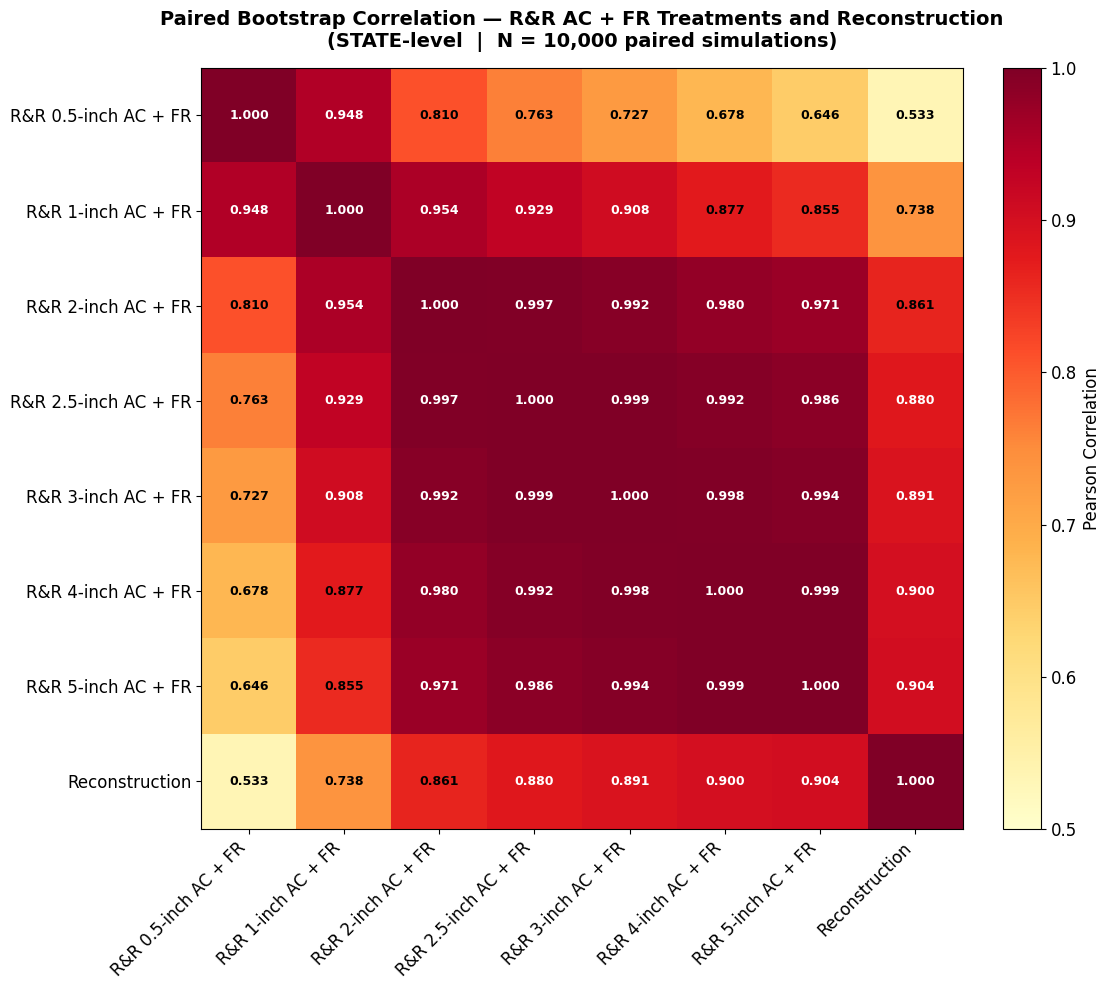

Saved: paired_rr_ac_fr_correlation_matrix.csv


In [43]:
# ===============================================================
# Paired Bootstrap Correlation — Remove and Replace AC + FR Treatments
#                                + Reconstruction
#
# Approach: in every simulation, ALL treatments share the same sampled
# bid-cost scenario — the same AC unit prices (mix, binder, mineral admix),
# the same FR lane-mile cost, the same tack cost, and the same milling cost.
# Reconstruction additionally draws from the base and subbase pools (also
# shared within the same simulation row).  Only tonnage multipliers differ
# by thickness.  Correlation therefore reflects real shared market exposure,
# not synthetic lognormal multipliers.
#
# Outputs:
#   paired_totals_df         — (N_SIMS x 8) simulation table
#   corr_matrix              — 8x8 Pearson correlation matrix
#   paired_rr_ac_fr_correlation_matrix.csv
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MILE_TO_KM = 1 / 1.609344  # 1 mile = 1.609344 km; $/lane-km = $/lane-mile x MILE_TO_KM

# ---------------------------------------------------------------
# Settings
# ---------------------------------------------------------------
N_SIMS      = 10_000
RANDOM_SEED = GLOBAL_SEED

THICKNESS_LIST = [0.5, 1.0, 2.0, 2.5, 3.0, 4.0, 5.0]
TREATMENT_LABELS_PAIRED = {
    0.5: "R&R 0.5-inch AC + FR",
    1.0: "R&R 1-inch AC + FR",
    2.0: "R&R 2-inch AC + FR",
    2.5: "R&R 2.5-inch AC + FR",
    3.0: "R&R 3-inch AC + FR",
    4.0: "R&R 4-inch AC + FR",
    5.0: "R&R 5-inch AC + FR",
}
RECON_AC_THICKNESS_IN = 9.0   # matches AC_THICKNESS_IN in the Reconstruction cell

# AC lane-mile conversion constants (must match the rest of the notebook)
AC_UNIT_WEIGHT_PCF = 145.0
LANE_WIDTH_FT      = 12.0
AC_ASPHALT_FRAC    = 0.05
AC_ADMIX_AGG_FRAC  = 0.01

# ---------------------------------------------------------------
# Step 1: Build per-job AC unit-price pool (STATE-level)
#
# We need raw unit prices, not thickness-specific totals, so the
# same job's prices can be scaled to any AC thickness.
# ---------------------------------------------------------------
df_local = df.copy()
df_local["PayItemID"] = df_local["PayItemID"].astype(str)
df_local["_up"] = pd.to_numeric(df_local["UnitPrice_Real_2025Q1"], errors="coerce")

job_mix    = set(df_local.loc[df_local["PayItemID"].isin(ac_mix_ids),    "JobID"].unique())
job_binder = set(df_local.loc[df_local["PayItemID"].isin(ac_binder_ids), "JobID"].unique())
job_ma     = set(df_local.loc[df_local["PayItemID"].isin(ac_ma_ids),     "JobID"].unique())
ac_eligible_jobs = job_mix & job_binder & job_ma

ac_price_rows = []
for jobid in ac_eligible_jobs:
    jr       = df_local[df_local["JobID"] == jobid]
    mix_p    = jr.loc[jr["PayItemID"].isin(ac_mix_ids),    "_up"].median()
    binder_p = jr.loc[jr["PayItemID"].isin(ac_binder_ids), "_up"].median()
    ma_p     = jr.loc[jr["PayItemID"].isin(ac_ma_ids),     "_up"].median()
    if not (np.isnan(mix_p) or np.isnan(binder_p) or np.isnan(ma_p)):
        ac_price_rows.append({"mix_p": mix_p, "binder_p": binder_p, "ma_p": ma_p})

ac_price_df = pd.DataFrame(ac_price_rows)
#print(f"AC price pool:  n = {len(ac_price_df)} jobs")

# ---------------------------------------------------------------
# Step 2: Pull STATE-level pools for FR, Tack, Milling,
#         Base (4-inch), and Subbase (12-inch)
#
# base4_state_vals and subbase8_state_vals are defined in the
# Builds STATE-level cost distributions for each Reconstruction component.
# ---------------------------------------------------------------
fr_pool      = fr_for_box.loc[fr_for_box["County"] == "STATE",   "Total_Cost_LaneMile"].dropna().values
tack_pool    = tack_for_box.loc[tack_for_box["County"] == "STATE", "Tack_Cost_Per_LaneMile"].dropna().values
mill_pool    = mill_for_box_clean.loc[mill_for_box_clean["County"] == "STATE", "Milling_Cost_Per_LaneMile"].dropna().values

if "base4_state_vals" not in dir() and "base4_state_vals" not in globals():
    raise NameError("base4_state_vals not found. Run the Reconstruction component cell first.")
if "subbase8_state_vals" not in dir() and "subbase8_state_vals" not in globals():
    raise NameError("subbase8_state_vals not found. Run the Reconstruction component cell first.")

base_pool    = np.asarray(base4_state_vals,    dtype=float)
subbase_pool = np.asarray(subbase8_state_vals, dtype=float)
base_pool    = base_pool[np.isfinite(base_pool) & (base_pool > 0)]
subbase_pool = subbase_pool[np.isfinite(subbase_pool) & (subbase_pool > 0)]

#print(f"FR pool:        n = {len(fr_pool)}")
#print(f"Tack pool:      n = {len(tack_pool)}")
#print(f"Milling pool:   n = {len(mill_pool)}")
#print(f"Base pool:      n = {len(base_pool)}")
#print(f"Subbase pool:   n = {len(subbase_pool)}")

if min(len(fr_pool), len(tack_pool), len(mill_pool),
       len(base_pool), len(subbase_pool), len(ac_price_df)) == 0:
    raise ValueError(
        "One or more component pools is empty. "
        "Run the Remove-and-Replace and Reconstruction component cells before this cell."
    )

# ---------------------------------------------------------------
# Step 3: Pre-compute AC tonnage multipliers for each thickness
# ---------------------------------------------------------------
def ac_tonnages(thickness_in):
    vol_ft3     = LANE_WIDTH_FT * 5280.0 * (thickness_in / 12.0)
    mix_tons    = vol_ft3 * AC_UNIT_WEIGHT_PCF / 2000.0
    binder_tons = AC_ASPHALT_FRAC * mix_tons
    agg_tons    = mix_tons - binder_tons
    ma_tons     = AC_ADMIX_AGG_FRAC * agg_tons
    return mix_tons, binder_tons, ma_tons

tonnage_table = {t: ac_tonnages(t) for t in THICKNESS_LIST}
recon_ac_tonnages = ac_tonnages(RECON_AC_THICKNESS_IN)

# ---------------------------------------------------------------
# Step 4: Paired Monte Carlo simulation
#
# One shared draw per simulation — the same bid scenario is applied
# to every treatment.  Components not used by a treatment (base/
# subbase for R&R) are simply omitted from that treatment's total.
# ---------------------------------------------------------------
rng_paired = np.random.default_rng(RANDOM_SEED)

ac_idx      = rng_paired.integers(0, len(ac_price_df), size=N_SIMS)
fr_idx      = rng_paired.integers(0, len(fr_pool),     size=N_SIMS)
tack_idx    = rng_paired.integers(0, len(tack_pool),   size=N_SIMS)
mill_idx    = rng_paired.integers(0, len(mill_pool),   size=N_SIMS)
base_idx    = rng_paired.integers(0, len(base_pool),   size=N_SIMS)
subbase_idx = rng_paired.integers(0, len(subbase_pool),size=N_SIMS)

fr_s      = fr_pool[fr_idx]
tack_s    = tack_pool[tack_idx]
mill_s    = mill_pool[mill_idx]
base_s    = base_pool[base_idx]
subbase_s = subbase_pool[subbase_idx]
mix_s     = ac_price_df["mix_p"].values[ac_idx]
binder_s  = ac_price_df["binder_p"].values[ac_idx]
ma_s      = ac_price_df["ma_p"].values[ac_idx]

shared_non_ac = fr_s + tack_s + mill_s  # shared by all treatments in each row

# R&R treatments (FR + Tack + Mill + AC at each thickness)
paired_cols = {}
for thick in THICKNESS_LIST:
    label = TREATMENT_LABELS_PAIRED[thick]
    mix_tons, binder_tons, ma_tons = tonnage_table[thick]
    ac_s = (mix_s * mix_tons + binder_s * binder_tons + ma_s * ma_tons) * MILE_TO_KM
    paired_cols[label] = shared_non_ac + ac_s

# Reconstruction (FR + Tack + Mill + AC 9-inch + Base 4-inch + Subbase 12-inch)
mix_tons_r, binder_tons_r, ma_tons_r = recon_ac_tonnages
ac_recon_s = (mix_s * mix_tons_r + binder_s * binder_tons_r + ma_s * ma_tons_r) * MILE_TO_KM
paired_cols["Reconstruction"] = shared_non_ac + ac_recon_s + base_s + subbase_s

paired_totals_df = pd.DataFrame(paired_cols)

#print(f"\nPaired simulation table shape: {paired_totals_df.shape}")
#print("\nDescriptive statistics ($/lane-mile):")
fmt = paired_totals_df.describe().loc[["mean", "std"]].applymap(lambda x: f"${x:,.0f}")
#display(fmt)

# ---------------------------------------------------------------
# Step 5: Correlation matrix
# ---------------------------------------------------------------
corr_matrix = paired_totals_df.corr()

#print("\nCorrelation Matrix — R&R AC + FR Treatments and Reconstruction")
#print("(Paired bootstrap, STATE-level, N =", N_SIMS, "simulations)\n")
#display(corr_matrix.round(4))

# ---------------------------------------------------------------
# Step 6: Correlation heatmap
# ---------------------------------------------------------------
treat_labels = list(paired_totals_df.columns)
corr_arr     = corr_matrix.to_numpy()
n_treat      = len(treat_labels)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_arr, vmin=0.5, vmax=1.0, cmap="YlOrRd")

cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Pearson Correlation", fontsize=12)

ax.set_xticks(range(n_treat))
ax.set_yticks(range(n_treat))
ax.set_xticklabels(treat_labels, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(treat_labels, fontsize=12)

# Annotate each cell with the correlation value
for i in range(n_treat):
    for j in range(n_treat):
        val = corr_arr[i, j]
        text_color = "black" if val < 0.88 else "white"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color=text_color, fontweight="bold")

ax.set_title(
    "Paired Bootstrap Correlation — R&R AC + FR Treatments and Reconstruction\n"
    f"(STATE-level  |  N = {N_SIMS:,} paired simulations)",
    fontsize=14, fontweight="bold", pad=15
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Step 7: Export correlation matrix to CSV
# ---------------------------------------------------------------
corr_matrix.to_csv("paired_rr_ac_fr_correlation_matrix.csv")
print("Saved: paired_rr_ac_fr_correlation_matrix.csv")